### Scott 10K sigdiff

#### Taking each set of beta coefficents (desikan/flipped desikan, destrieux/flipped destrieux) and...
1. Segregate out only AD and CN patient values
2. For each diagnosis (AD and CN) normality testing + histogram for data visualisation
3. For each diagnosis (AD and CN) equal variance testing
4. Then, depending on normality and variance, compare AD and CN beta coefficients using:
    Student t-test (normal distribution + equal variance)
    Welch's t-test (normal distribution + unequal variance)
    Mann-Whitney U test (non-normal distribution + unequal variance)
    WITH BONFERRONI POST-HOC CORRECTION
5. Print readout from step 4
6. Plot swarmplots
    This is the hardest bit because we need swarmplots where all datapoints are plotted
    Need to iterate through various settings
    1 Plot with all datapoints from AD and CN
    1 Plot with those beyond 2 standard deviations cleaned out

#### Average beta coefficient values for AD and CN

[[-3.24233837e-03 -1.90439656e-04  6.89531304e-04 -5.19187295e-04
   1.69337713e-04  3.91256365e-05  3.05562218e-03 -1.43919764e-03
  -8.52342706e-04  7.87173232e-04  9.05395375e-04 -1.82872412e-03
   2.80324887e-03  2.51759219e-04  3.11642303e-03 -1.47221358e-03
   8.42444118e-04  2.41472658e-03 -2.54042088e-03]]
[[ 0.0496994   0.23940665 -0.2341727  -0.0073559  -0.2175486   0.02193292
   0.15803496 -0.03297877  0.12107902 -0.0861724   0.00356736 -0.42337654
  -0.13308889 -0.03385986  0.27002158 -0.0441427   0.22199356 -0.05995584
  -0.12264914]]


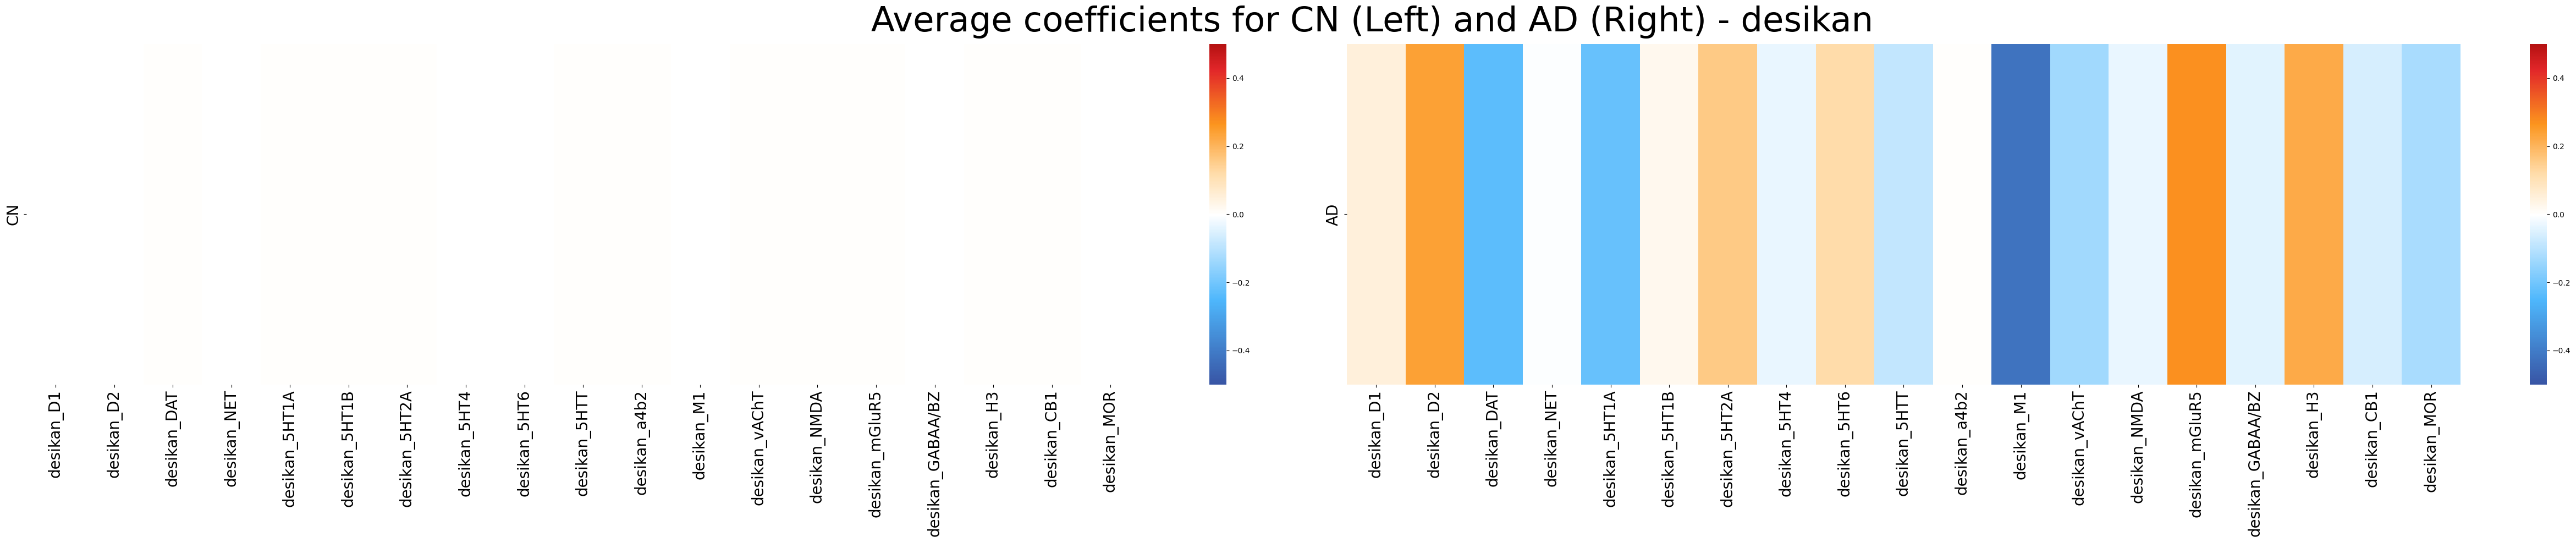

[[-0.00140032 -0.00011464 -0.00152856  0.00191632 -0.00059447 -0.00064124
   0.00183195  0.00074207  0.00047713  0.00025875 -0.00013807  0.00164622
  -0.00026325  0.00065188  0.00138341 -0.00396041  0.00055335 -0.00026772
  -0.0006289 ]]
[[-0.01058189  0.0604313  -0.0020023  -0.01079421  0.02209696 -0.04862624
   0.15812638  0.14284145  0.0056882  -0.25356288  0.32093285  0.058239
  -0.00765862 -0.1461515  -0.00628866 -0.02084038  0.1730371   0.00804829
  -0.20863419]]


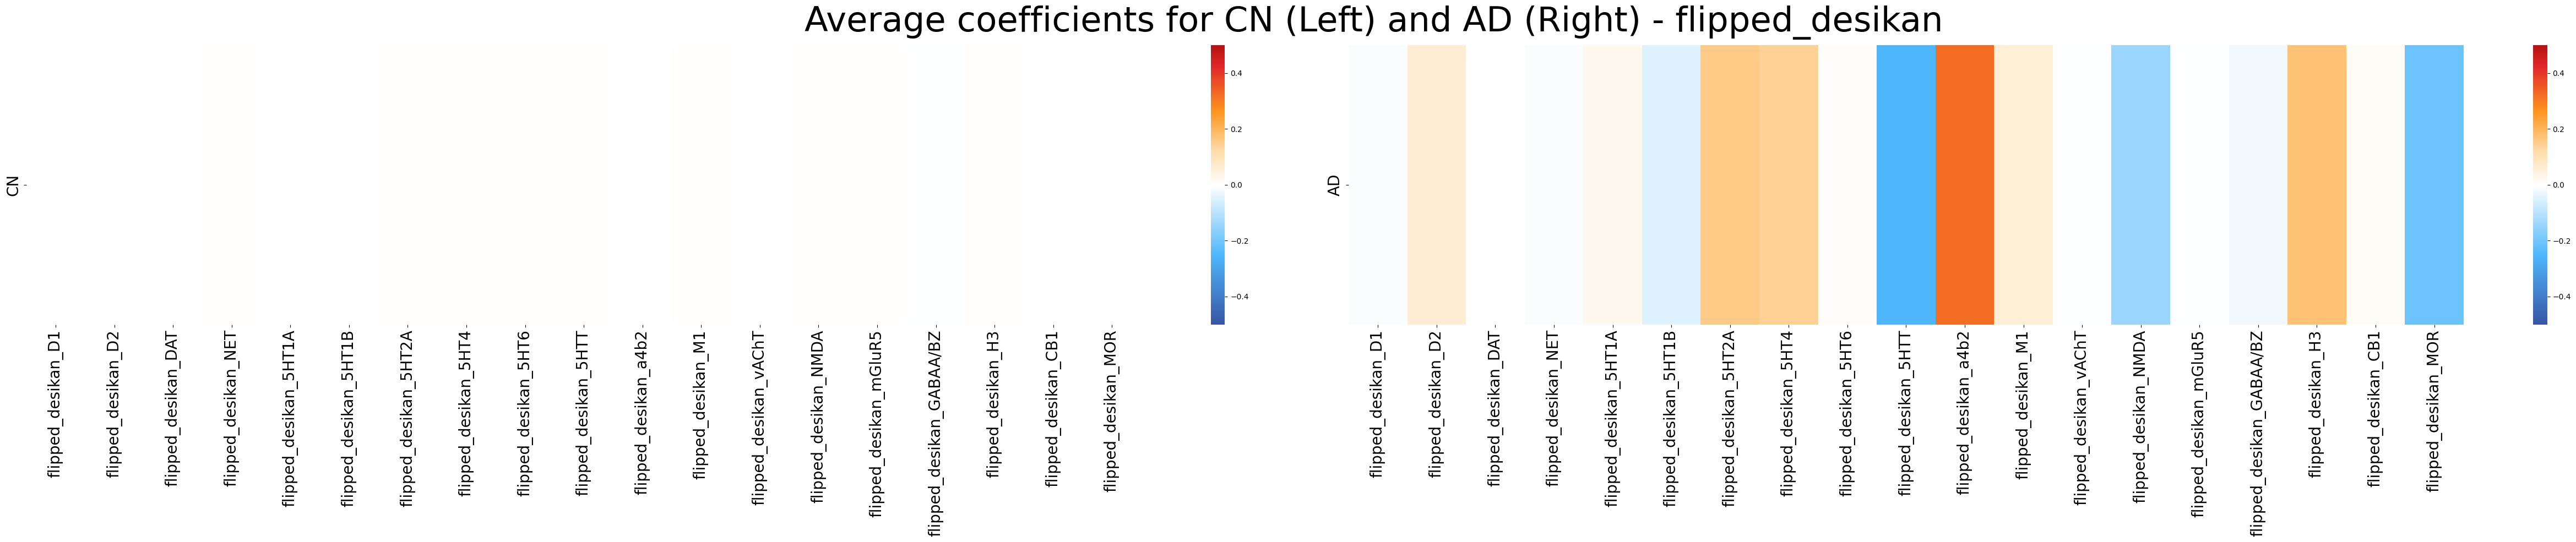

[[-0.00367517  0.00097746  0.0007291   0.00027669  0.00031227  0.00106985
   0.00166019 -0.00176118  0.00070426  0.00046222 -0.00066749 -0.00321836
   0.0021577   0.00086375  0.00129933 -0.00014107  0.00023447  0.00166101
  -0.00124854]]
[[ 0.10362174  0.33115696 -0.28162409  0.04617709 -0.16912635  0.09987469
   0.07040204 -0.03185425  0.06115548 -0.12331357 -0.01544046 -0.40184027
  -0.17775563  0.01910458  0.14797333  0.03220351  0.17402417 -0.02151047
  -0.10430172]]


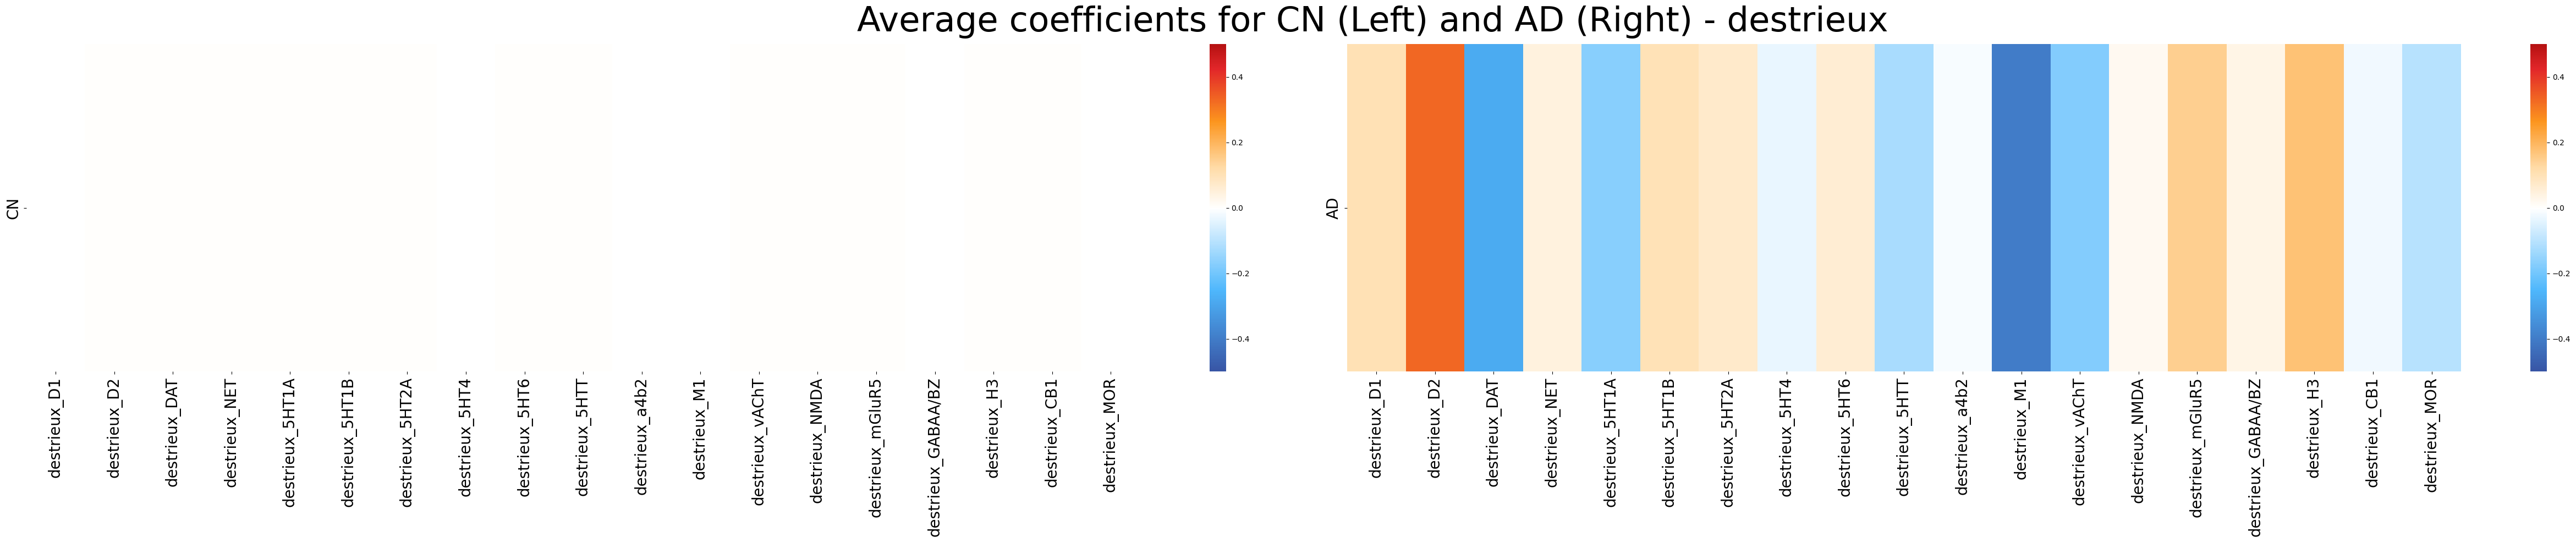

[[-0.00148585  0.0004375   0.00099888  0.00246157  0.0002438  -0.00094637
   0.00077417  0.0003666   0.00031591  0.00024498 -0.00021669  0.0010668
  -0.00101309 -0.00112786  0.00101028 -0.00087115 -0.00050413 -0.00050574
  -0.00067503]]
[[-0.00608116  0.03494924 -0.02065729  0.02474     0.00606954 -0.05411
   0.05199233  0.1548927   0.03240902 -0.2522679   0.24523088  0.05484444
   0.00735465 -0.1078593   0.024852   -0.00764255  0.10851115 -0.03398191
  -0.16380922]]


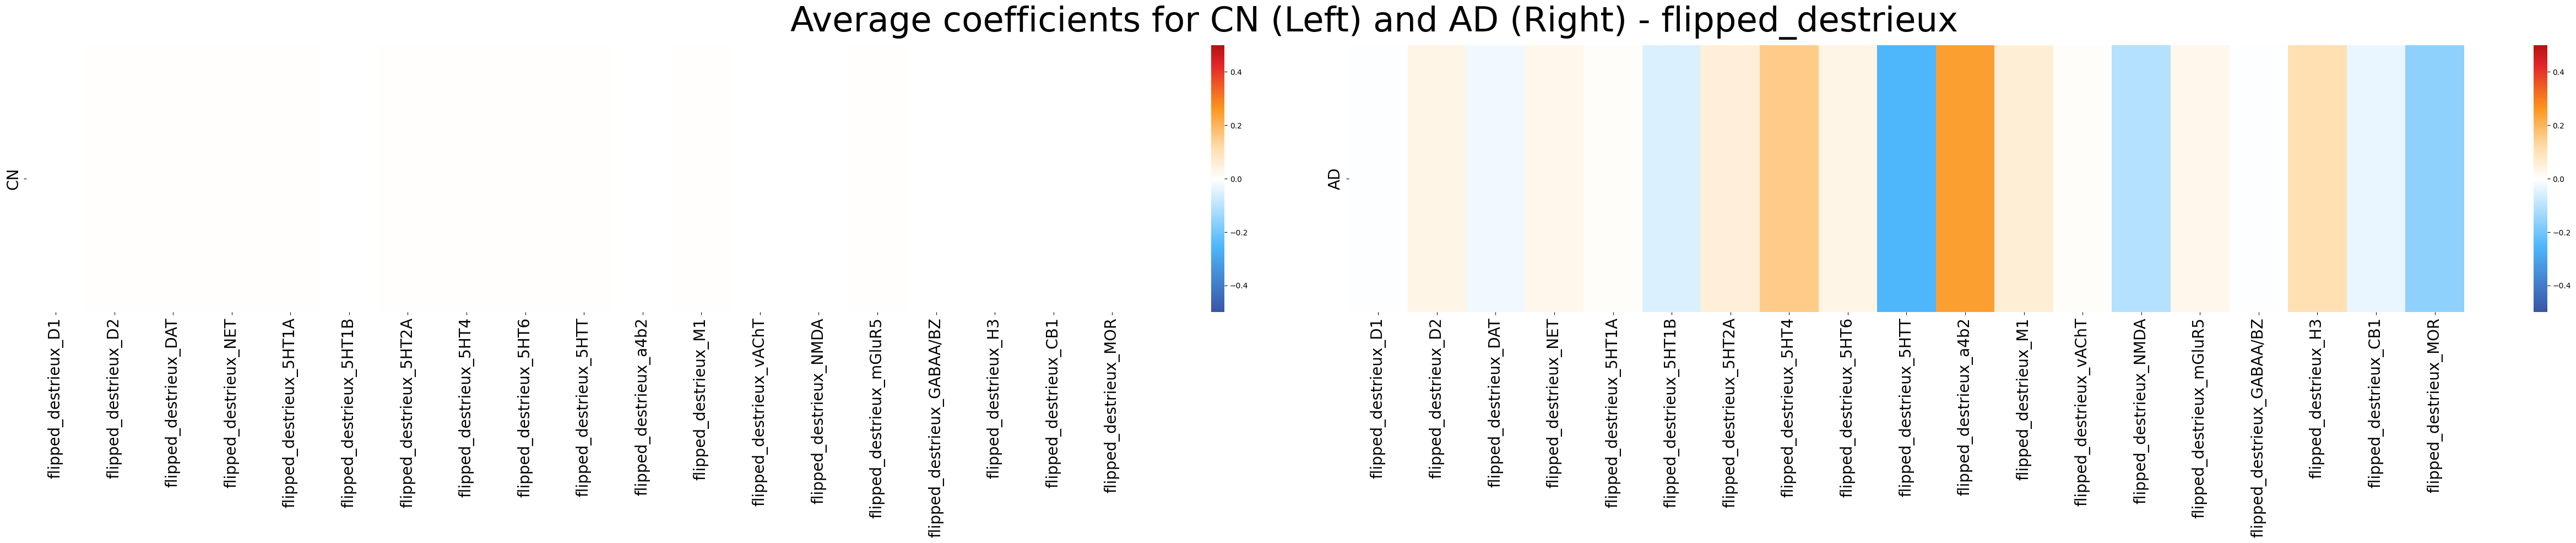

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.colors import ListedColormap
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

cmap = np.genfromtxt('/rds/general/project/c3nl_scott_students/live/sankeith/standards/colourmap.csv', delimiter=',')
cmap_div = ListedColormap(cmap)
cmap_seq = ListedColormap(cmap[128:, :])

coeff_save_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/avg_coeffs'
os.makedirs(coeff_save_path, exist_ok = True)

for coeff_path in ['/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/desikan_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_desikan_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/destrieux_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_destrieux_coeffs.csv']:

    df = pd.read_csv(coeff_path, low_memory=False)
    diag_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                          low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

    merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')

    excluded = ['DIAGNOSIS', 'DATA_KEY']

    cn_df = merged[merged['DIAGNOSIS'] == 1].drop(columns = excluded)
    ad_df = merged[merged['DIAGNOSIS'] == 3].drop(columns = excluded)

    cn_df_mean = cn_df.mean().values.reshape((1,-1))
    ad_df_mean = ad_df.mean().values.reshape((1,-1))

    print(cn_df_mean)
    print(ad_df_mean)

    plt.figure(figsize = (50,10))
    
    plt.subplot(1, 2, 1)
    sns.heatmap(cn_df_mean,
                xticklabels=  cn_df.columns.tolist(),
                yticklabels = ['CN'],
                vmin = -0.5,
                vmax = 0.5,
                cmap = cmap_div,
                annot = False)
    
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    plt.subplot(1, 2, 2)
    sns.heatmap(ad_df_mean,
                xticklabels = ad_df.columns.tolist(),
                yticklabels = ['AD'],
                vmin = -0.5,
                vmax = 0.5,
                cmap = cmap_div,
                annot = False)
    
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    plt.suptitle(f'Average coefficients for CN (Left) and AD (Right) - {os.path.basename(coeff_path).replace('_coeffs.csv', '')}',
                fontsize = 45)

    plt.tight_layout()

    plt.savefig(os.path.join(coeff_save_path, f"{os.path.basename(coeff_path).replace('_coeffs.csv', '')}.png"), dpi = 300)
    plt.show()

#### AD and CN histograms

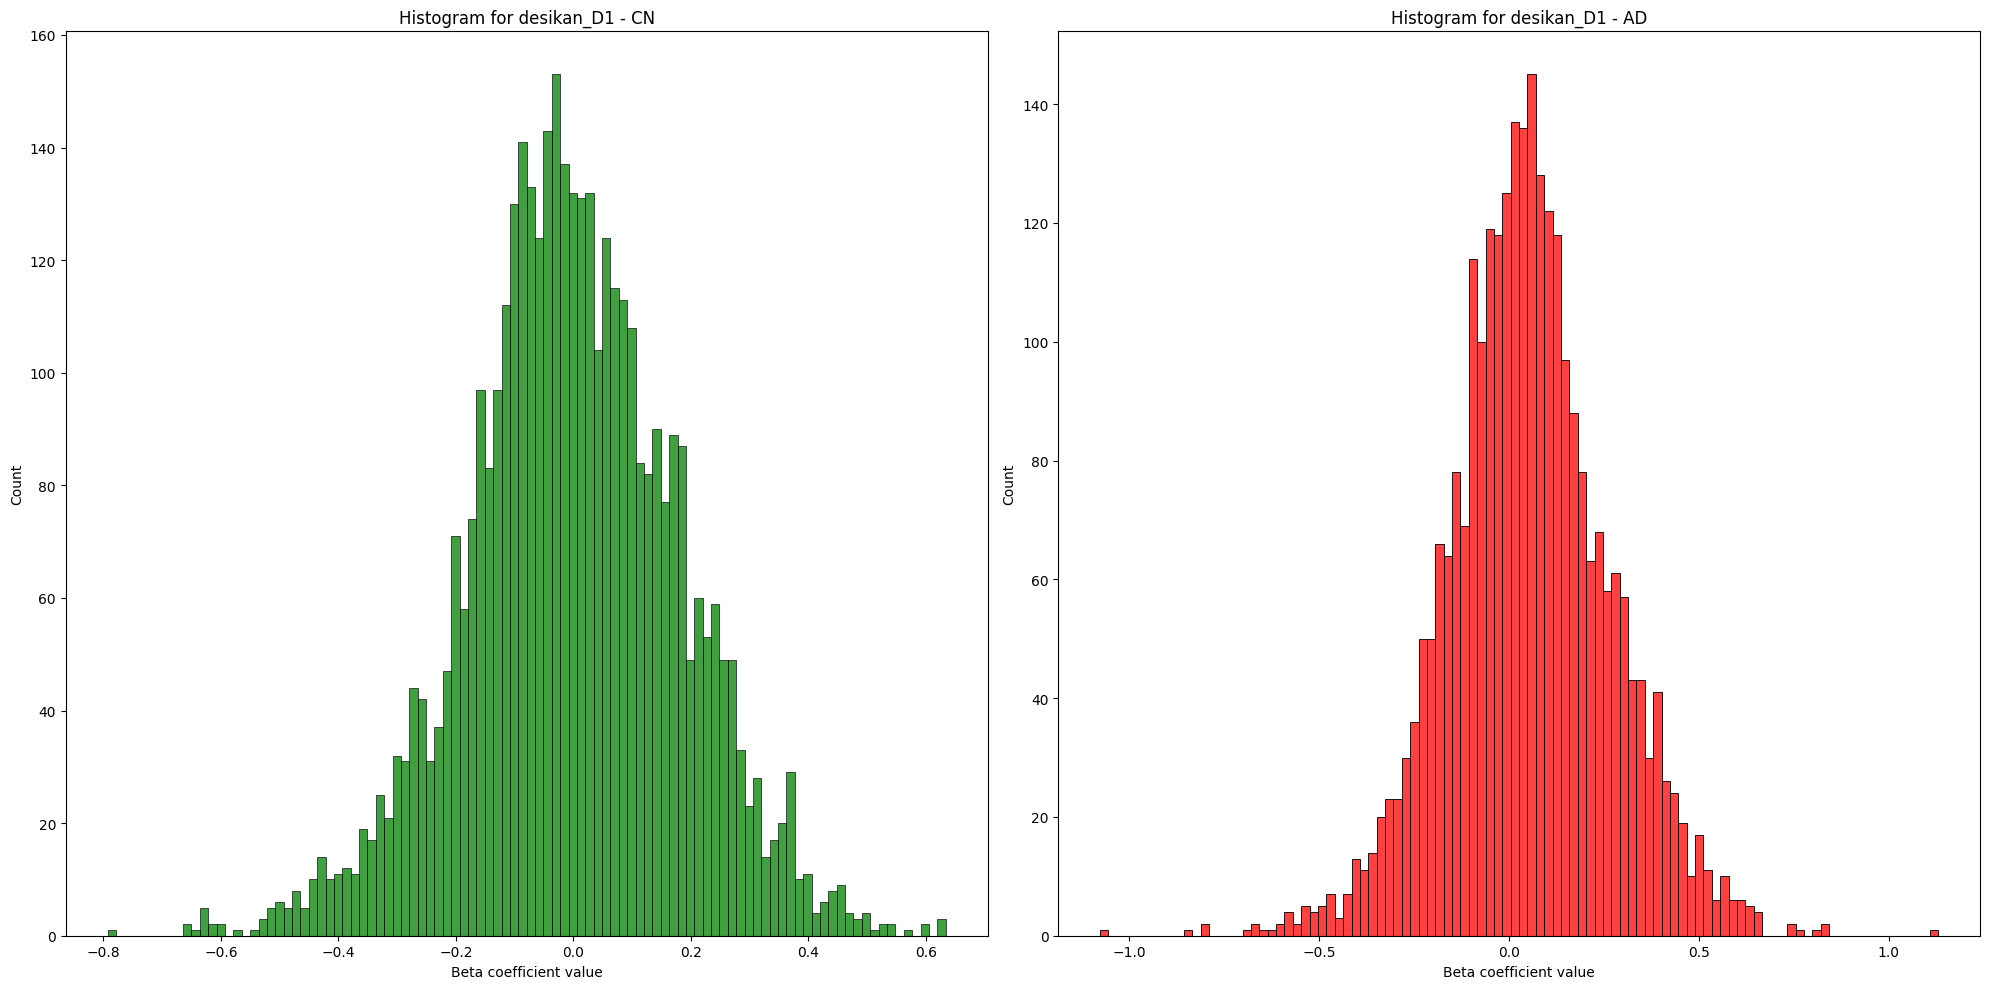

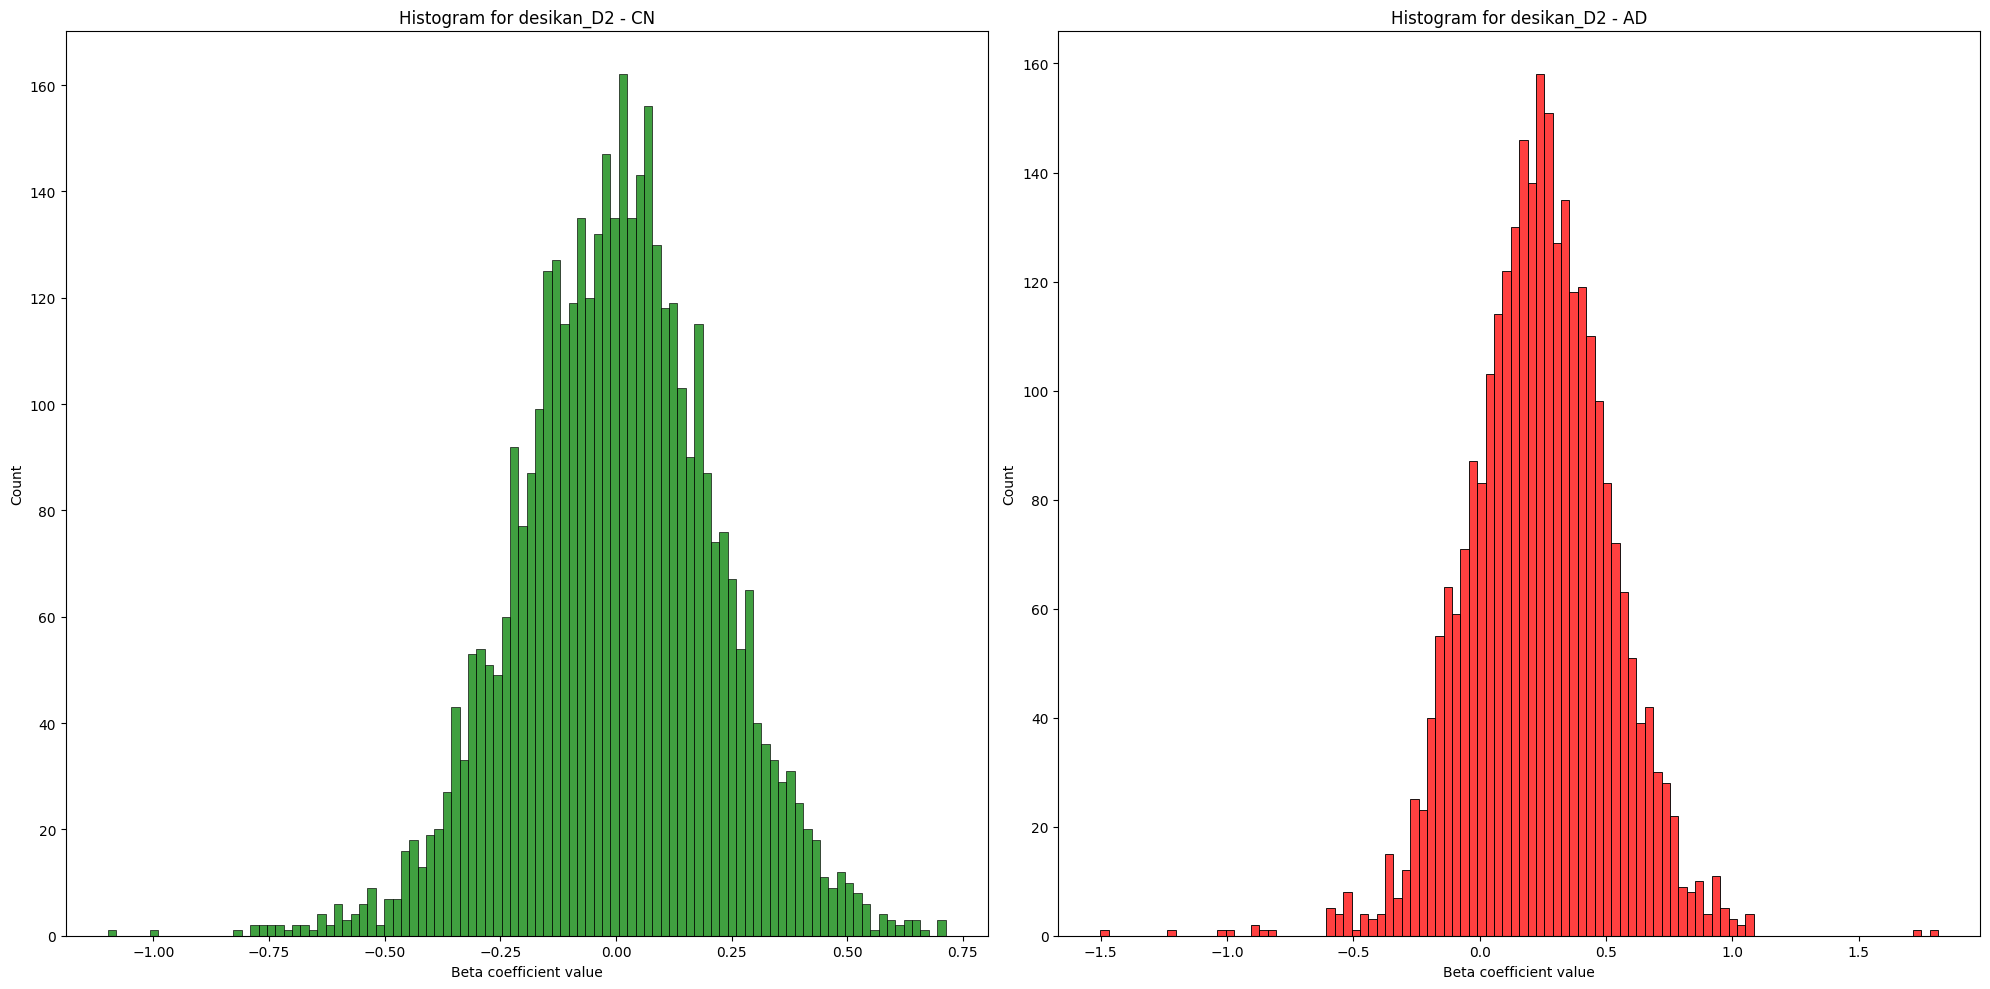

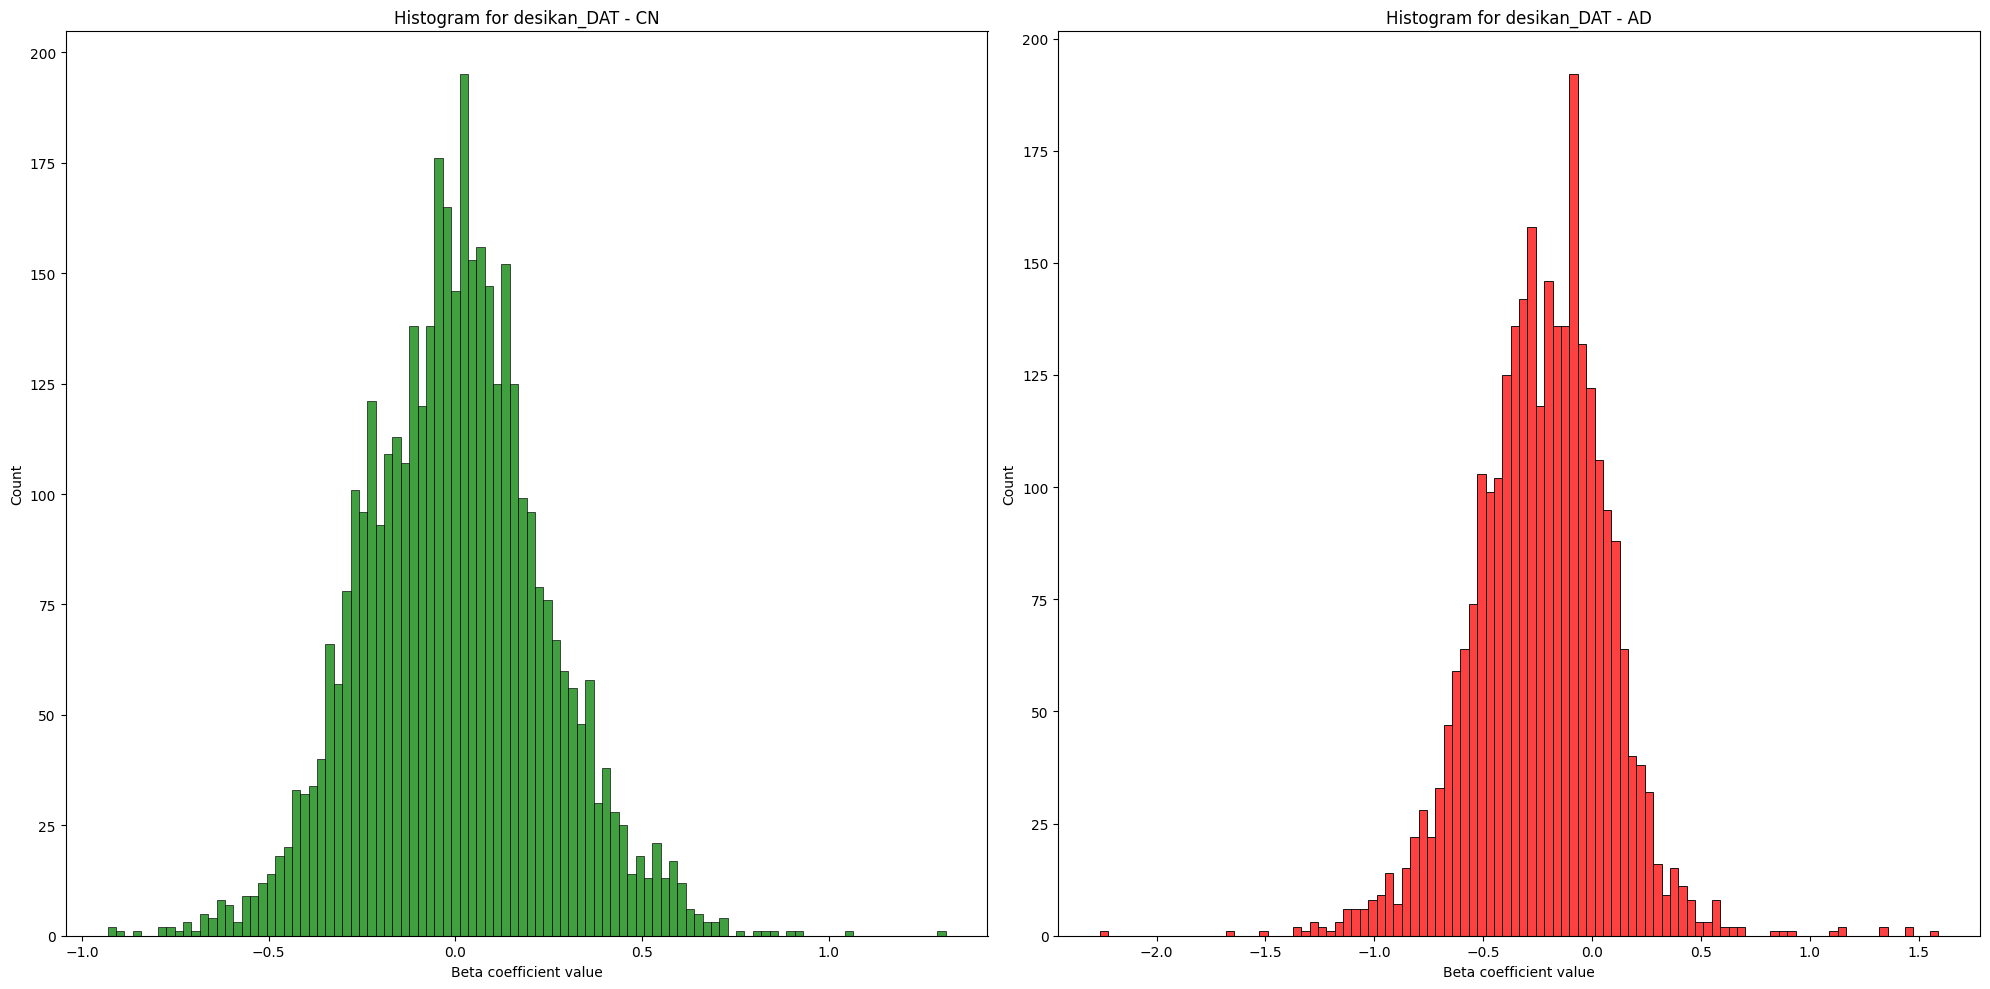

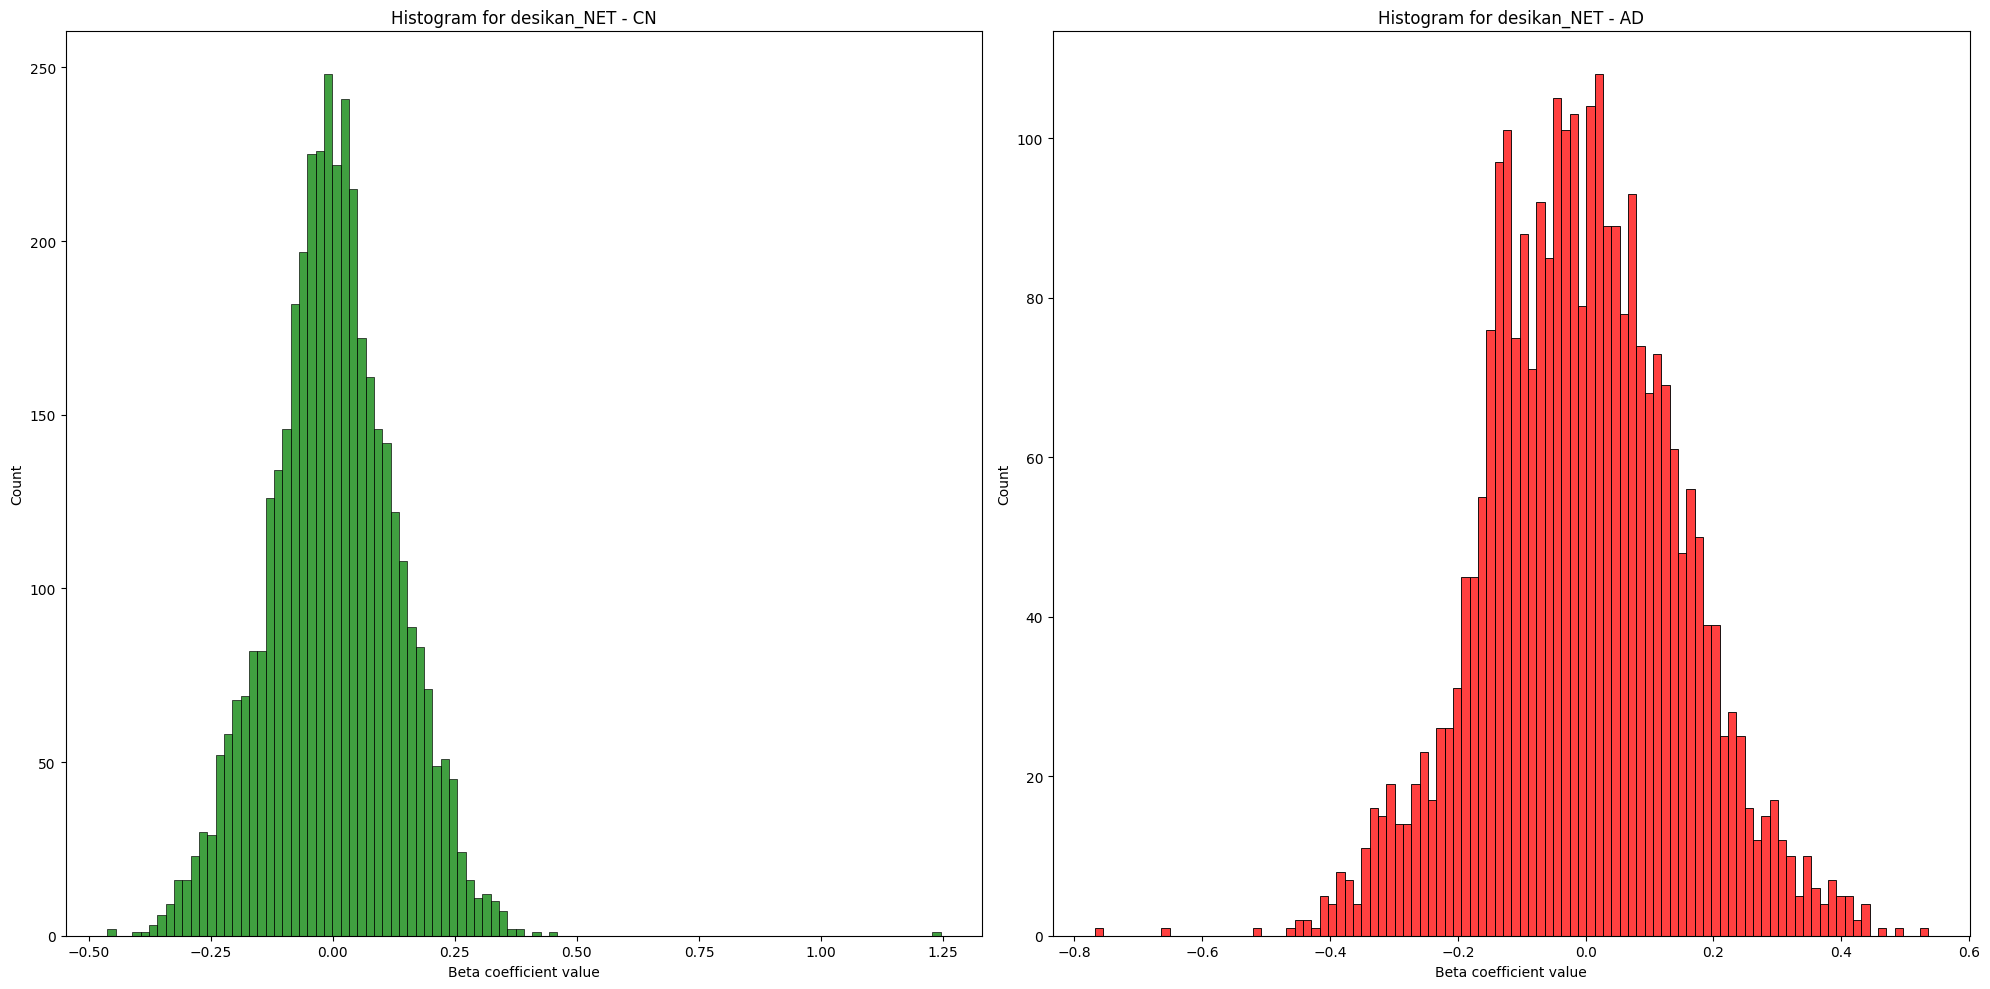

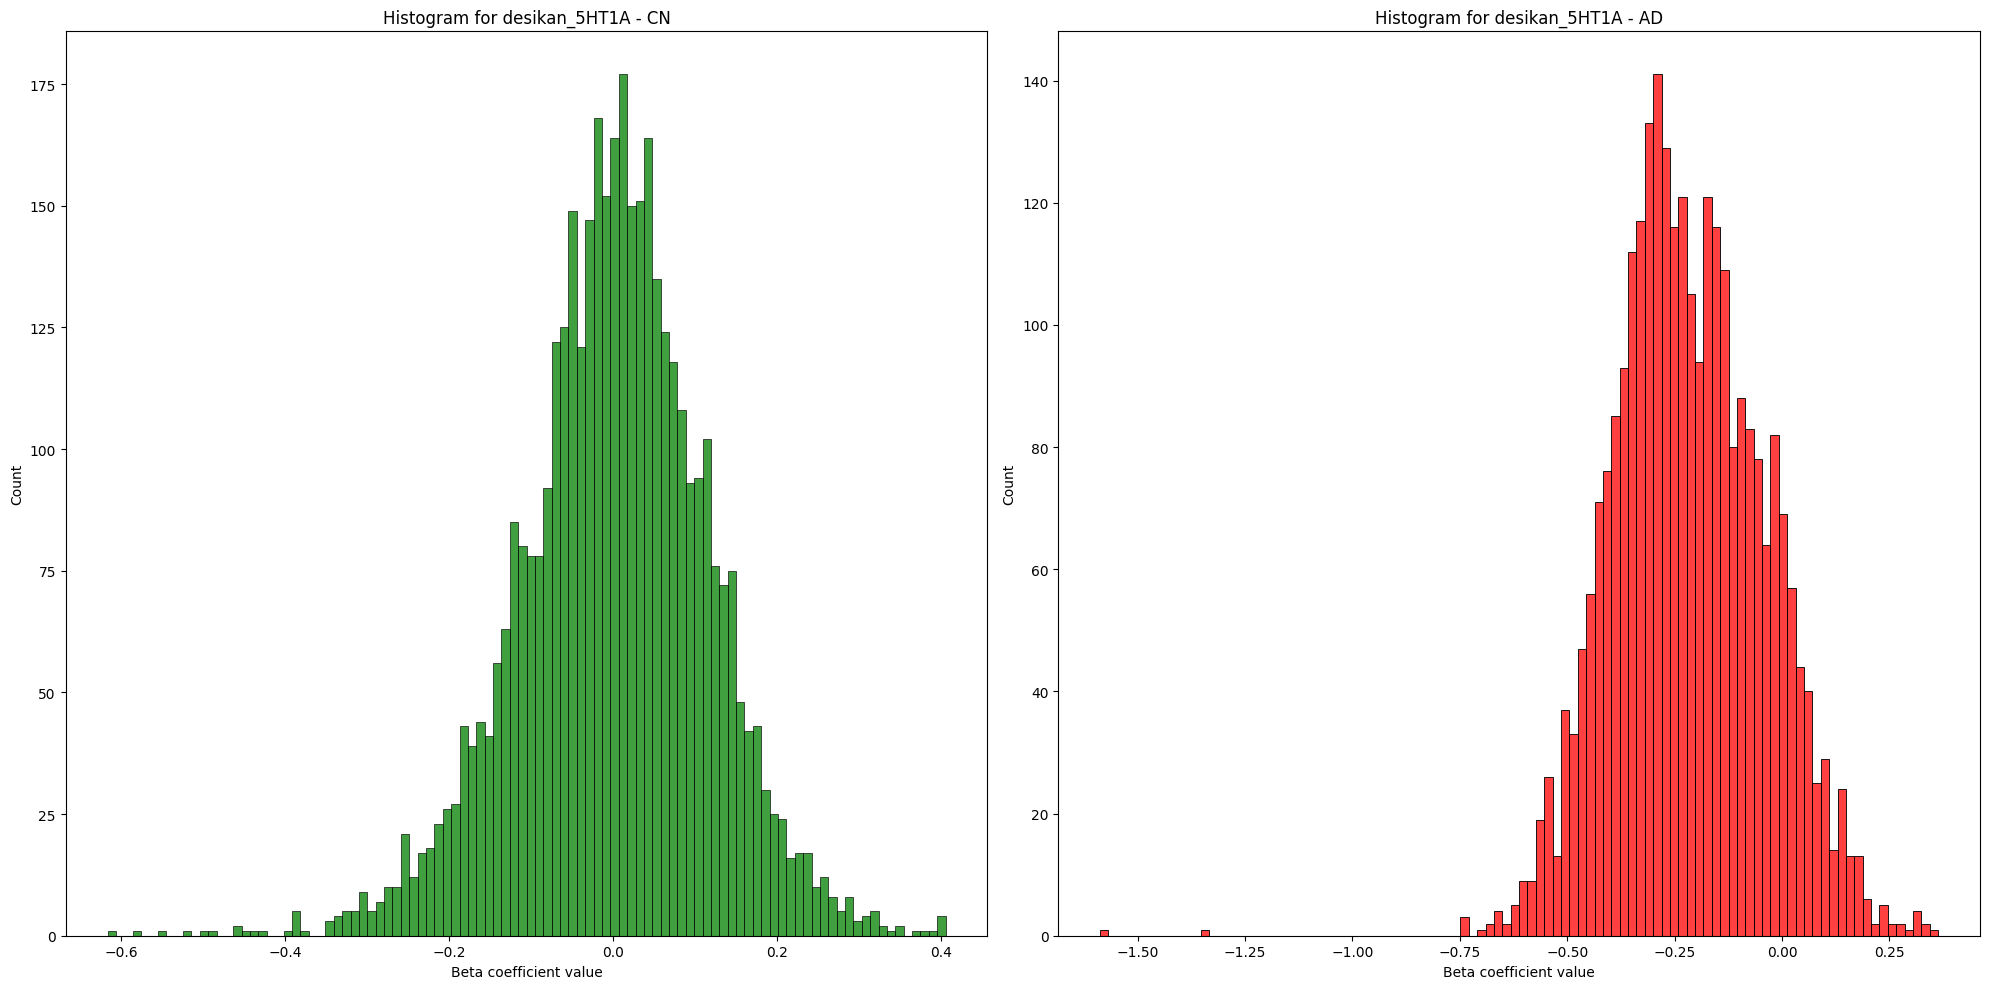

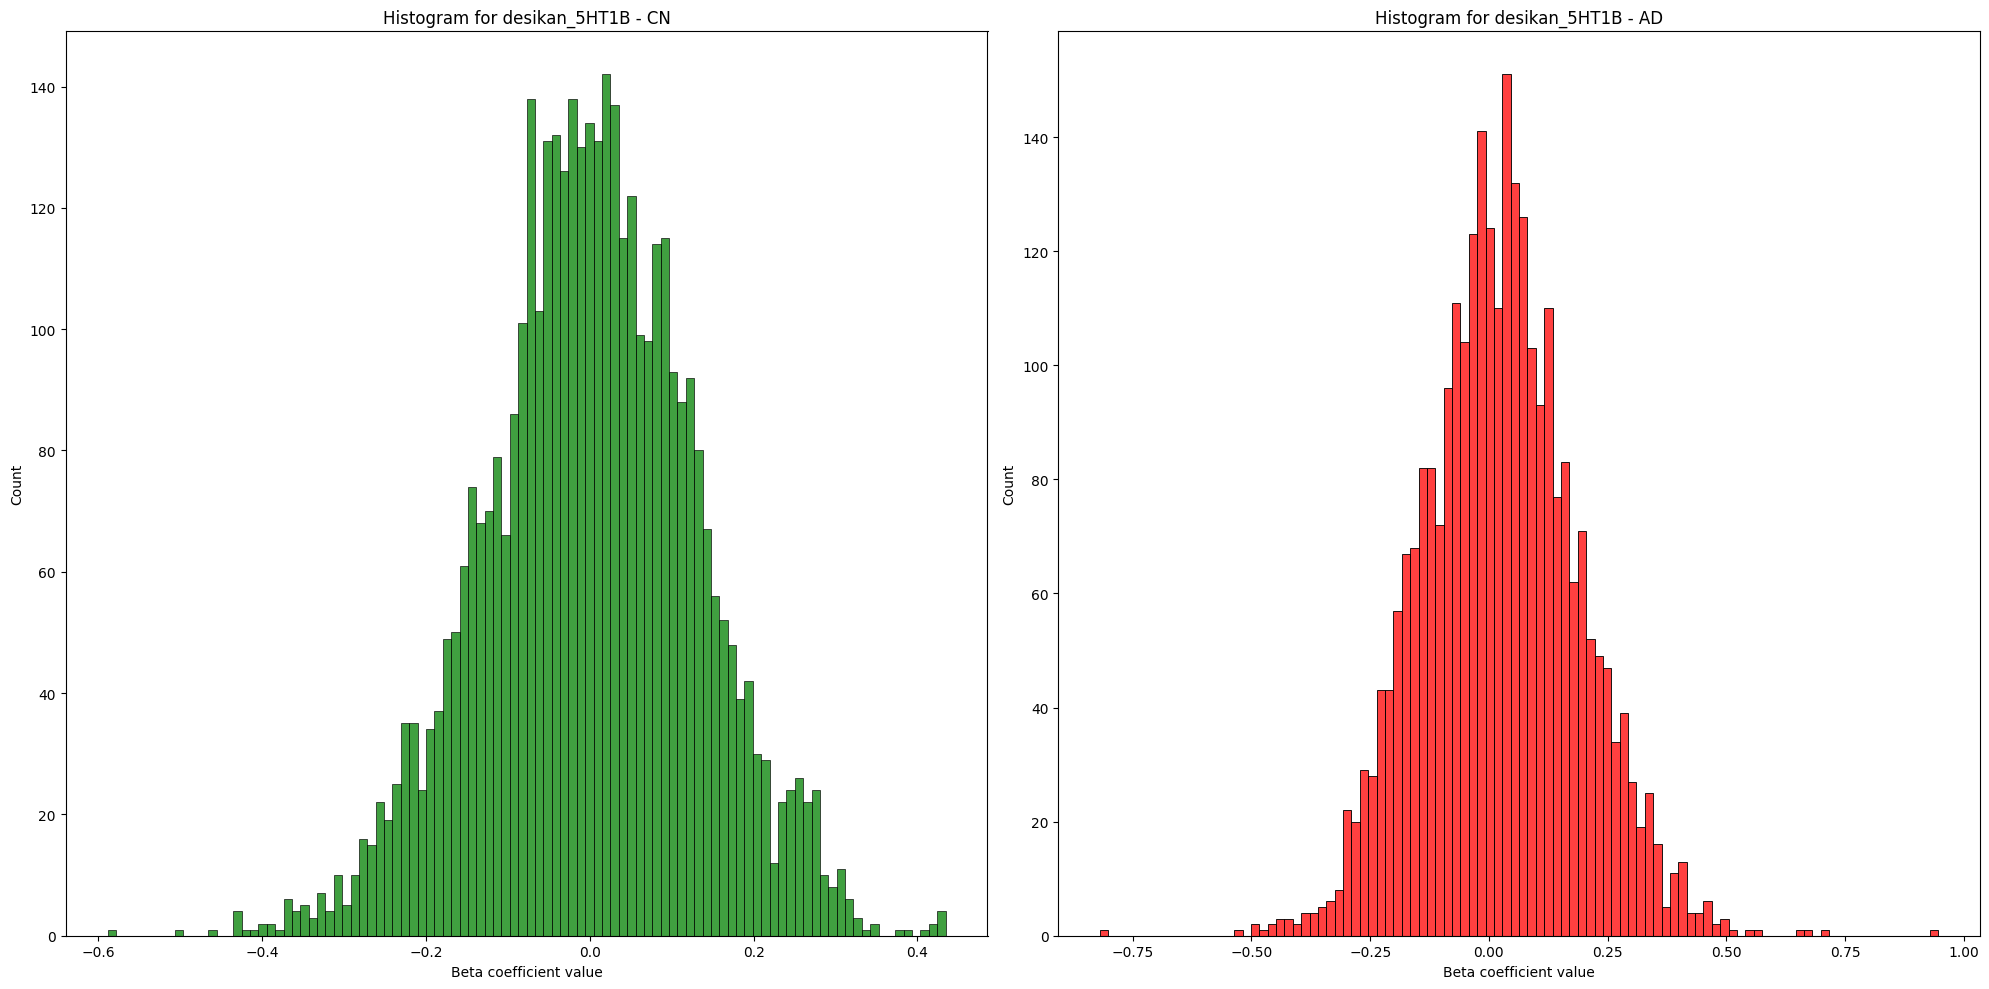

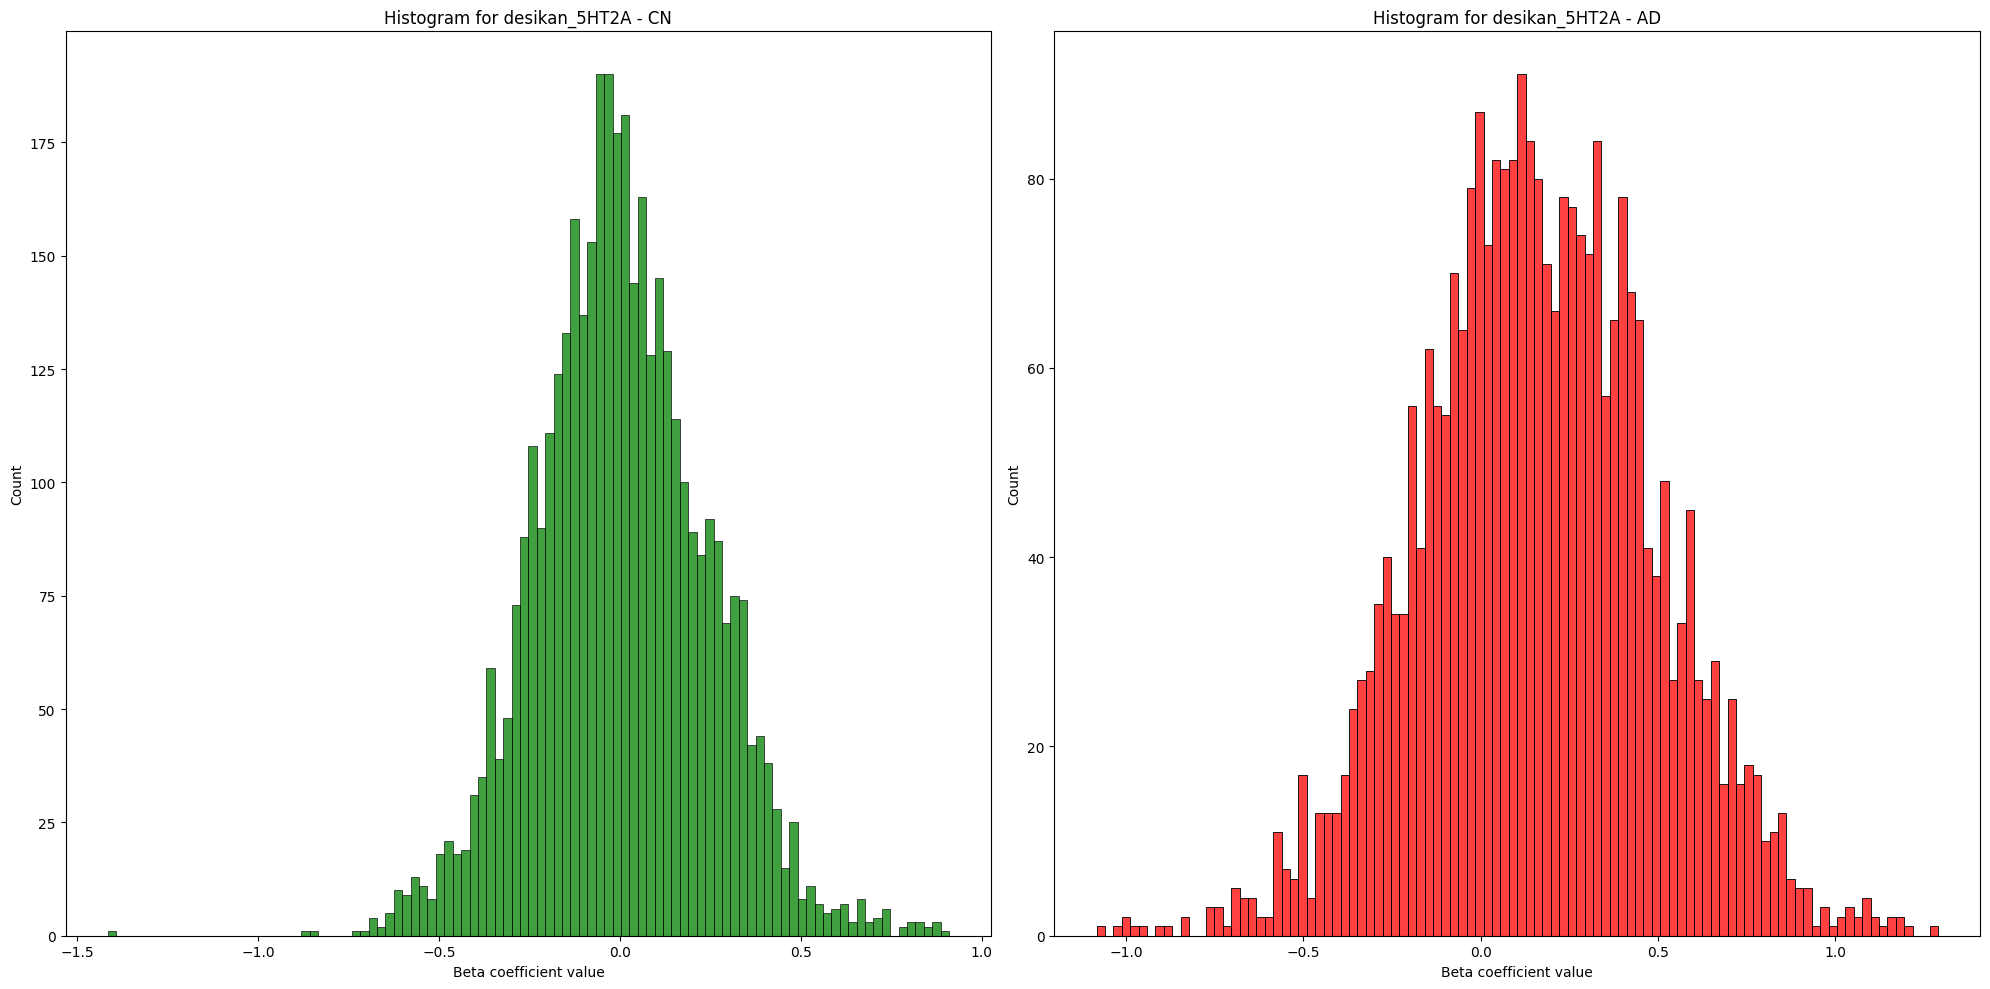

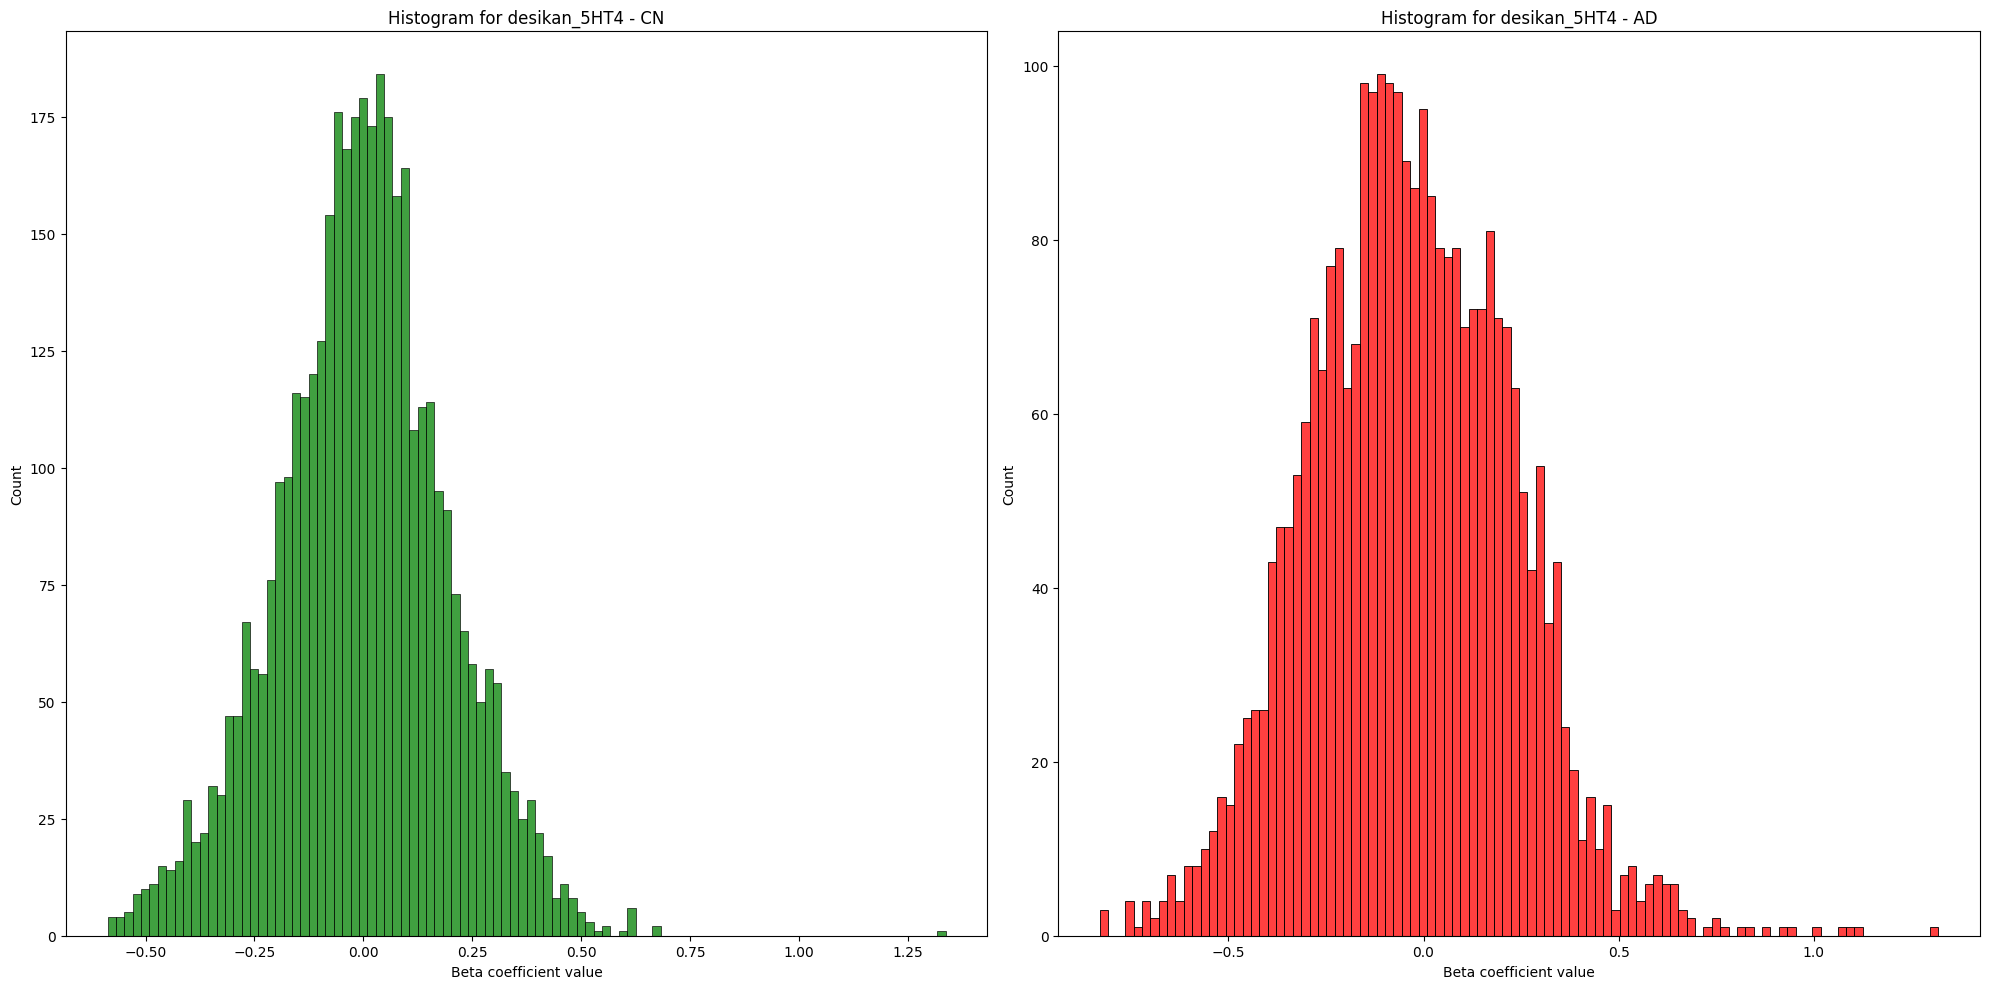

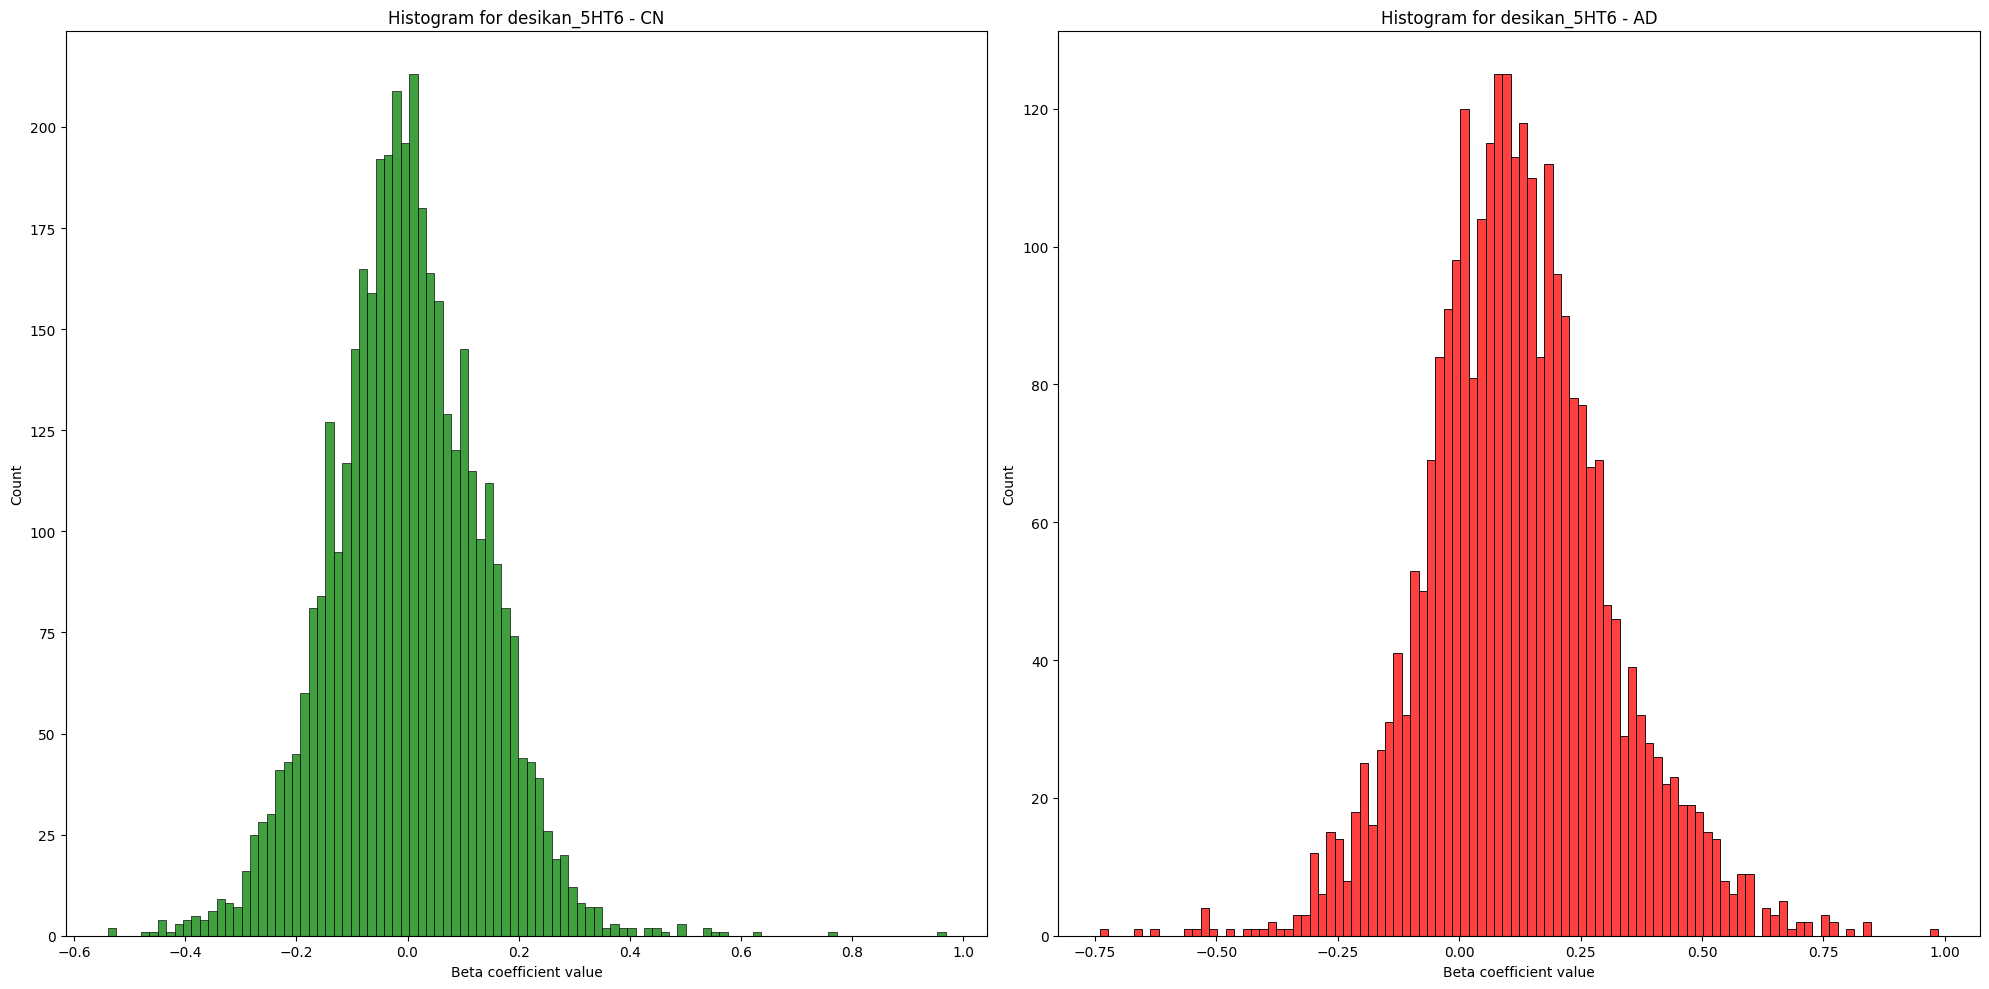

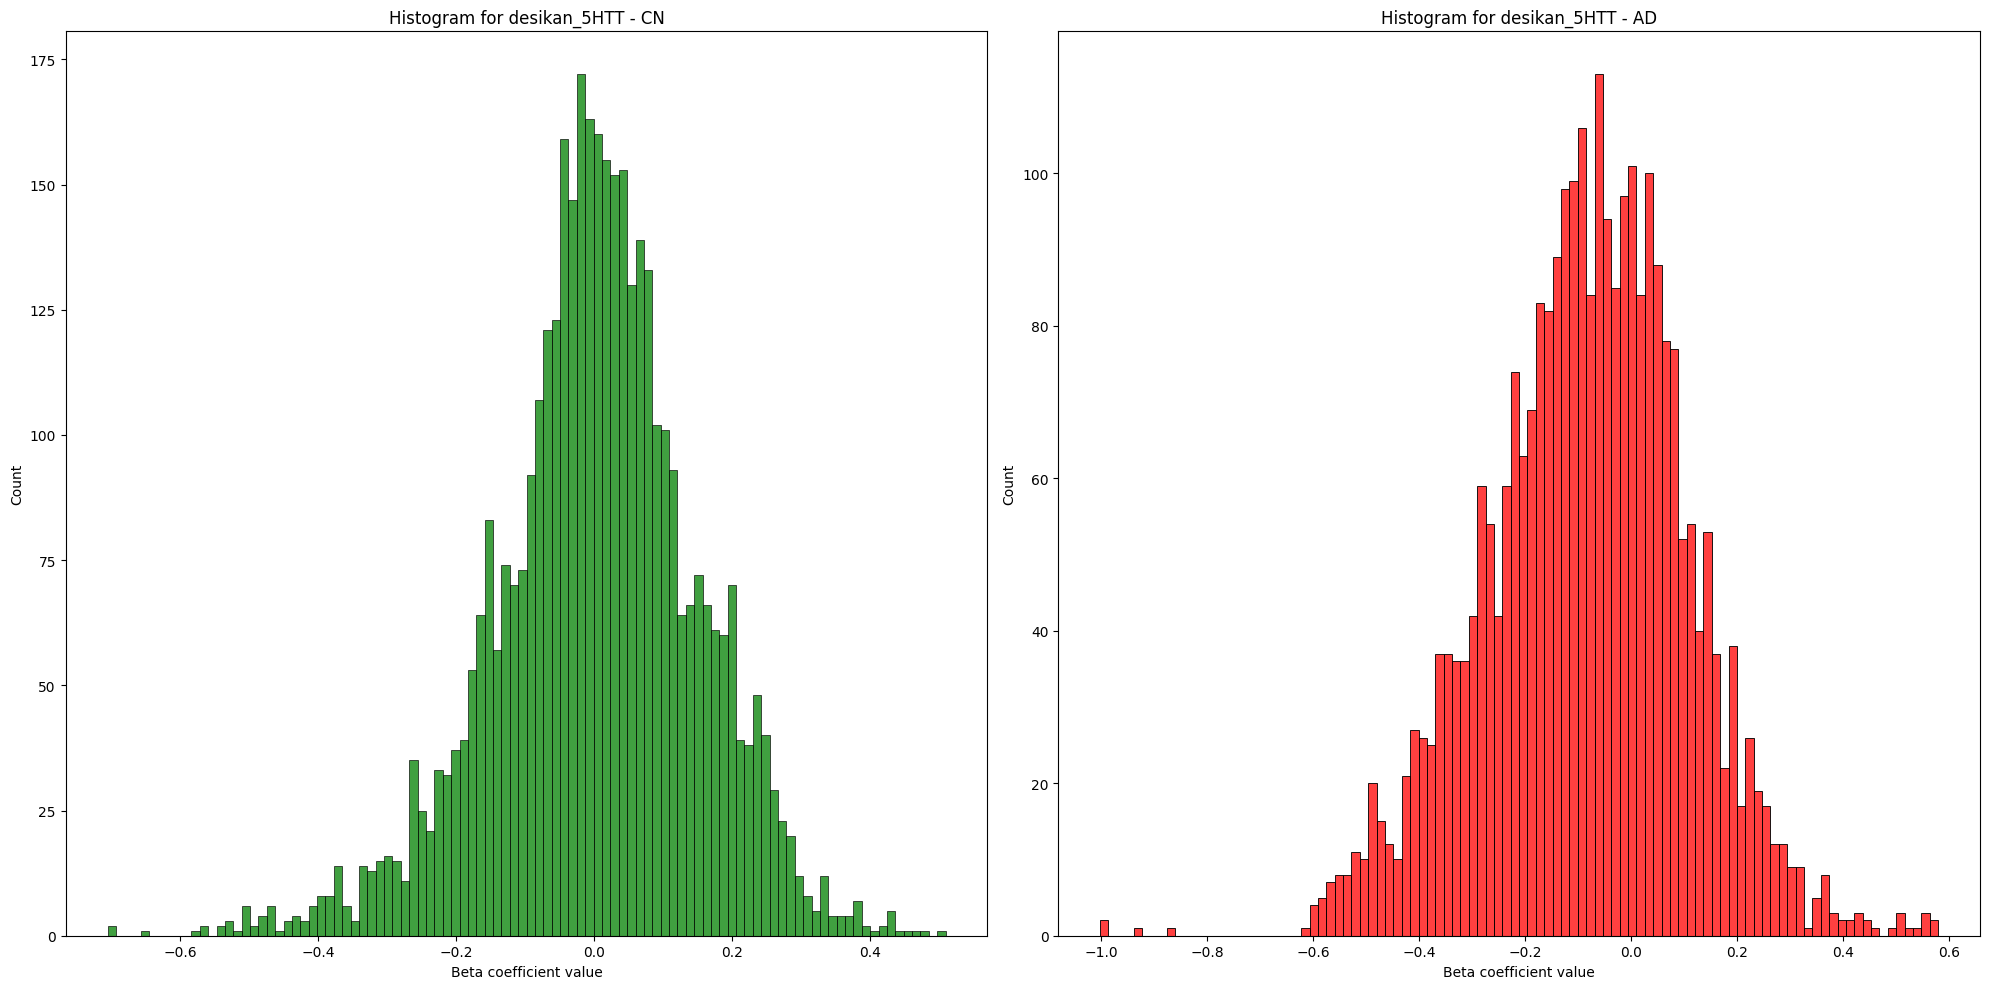

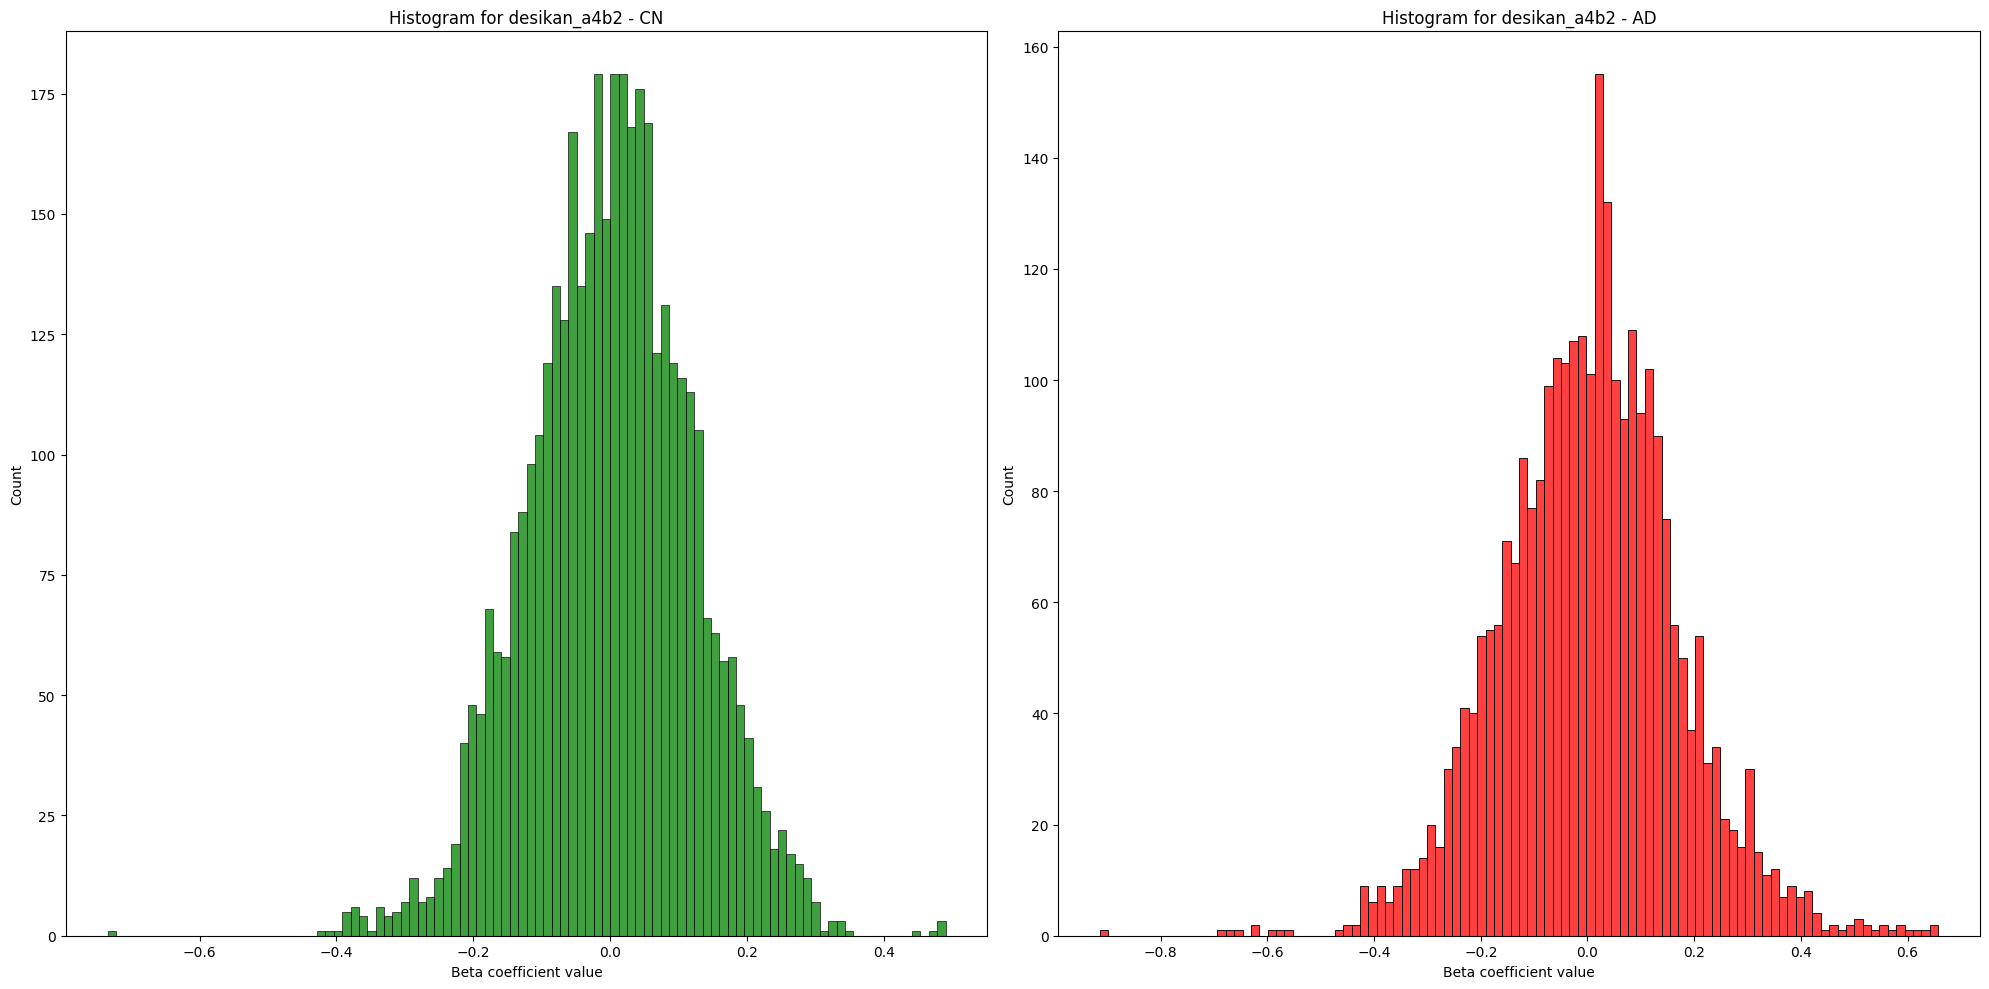

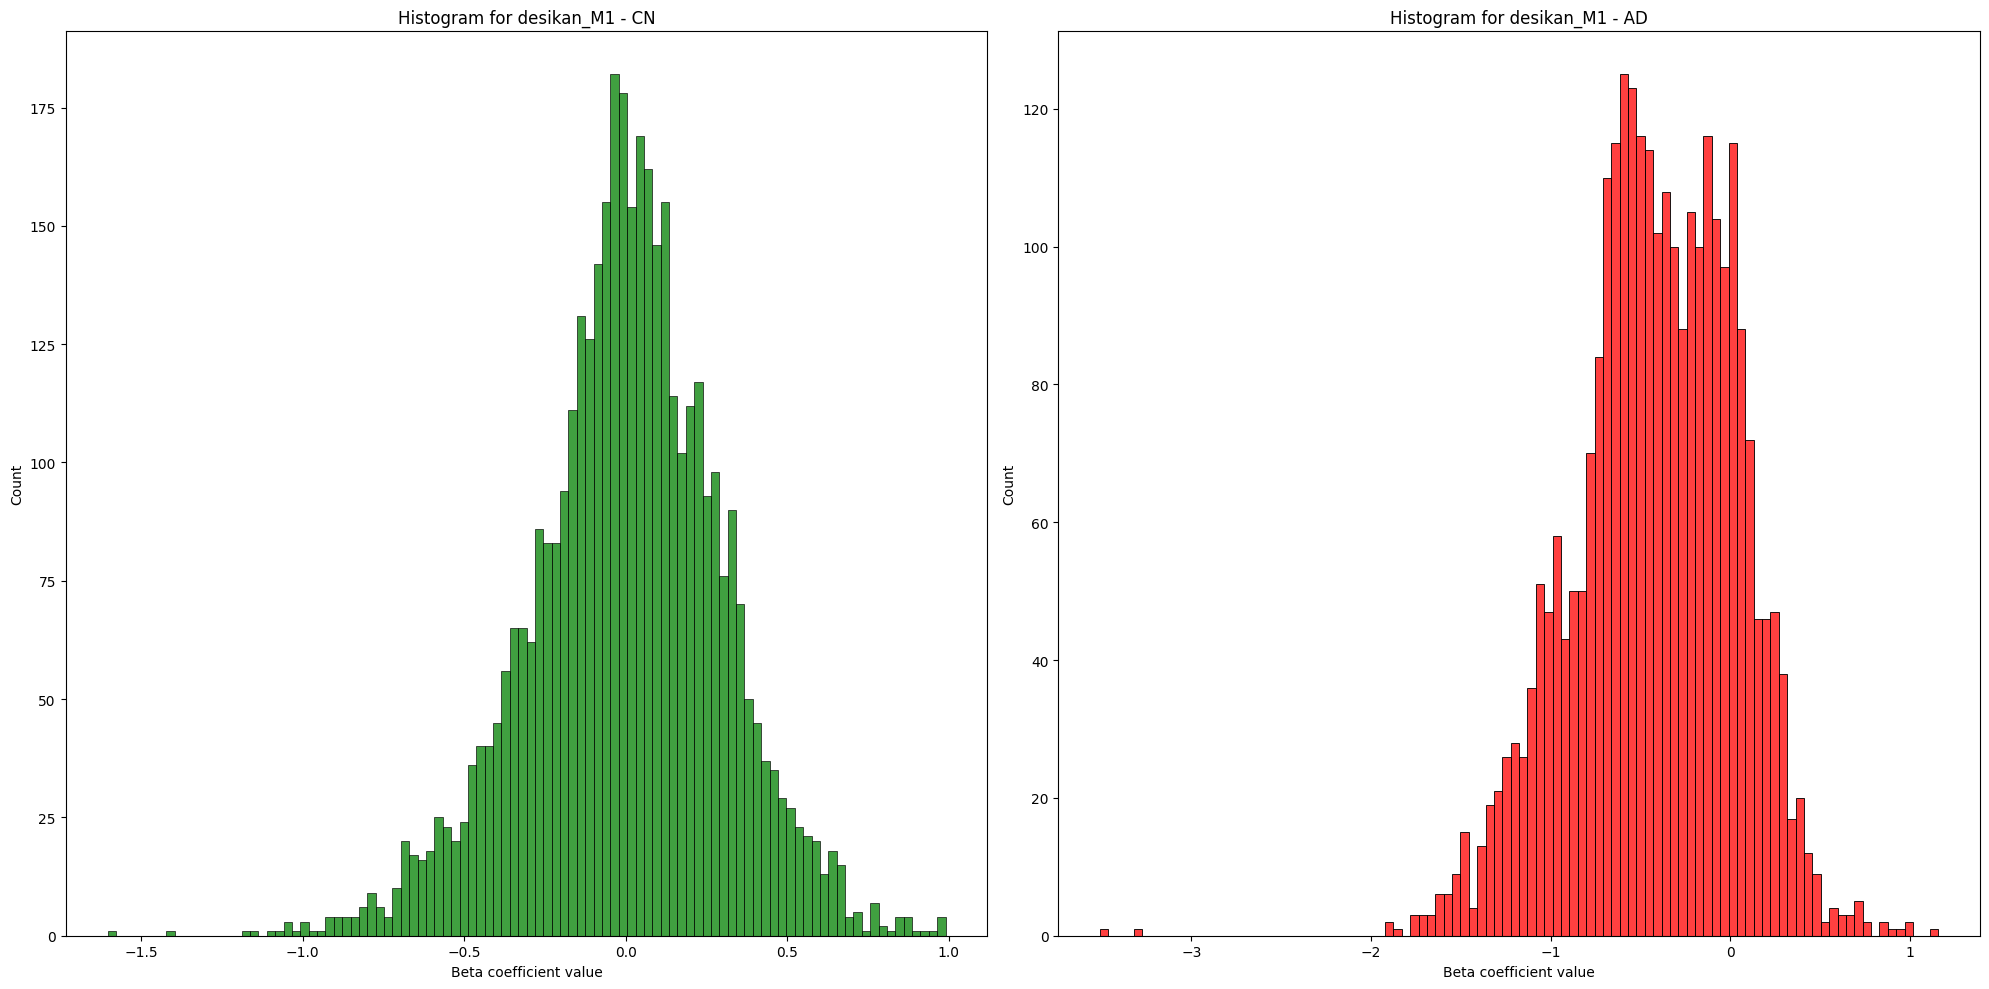

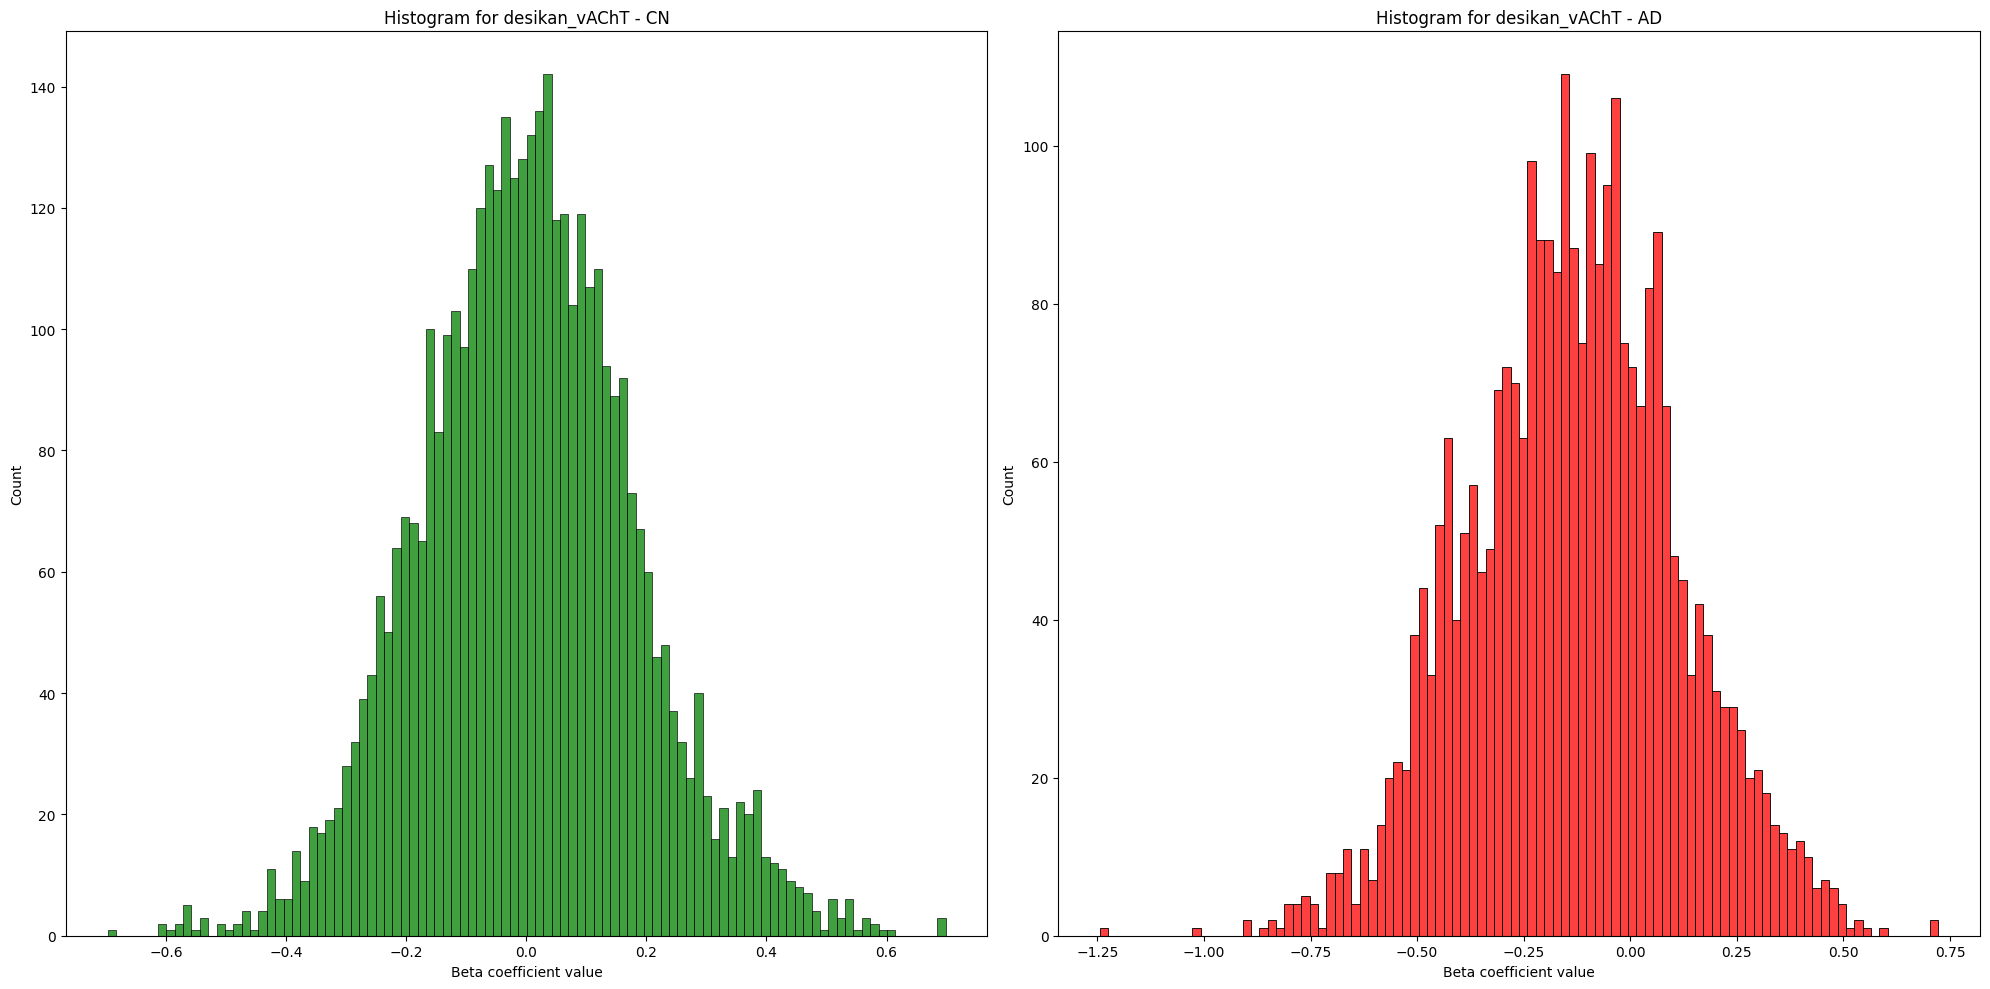

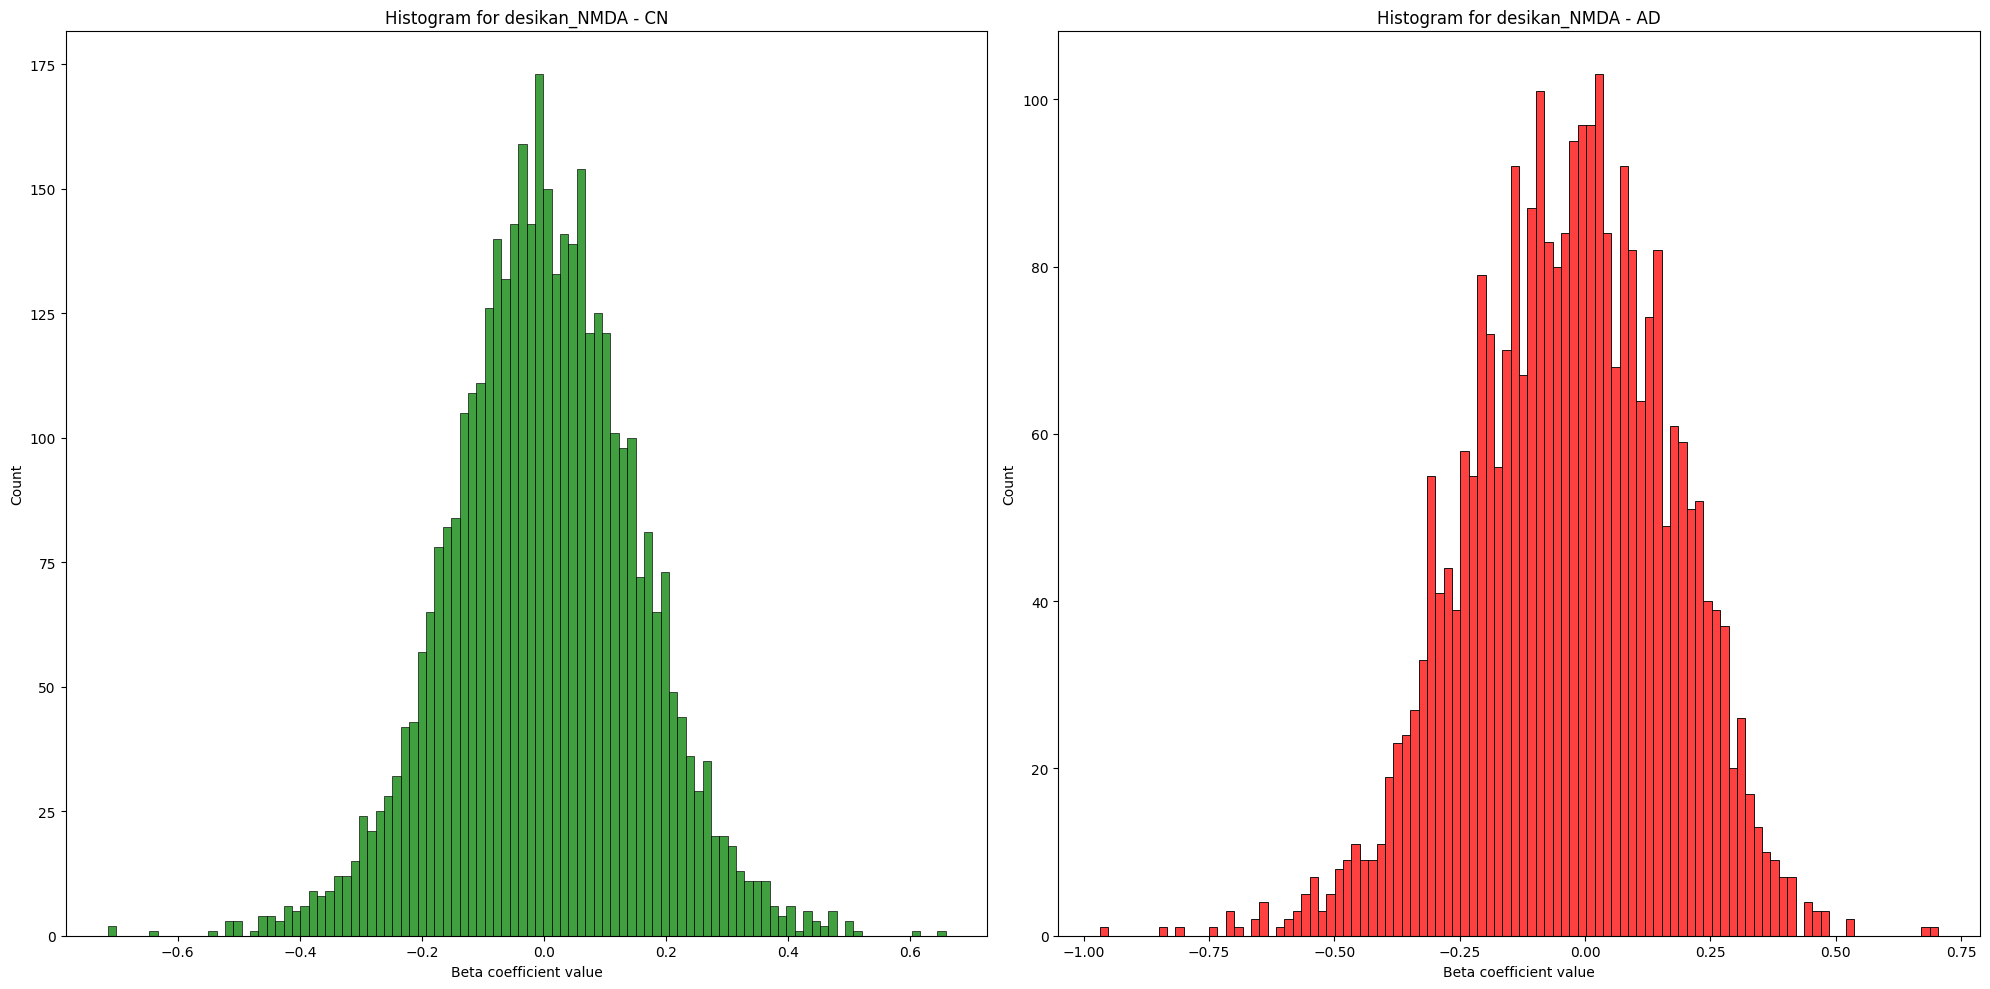

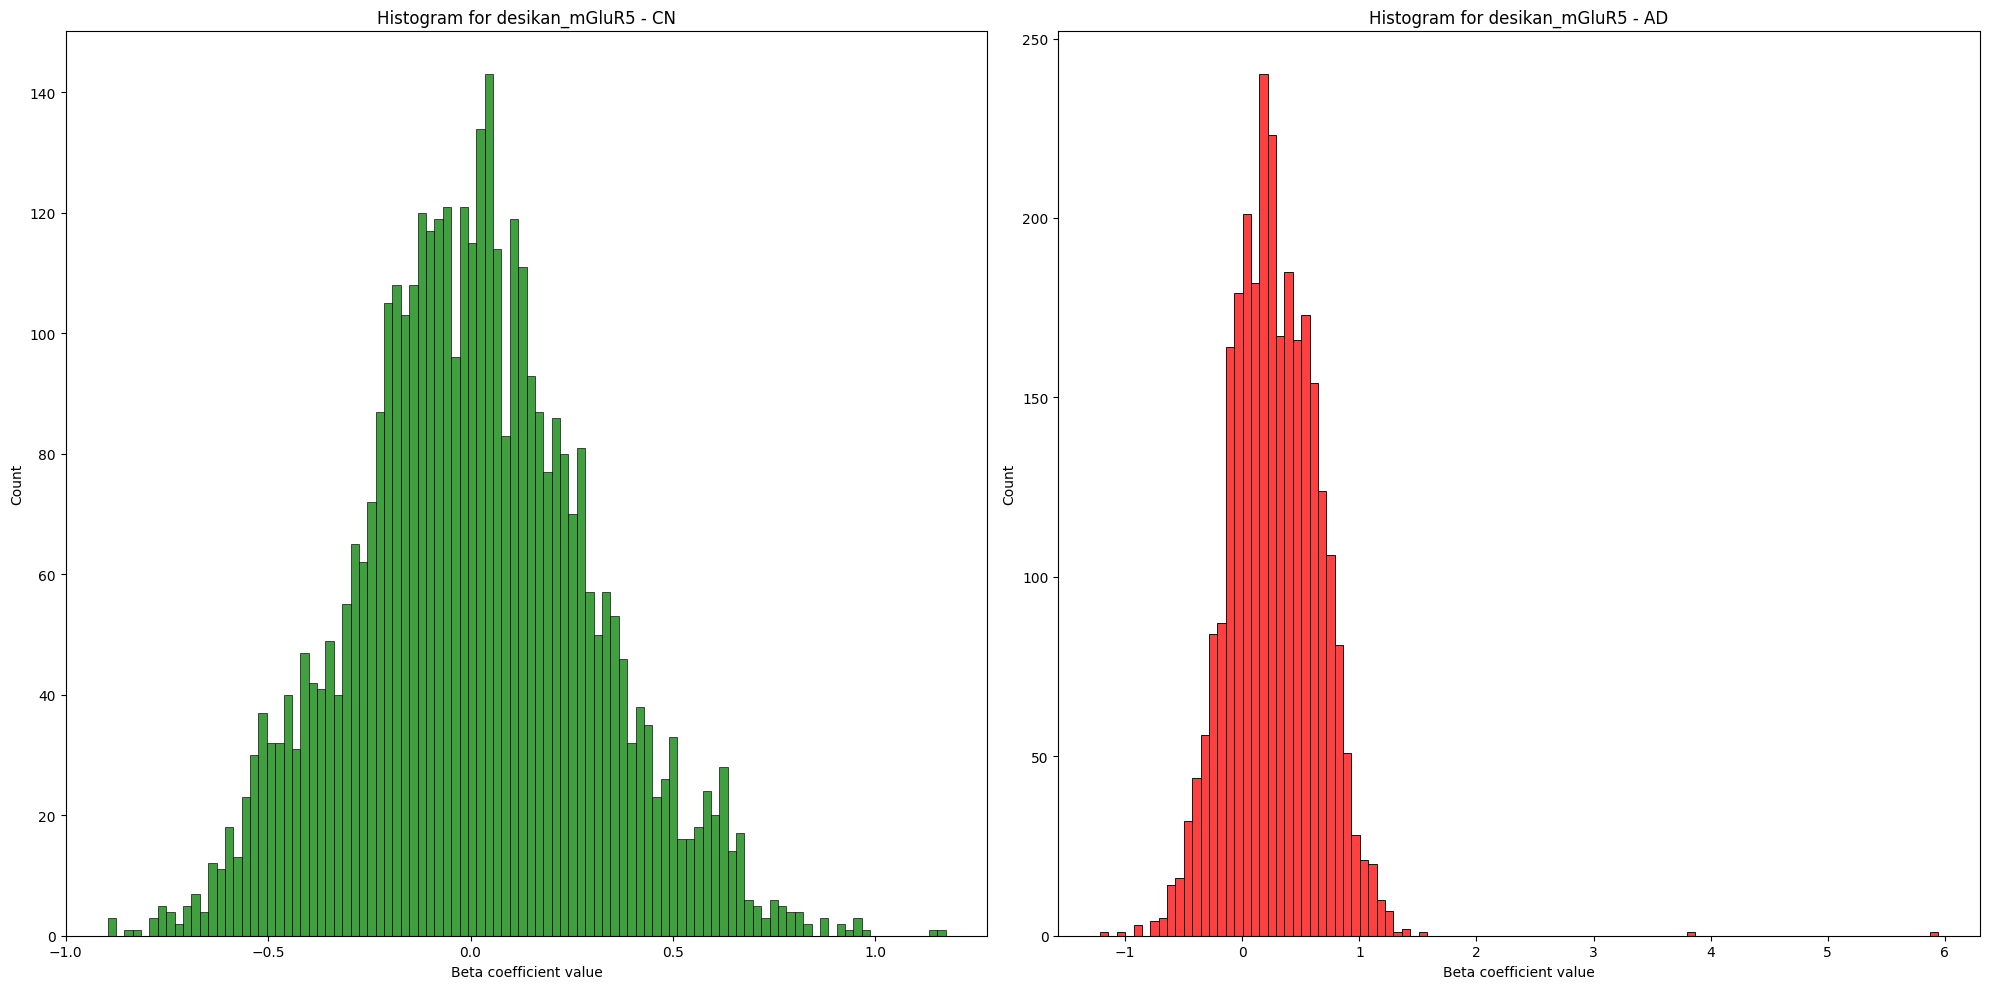

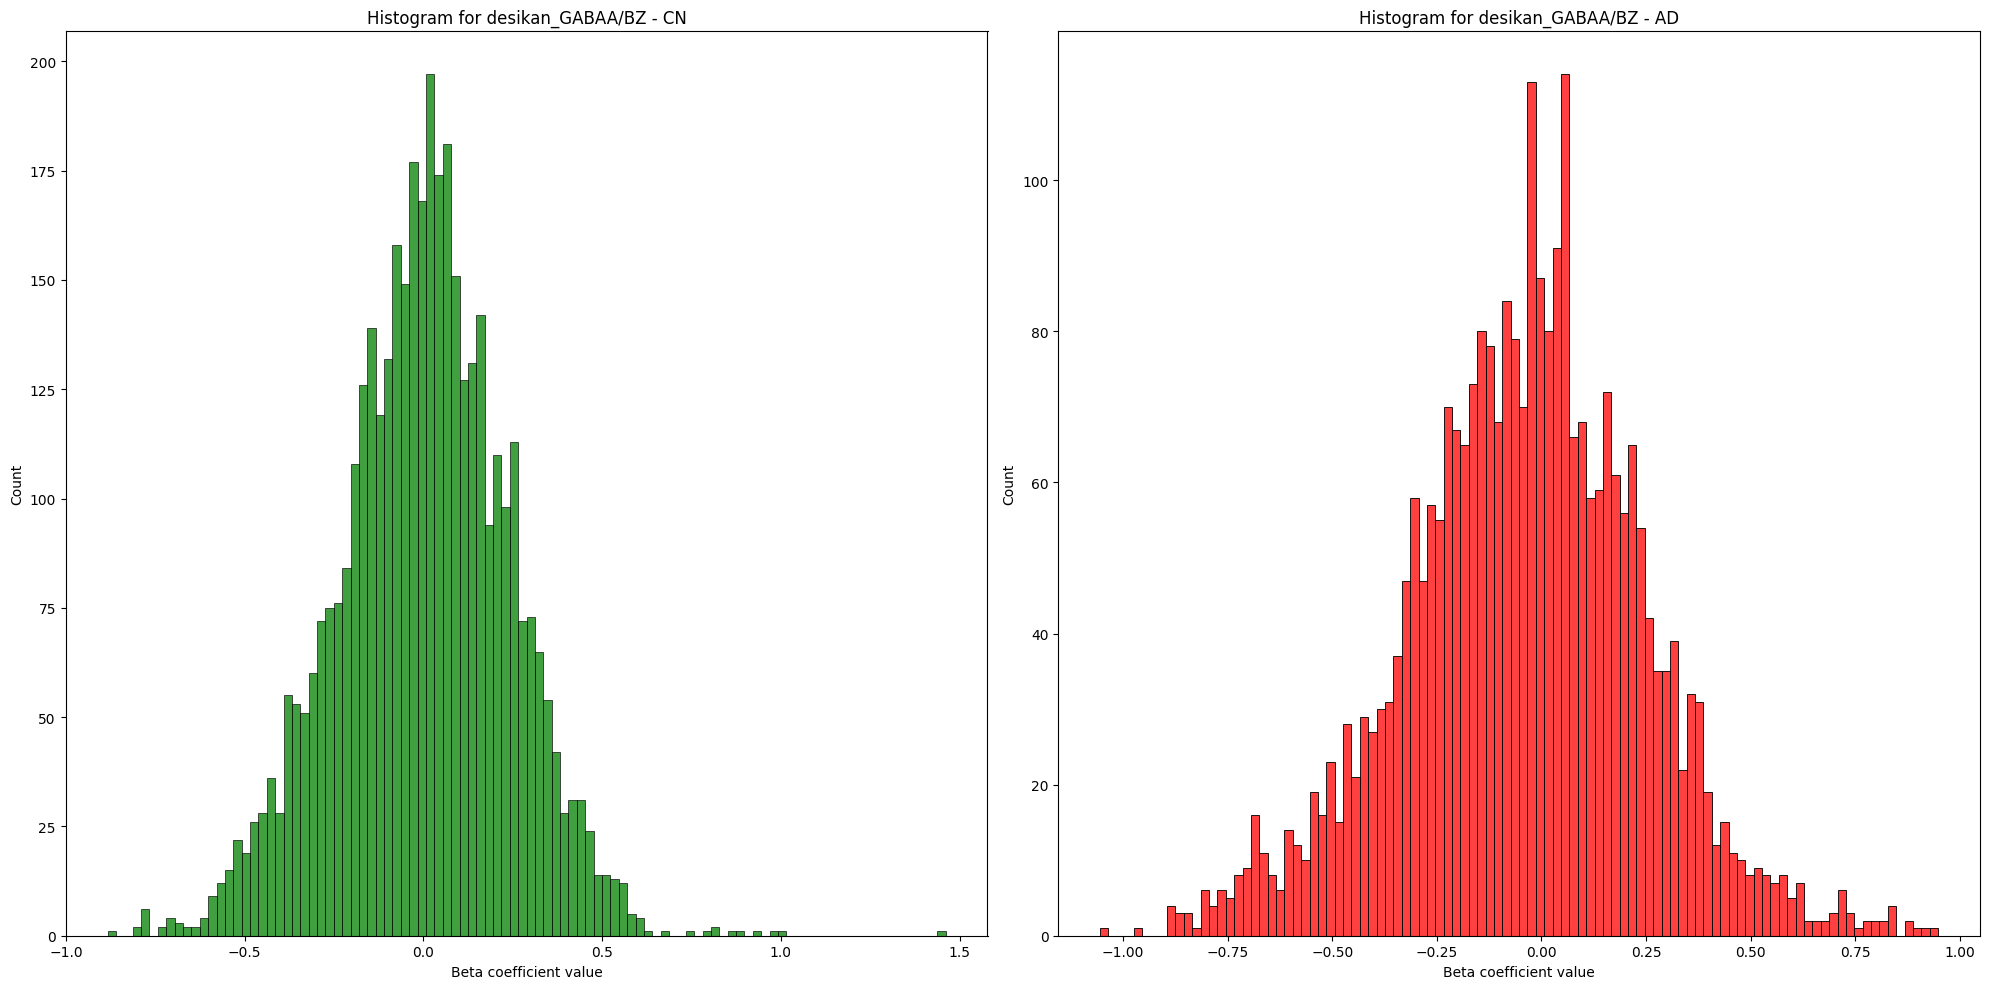

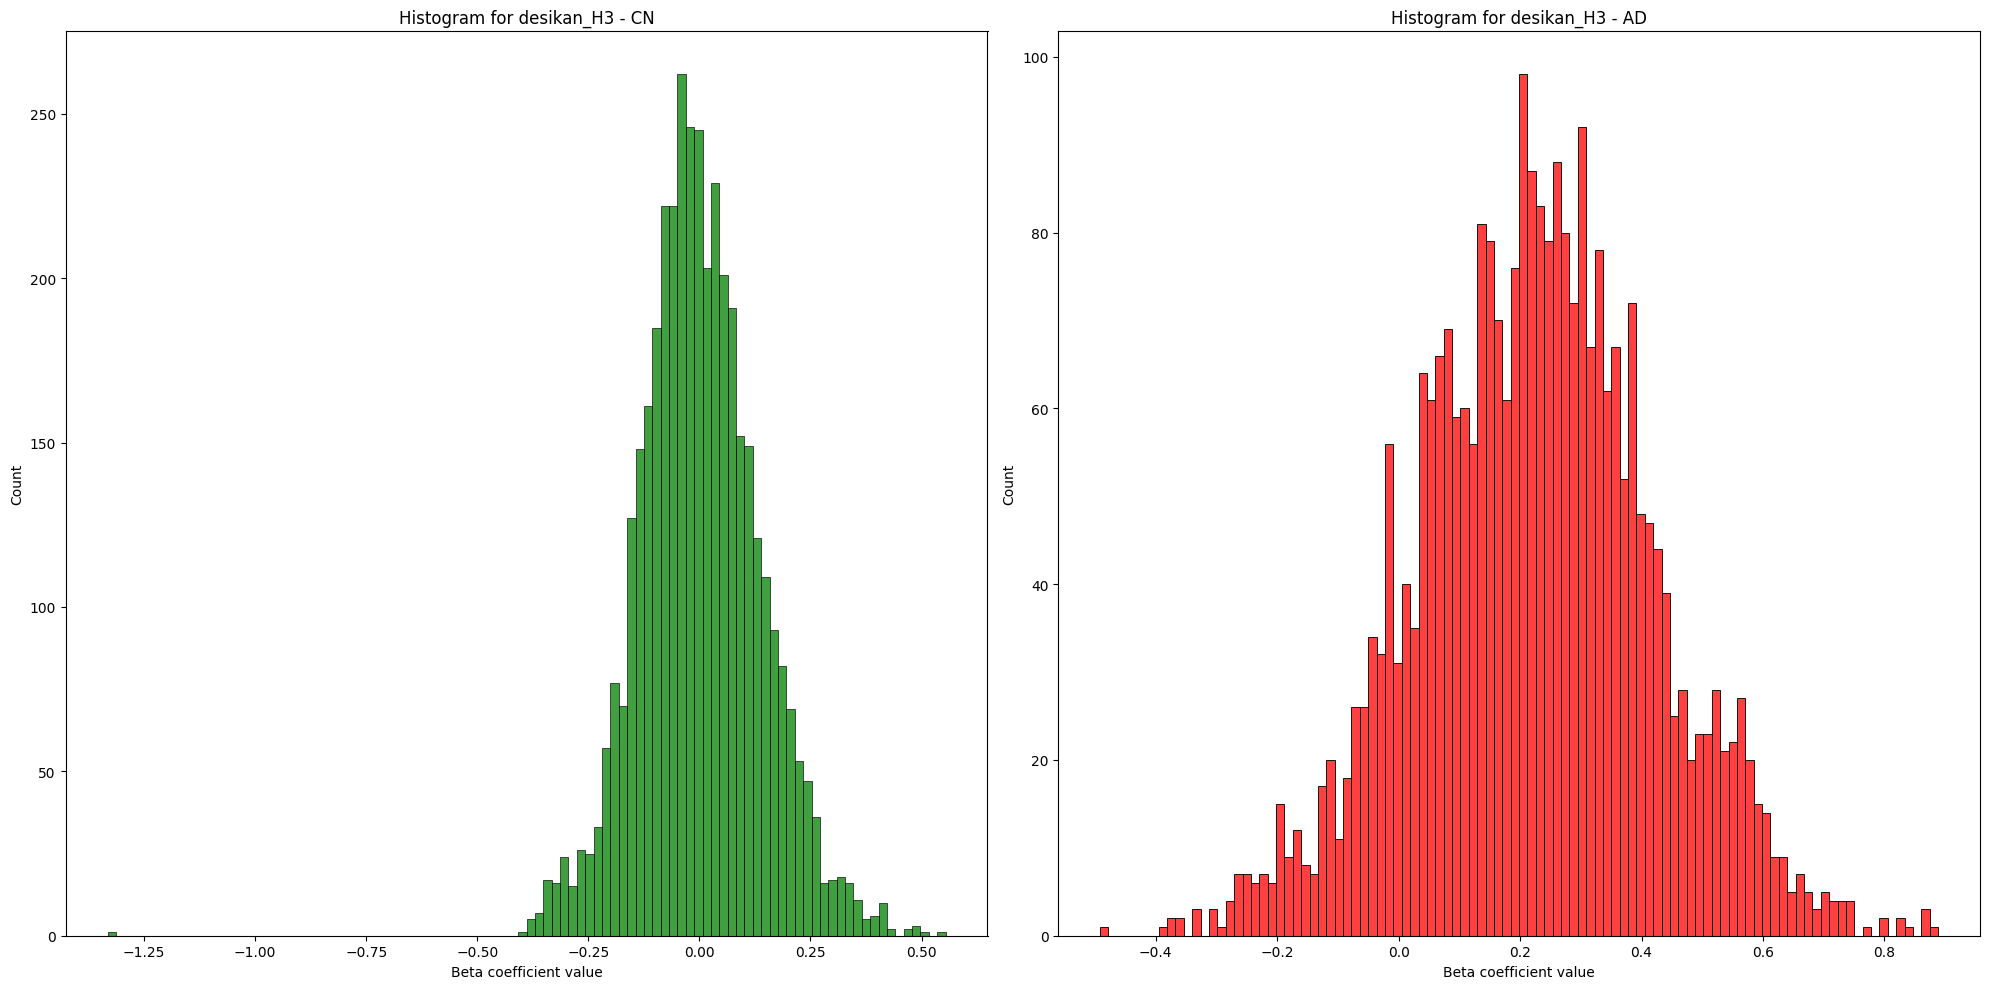

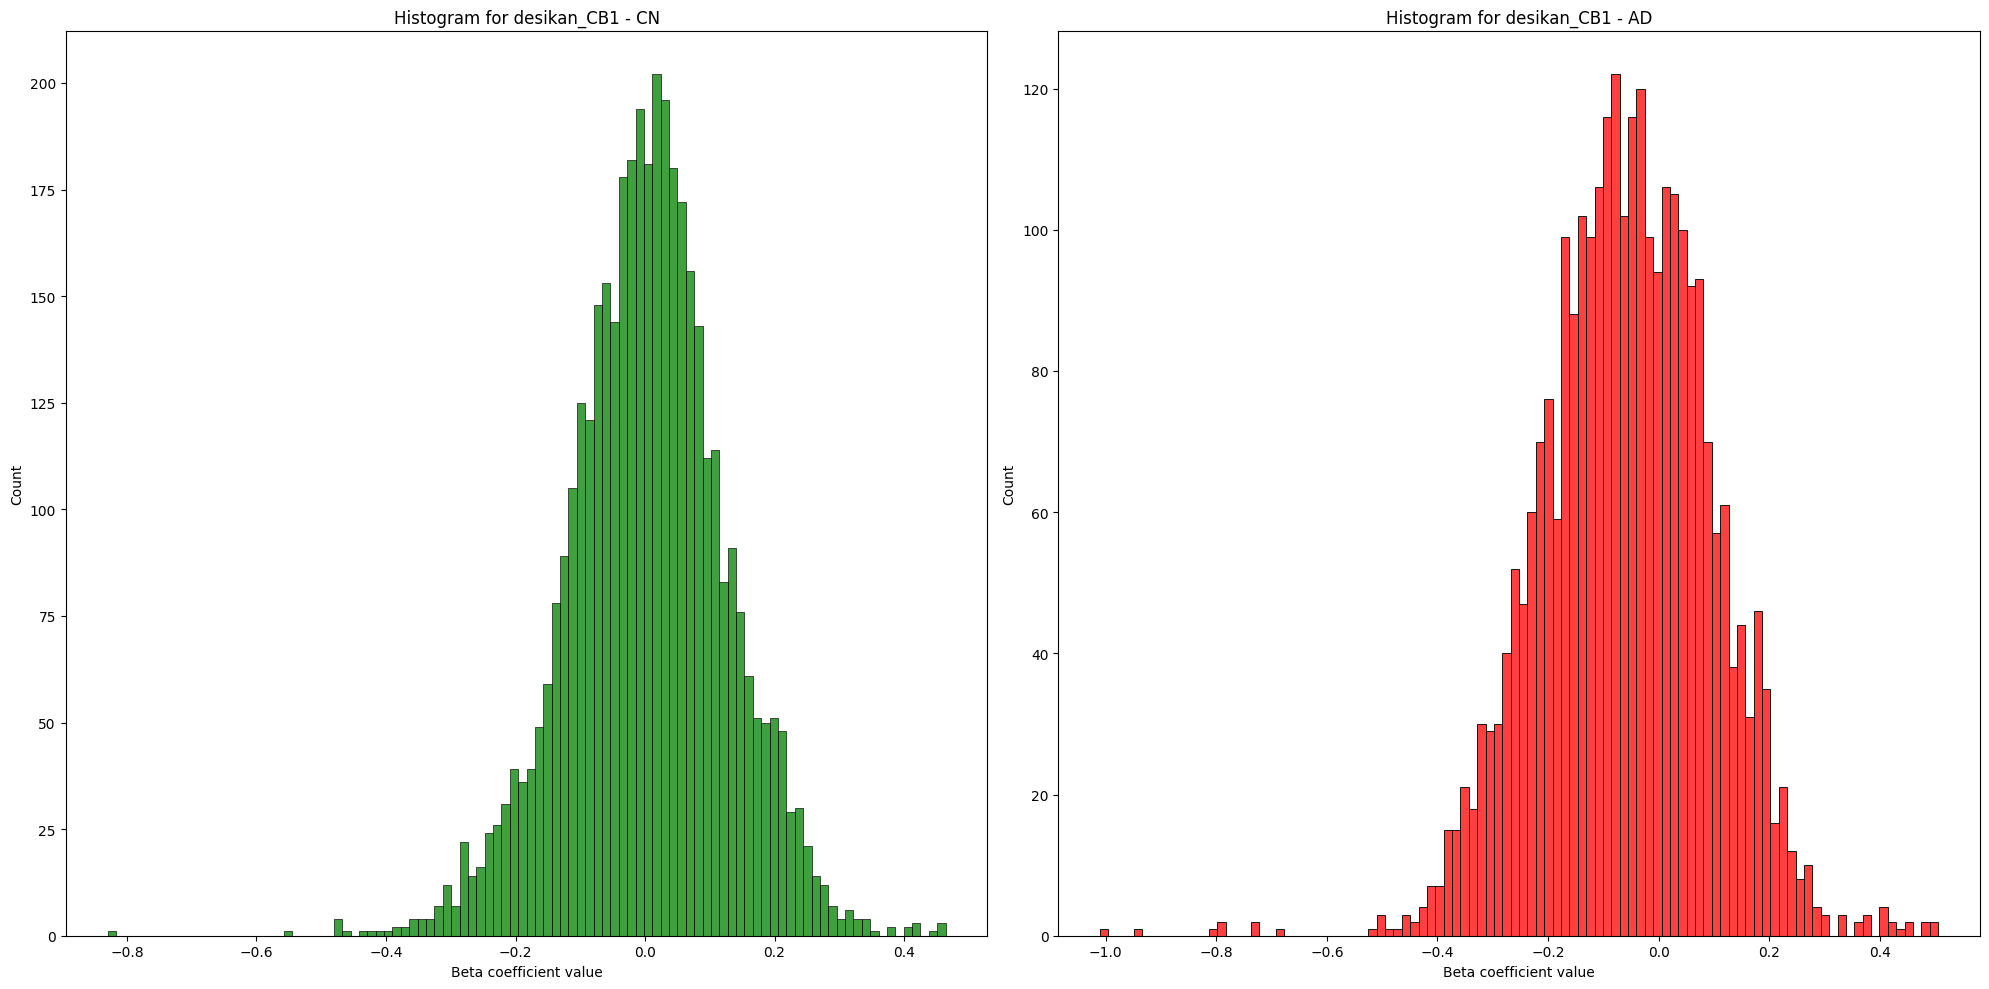

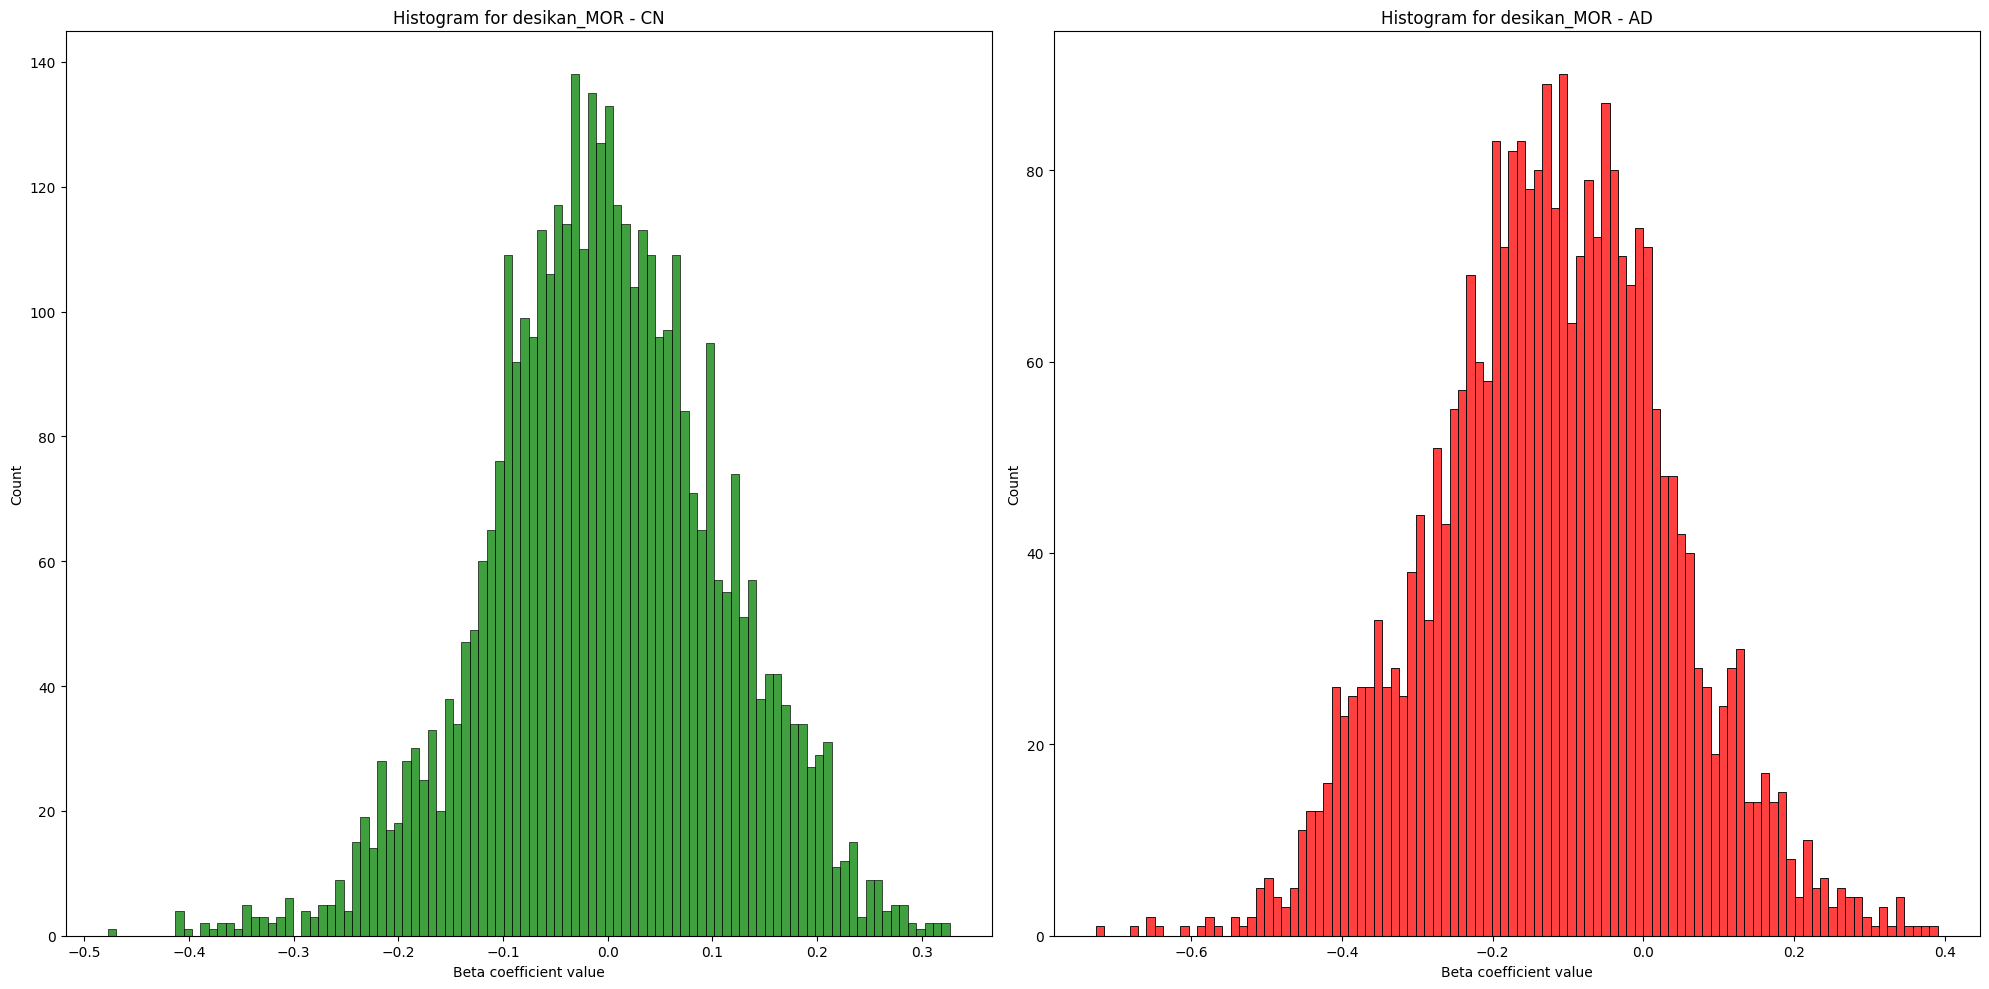

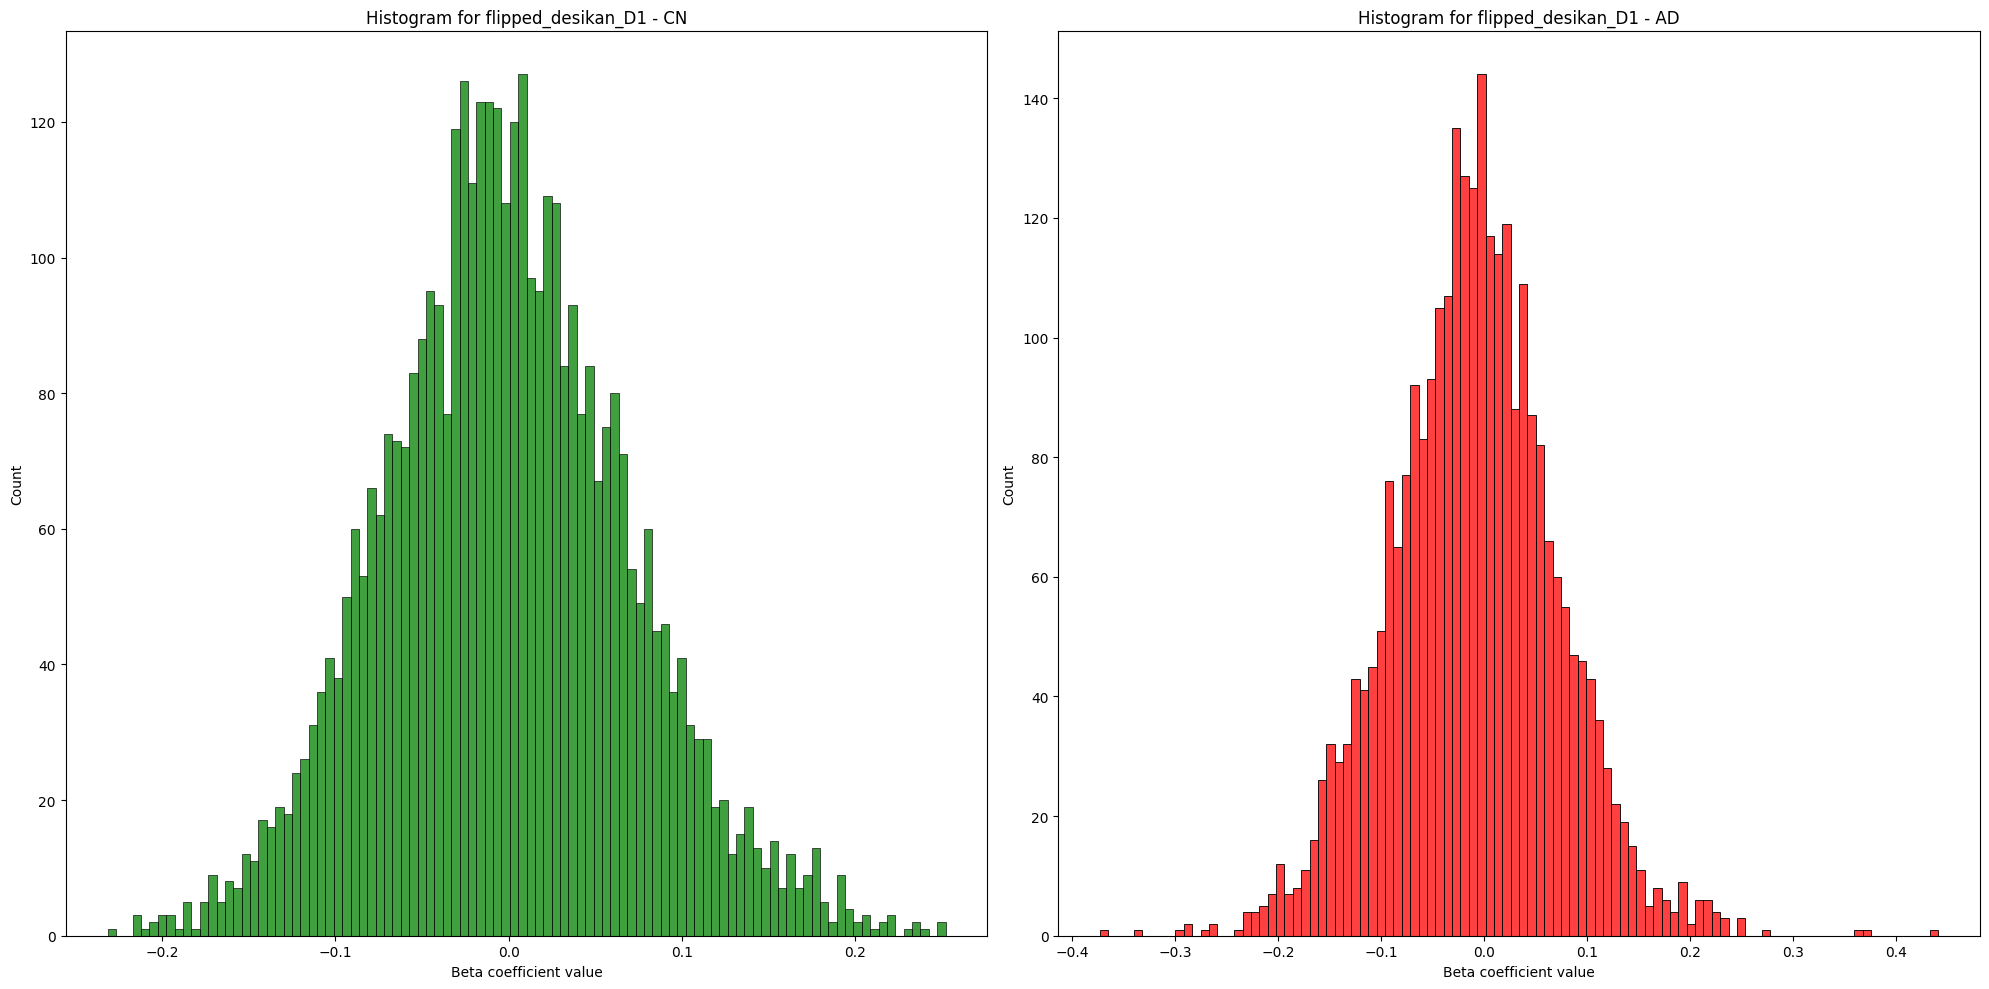

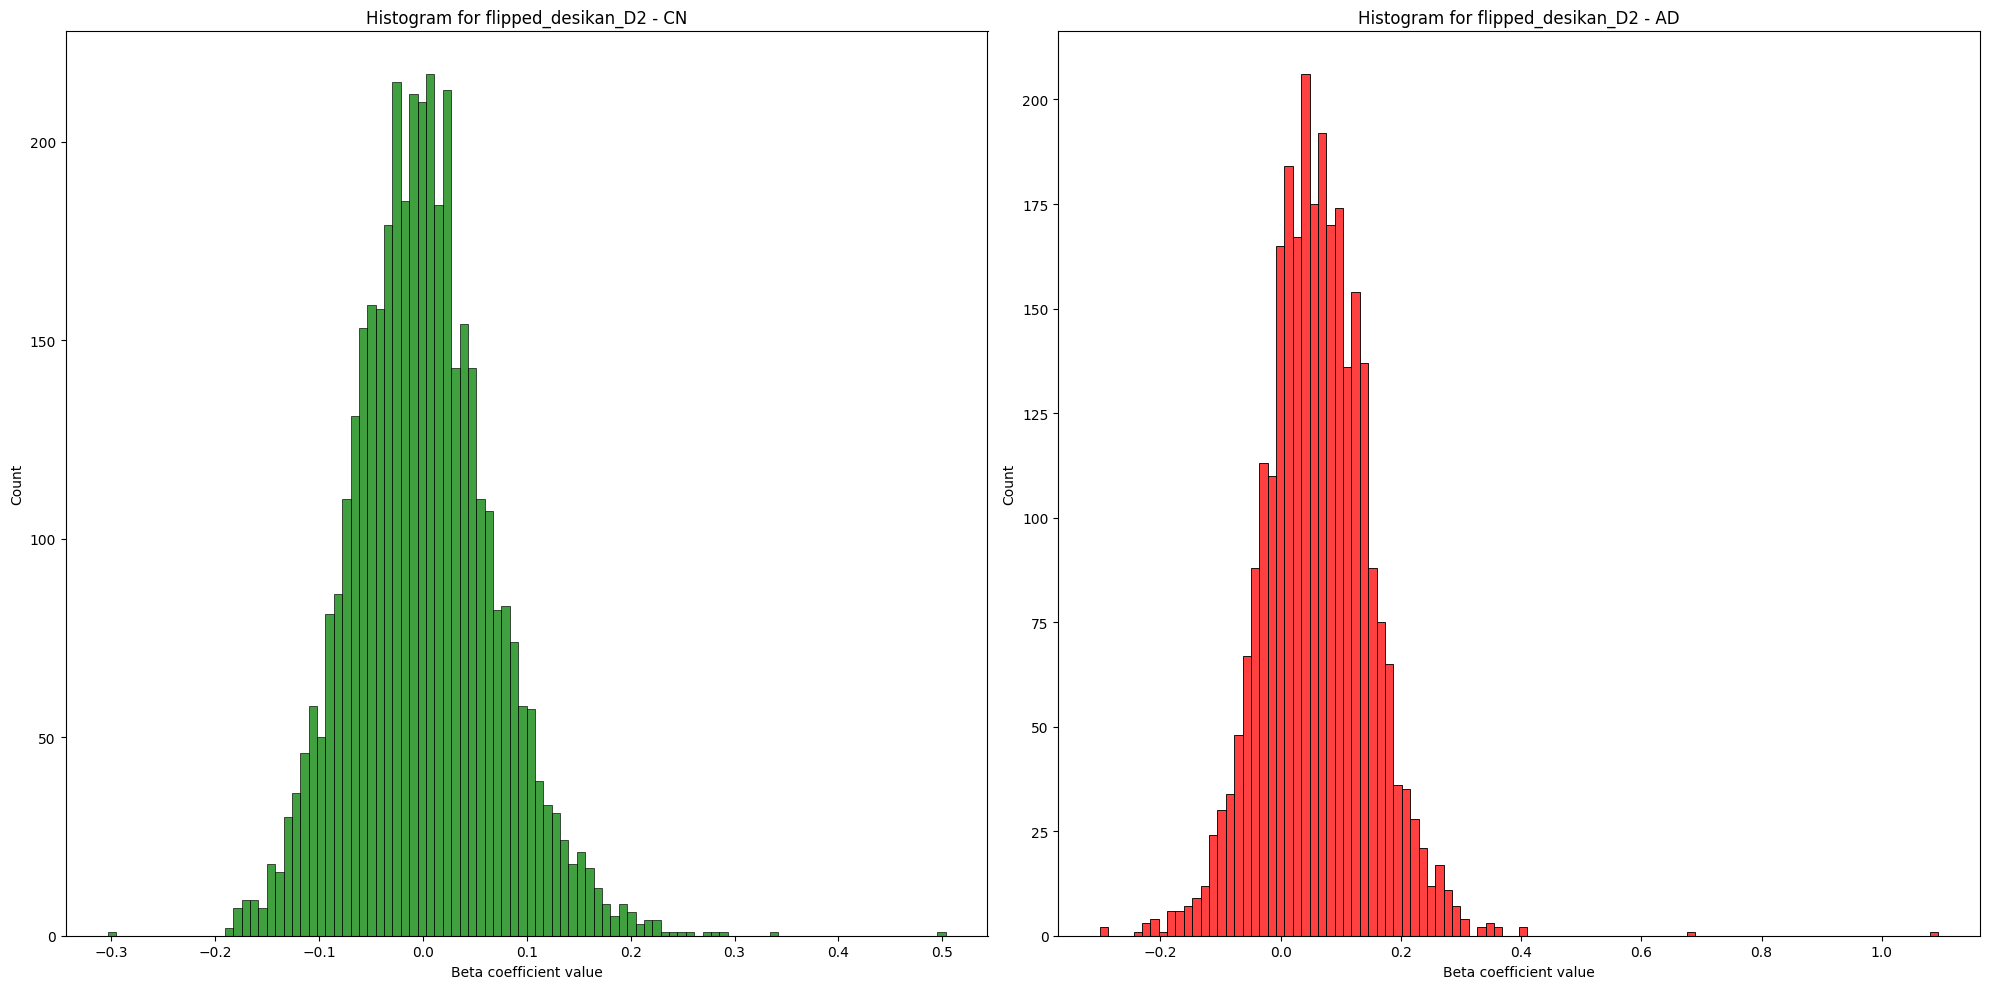

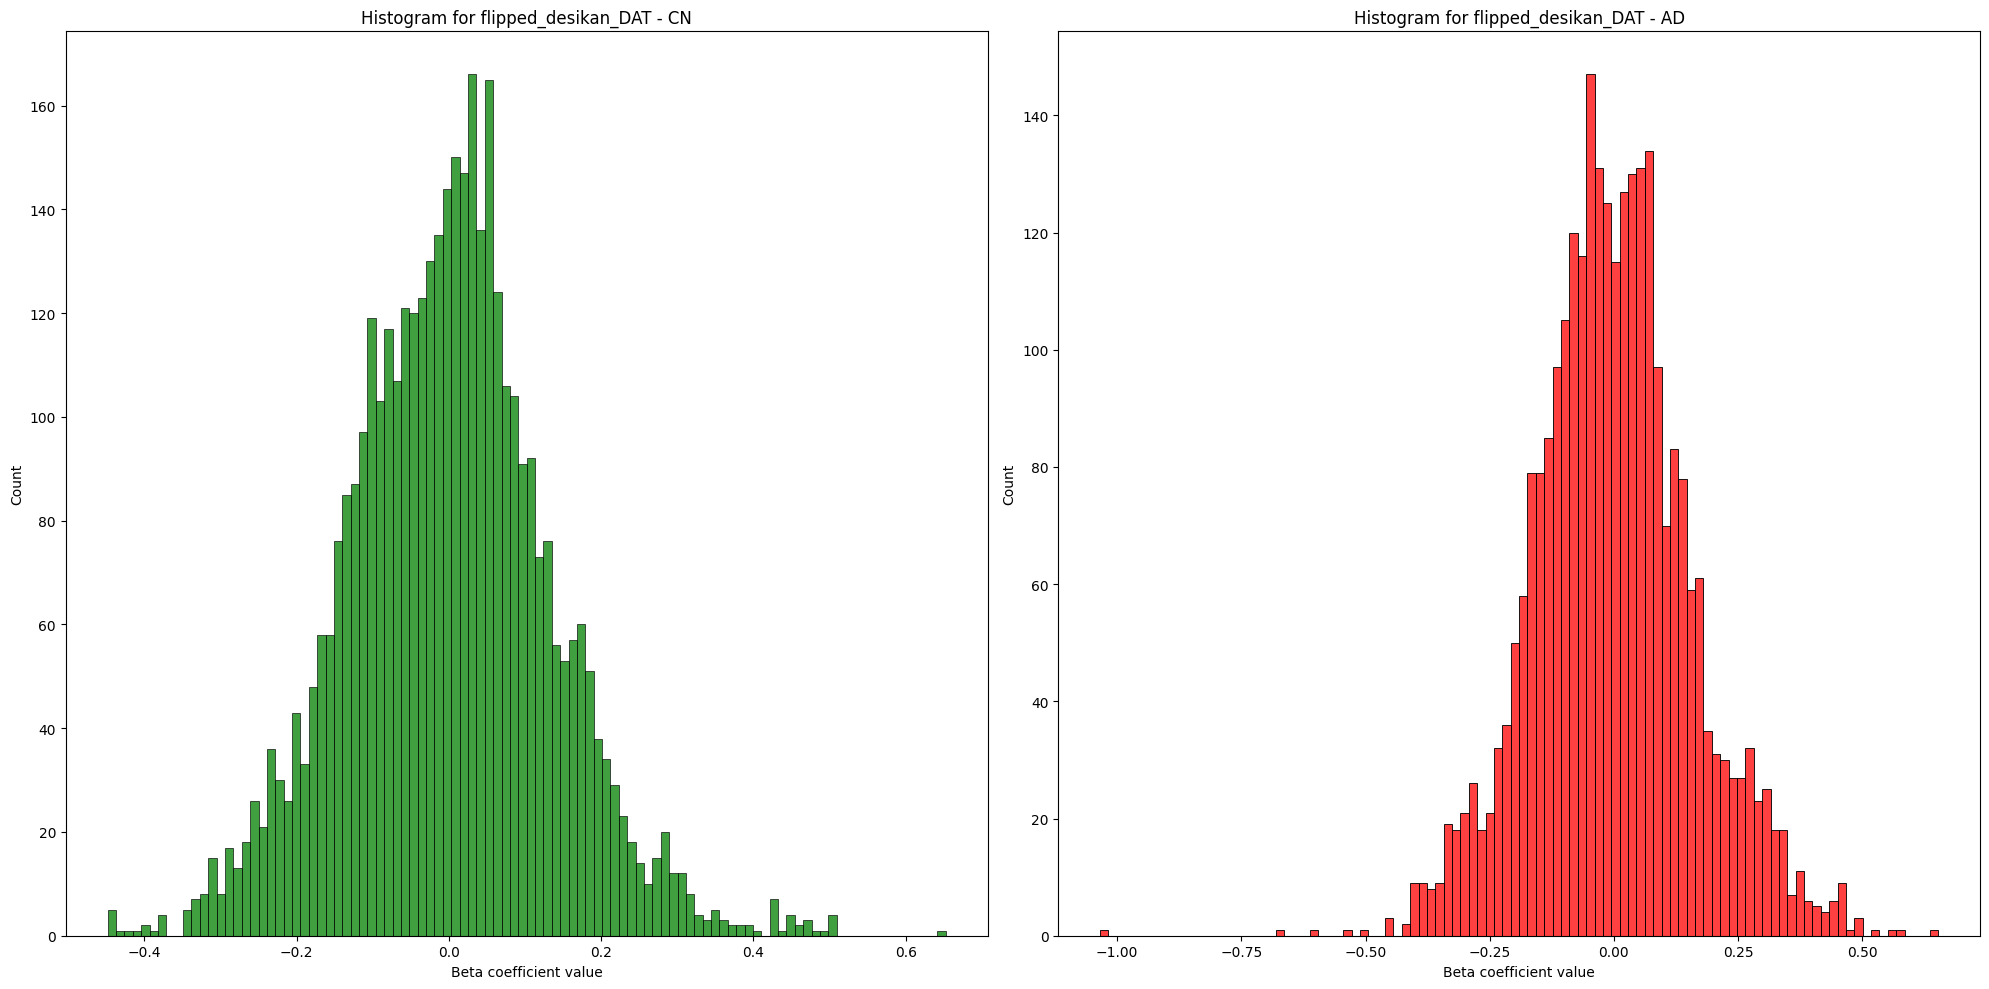

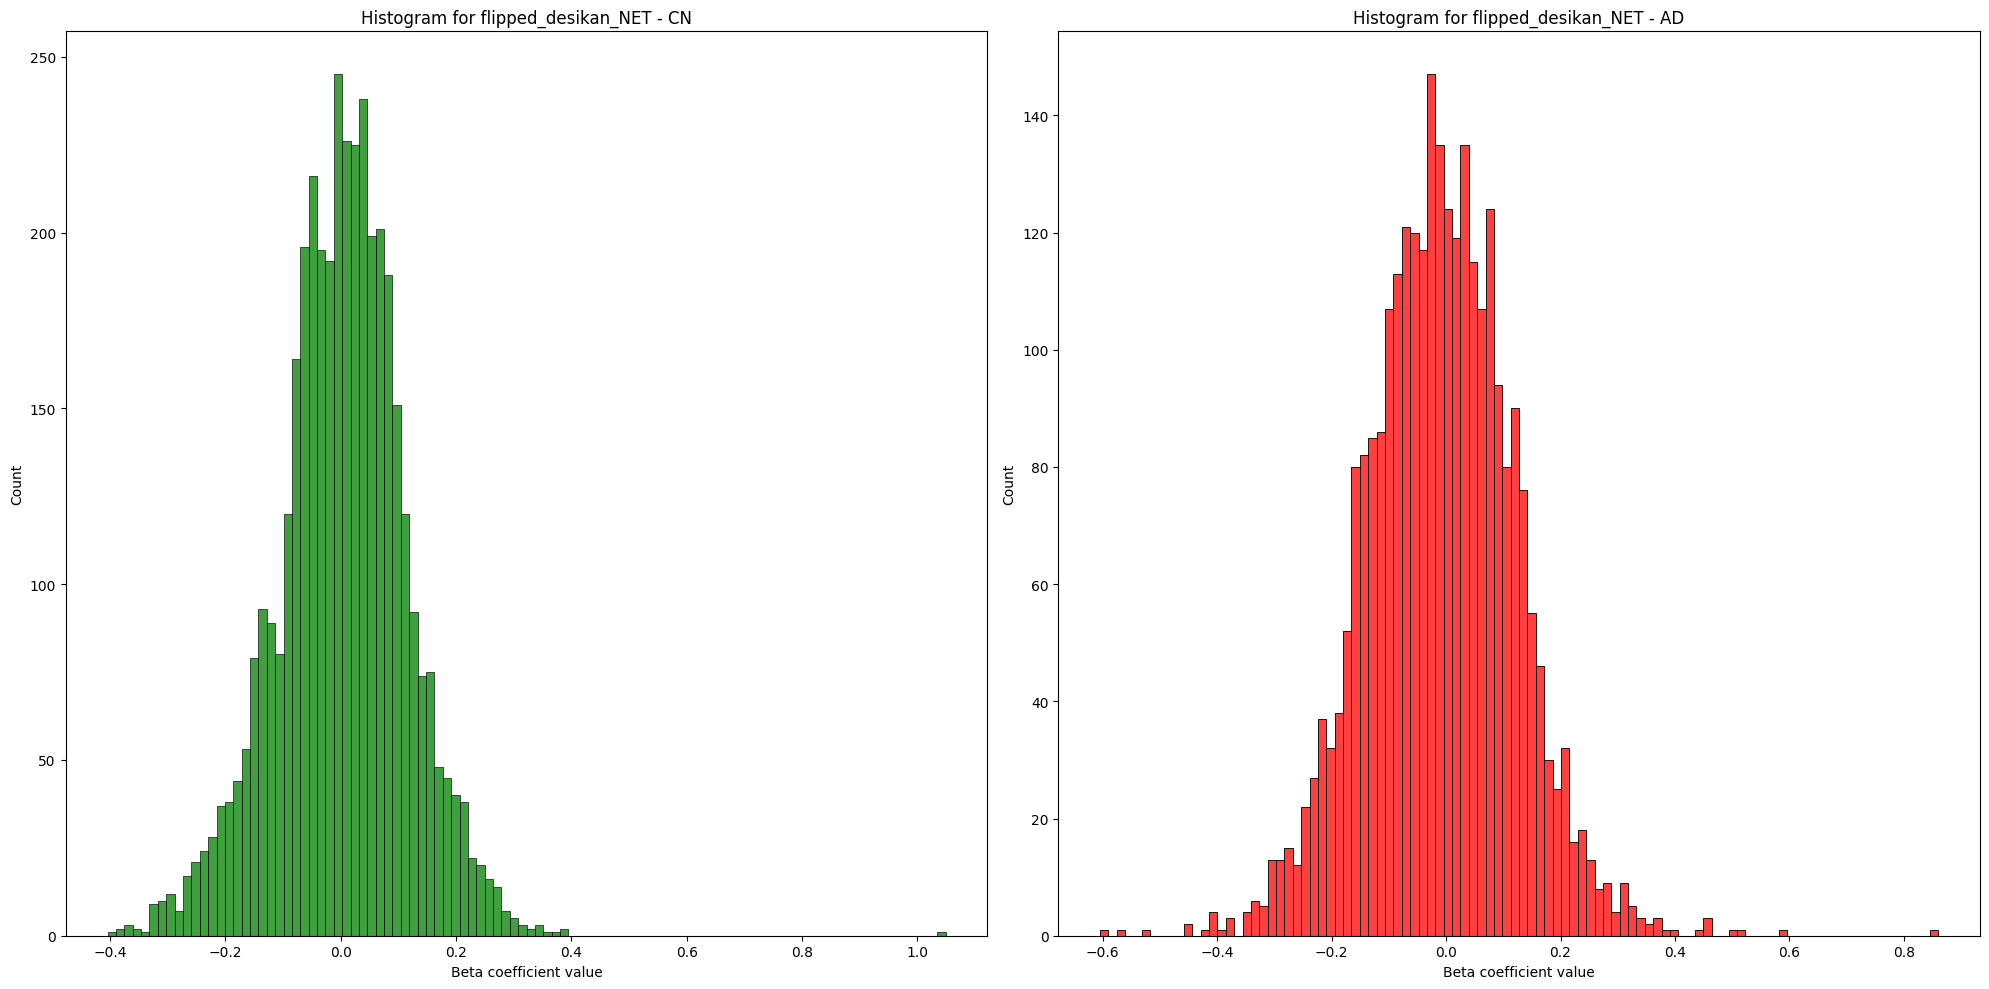

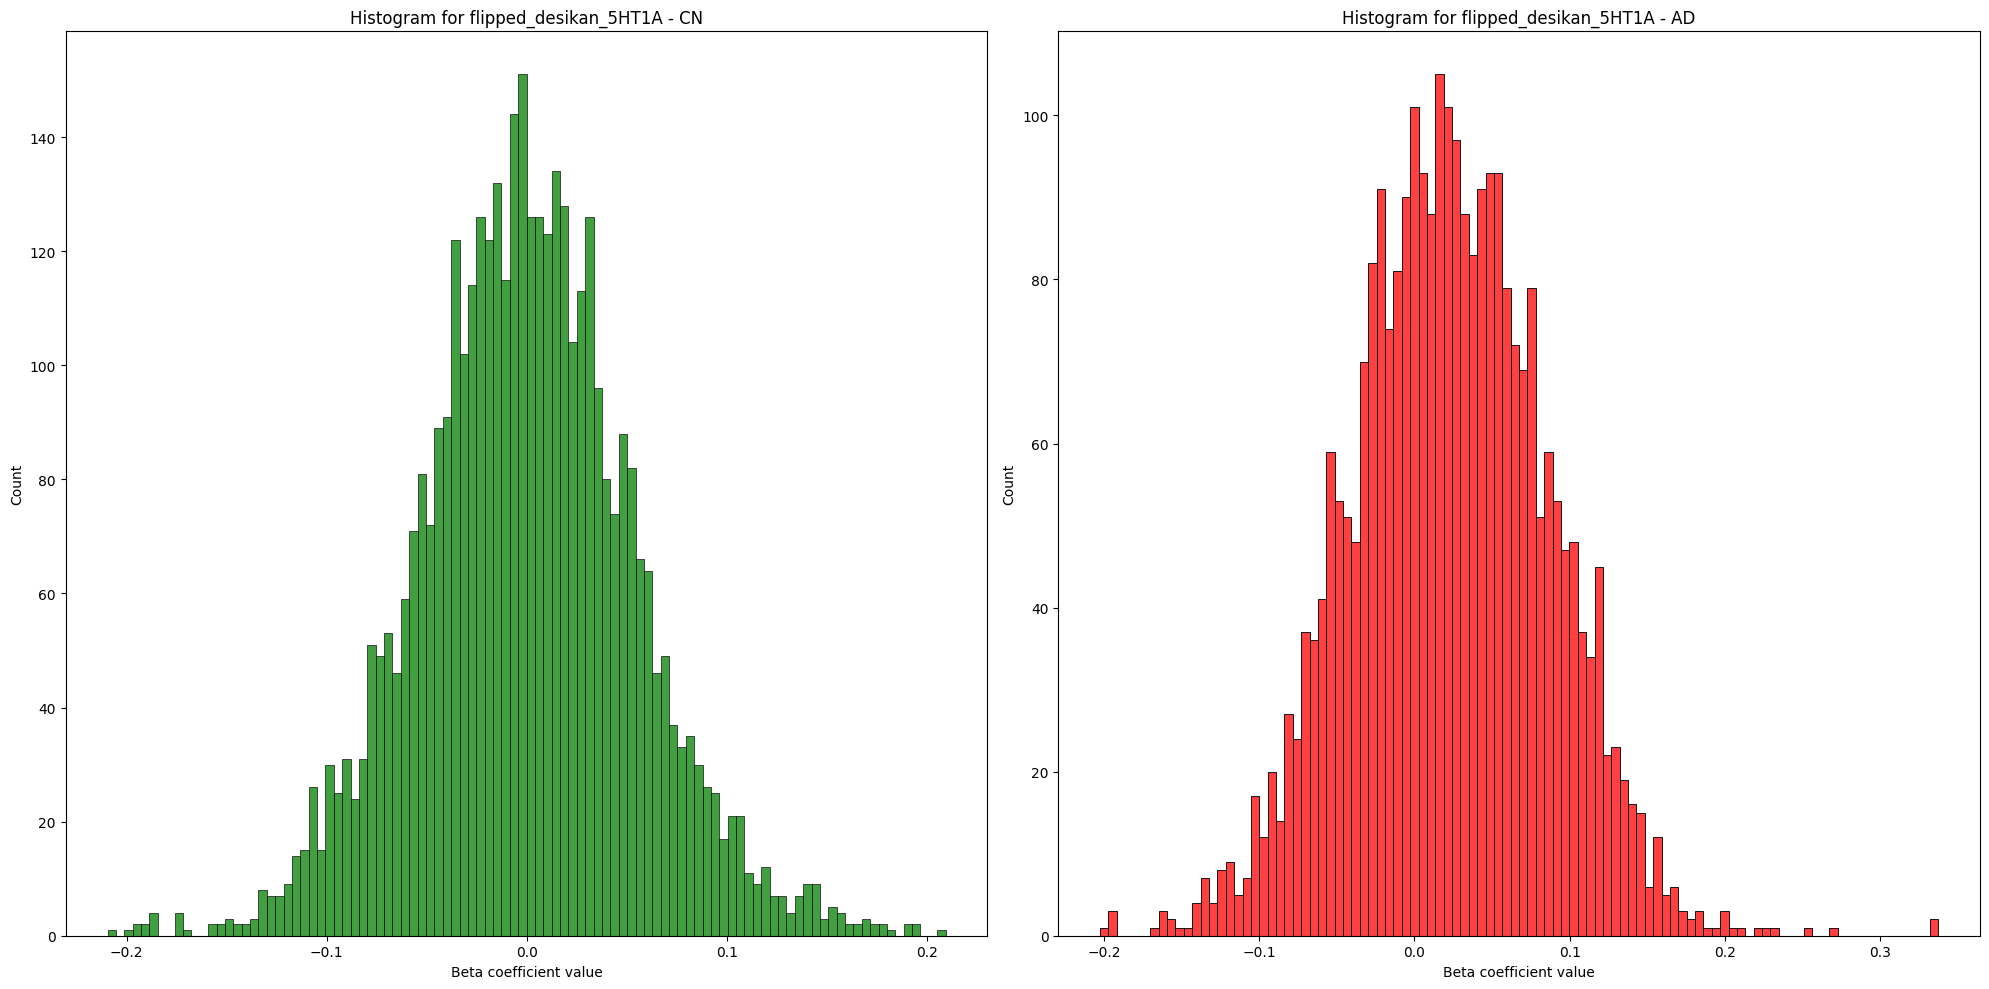

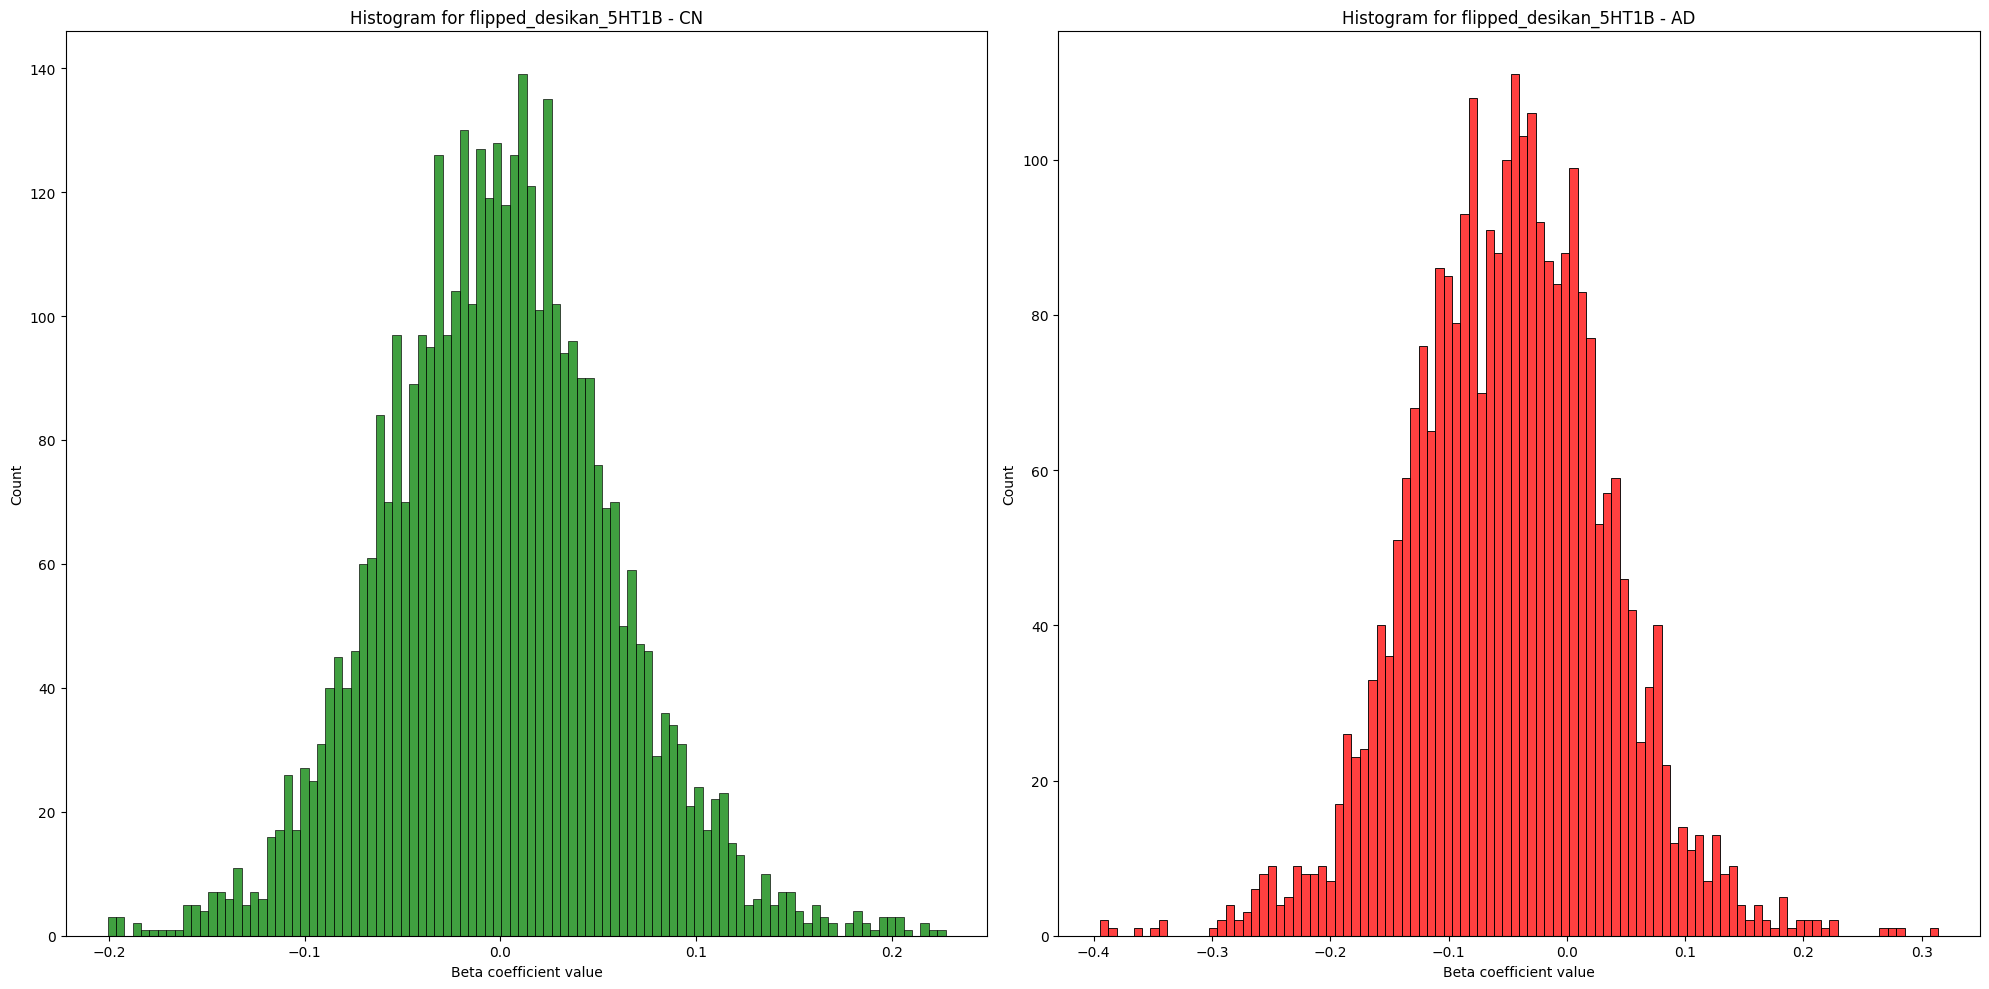

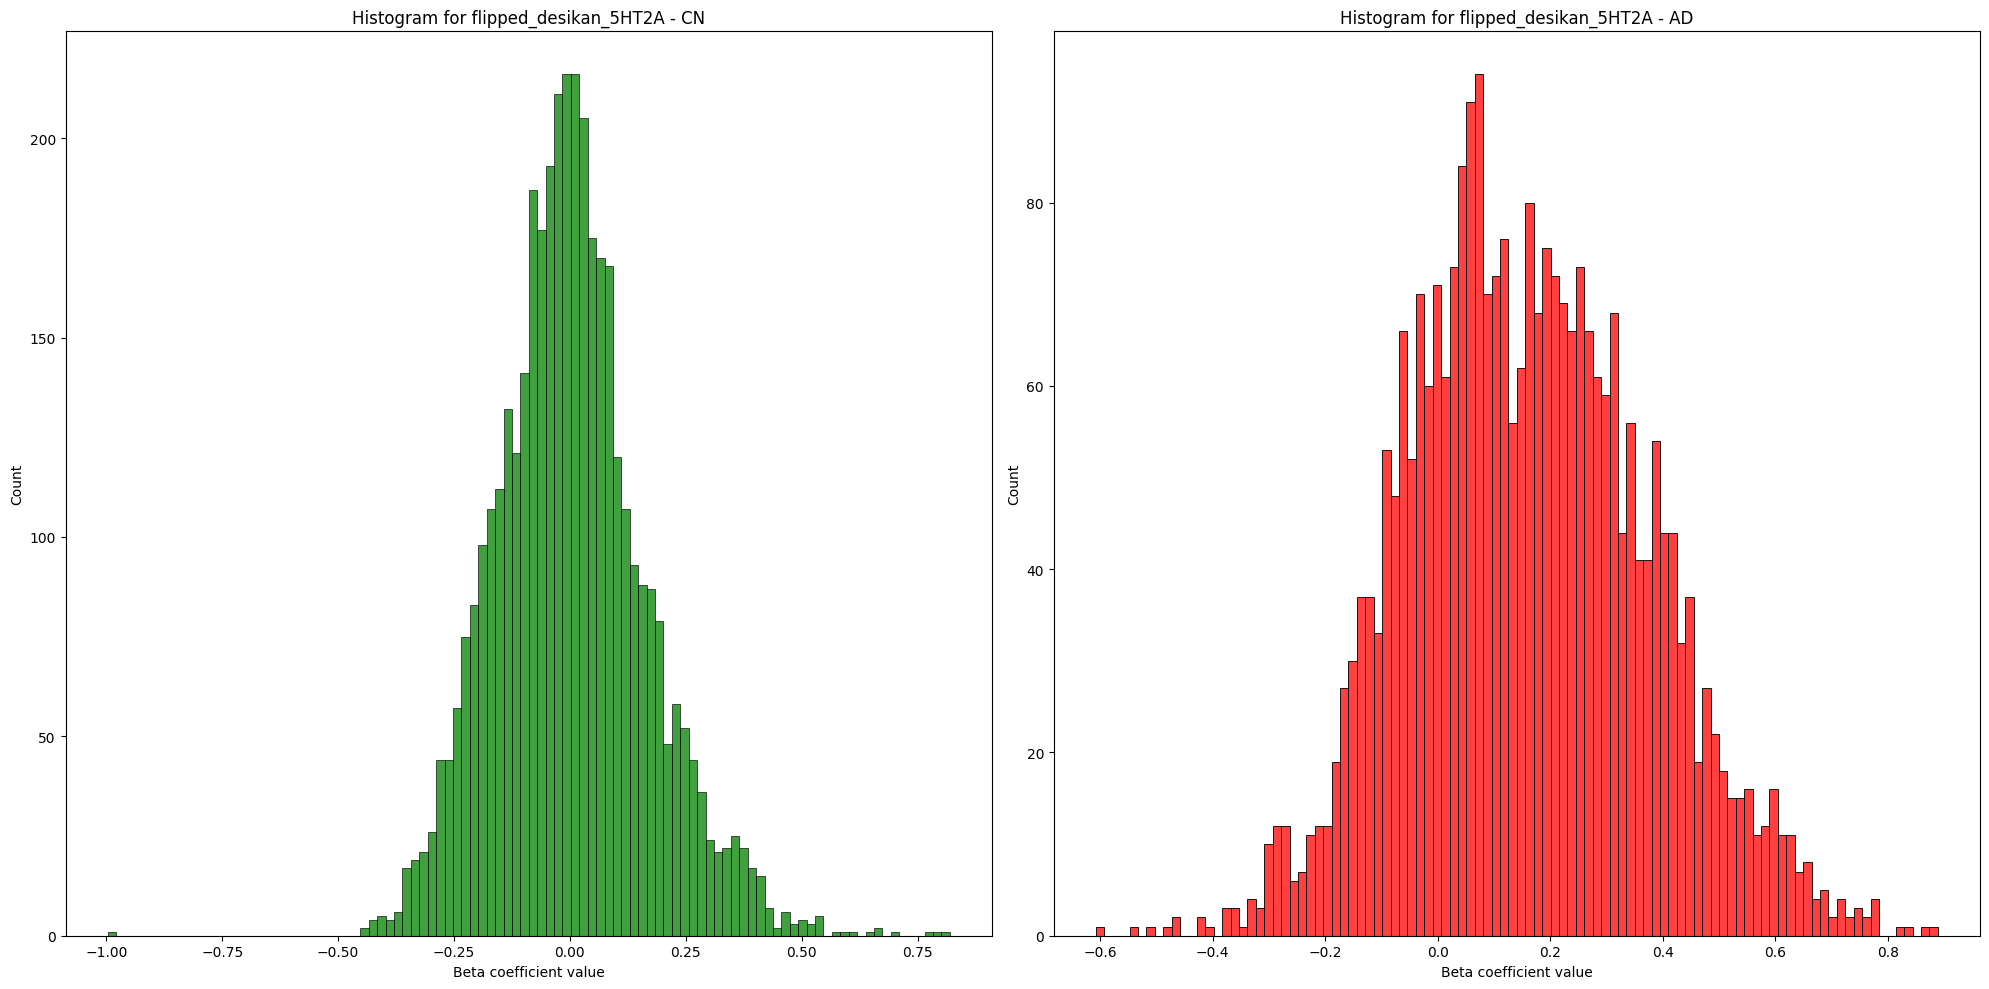

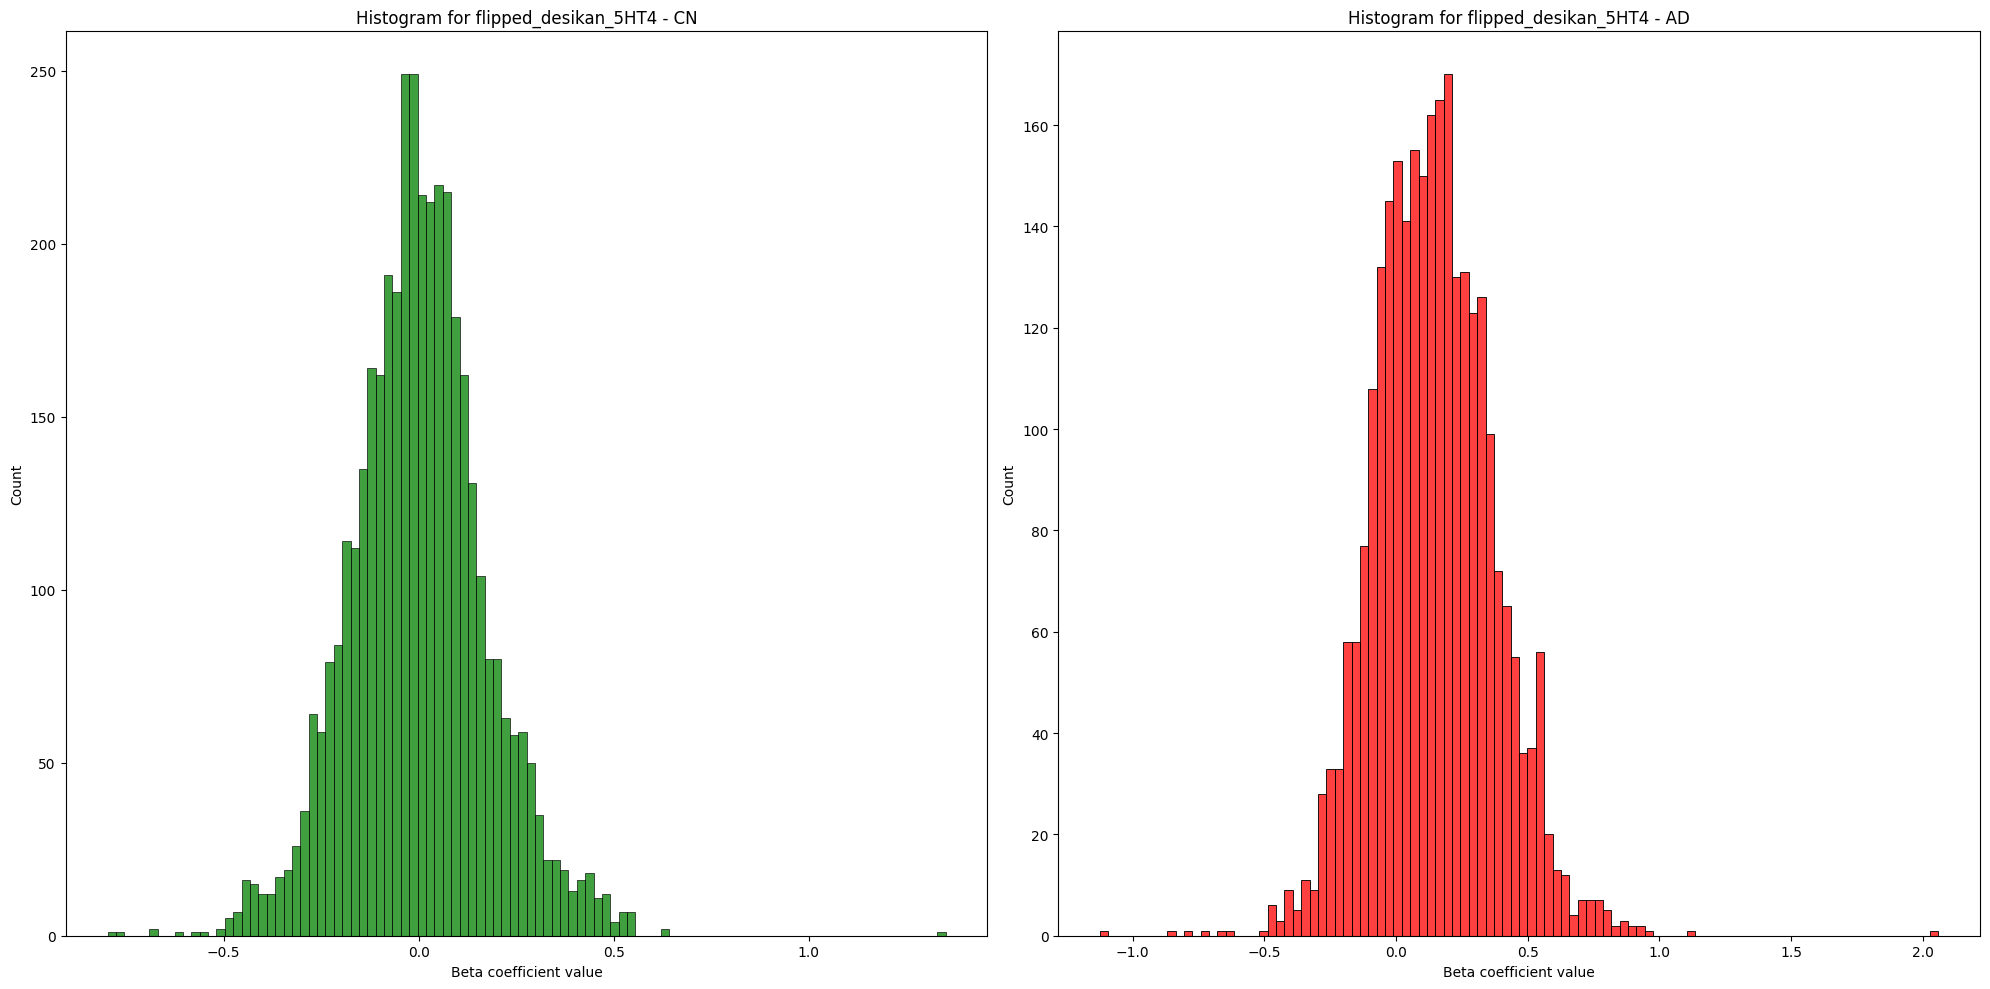

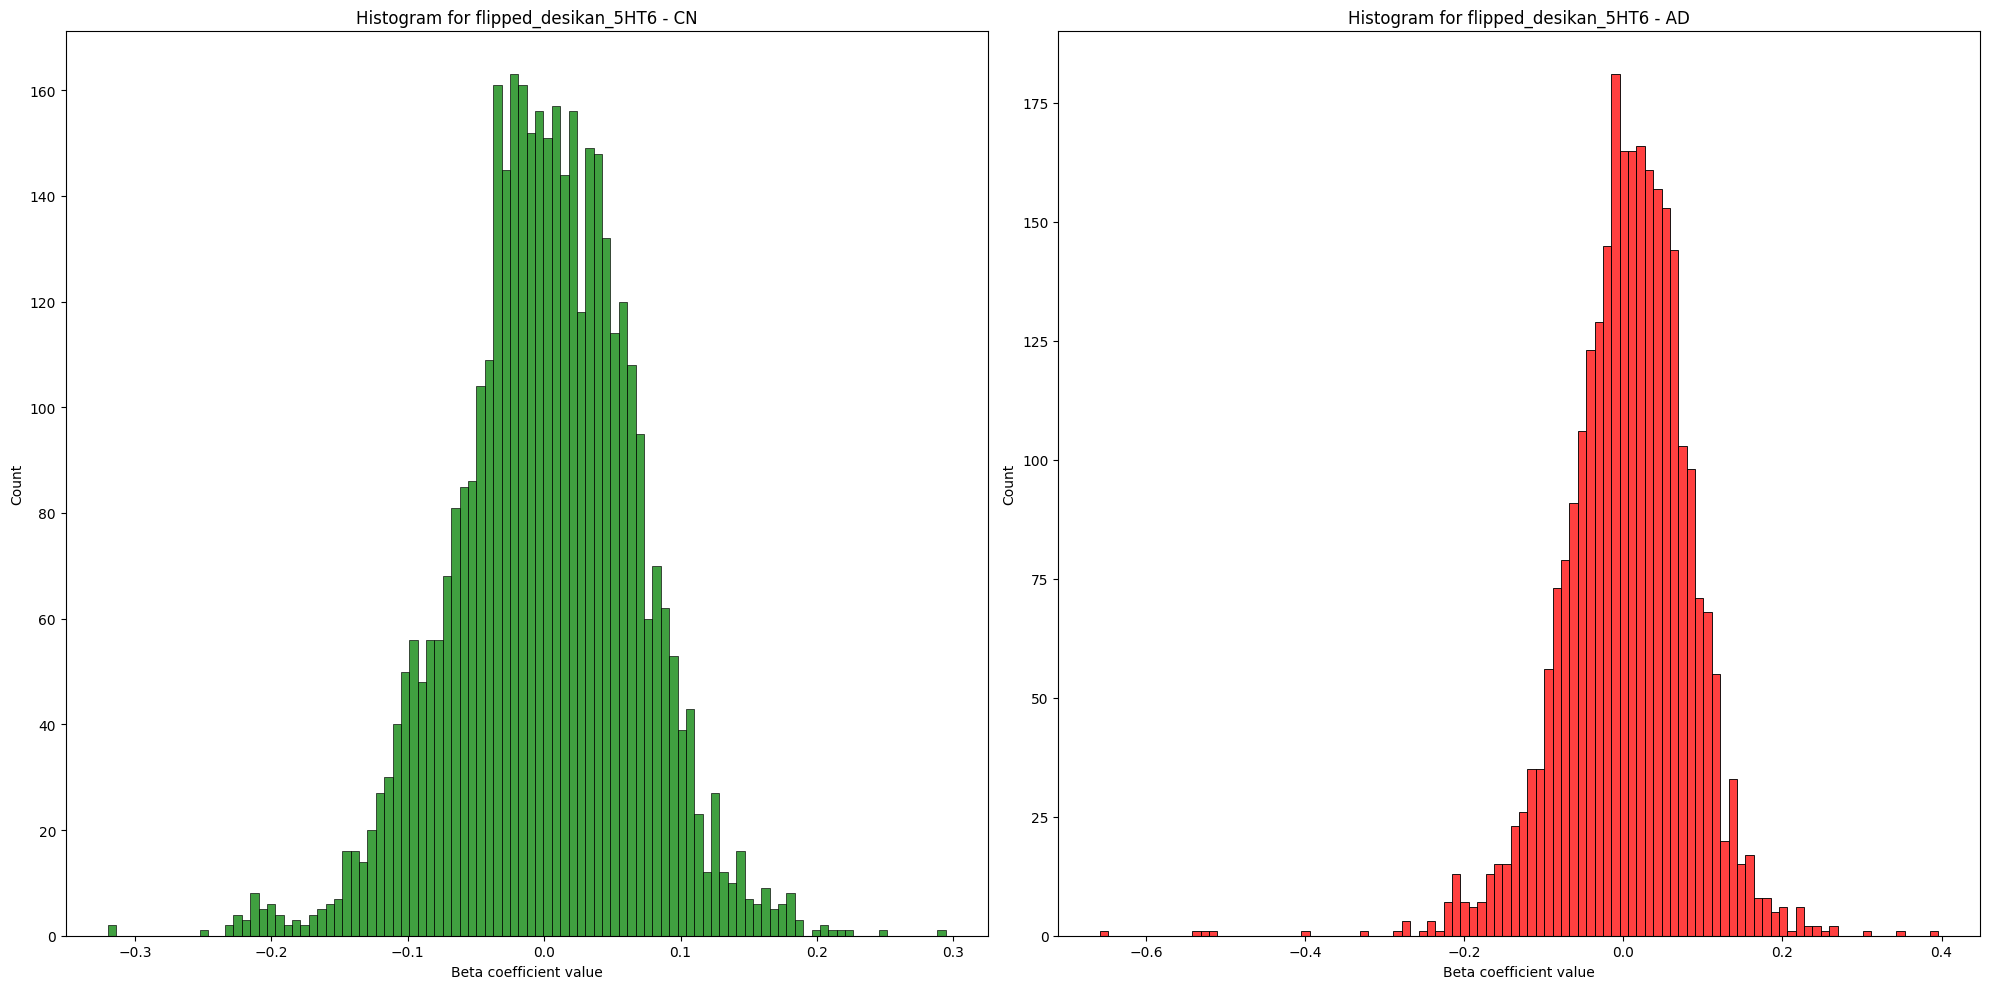

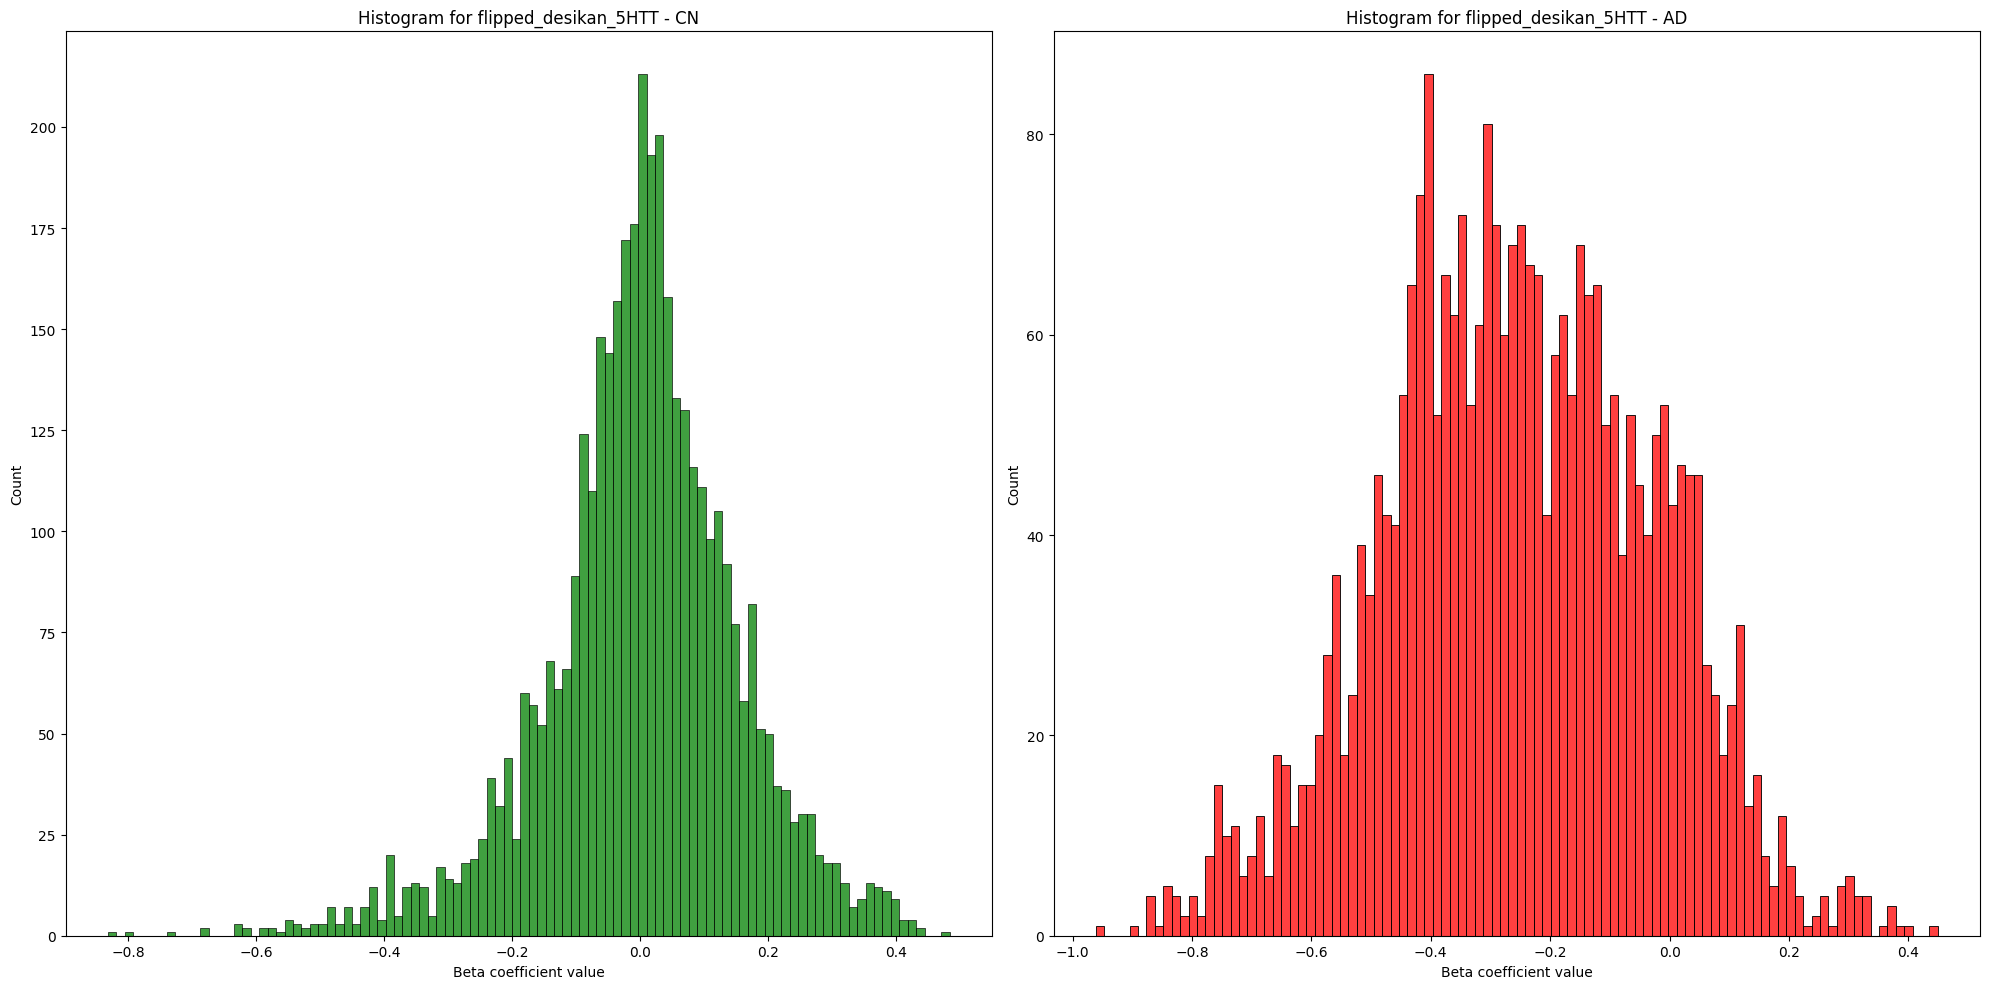

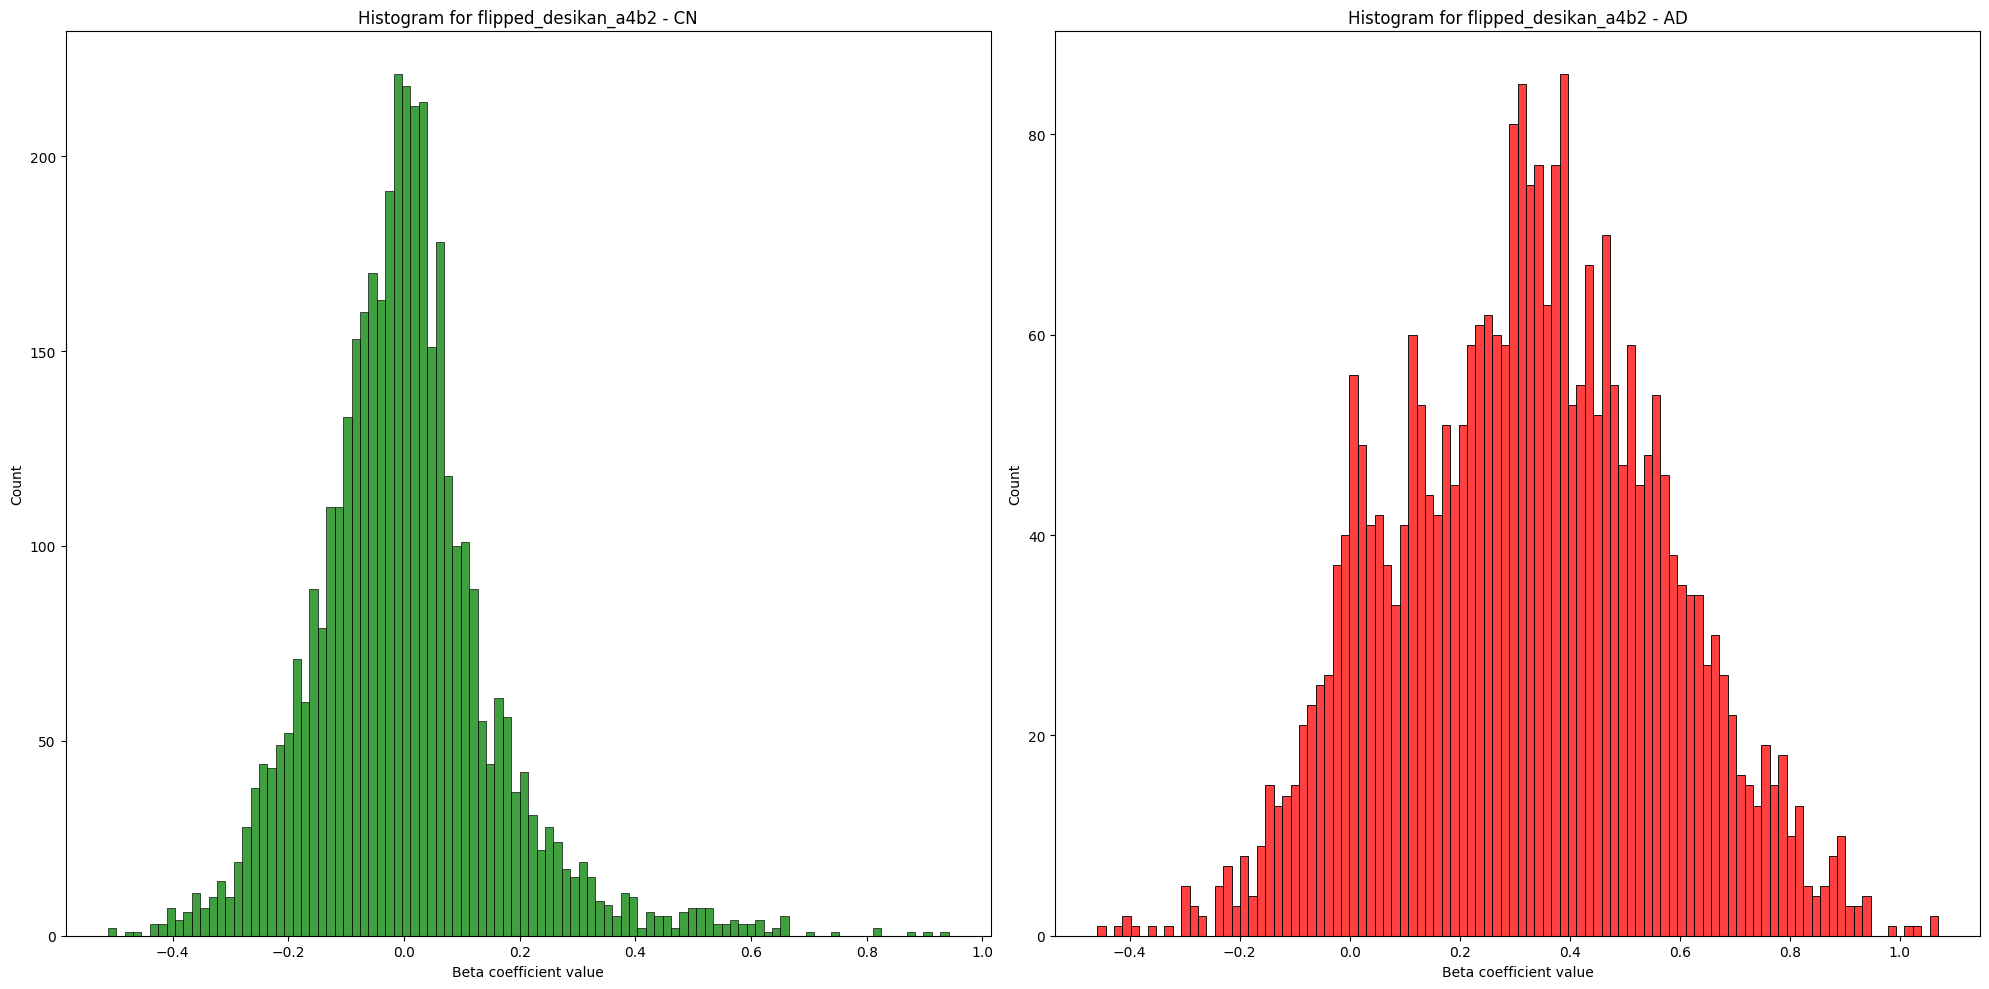

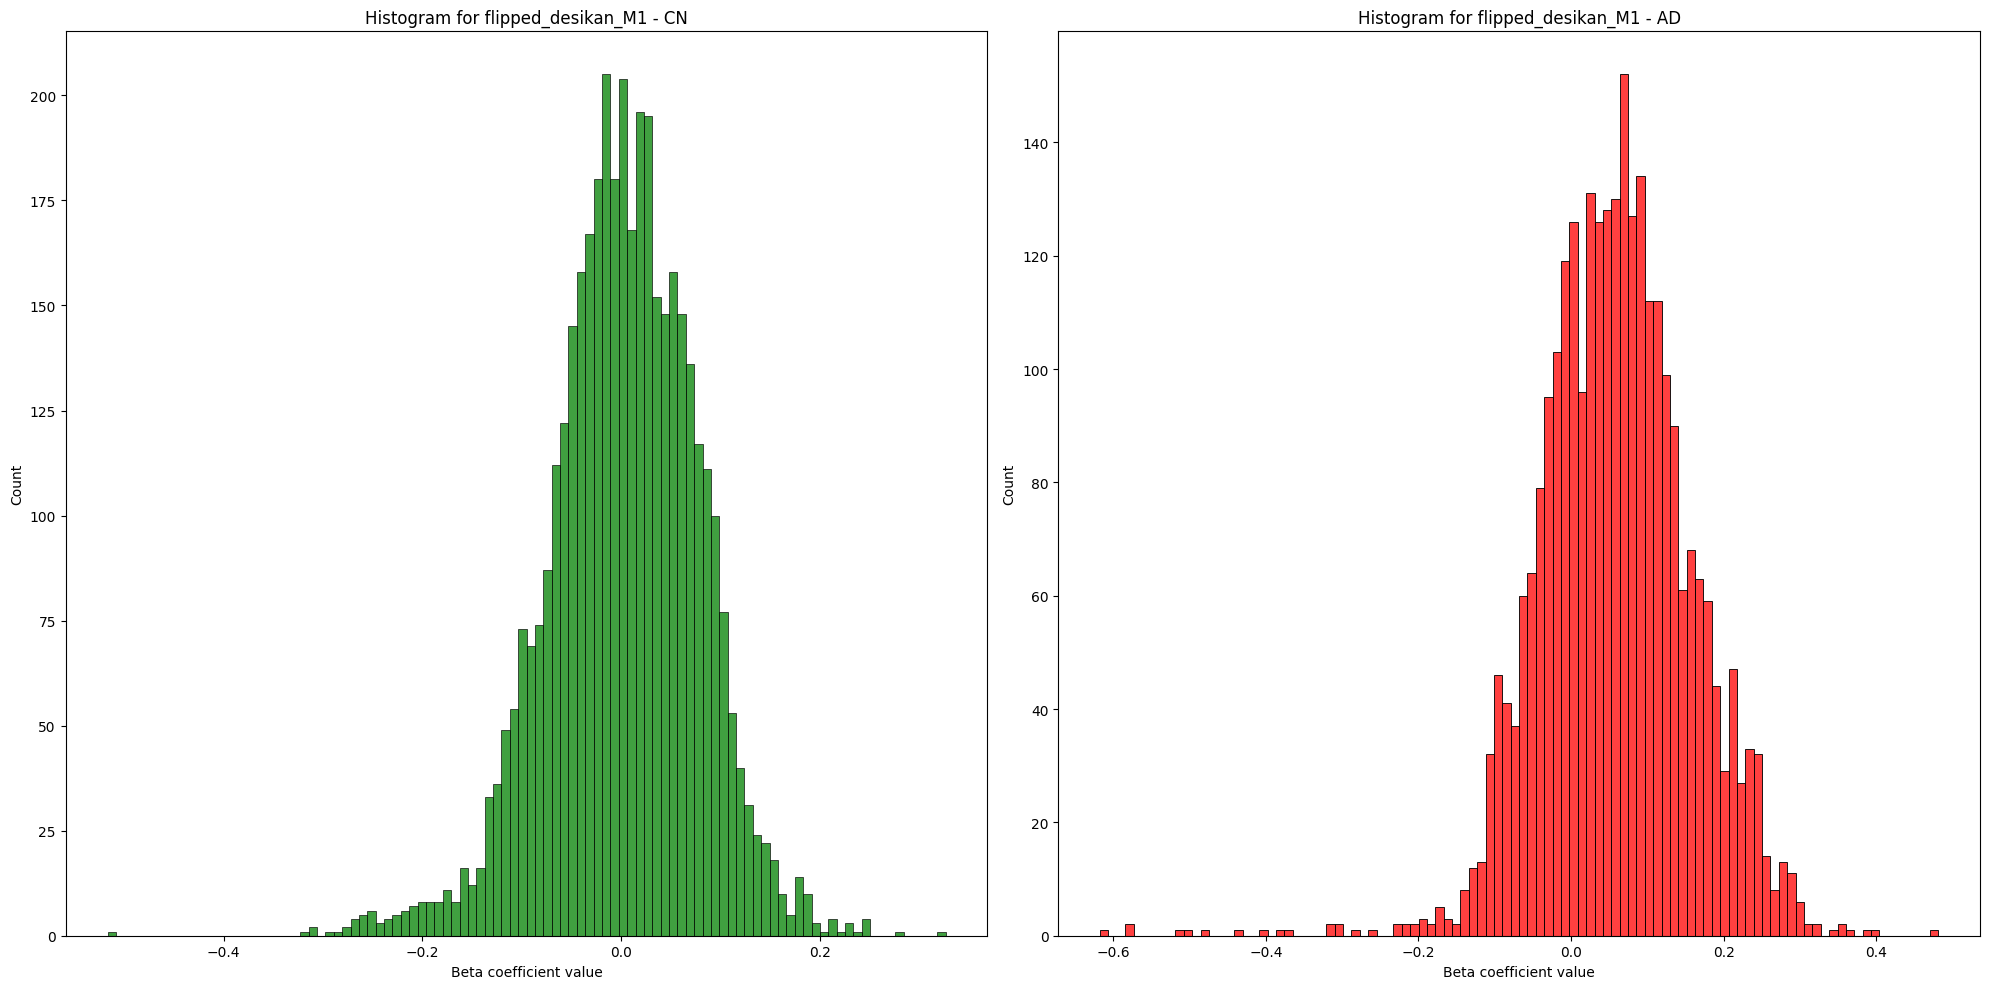

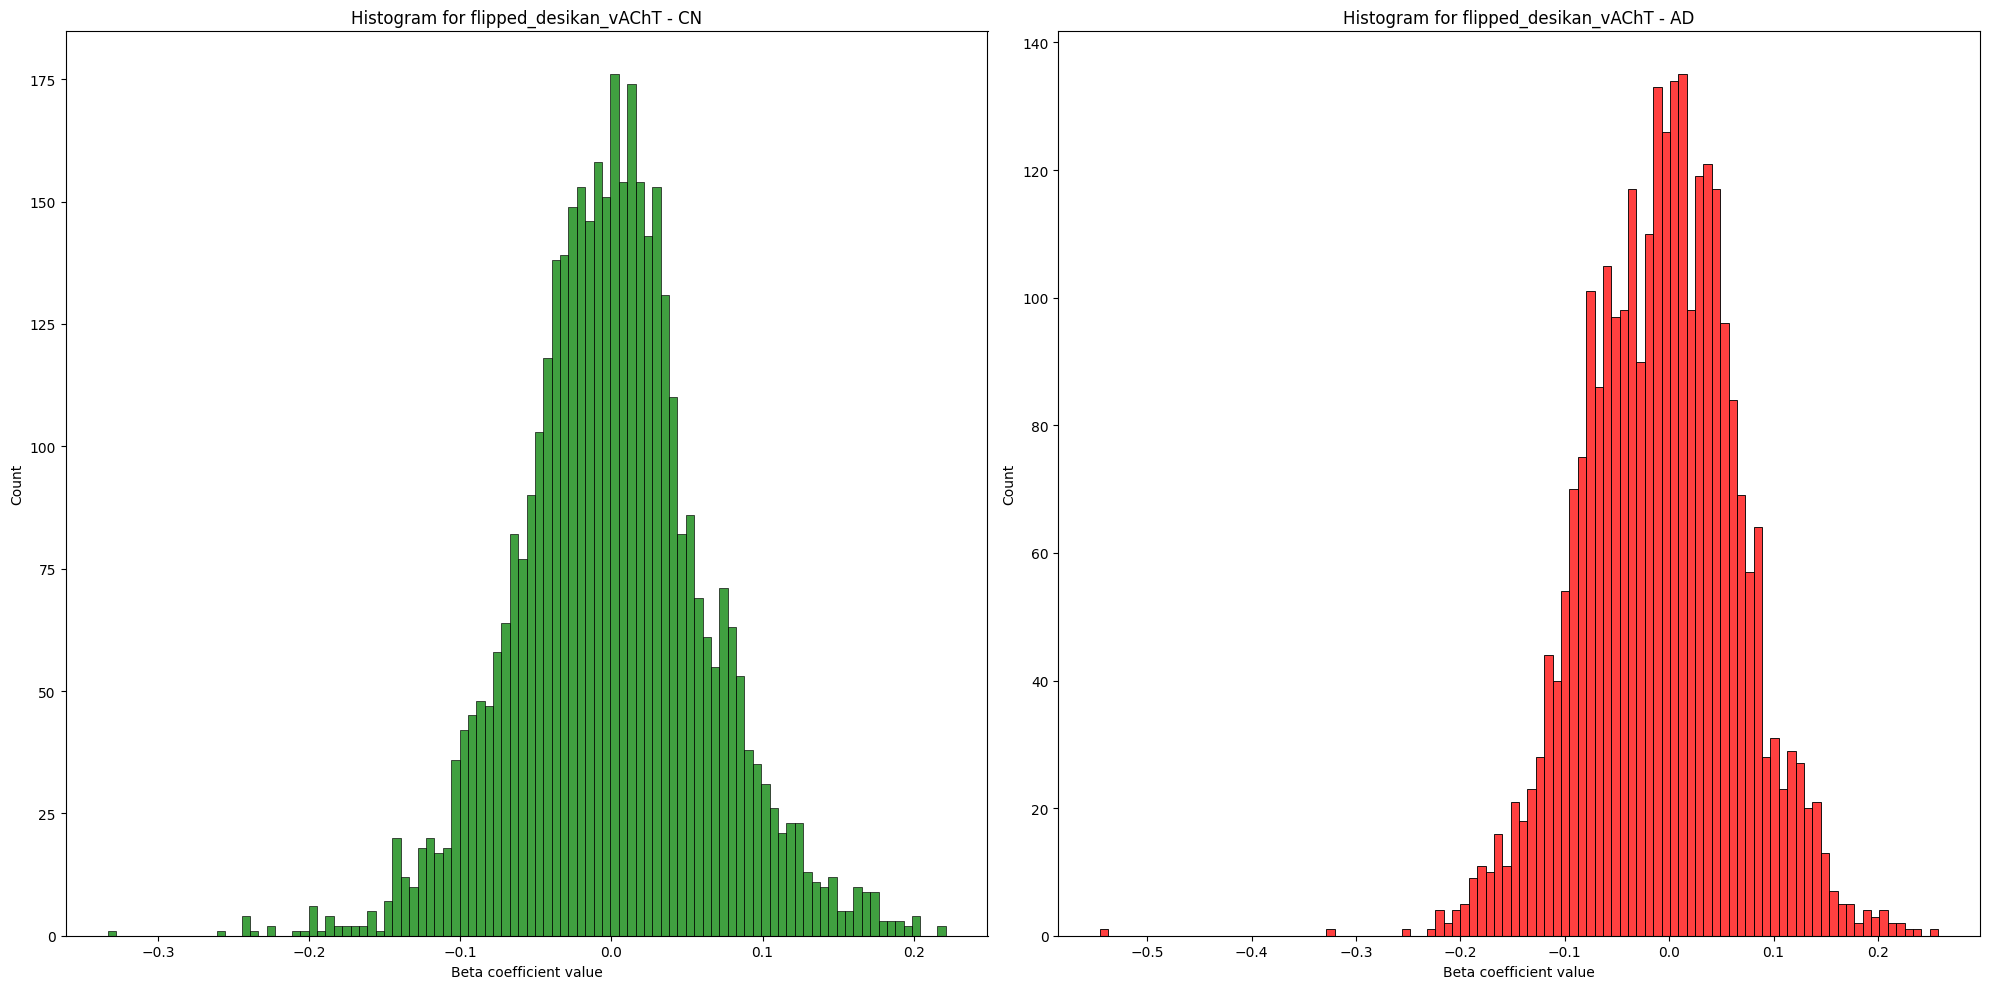

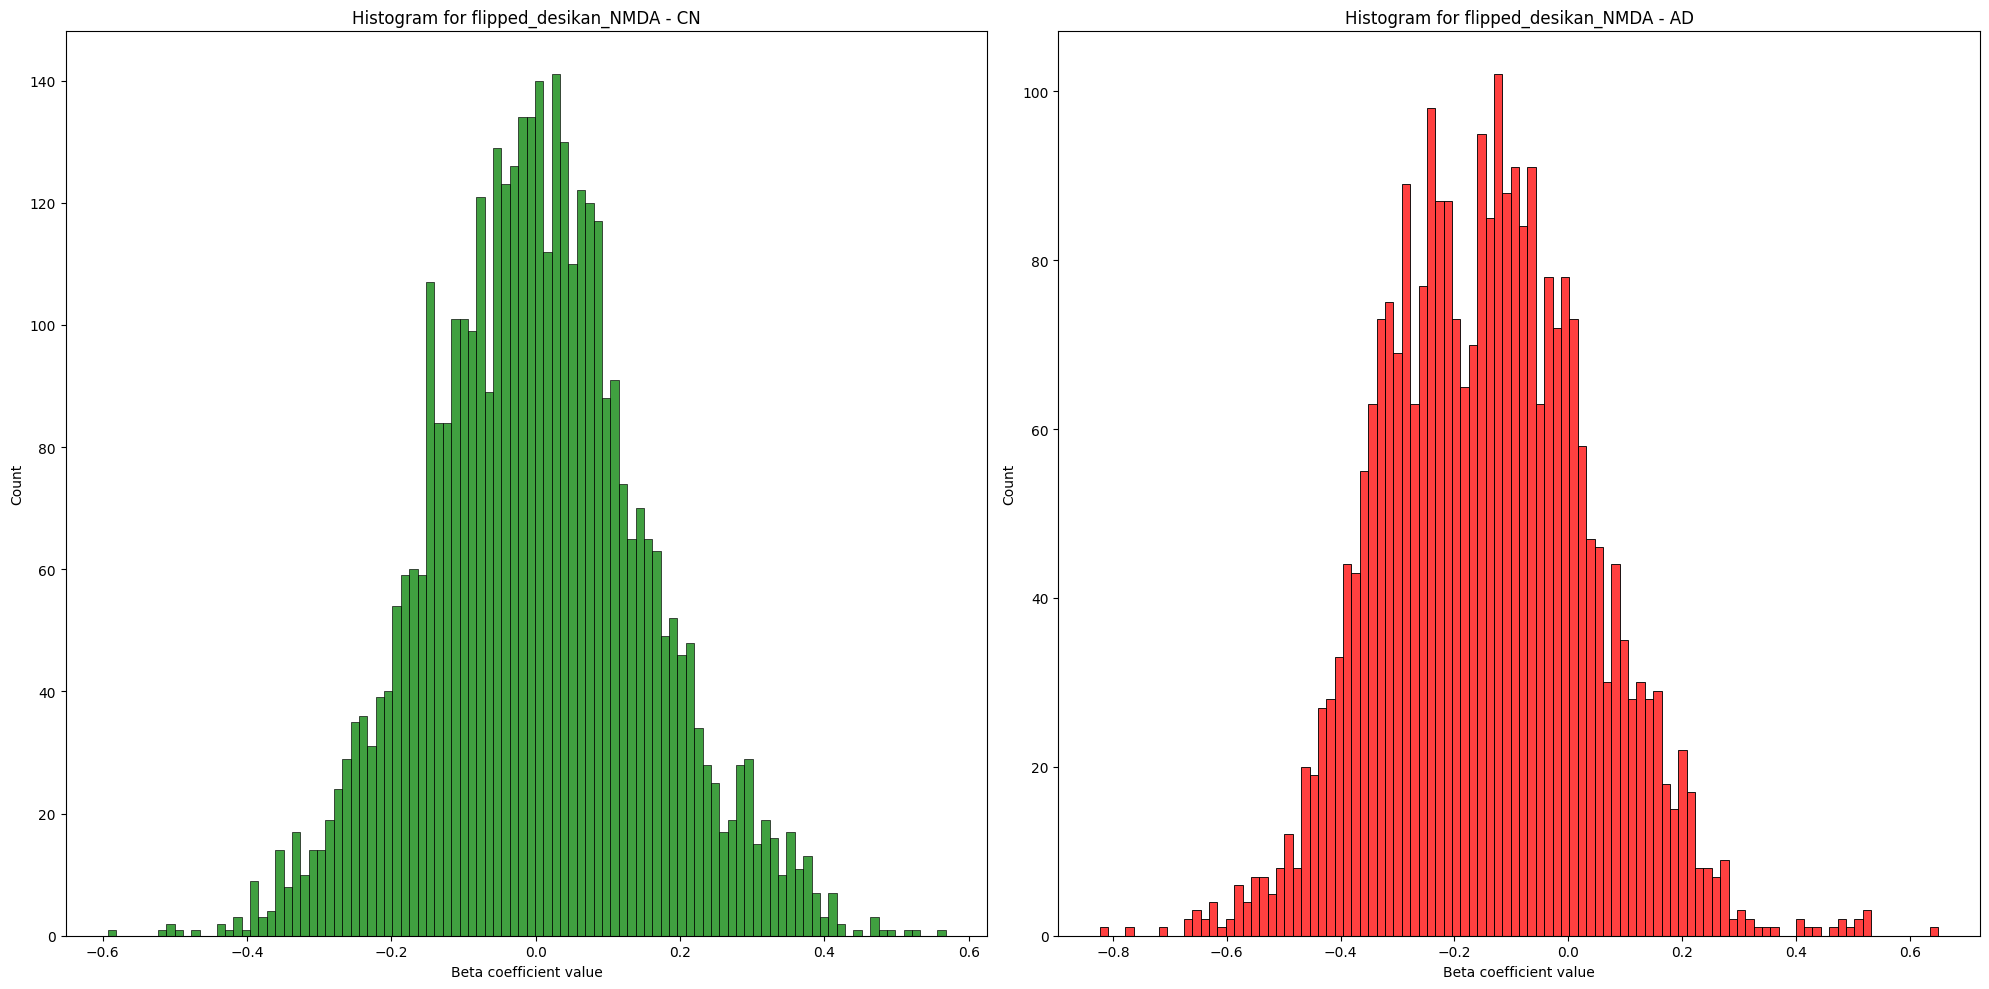

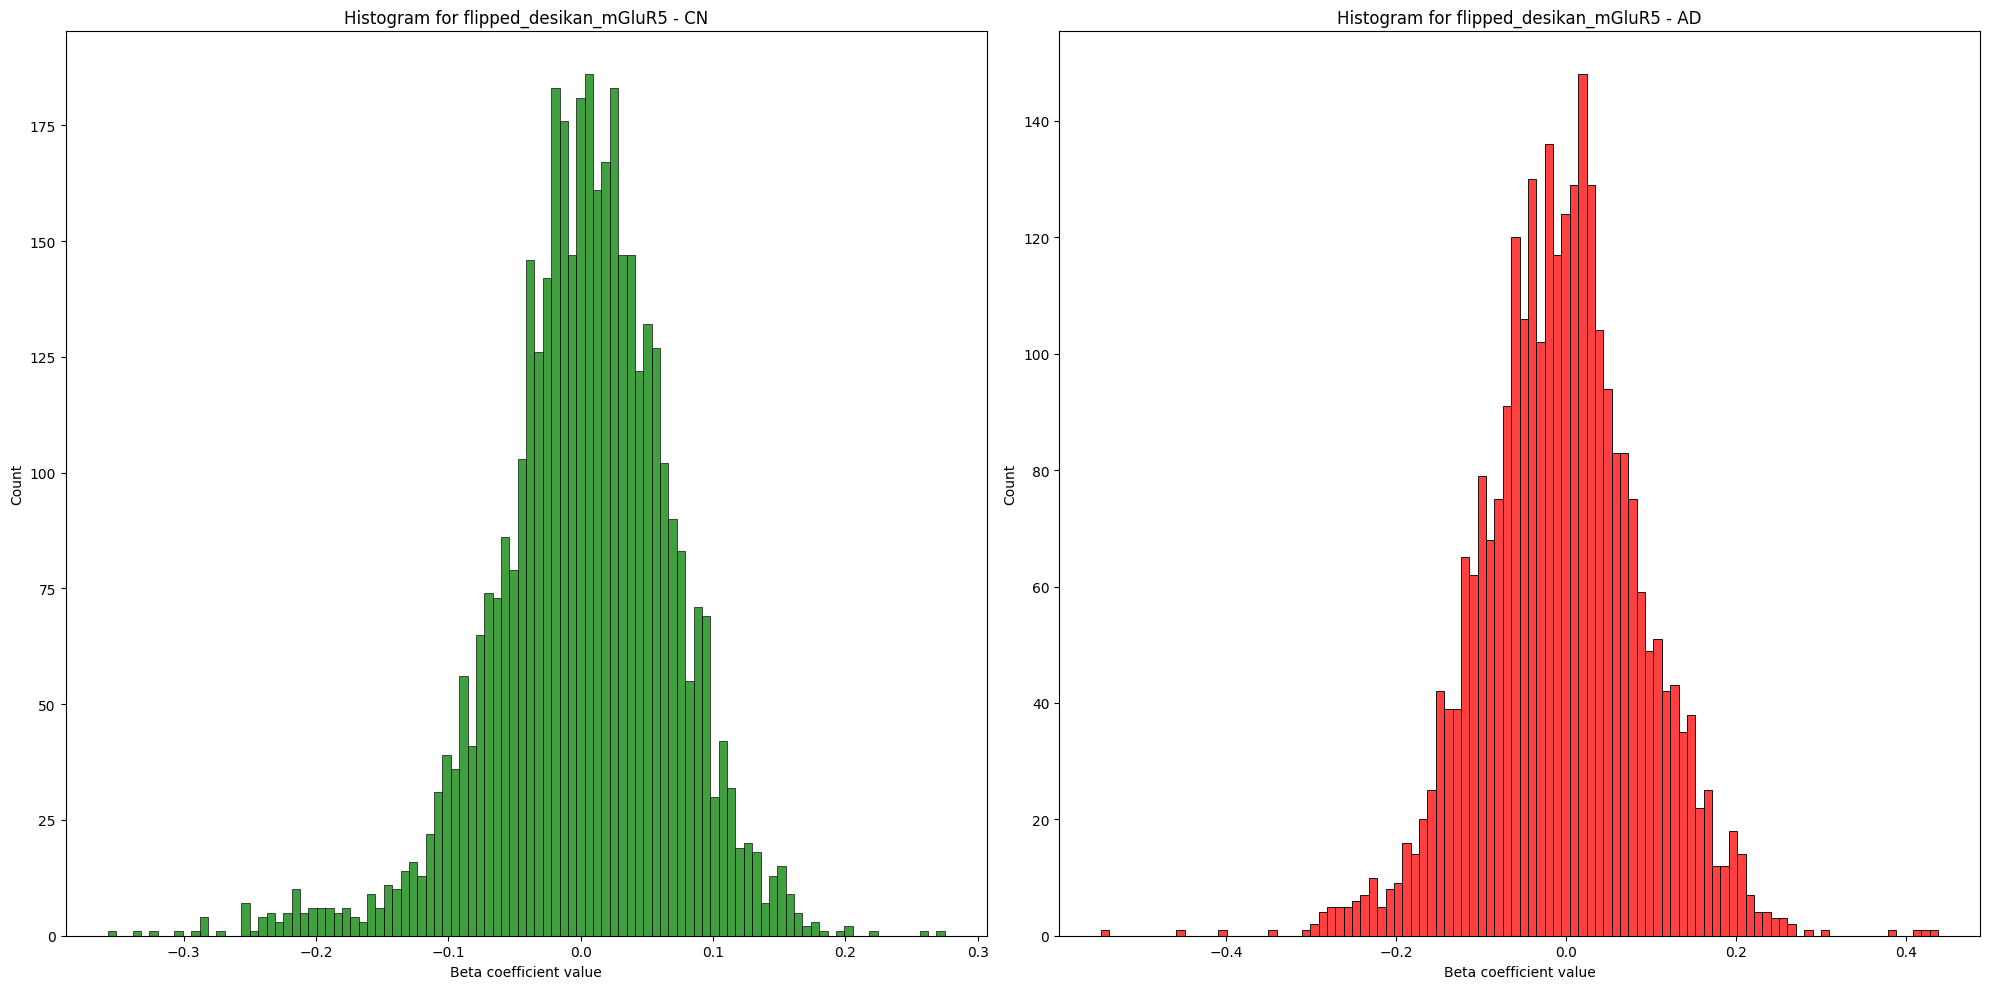

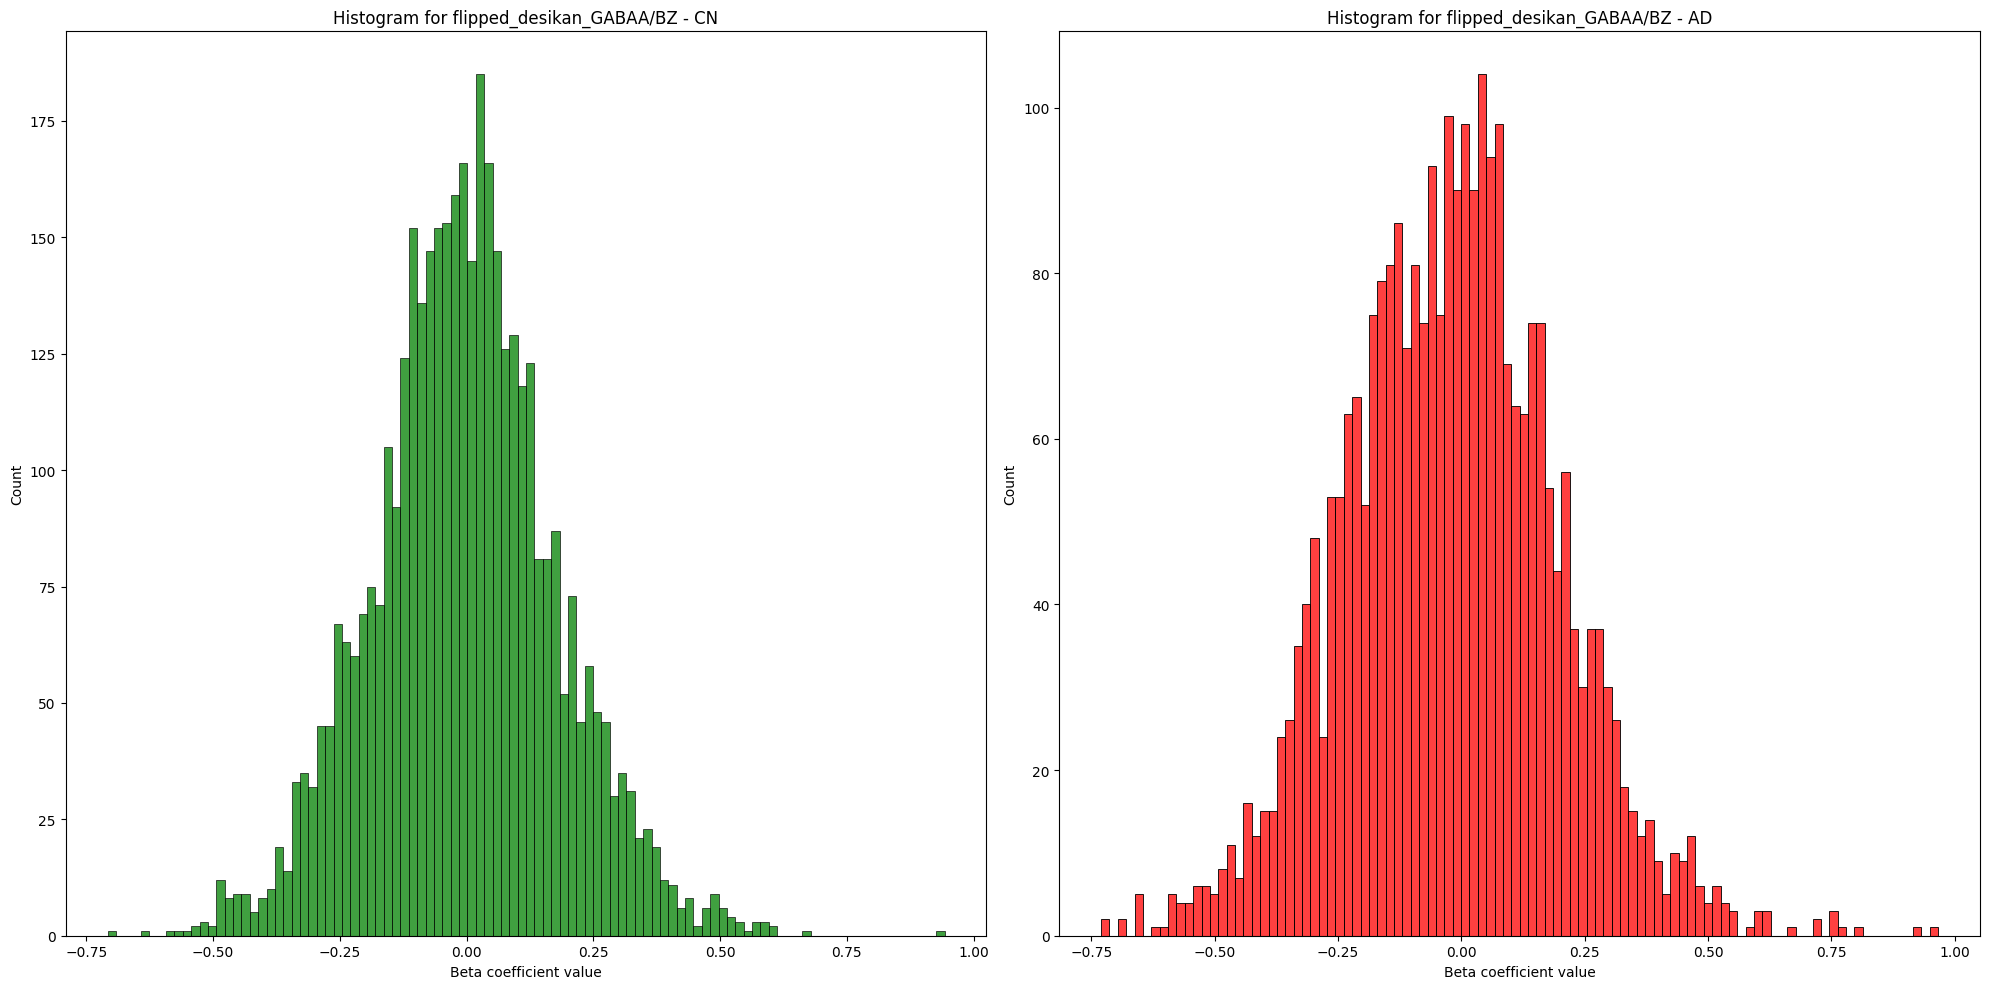

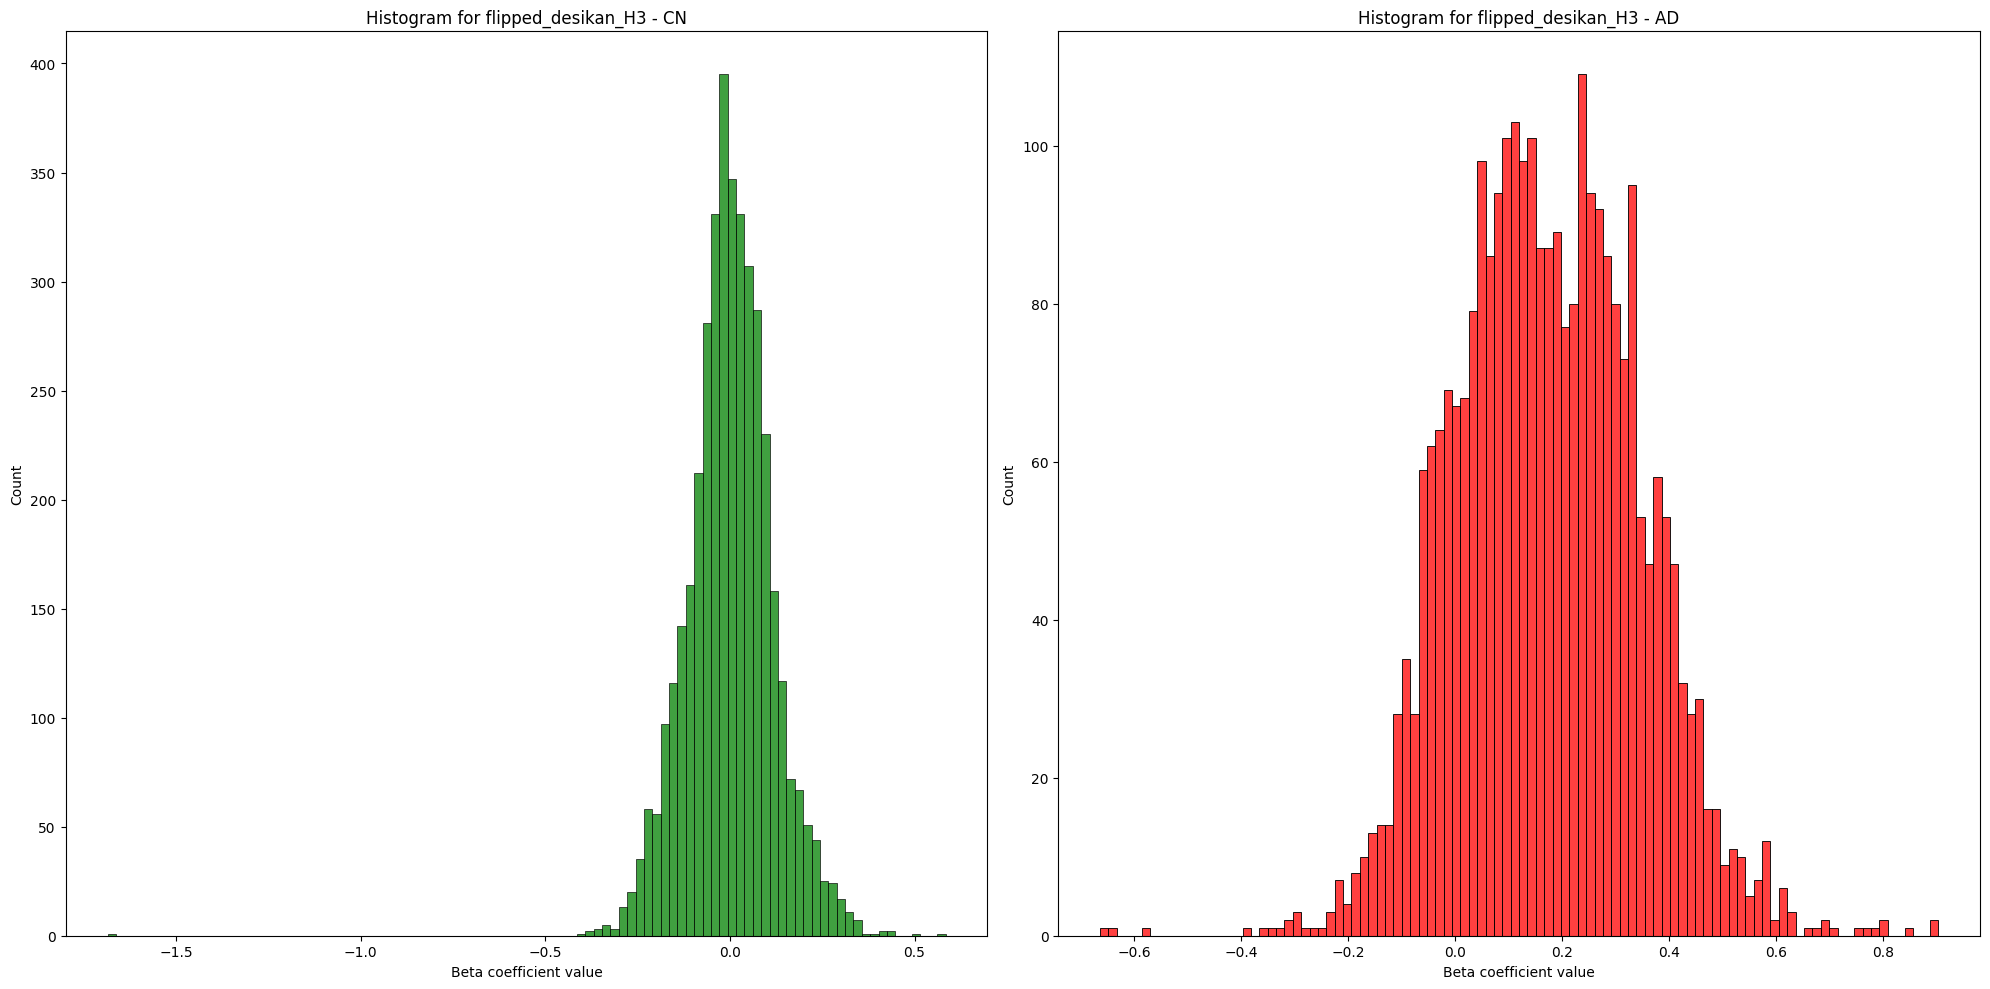

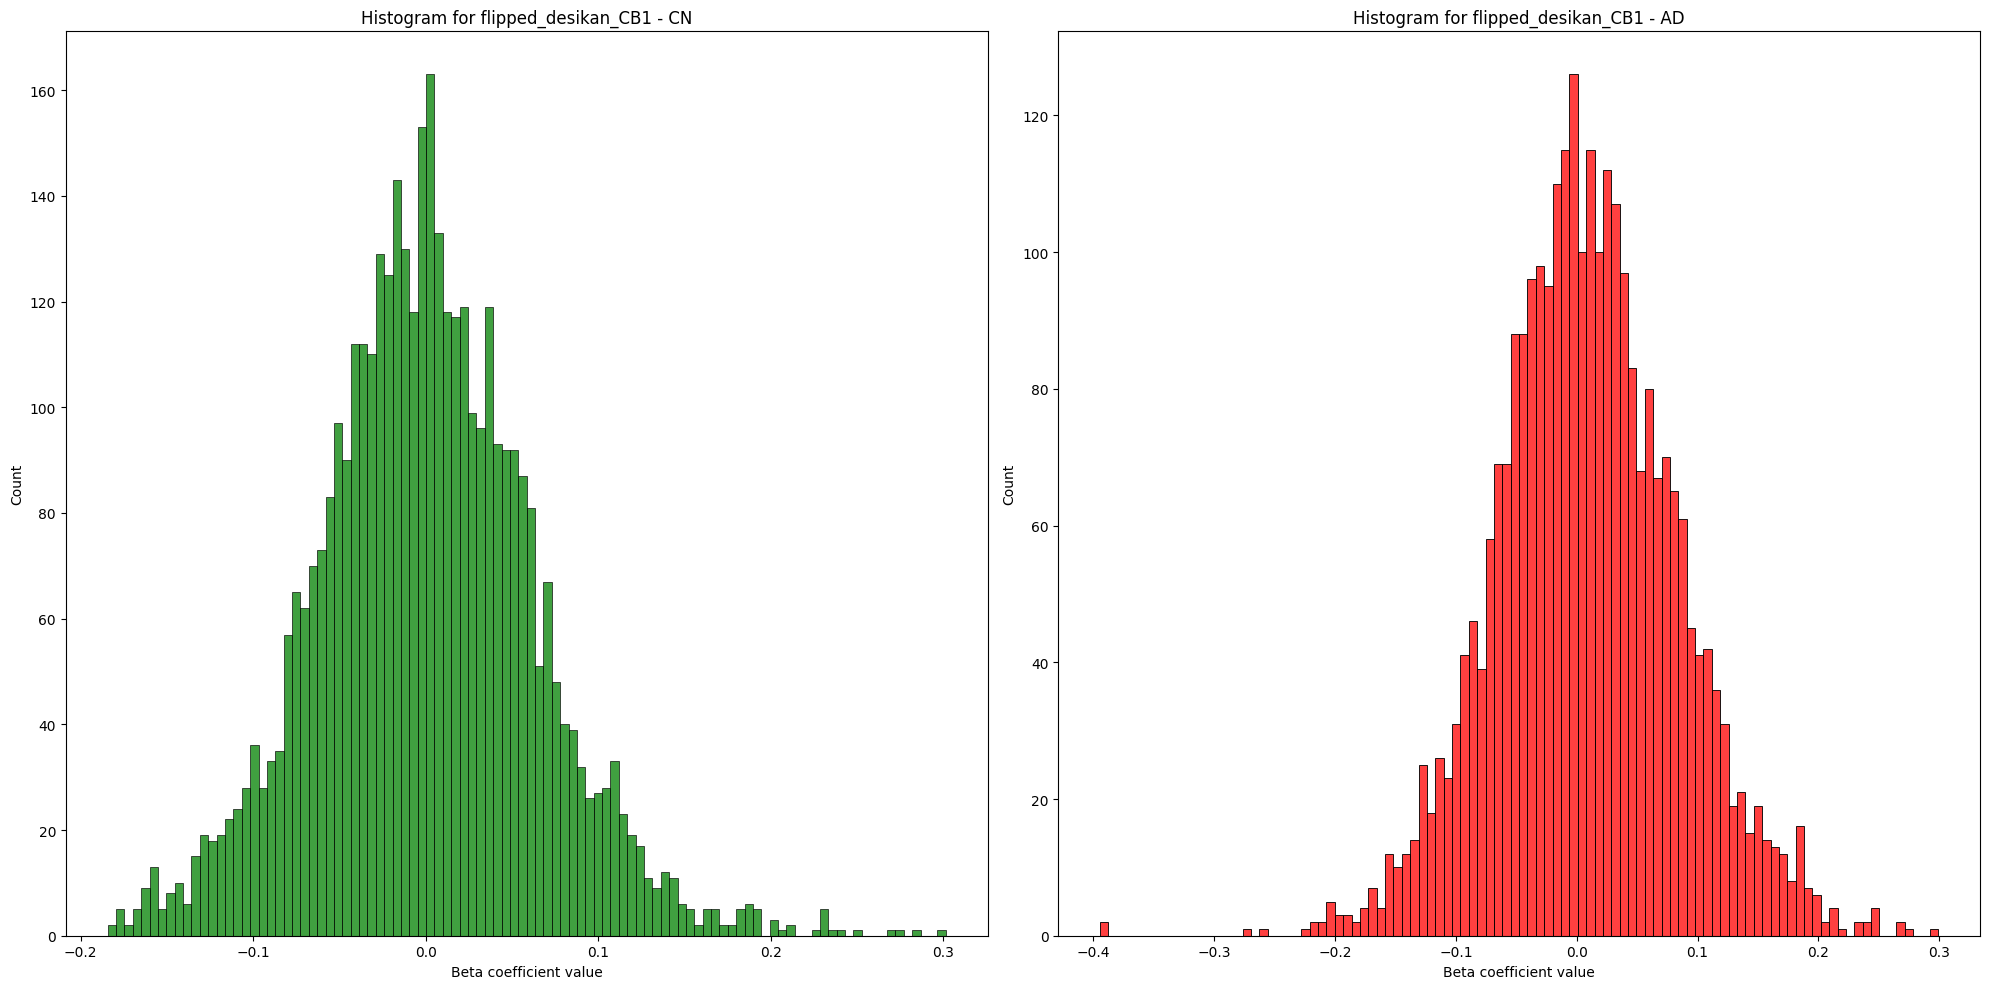

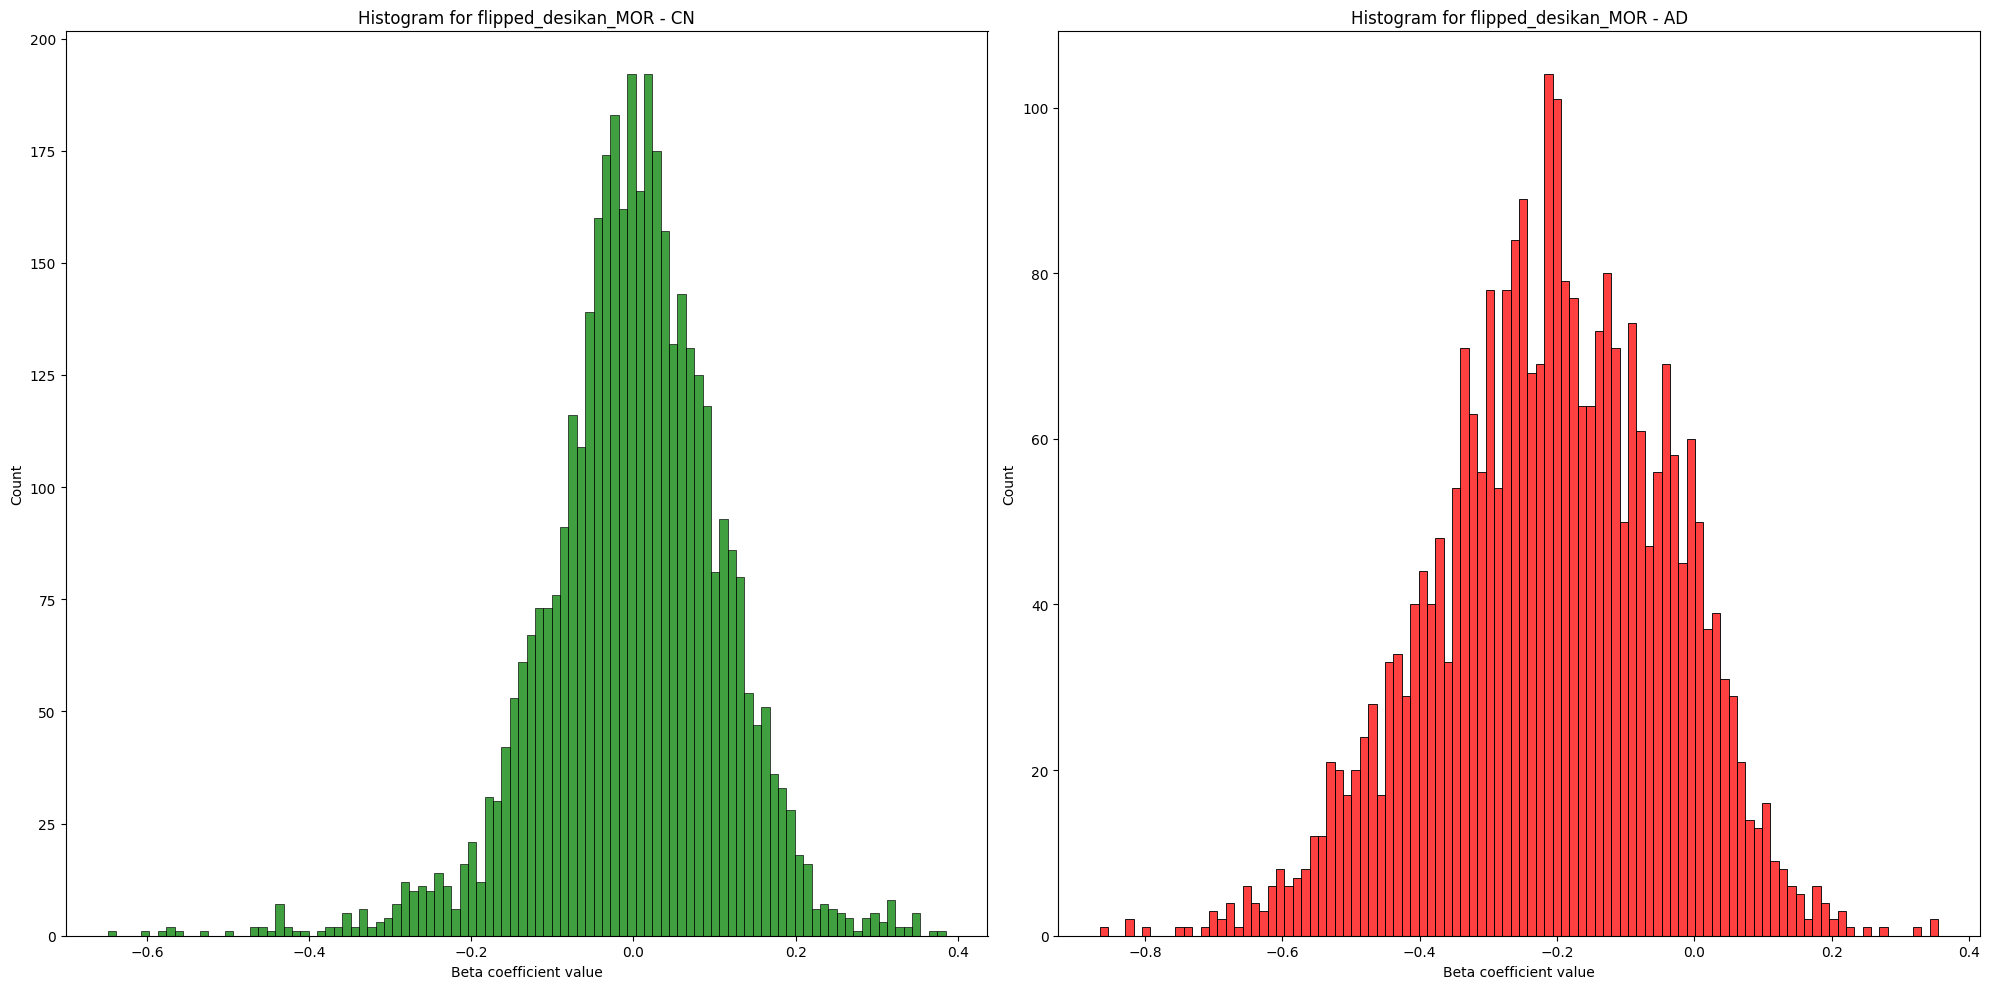

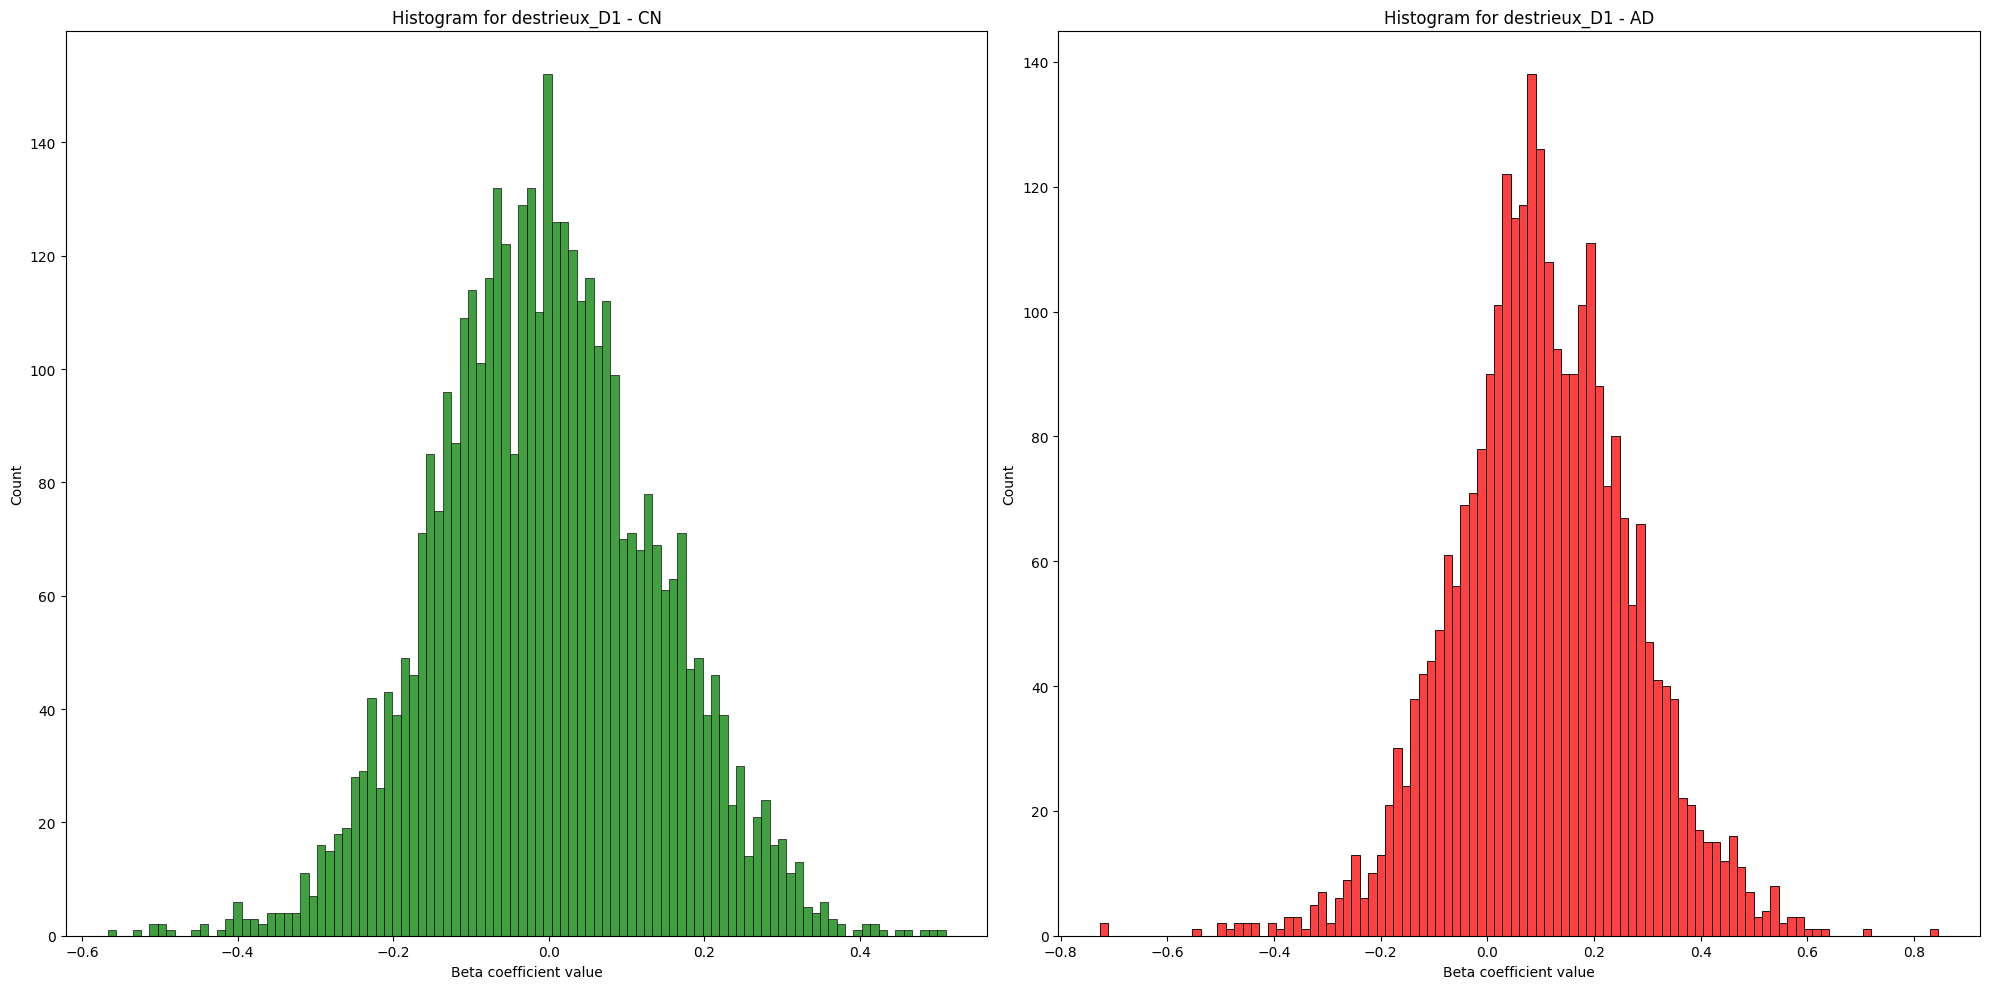

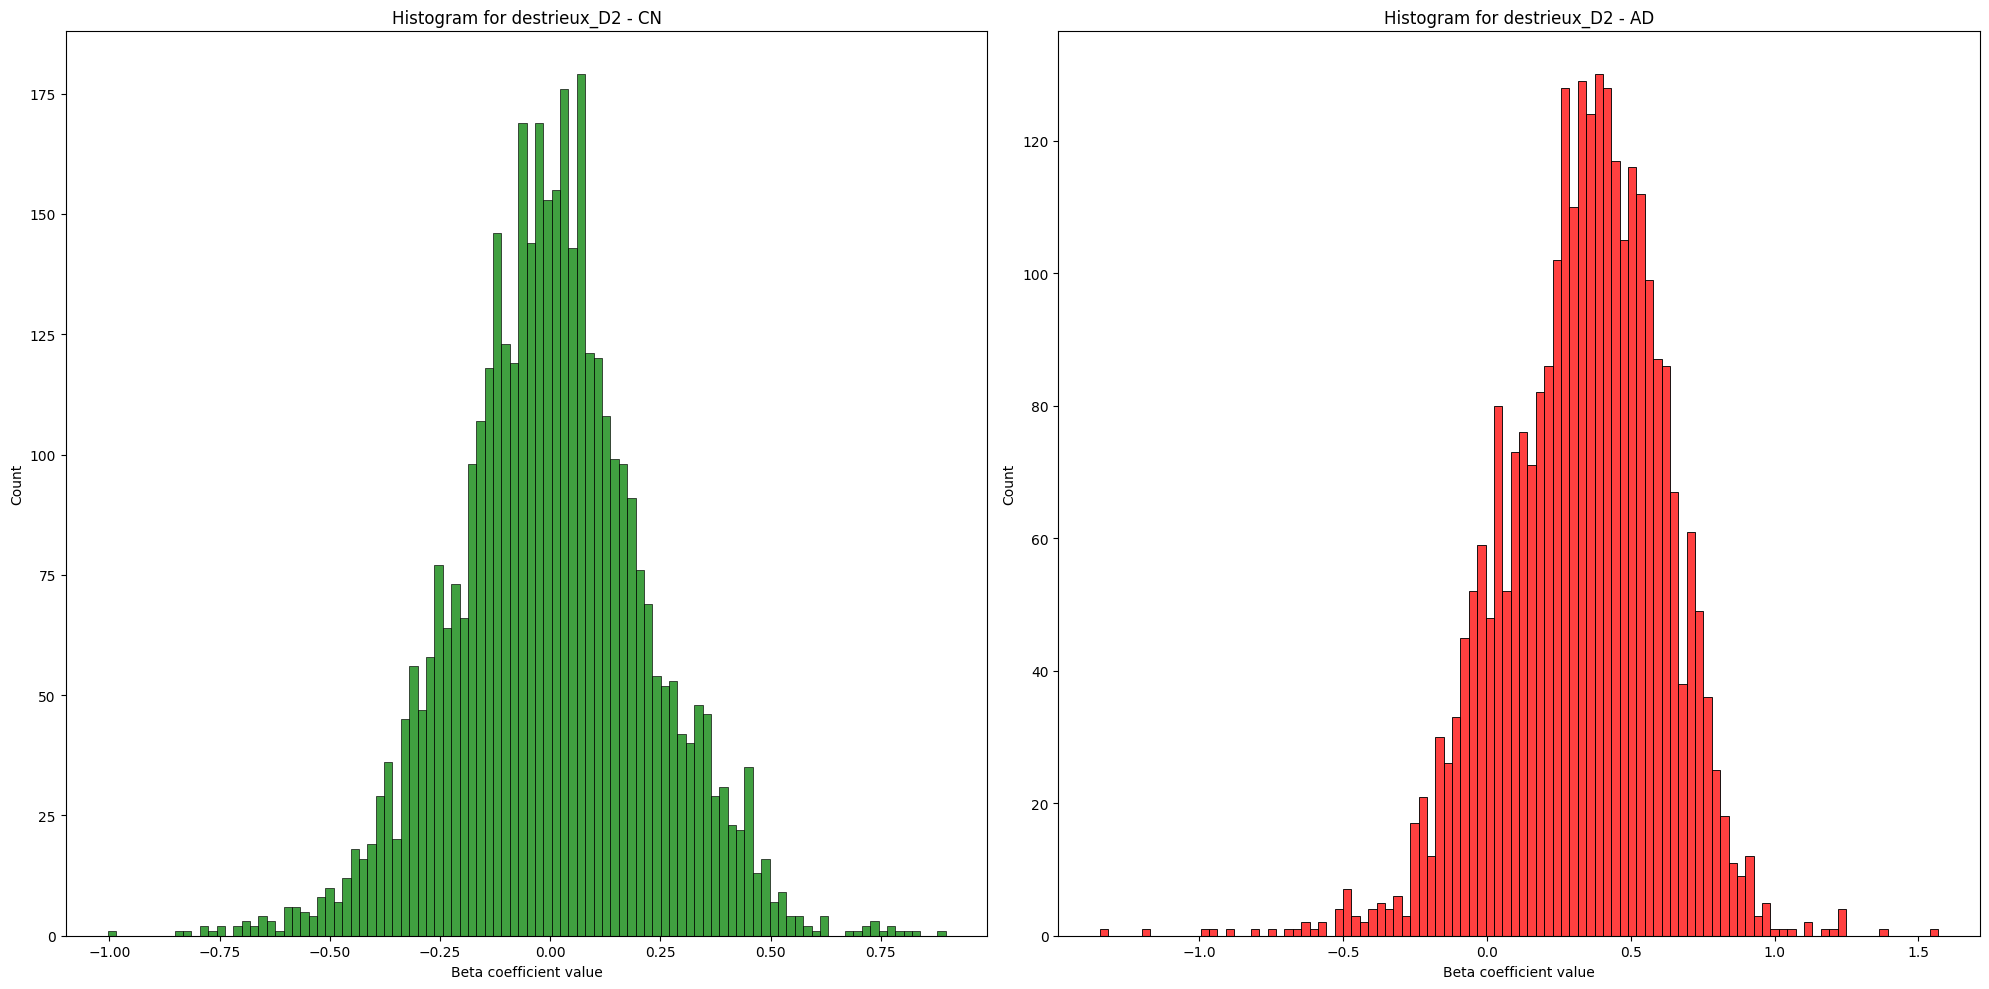

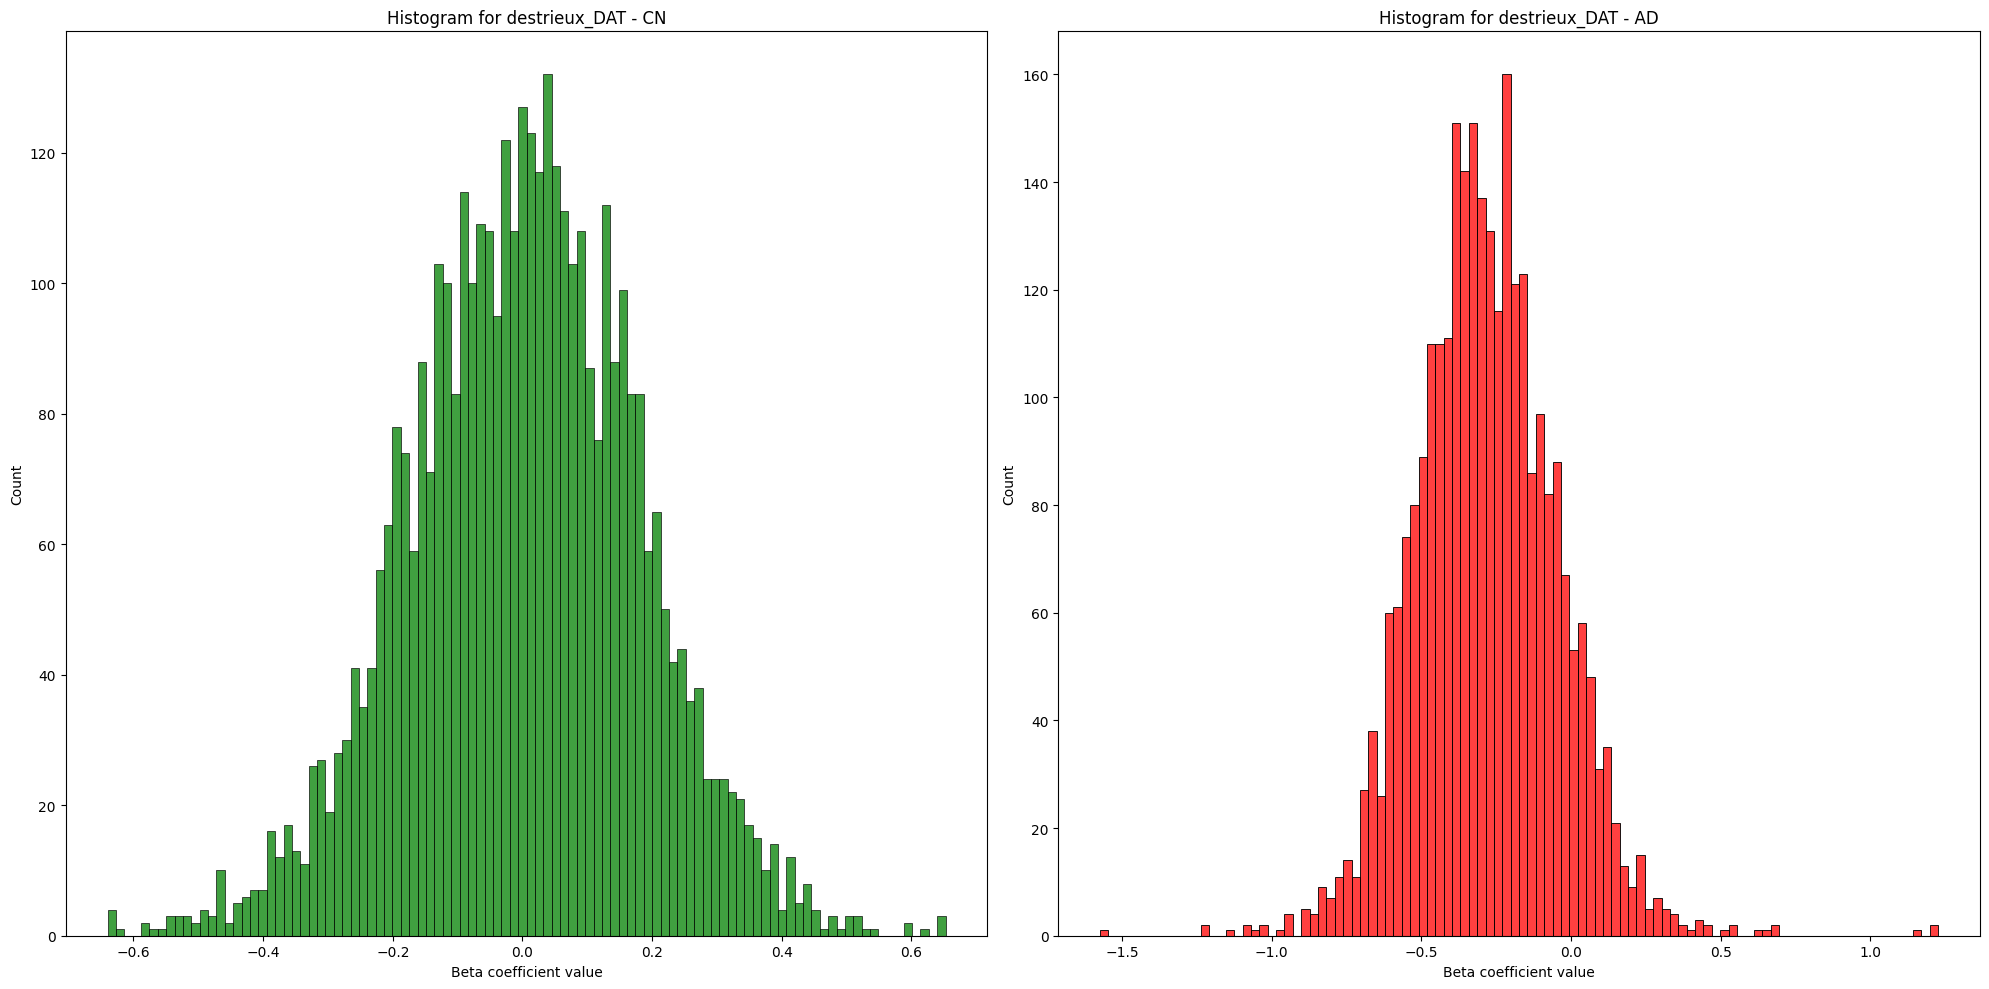

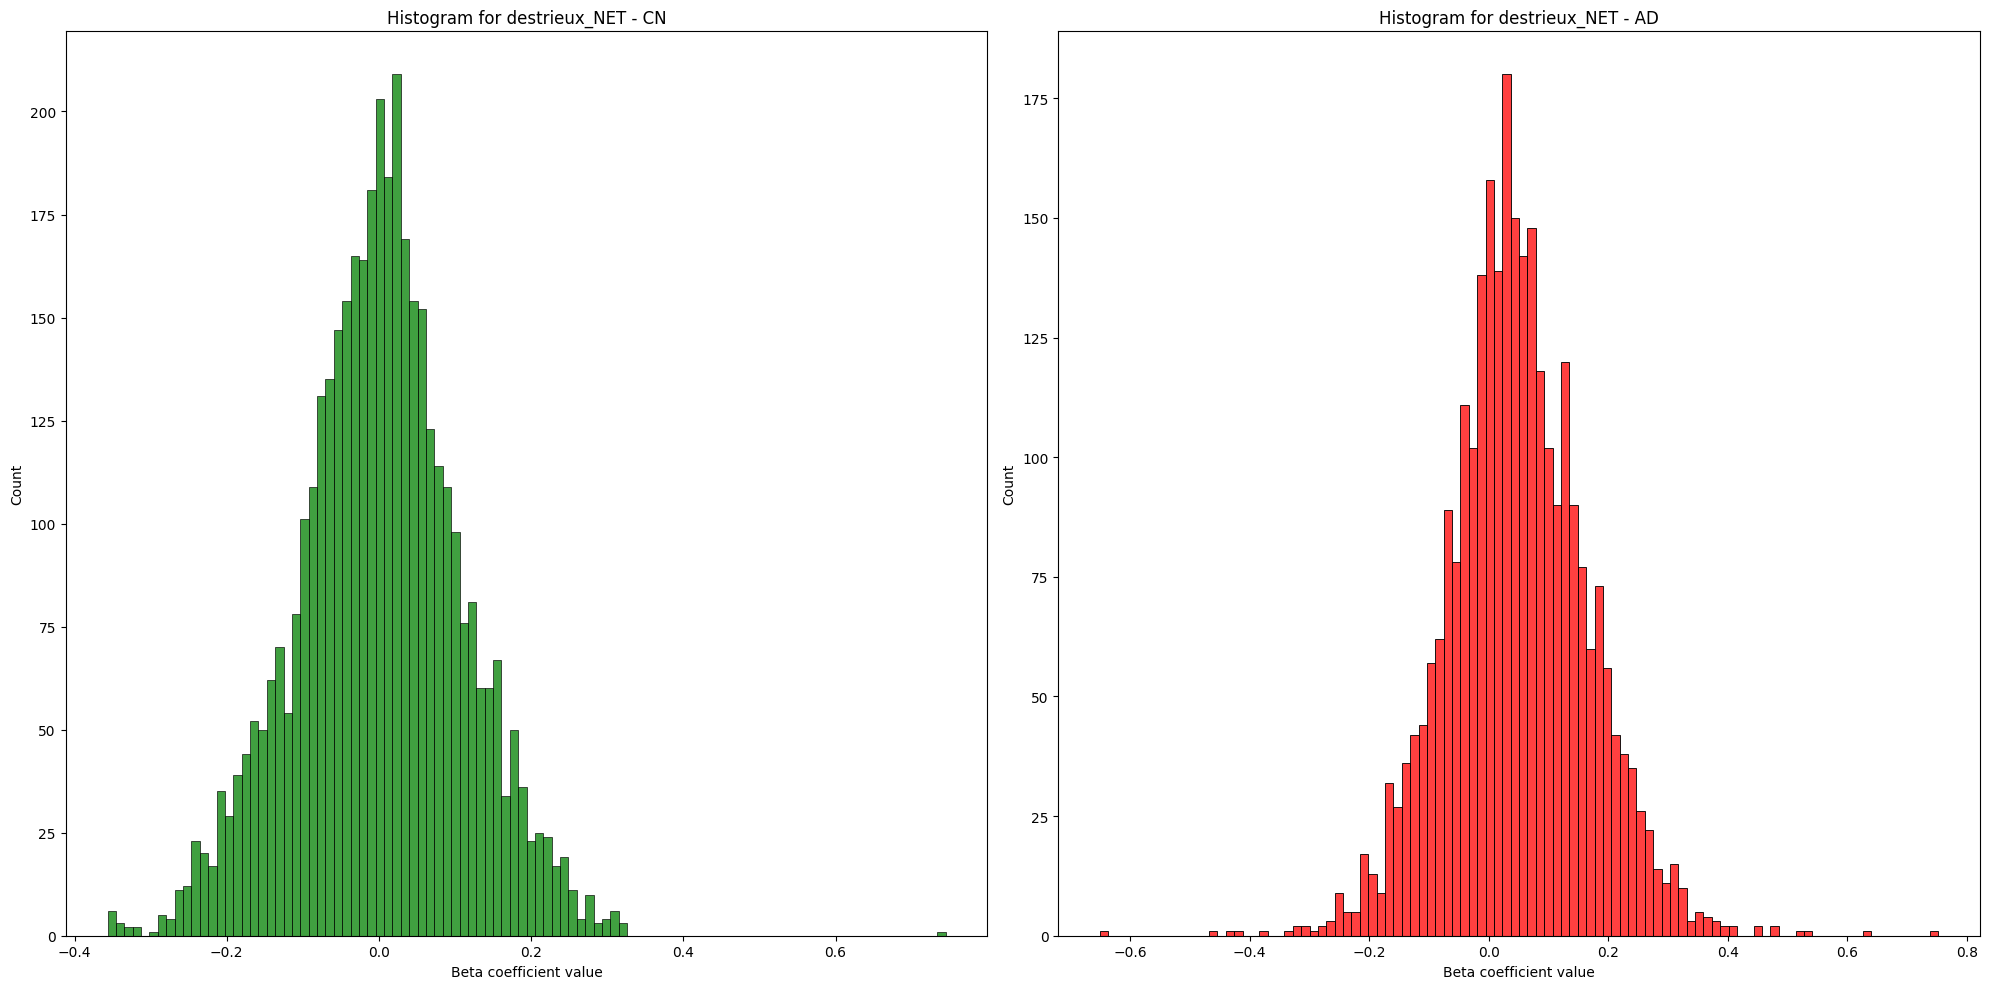

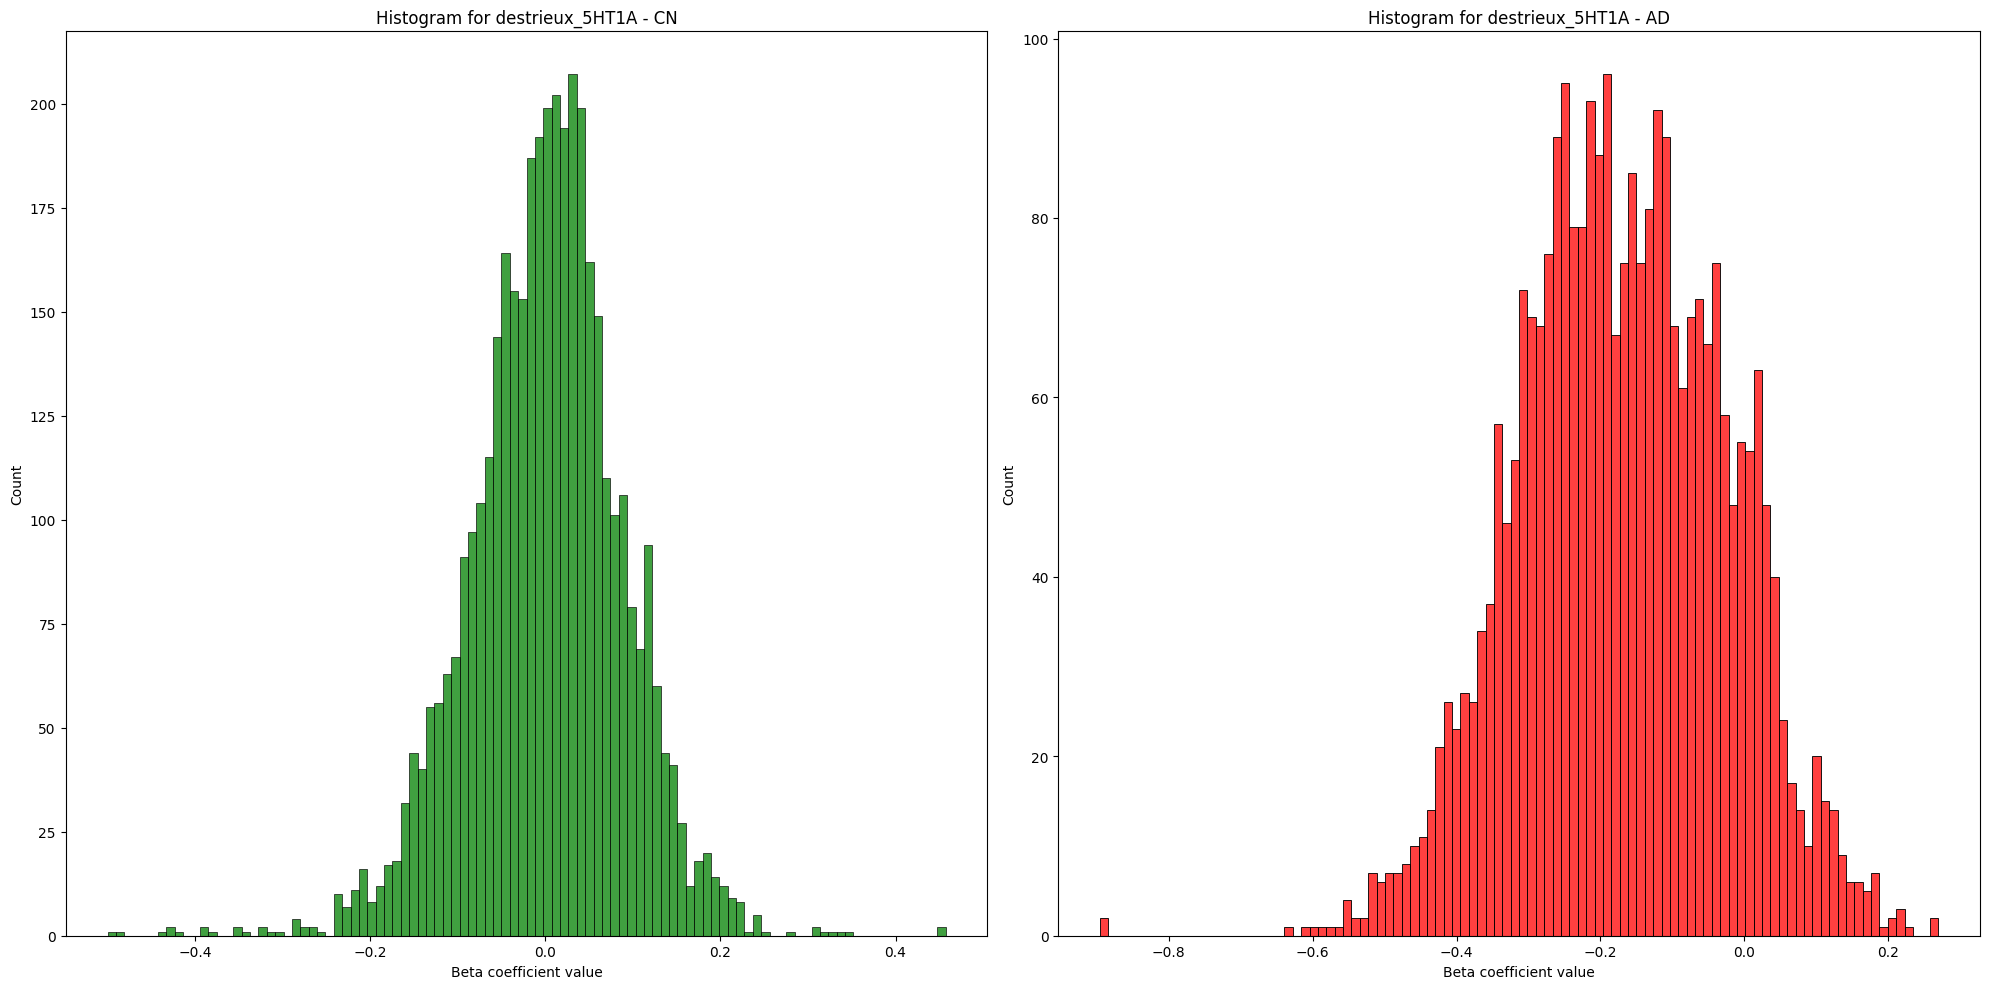

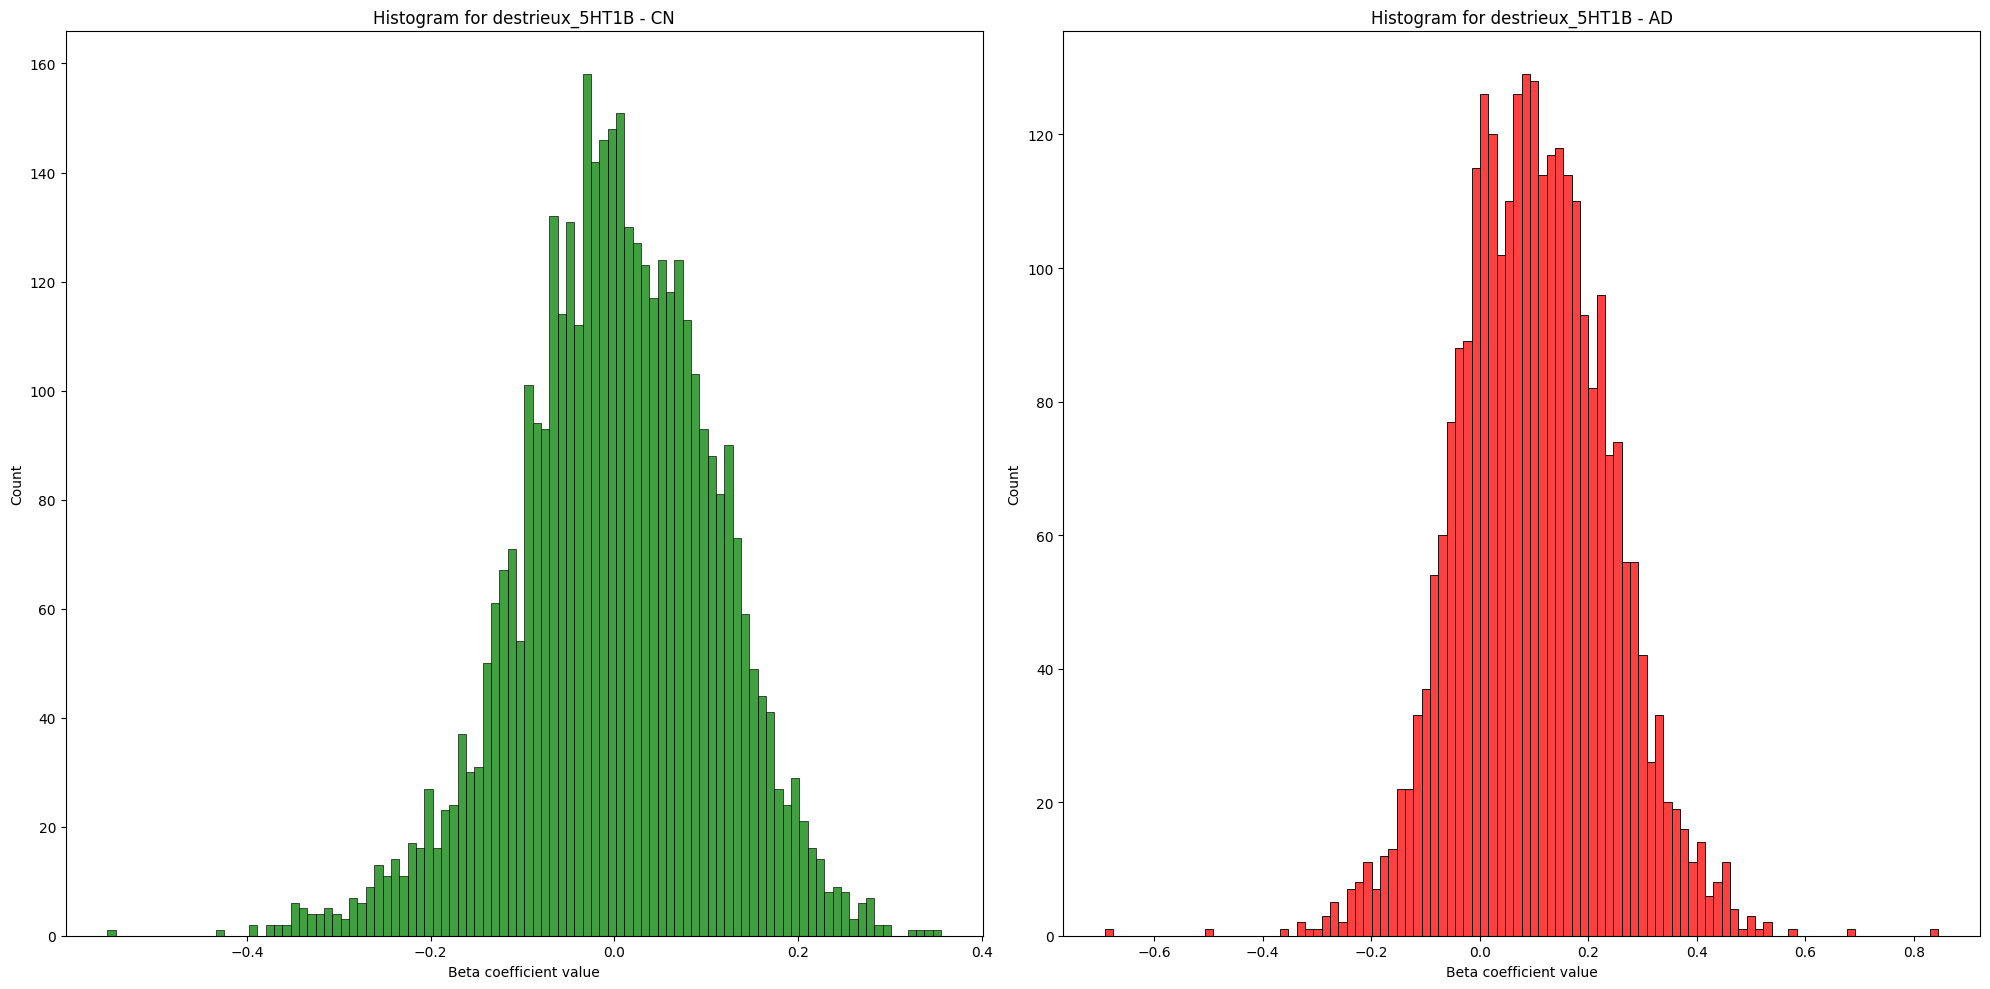

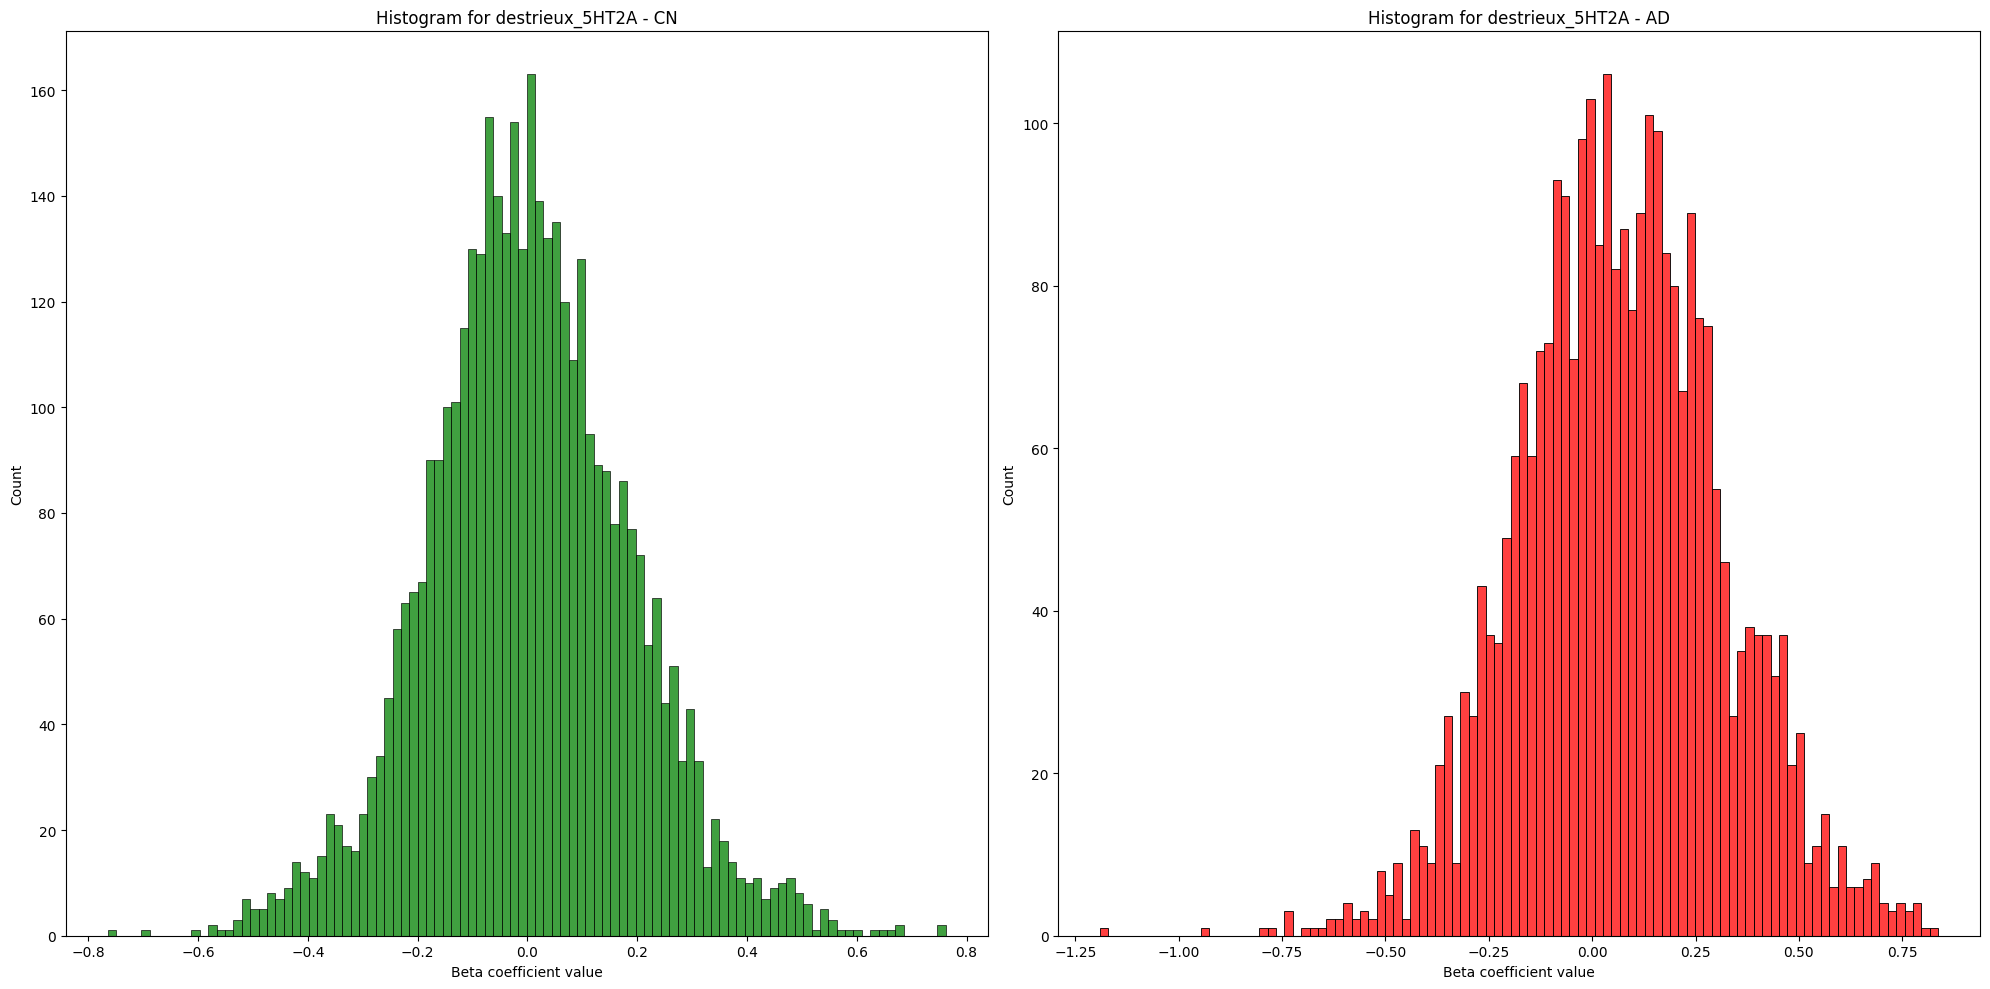

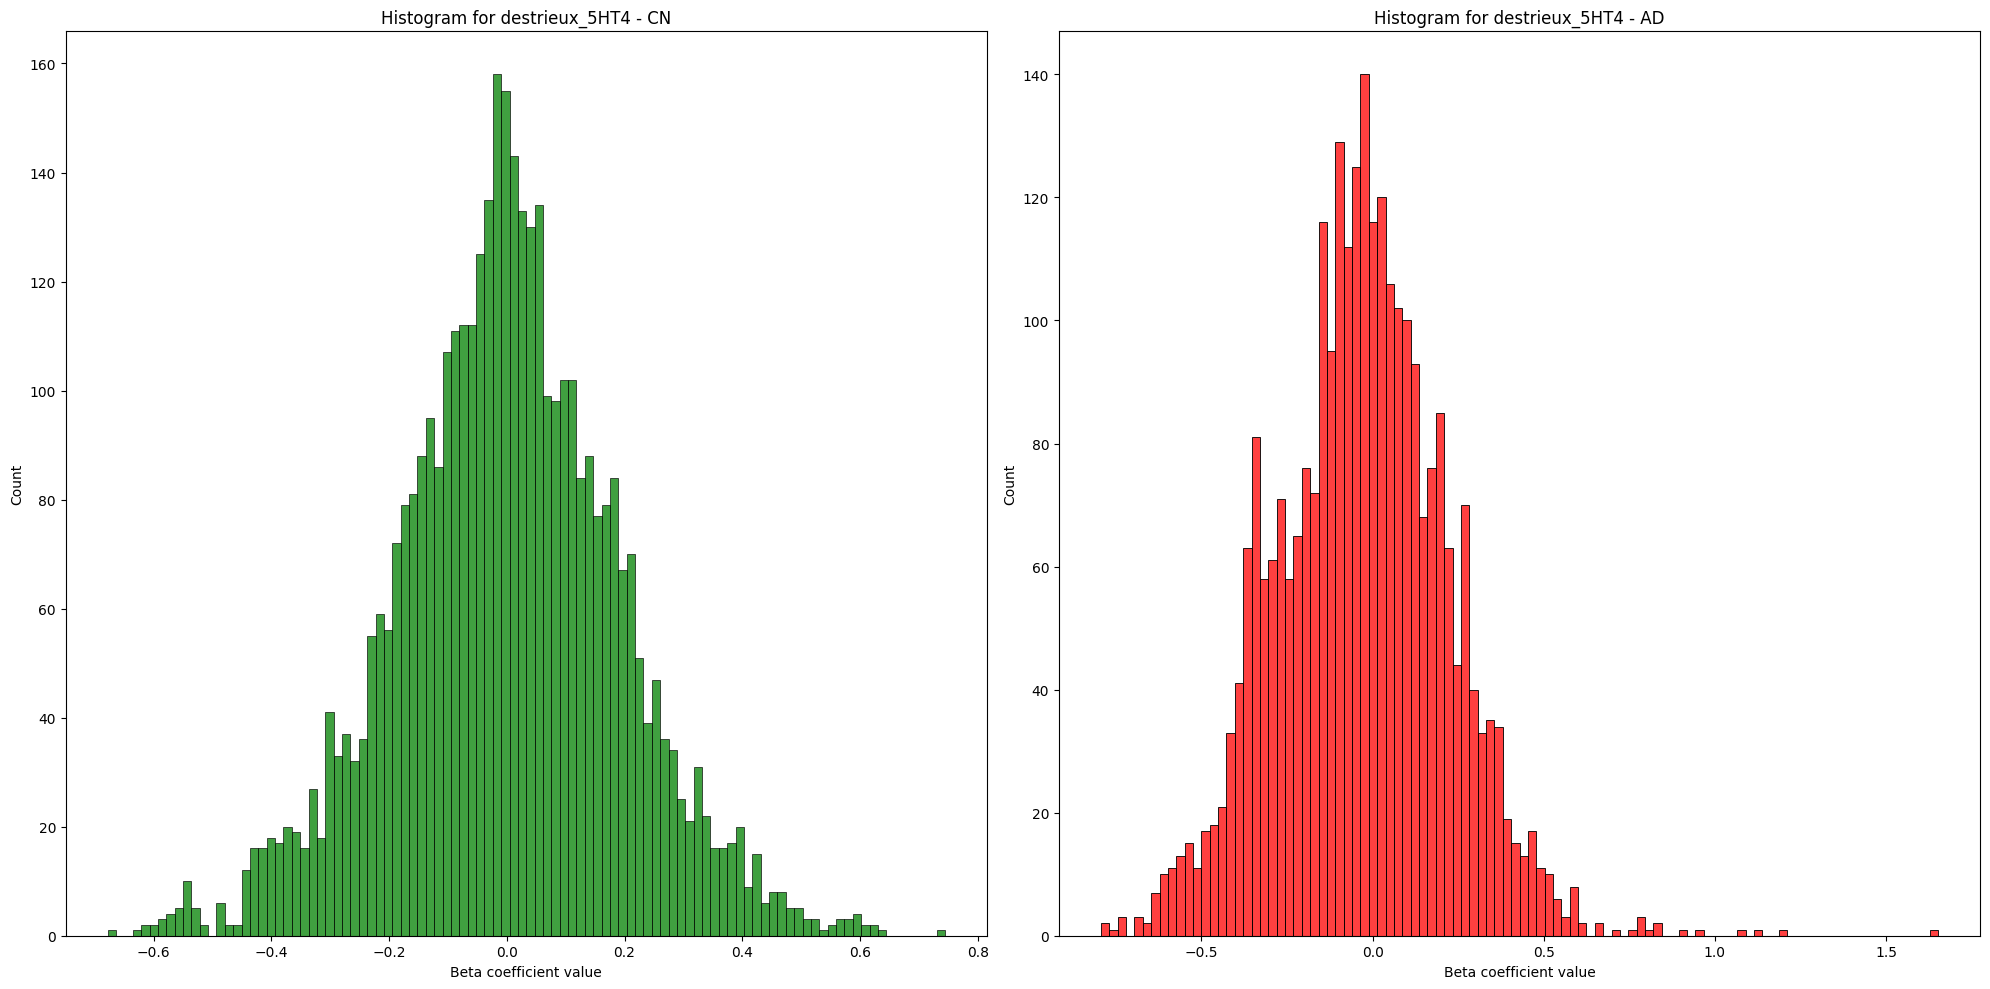

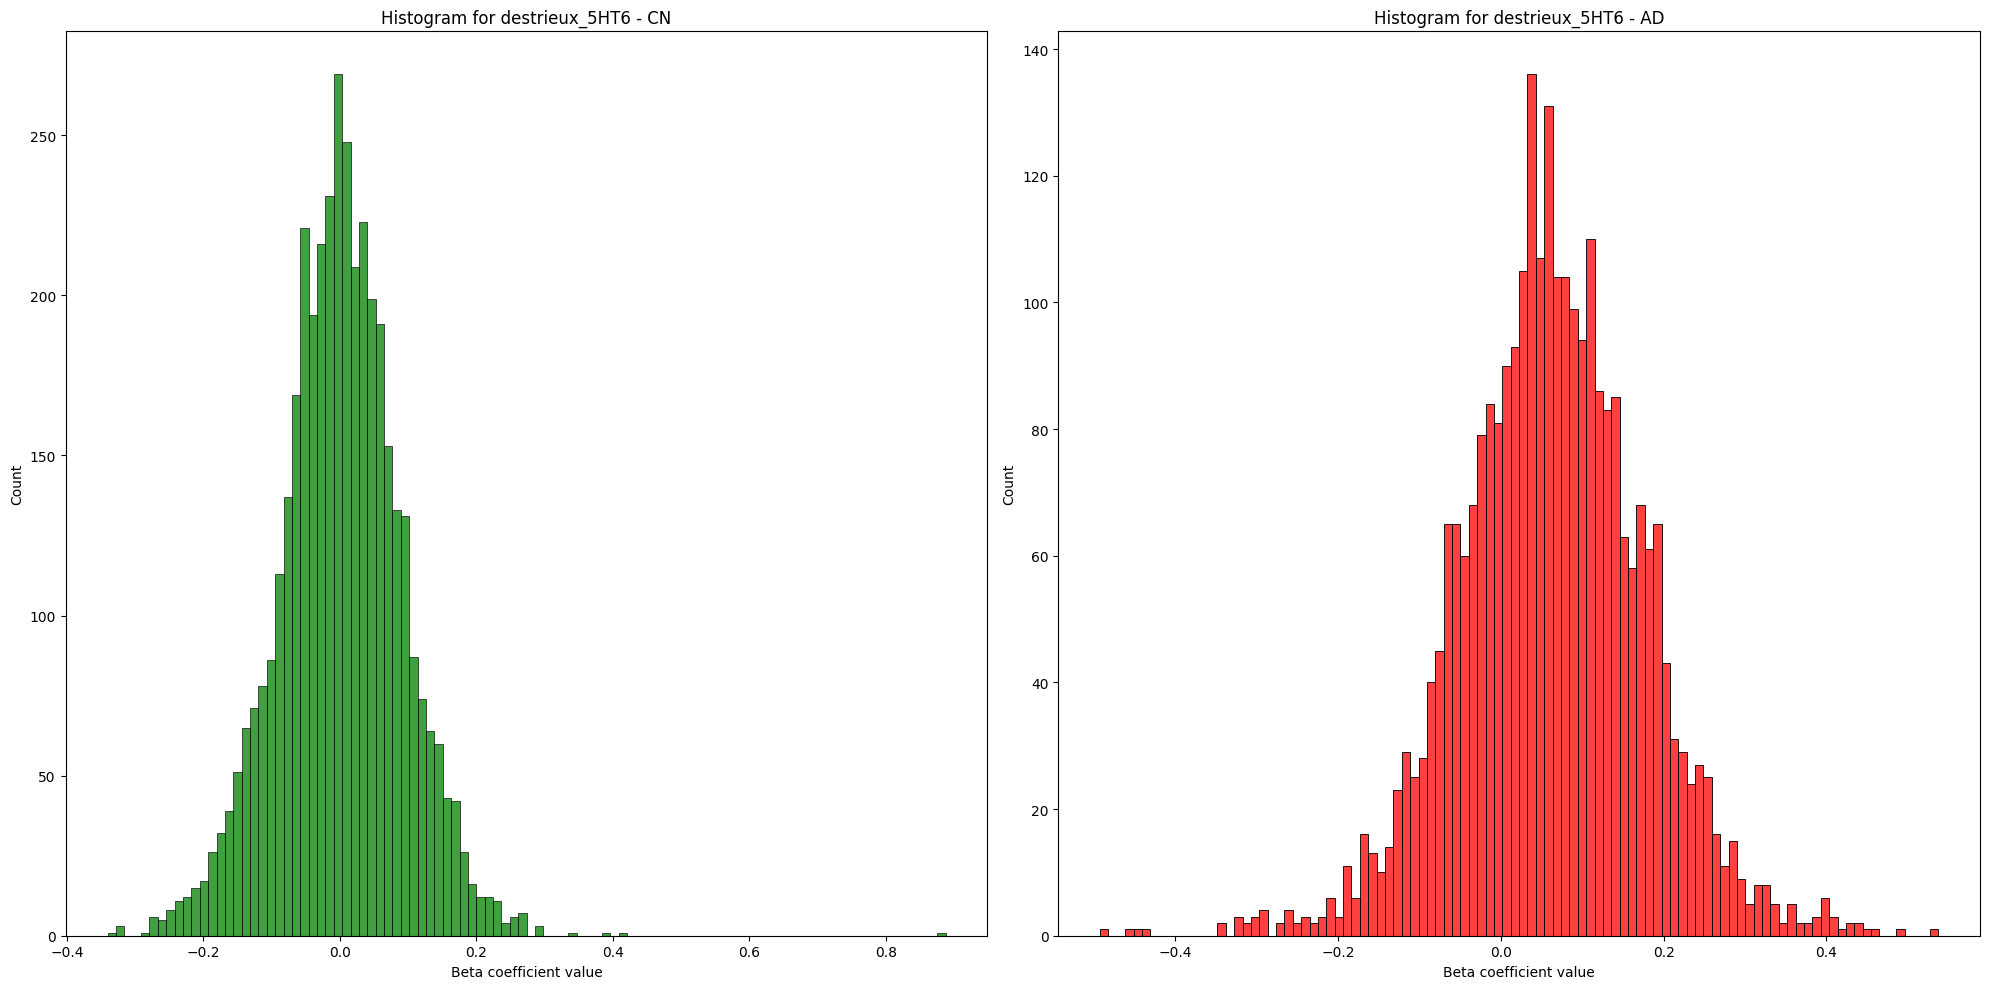

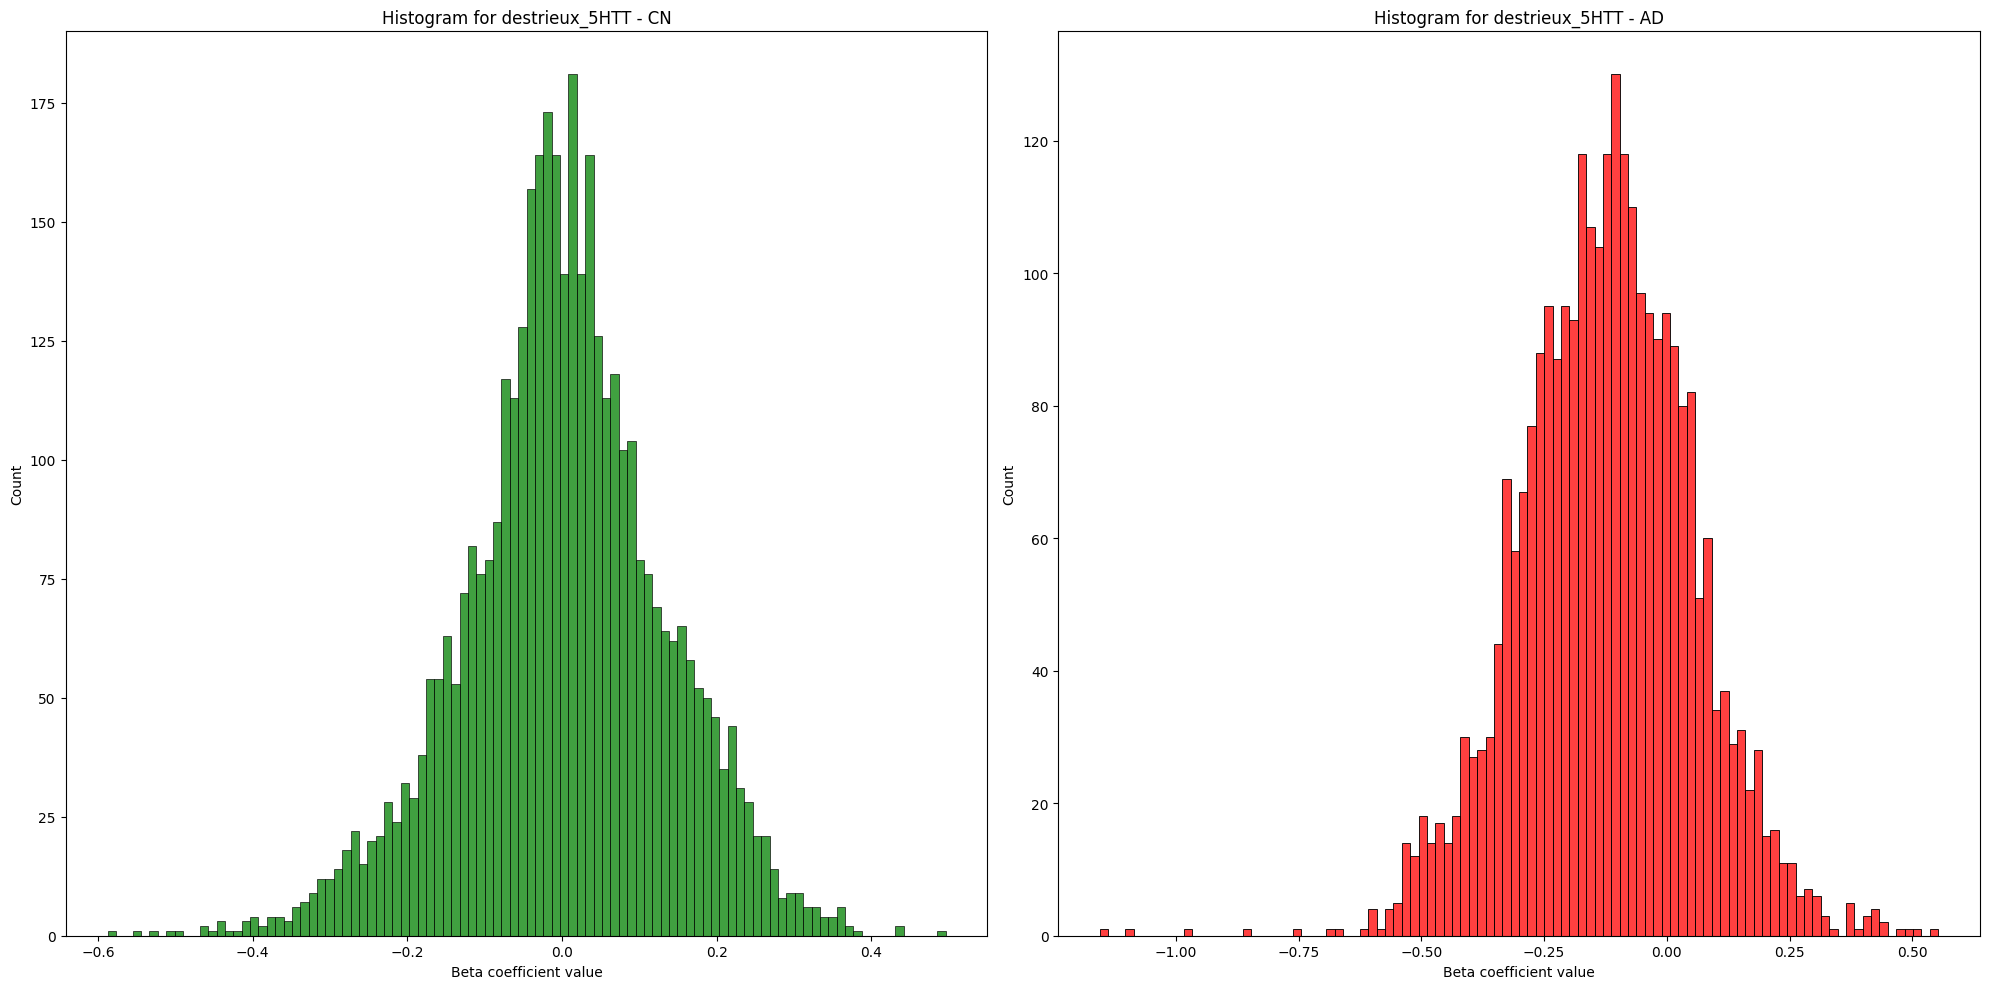

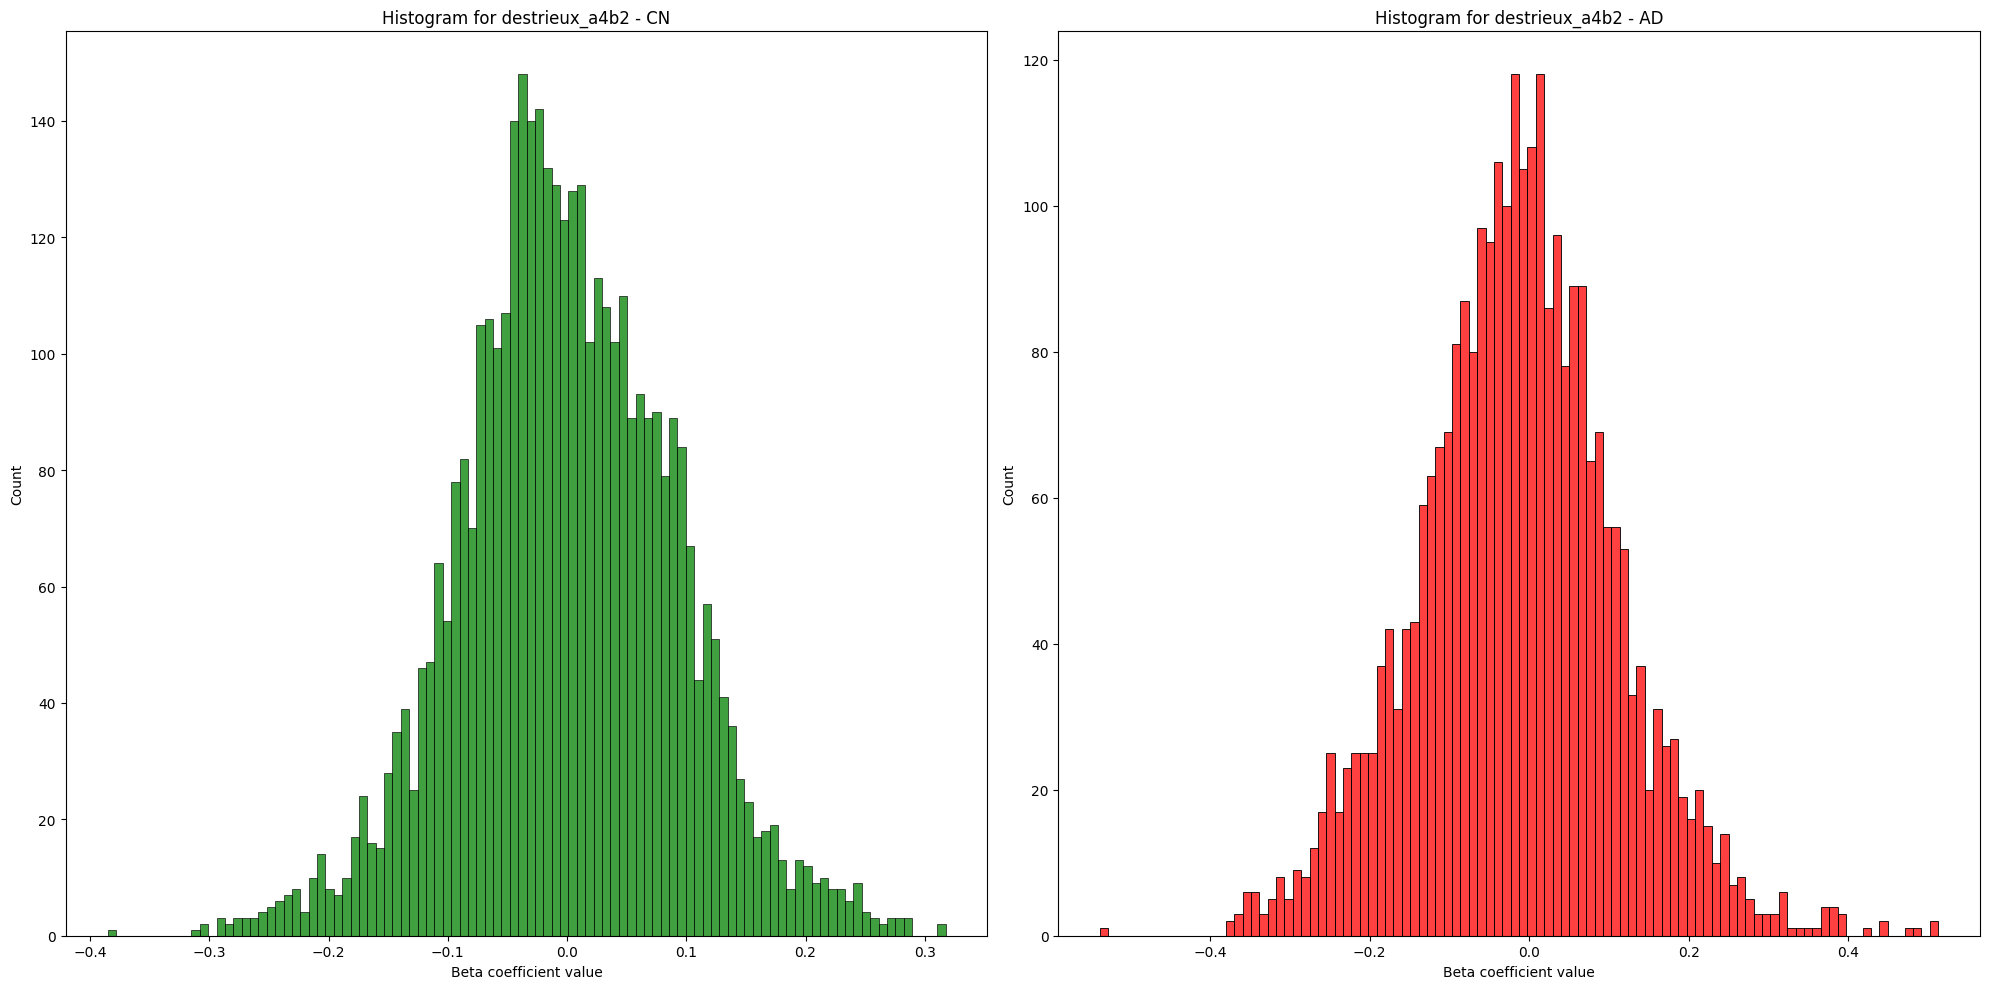

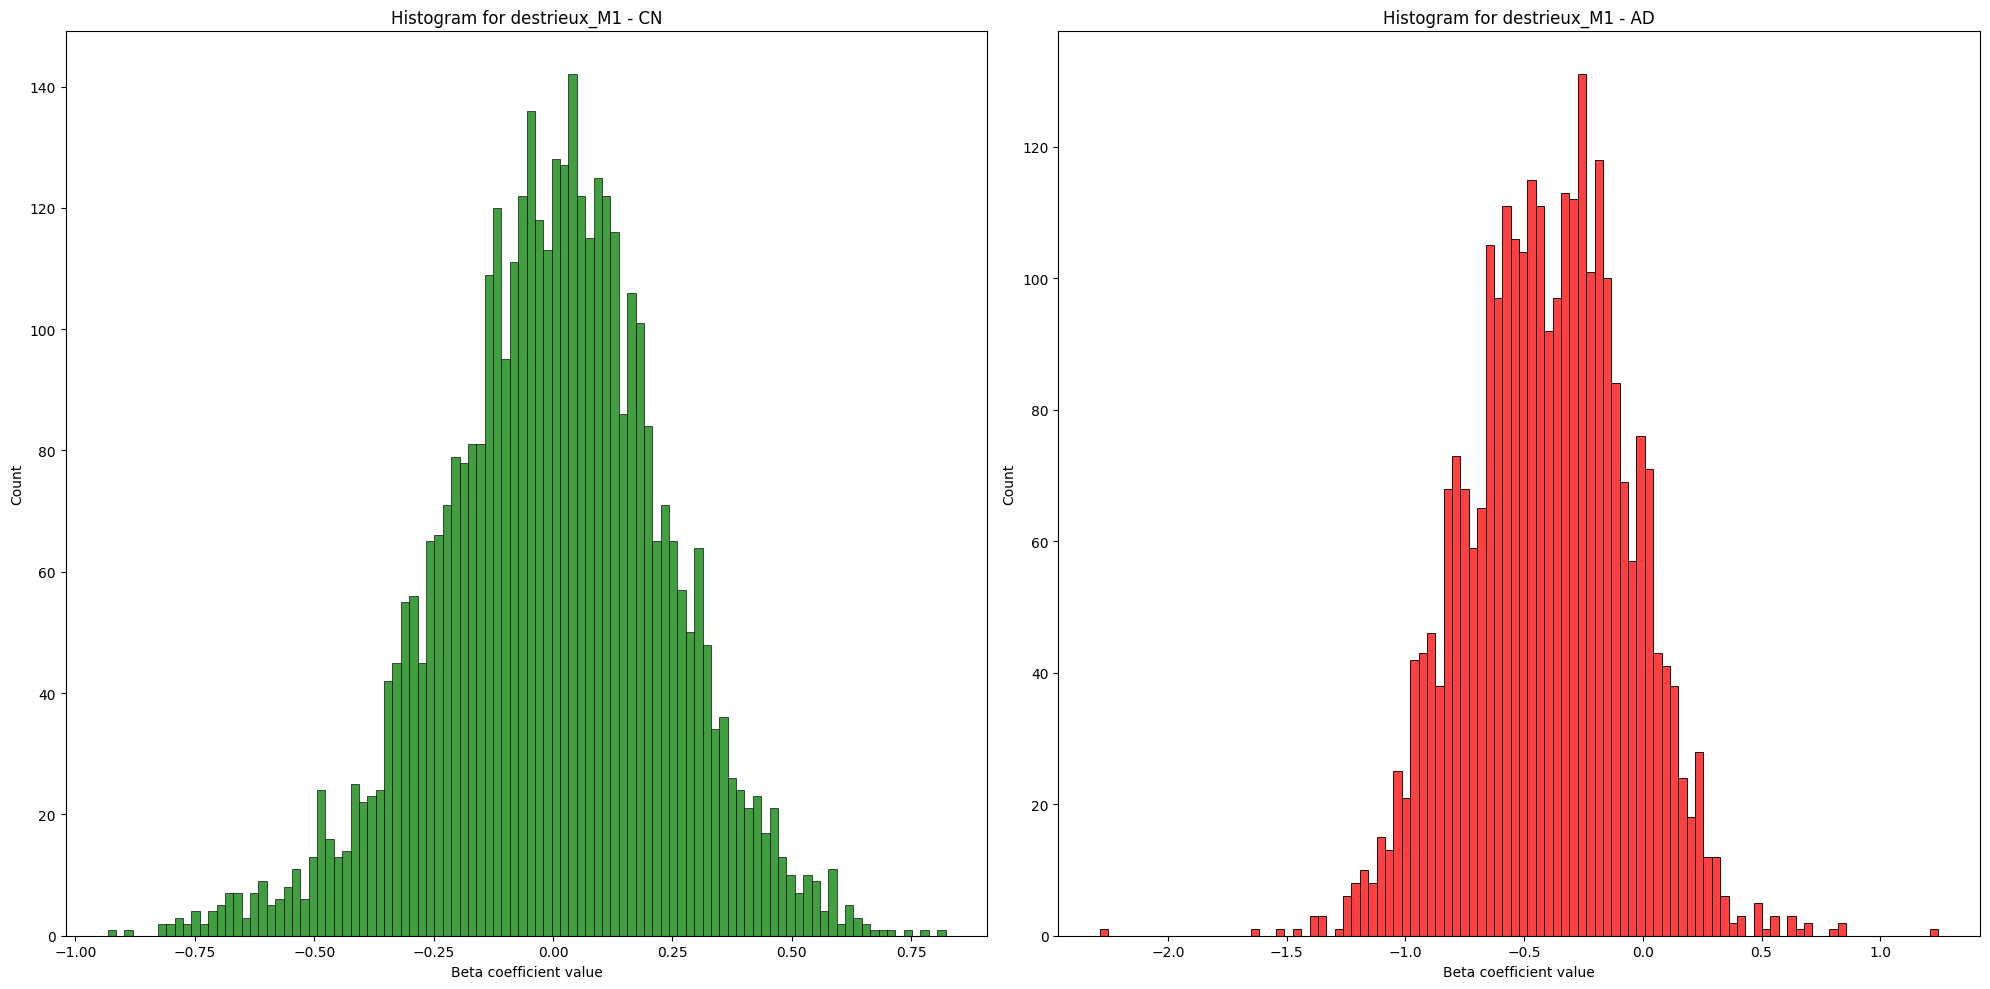

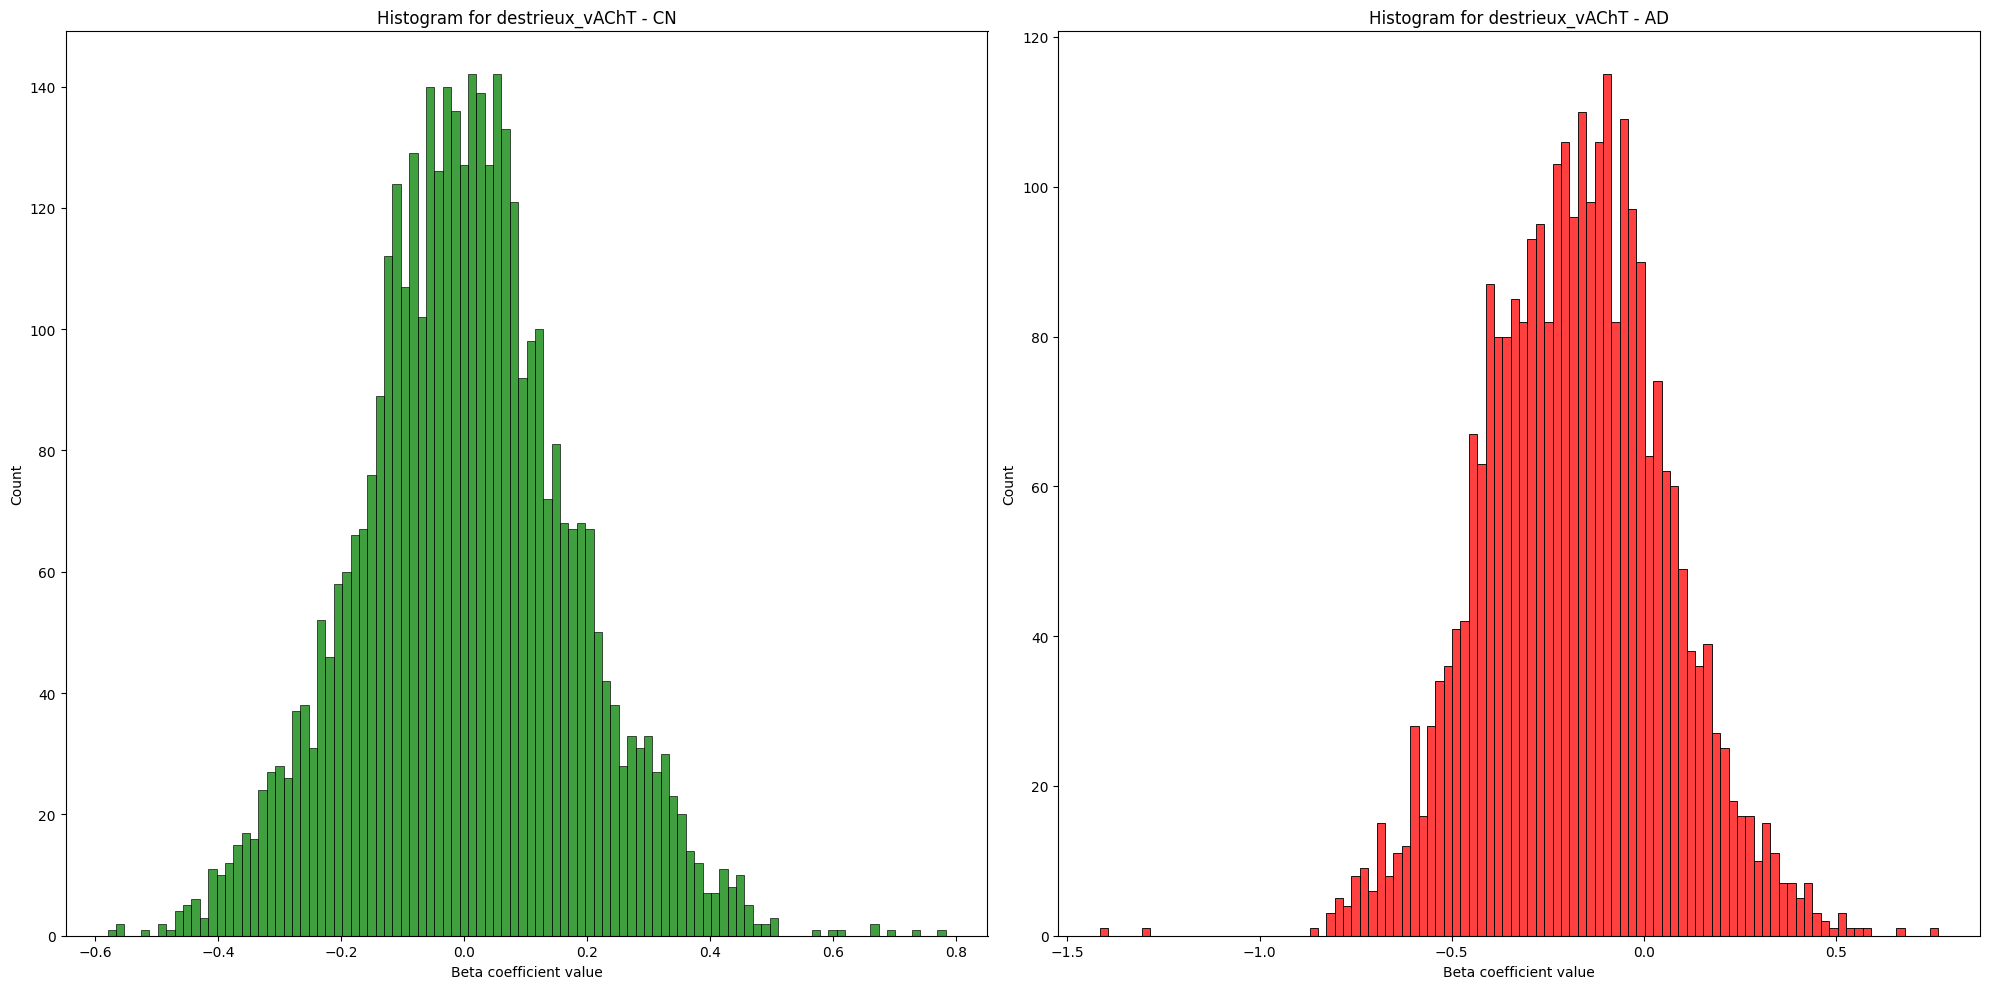

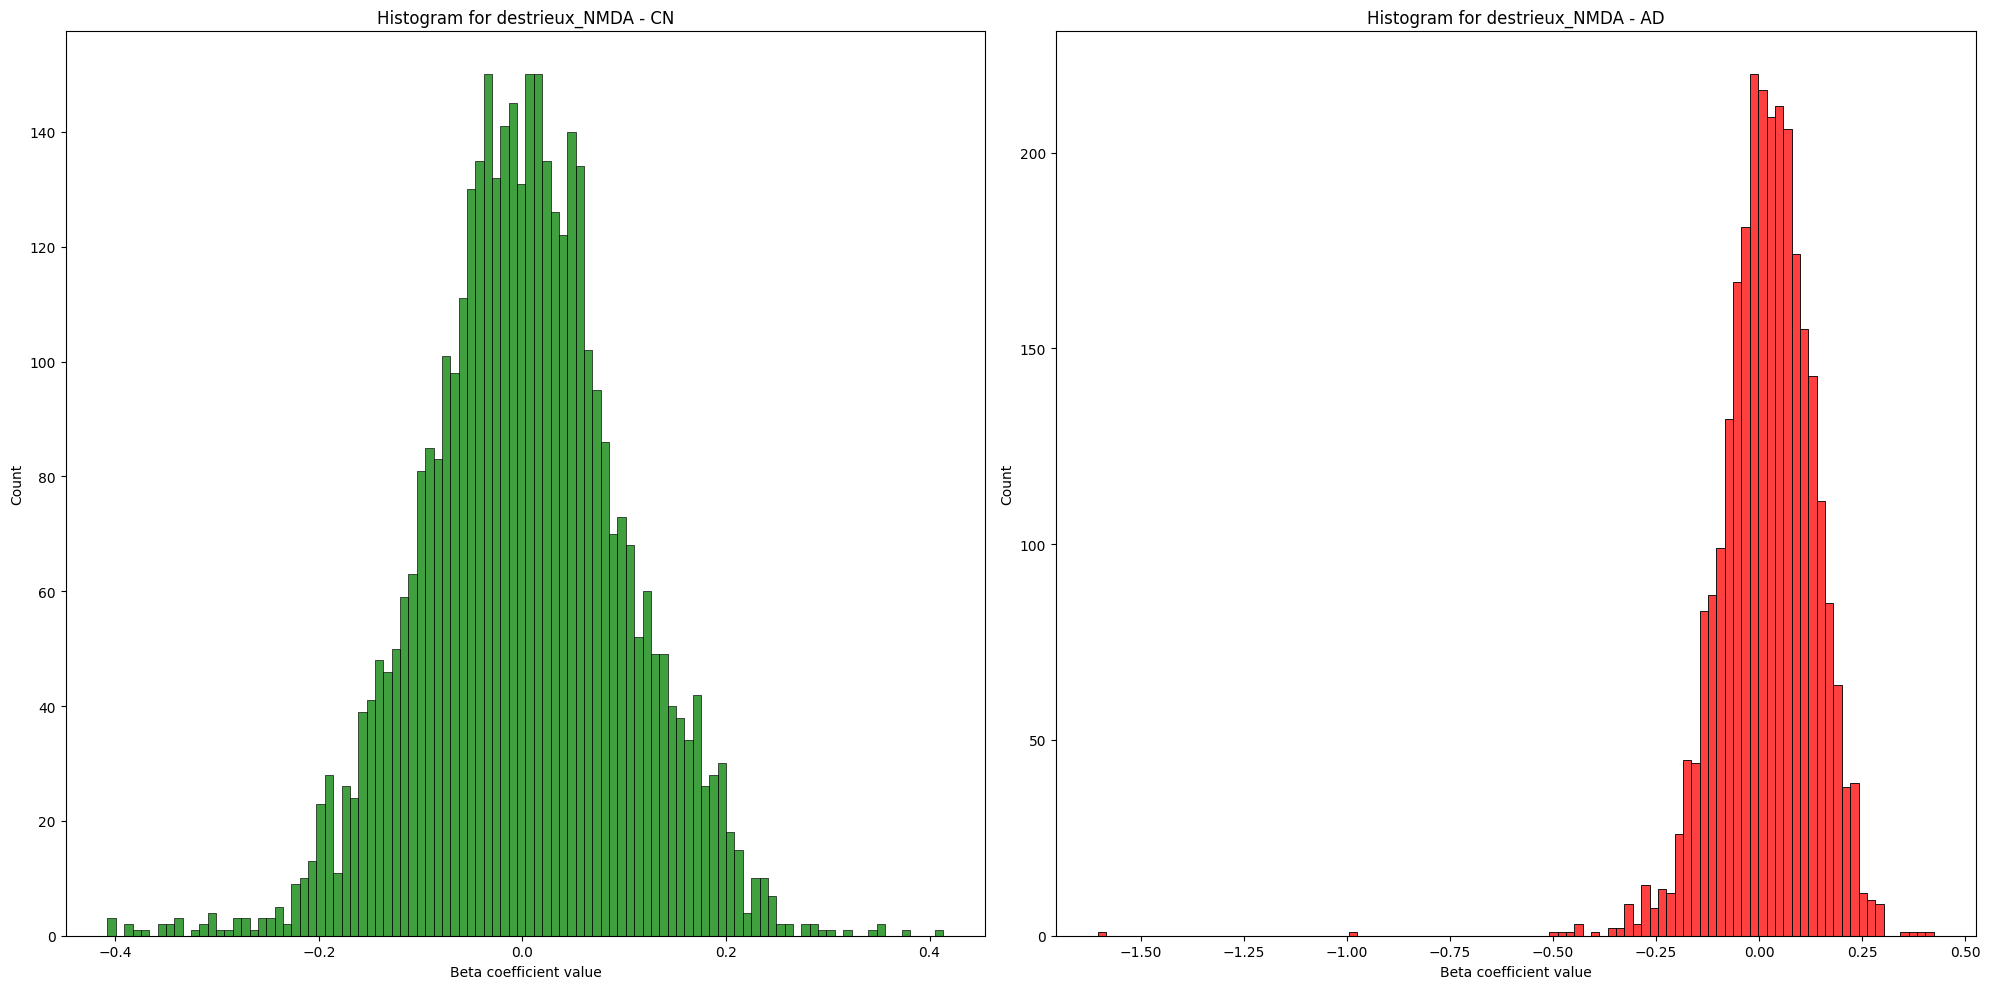

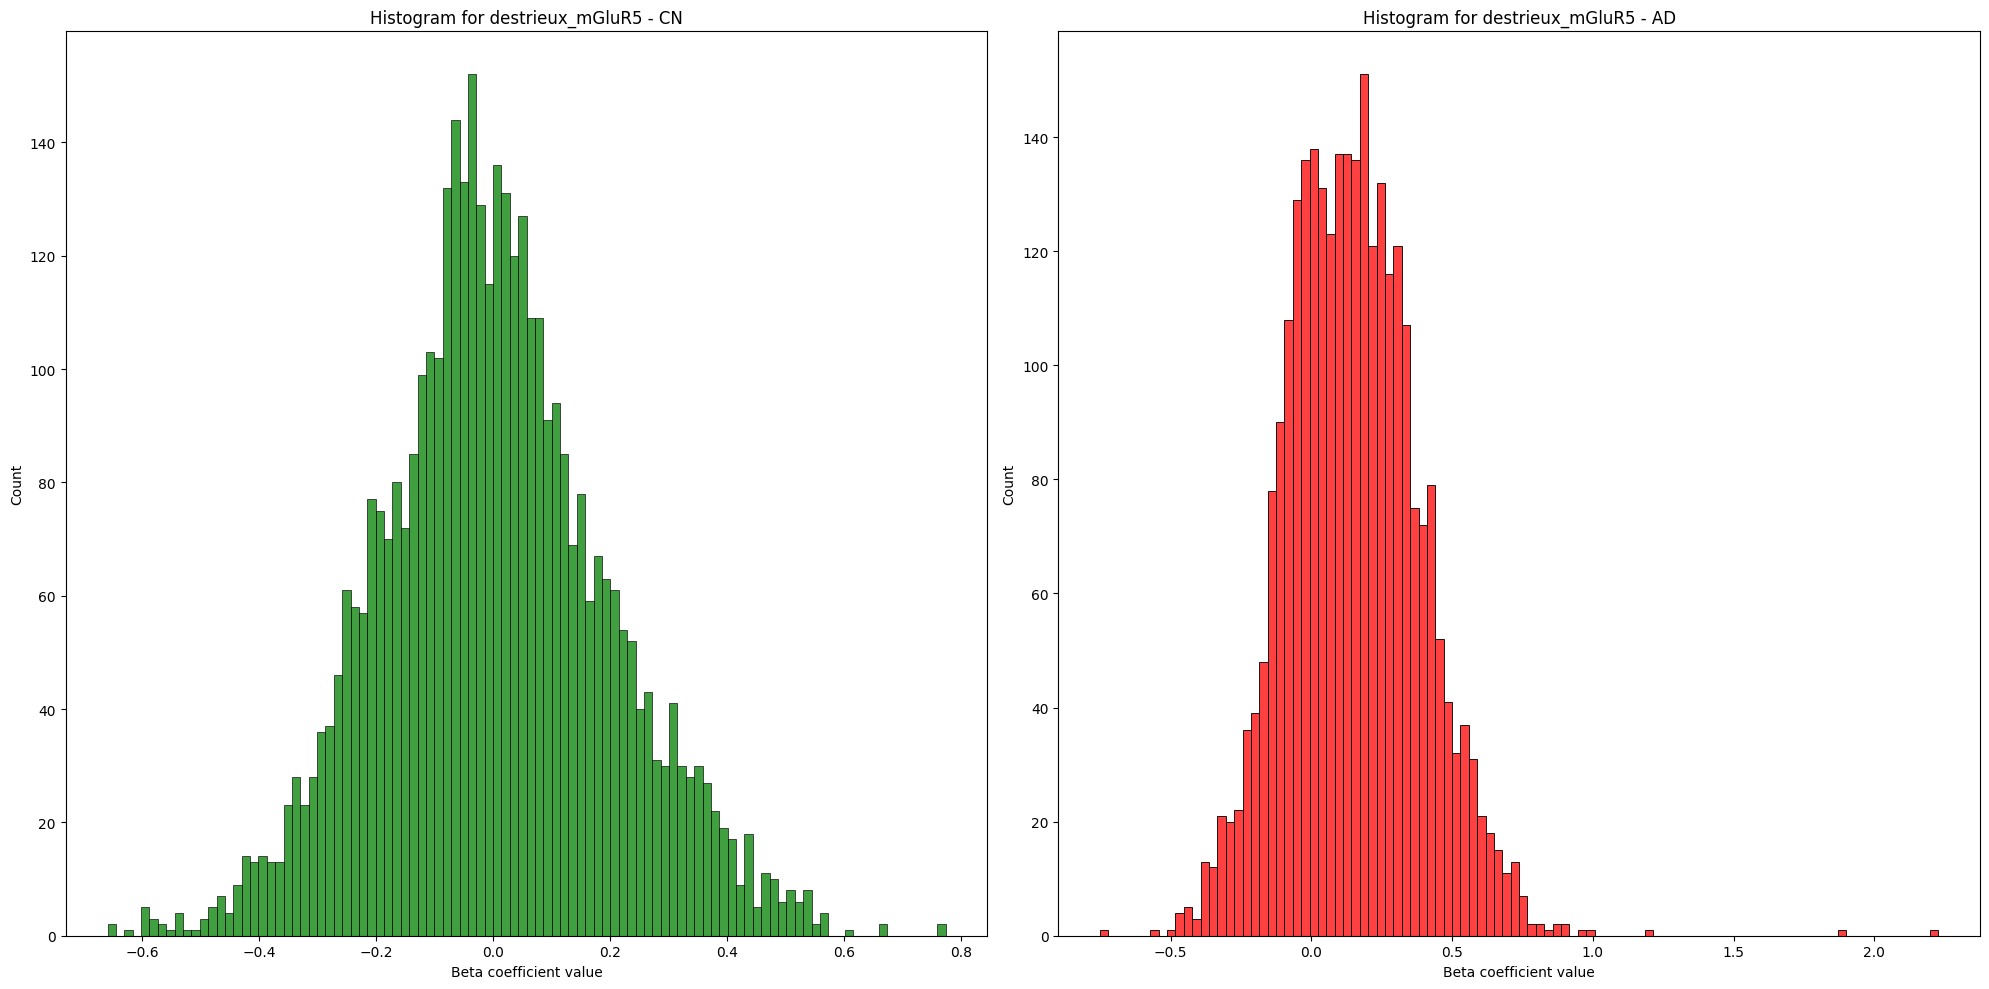

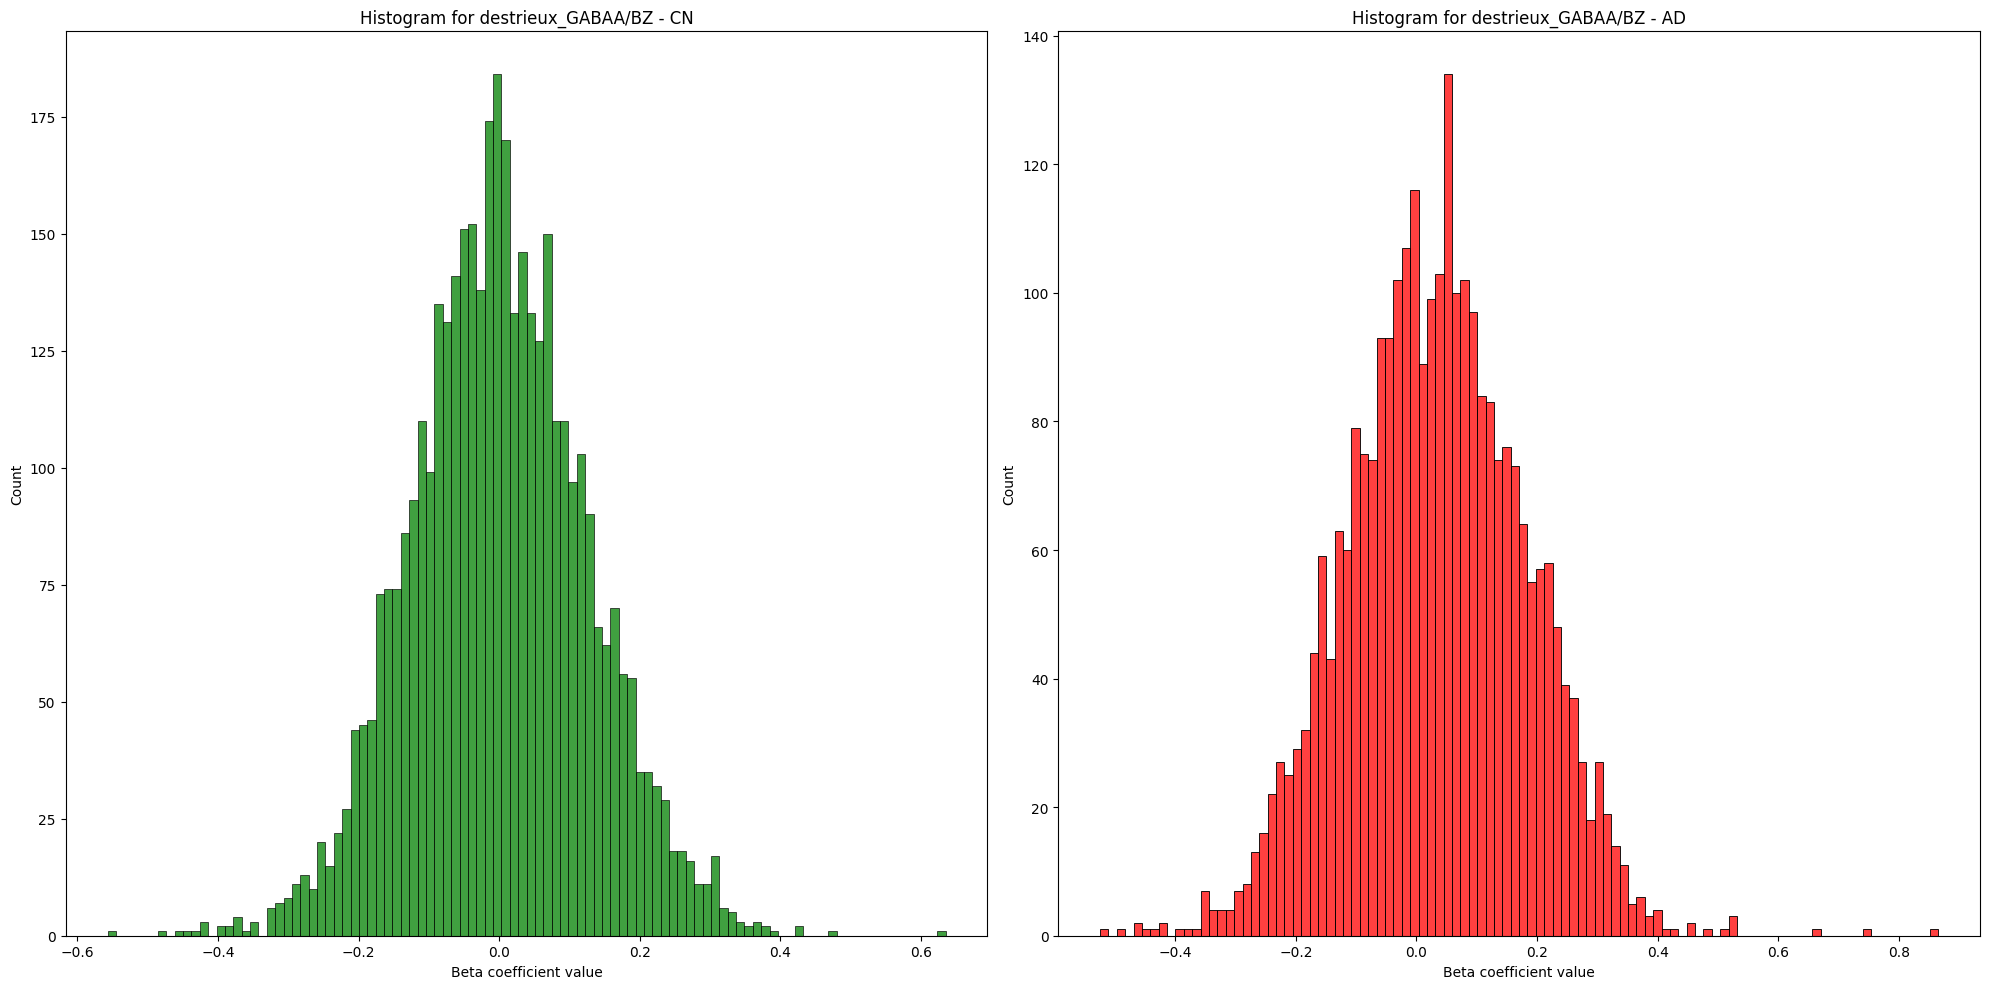

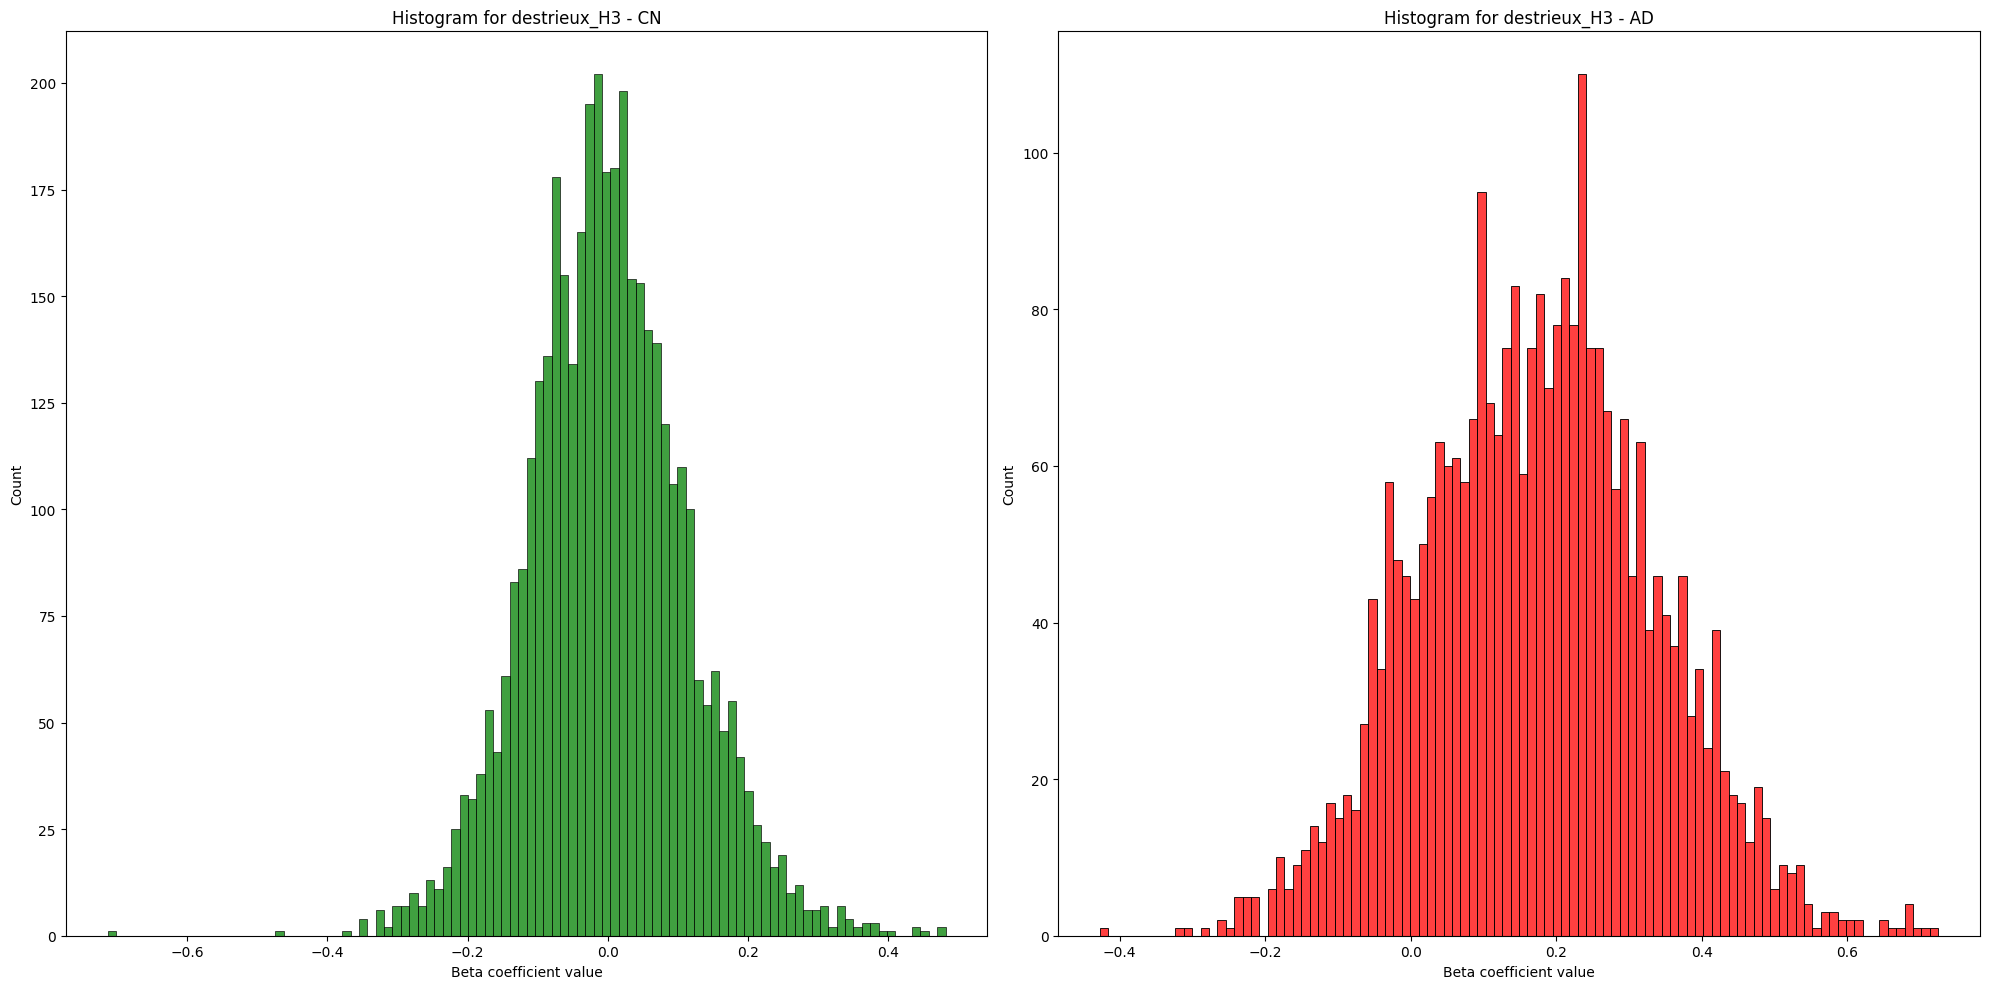

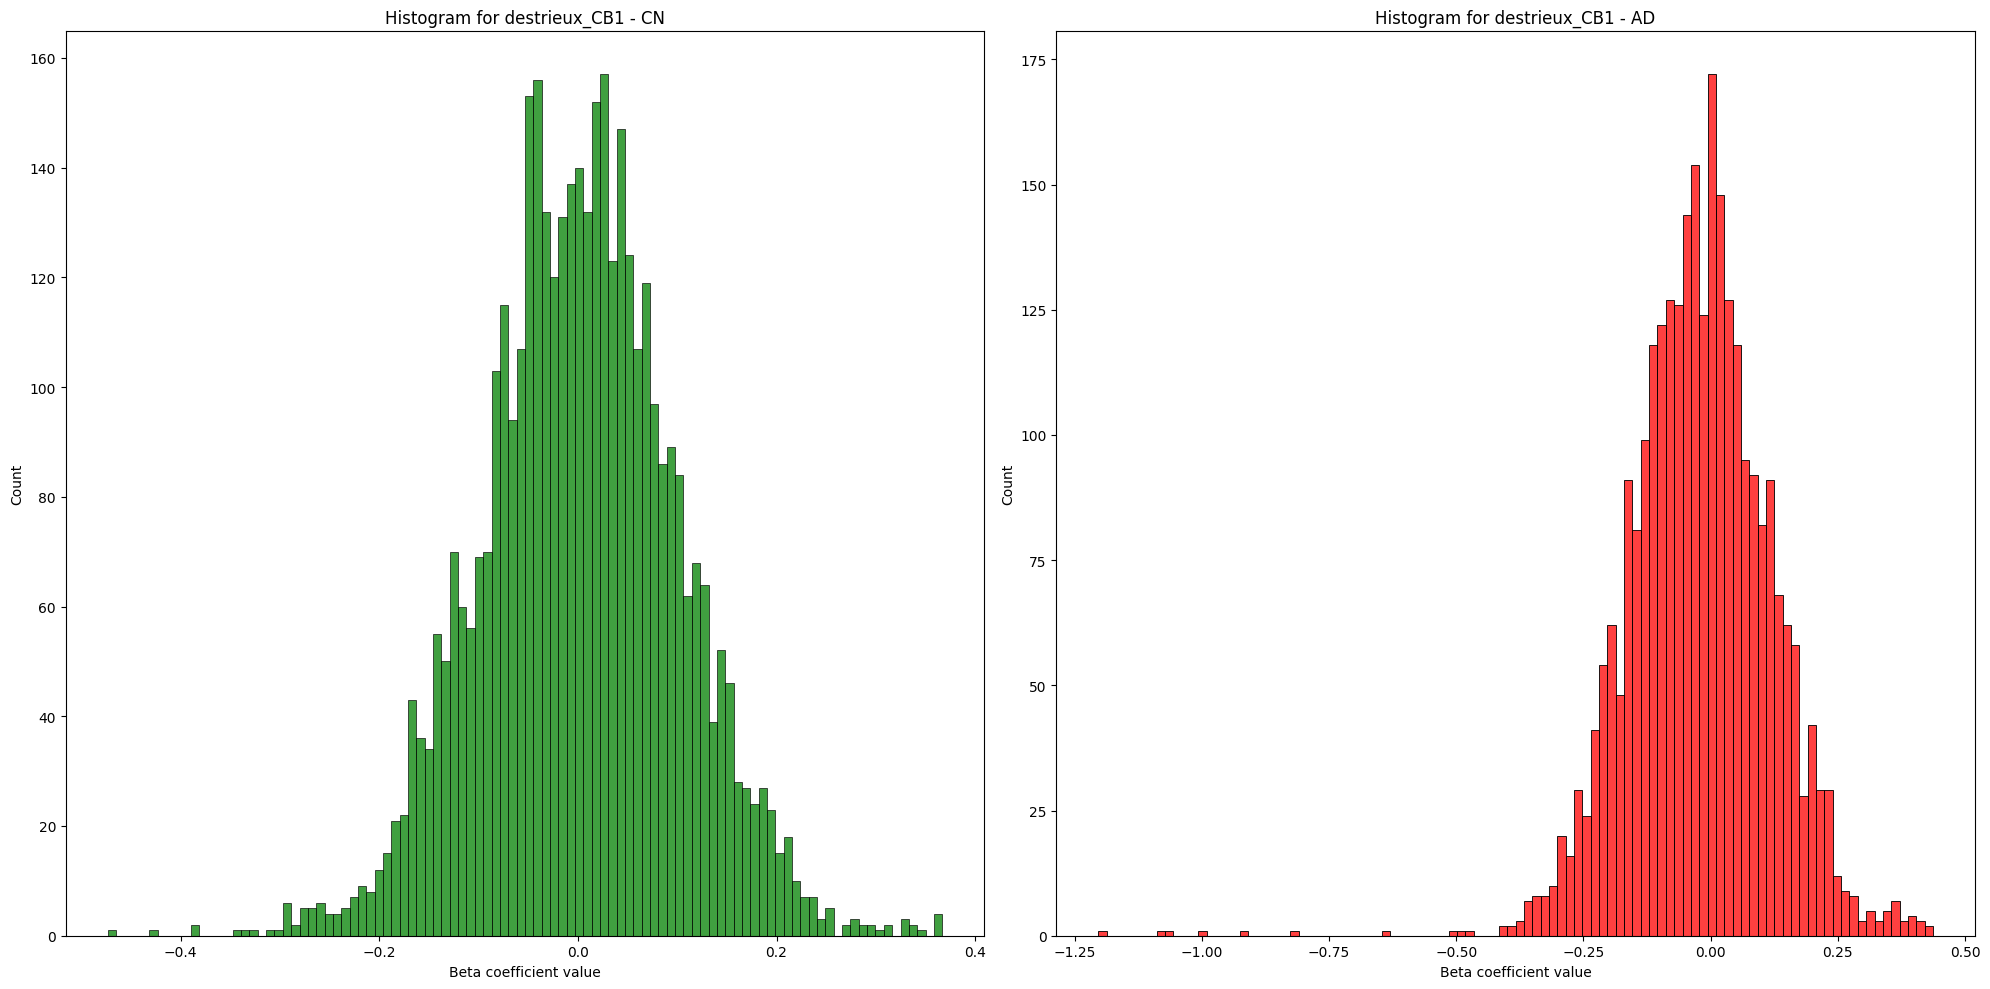

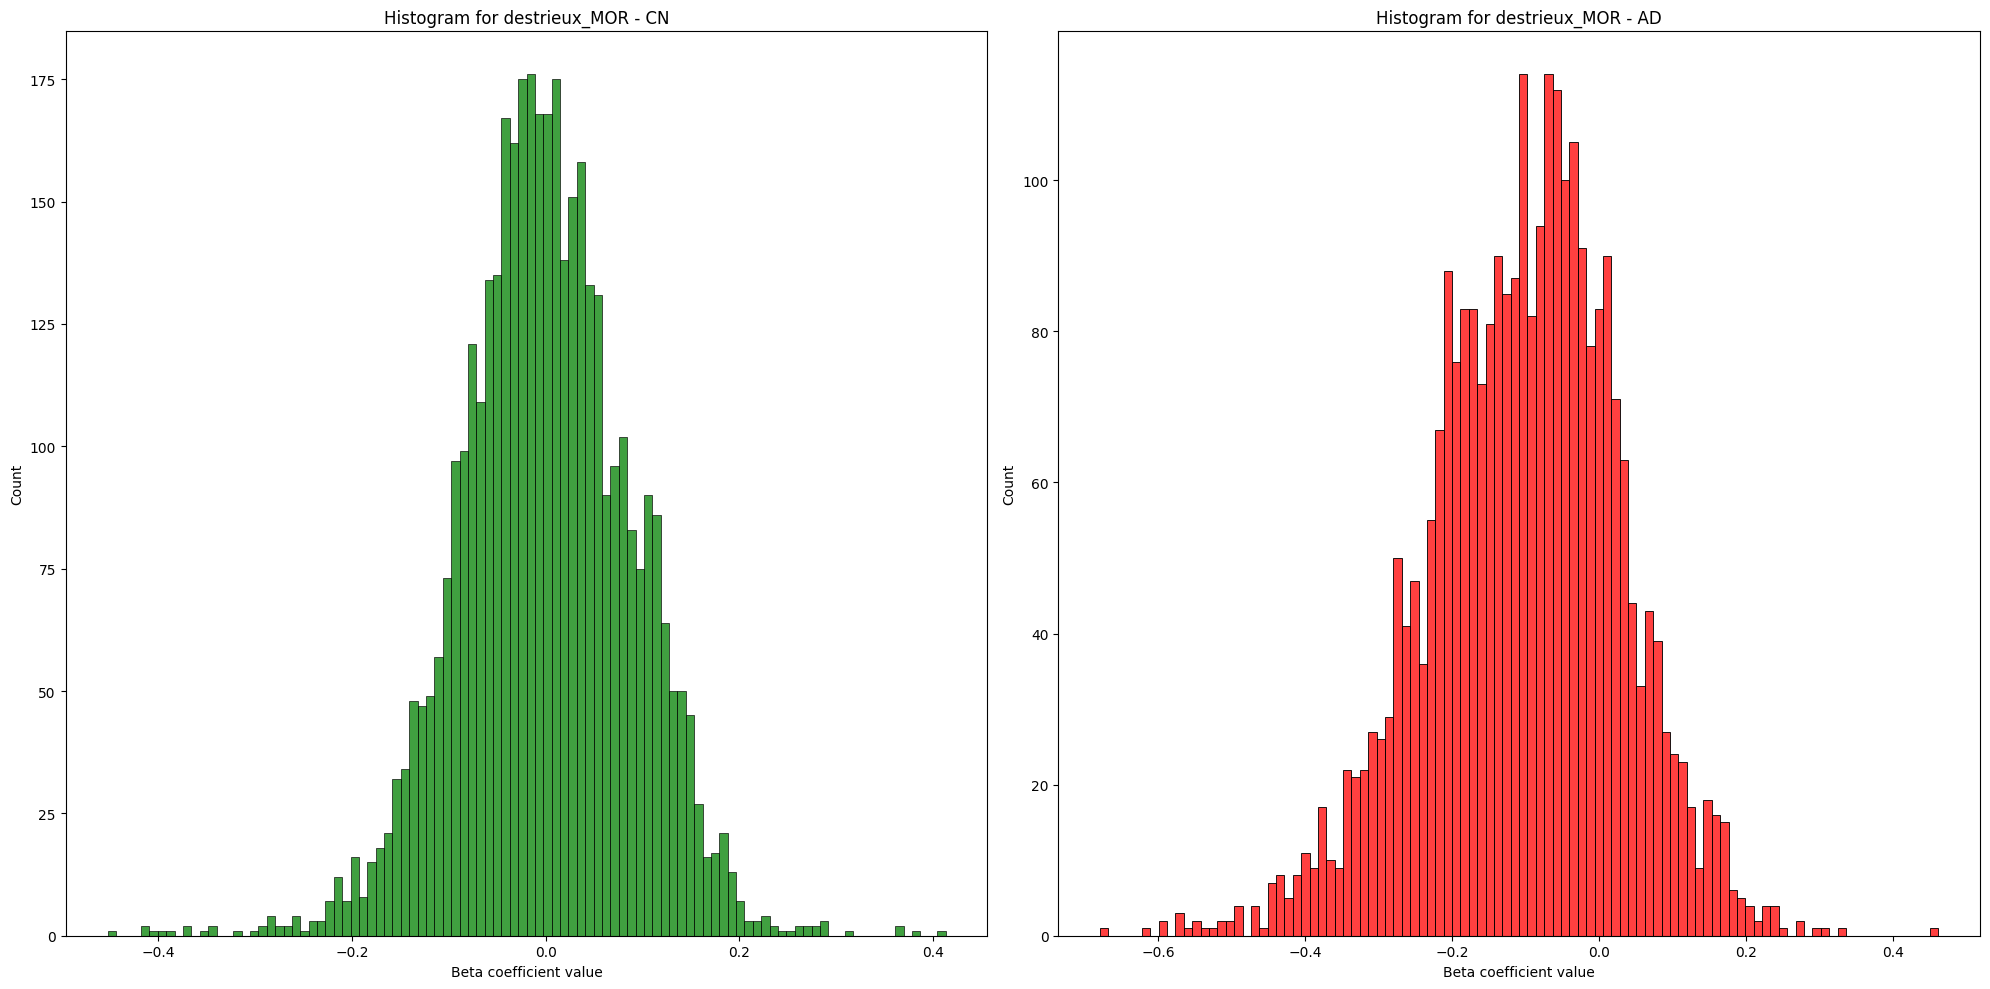

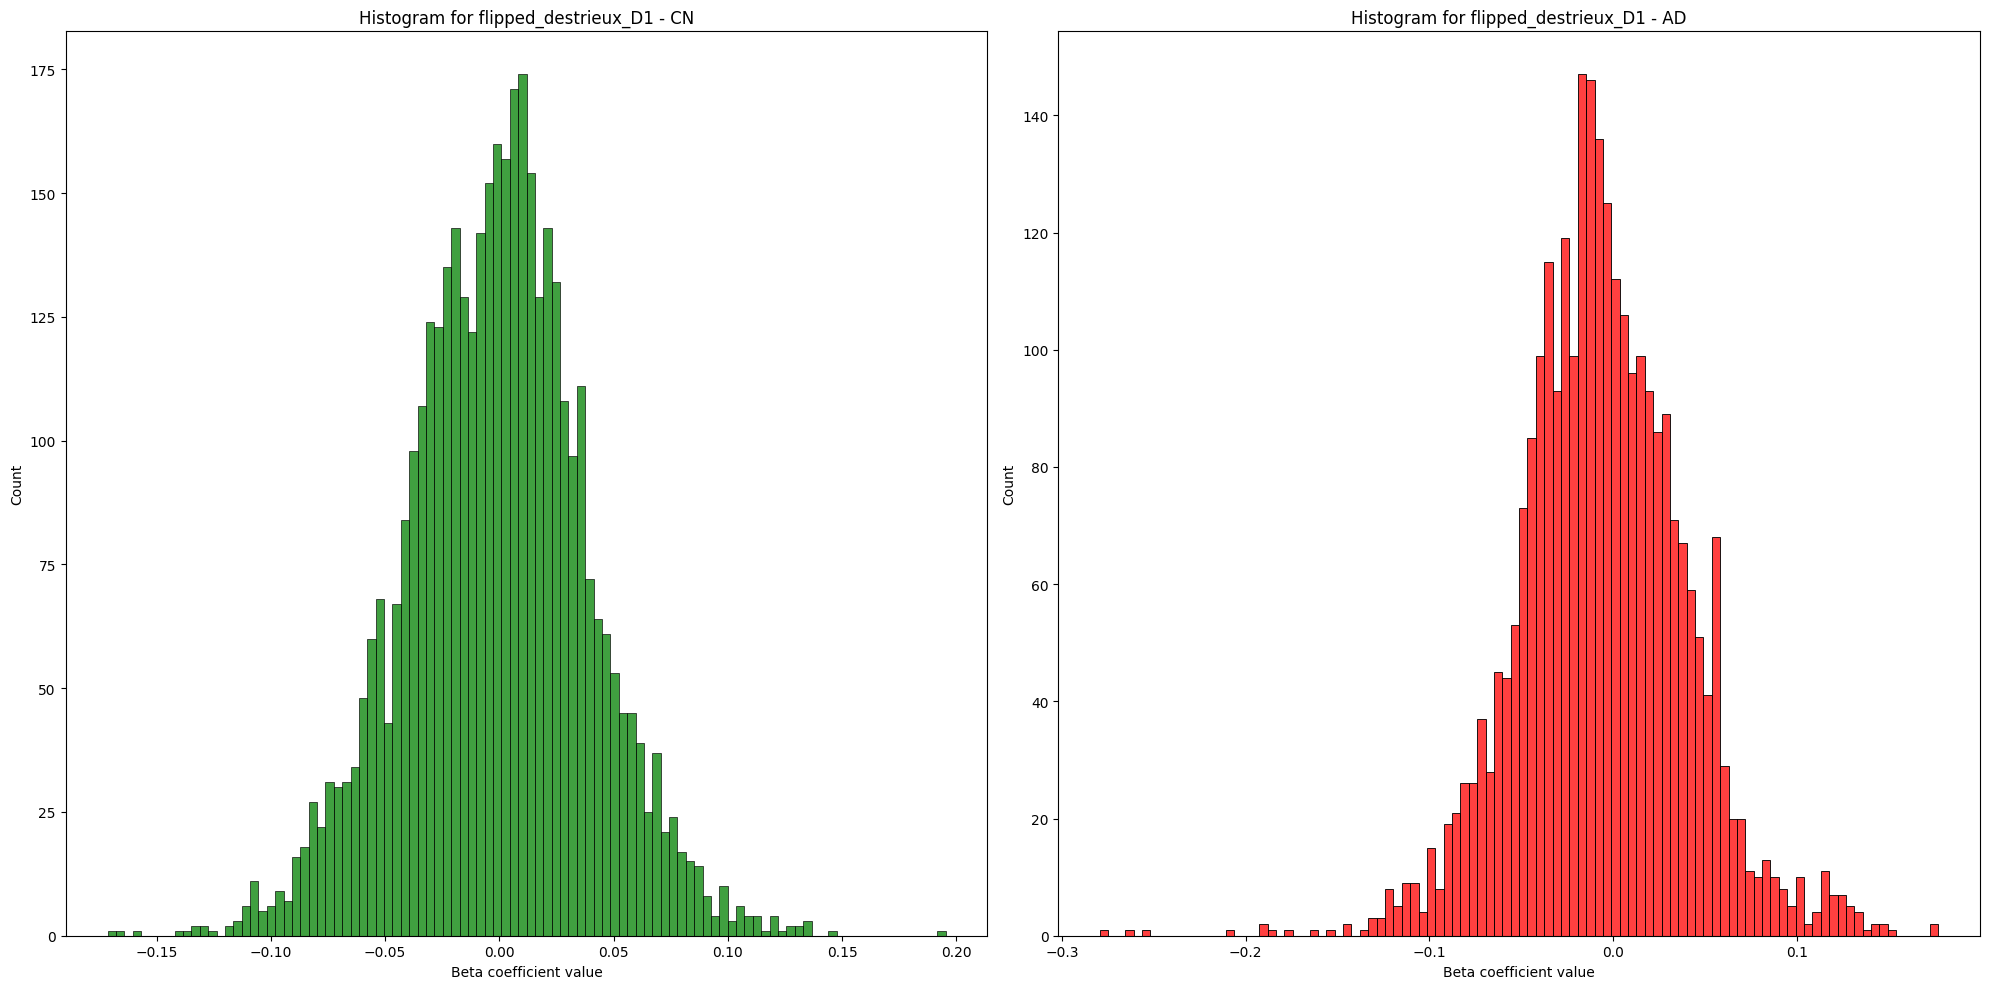

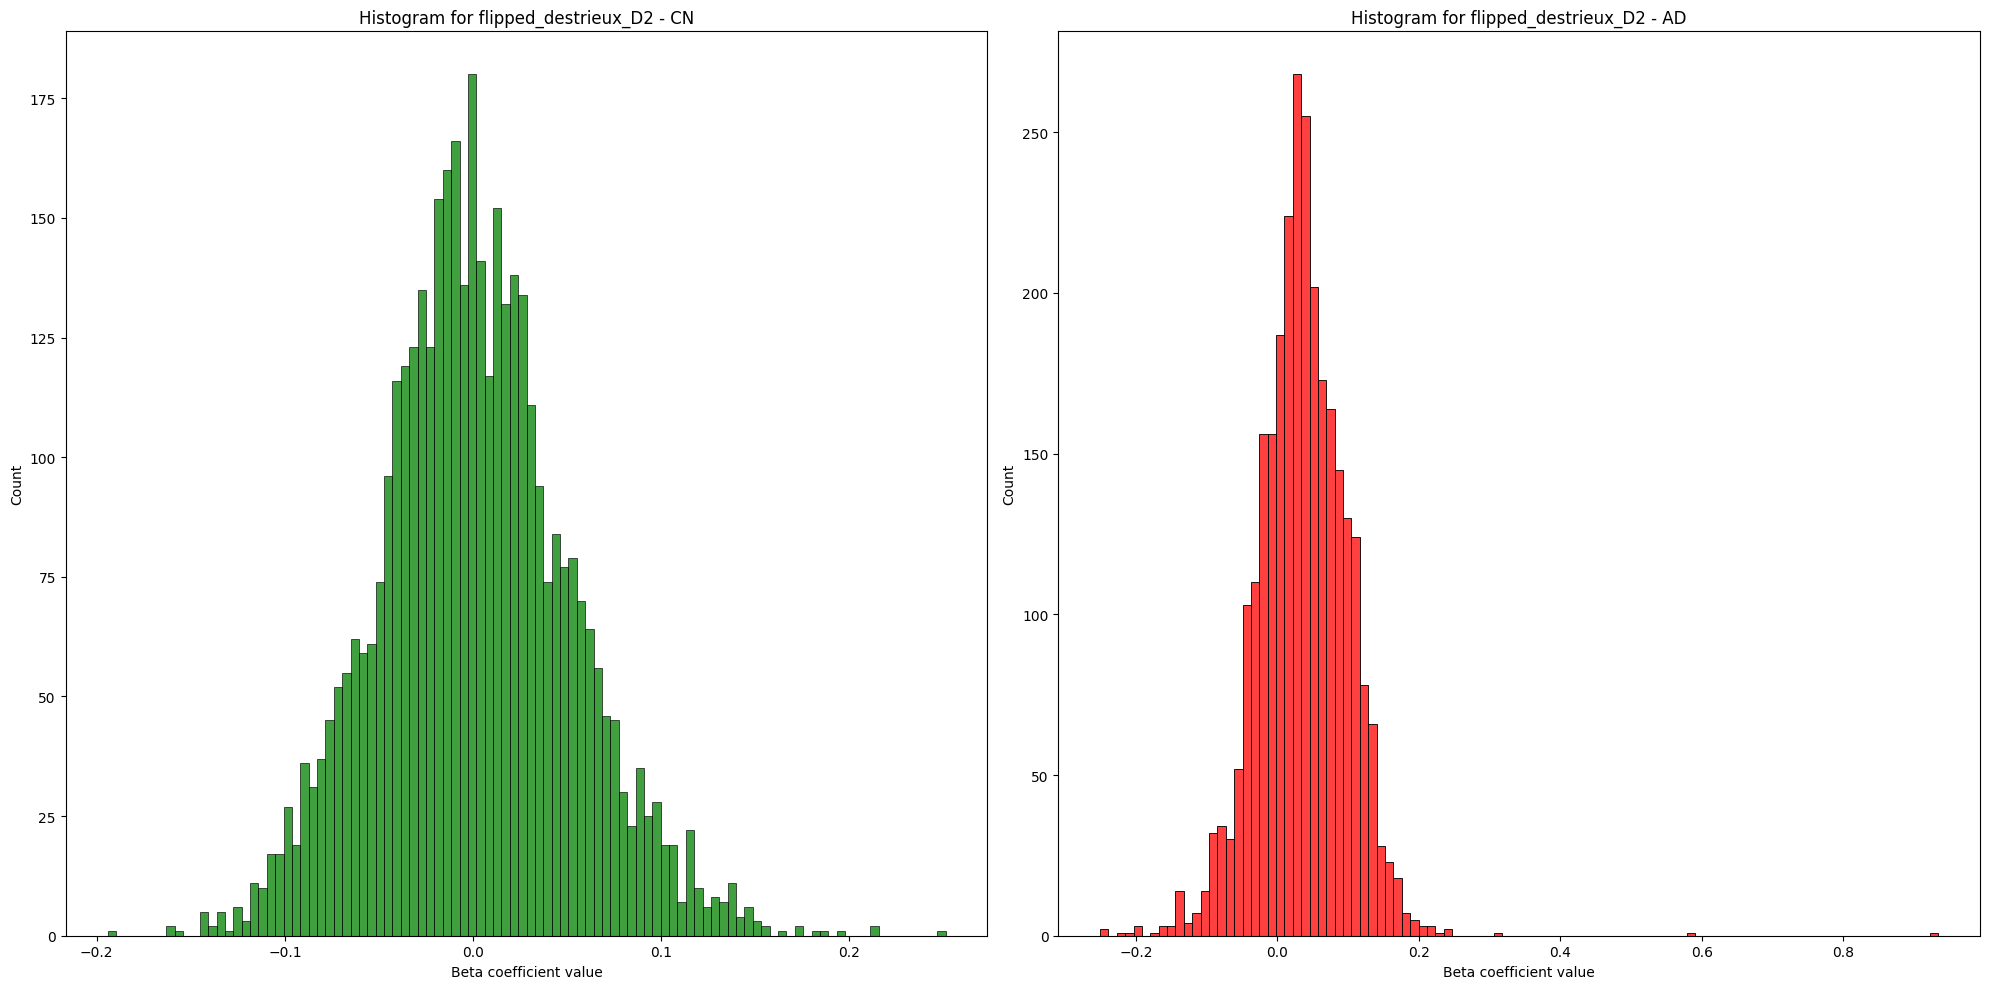

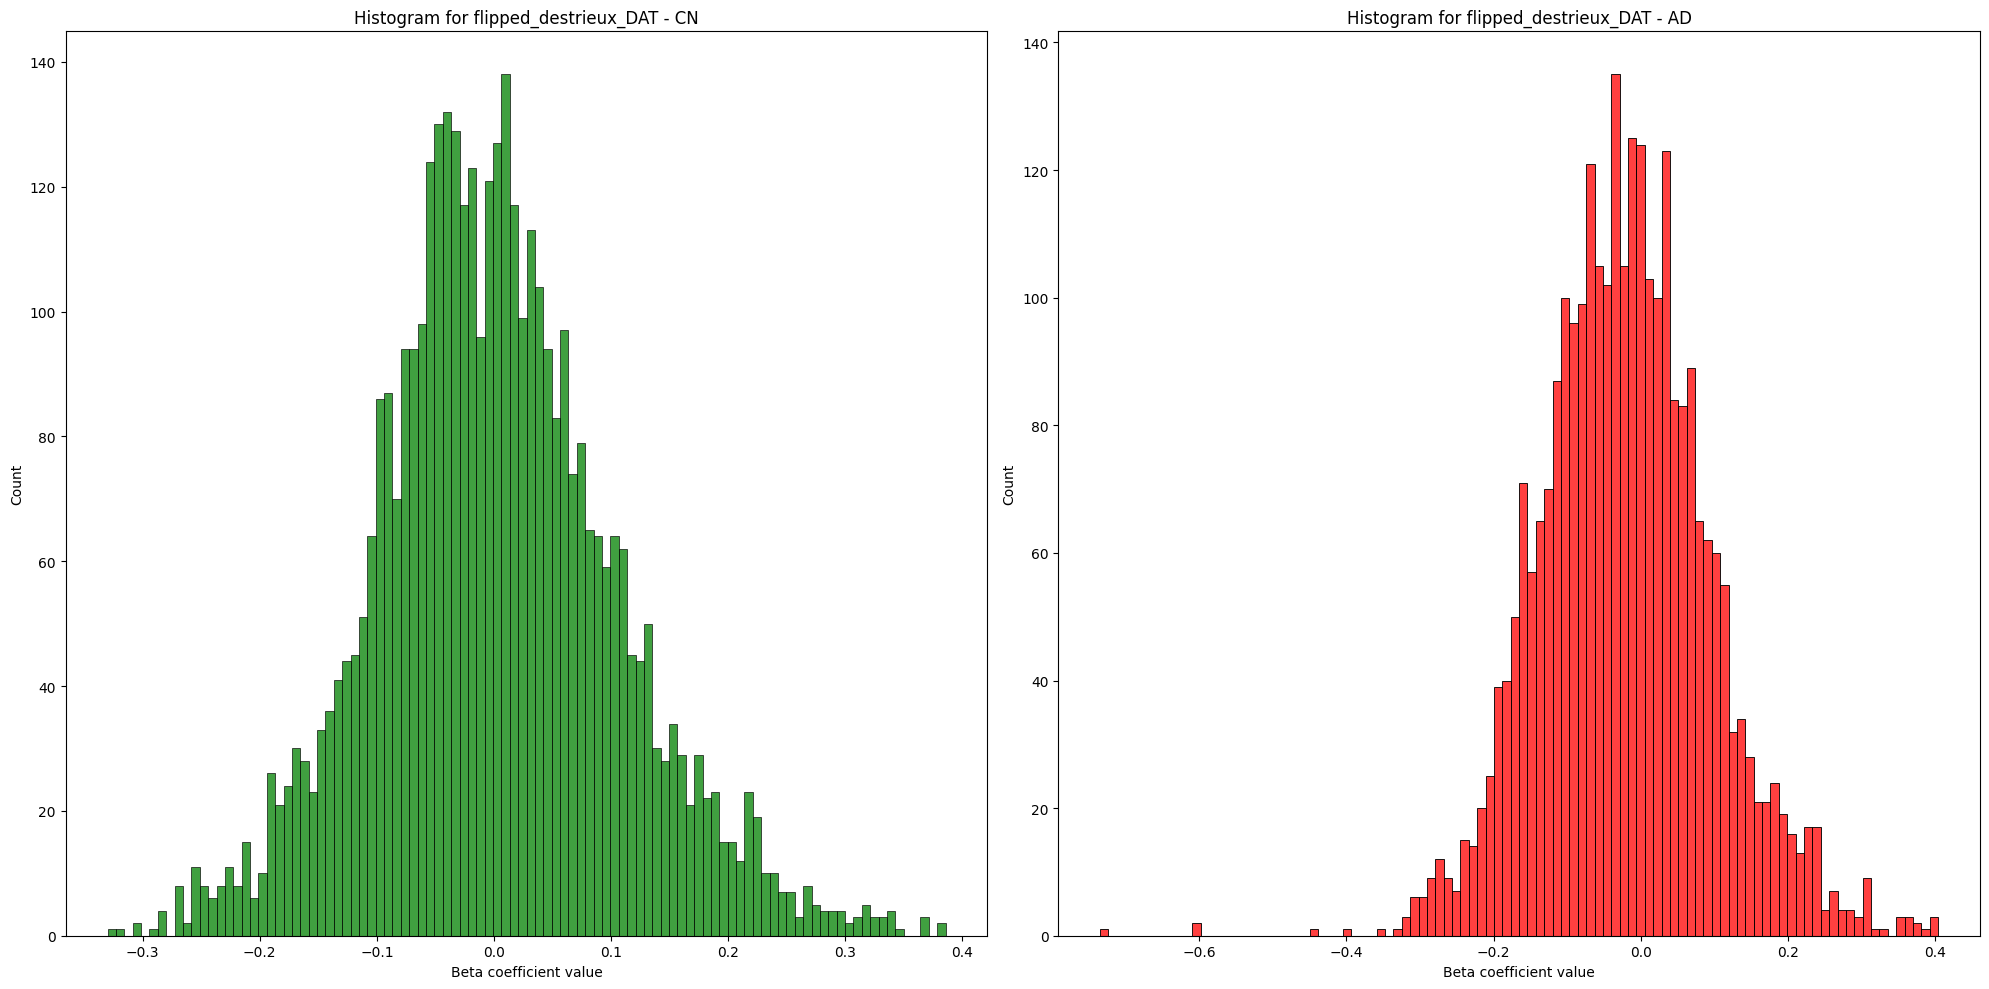

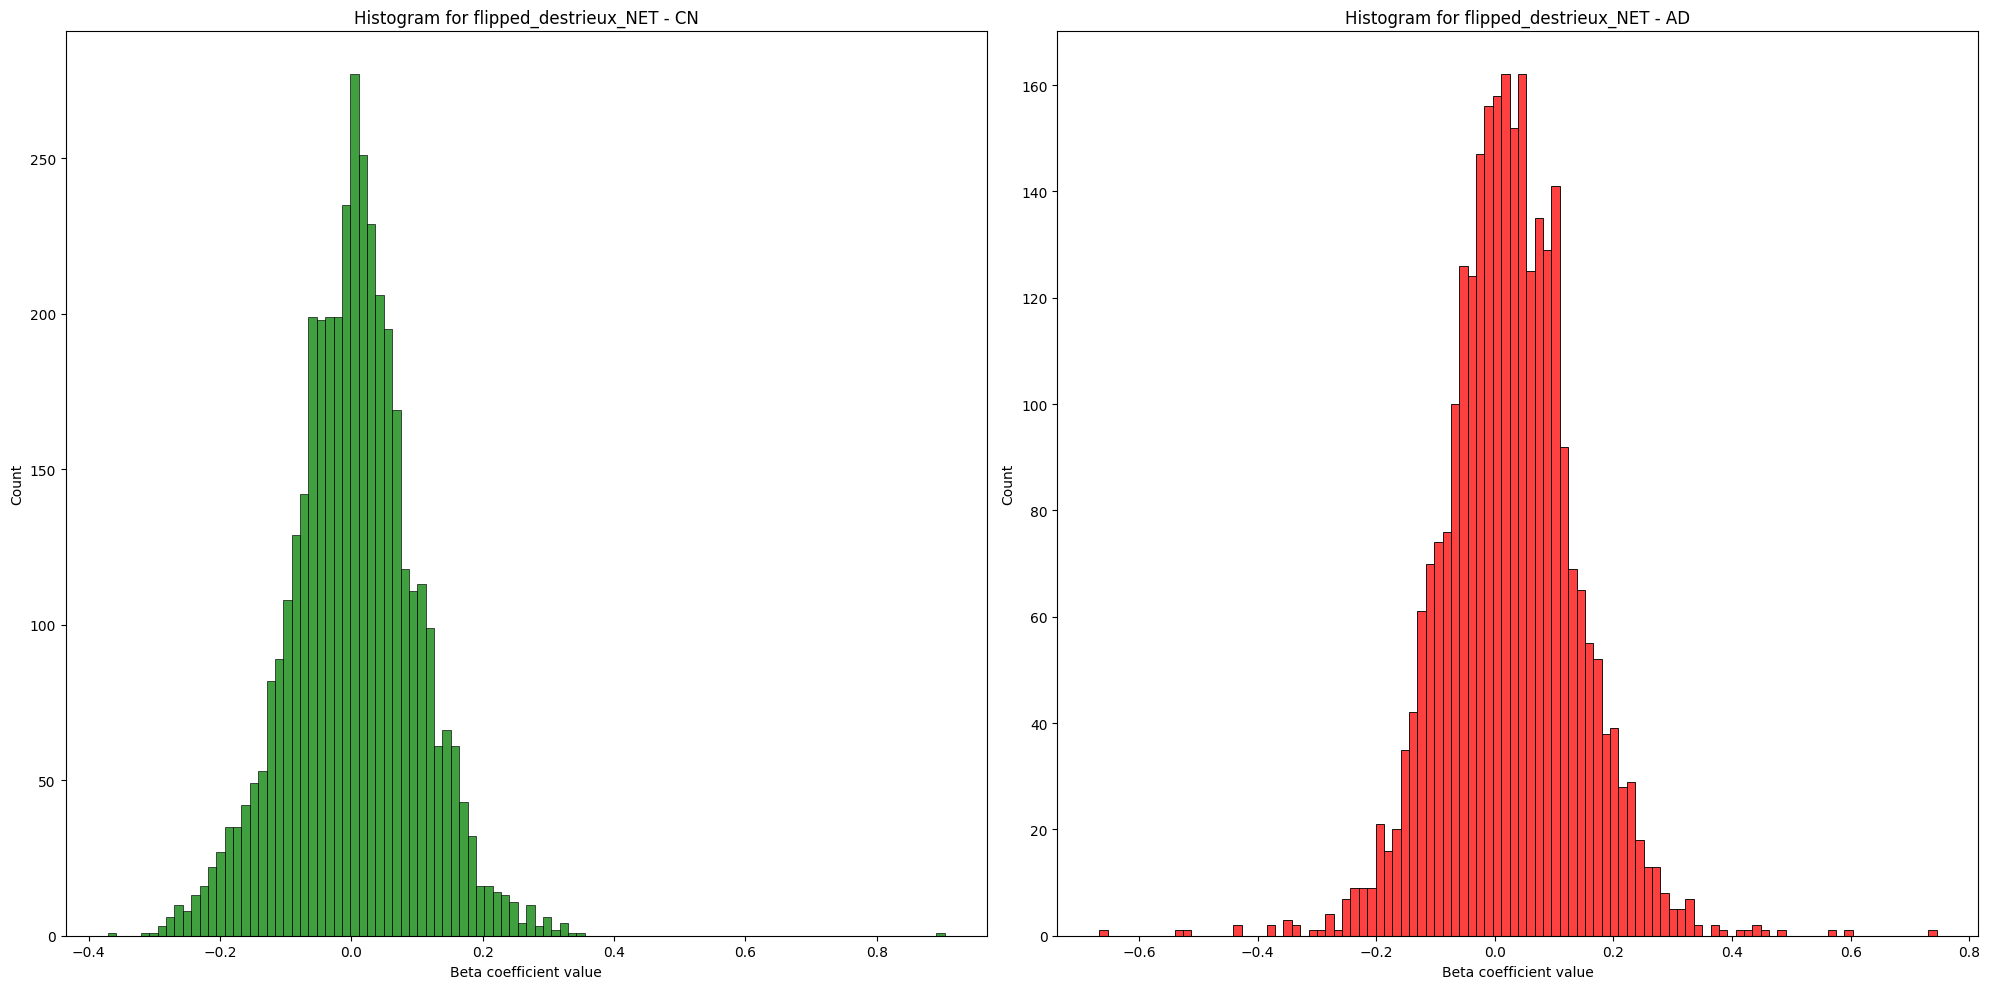

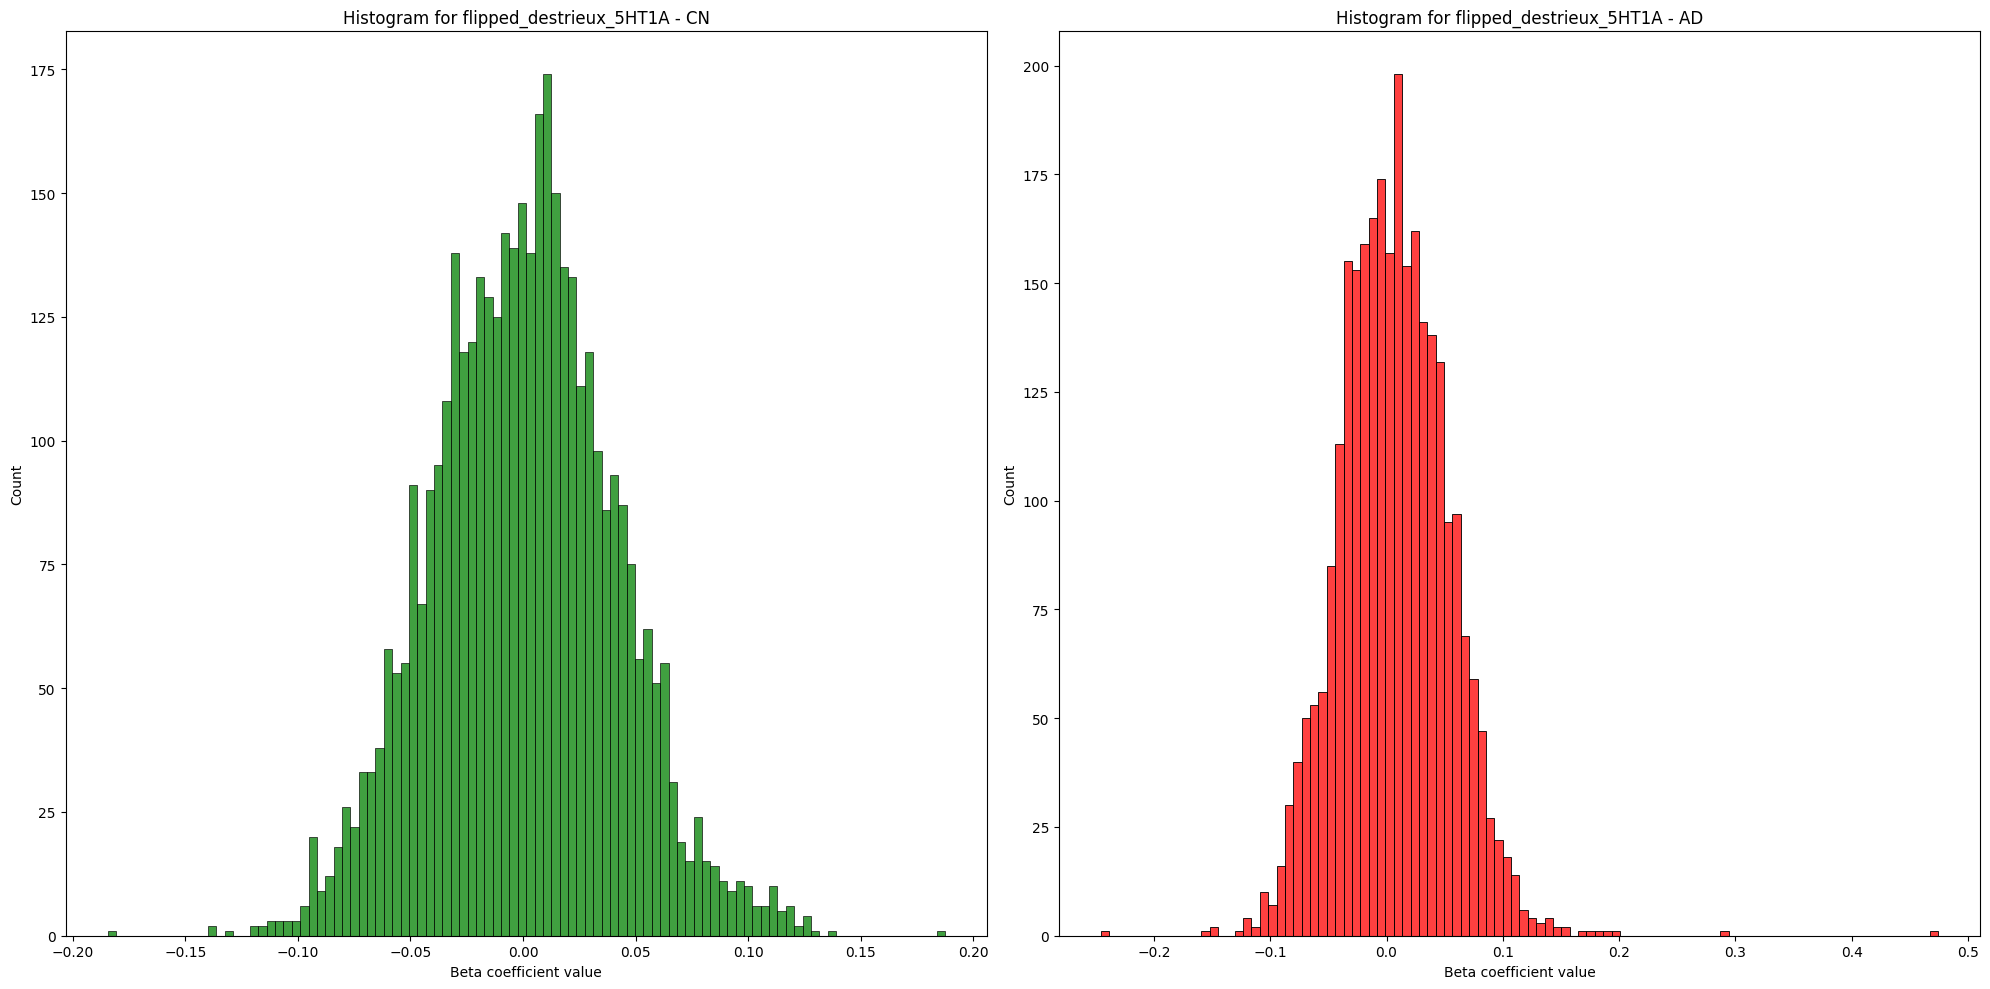

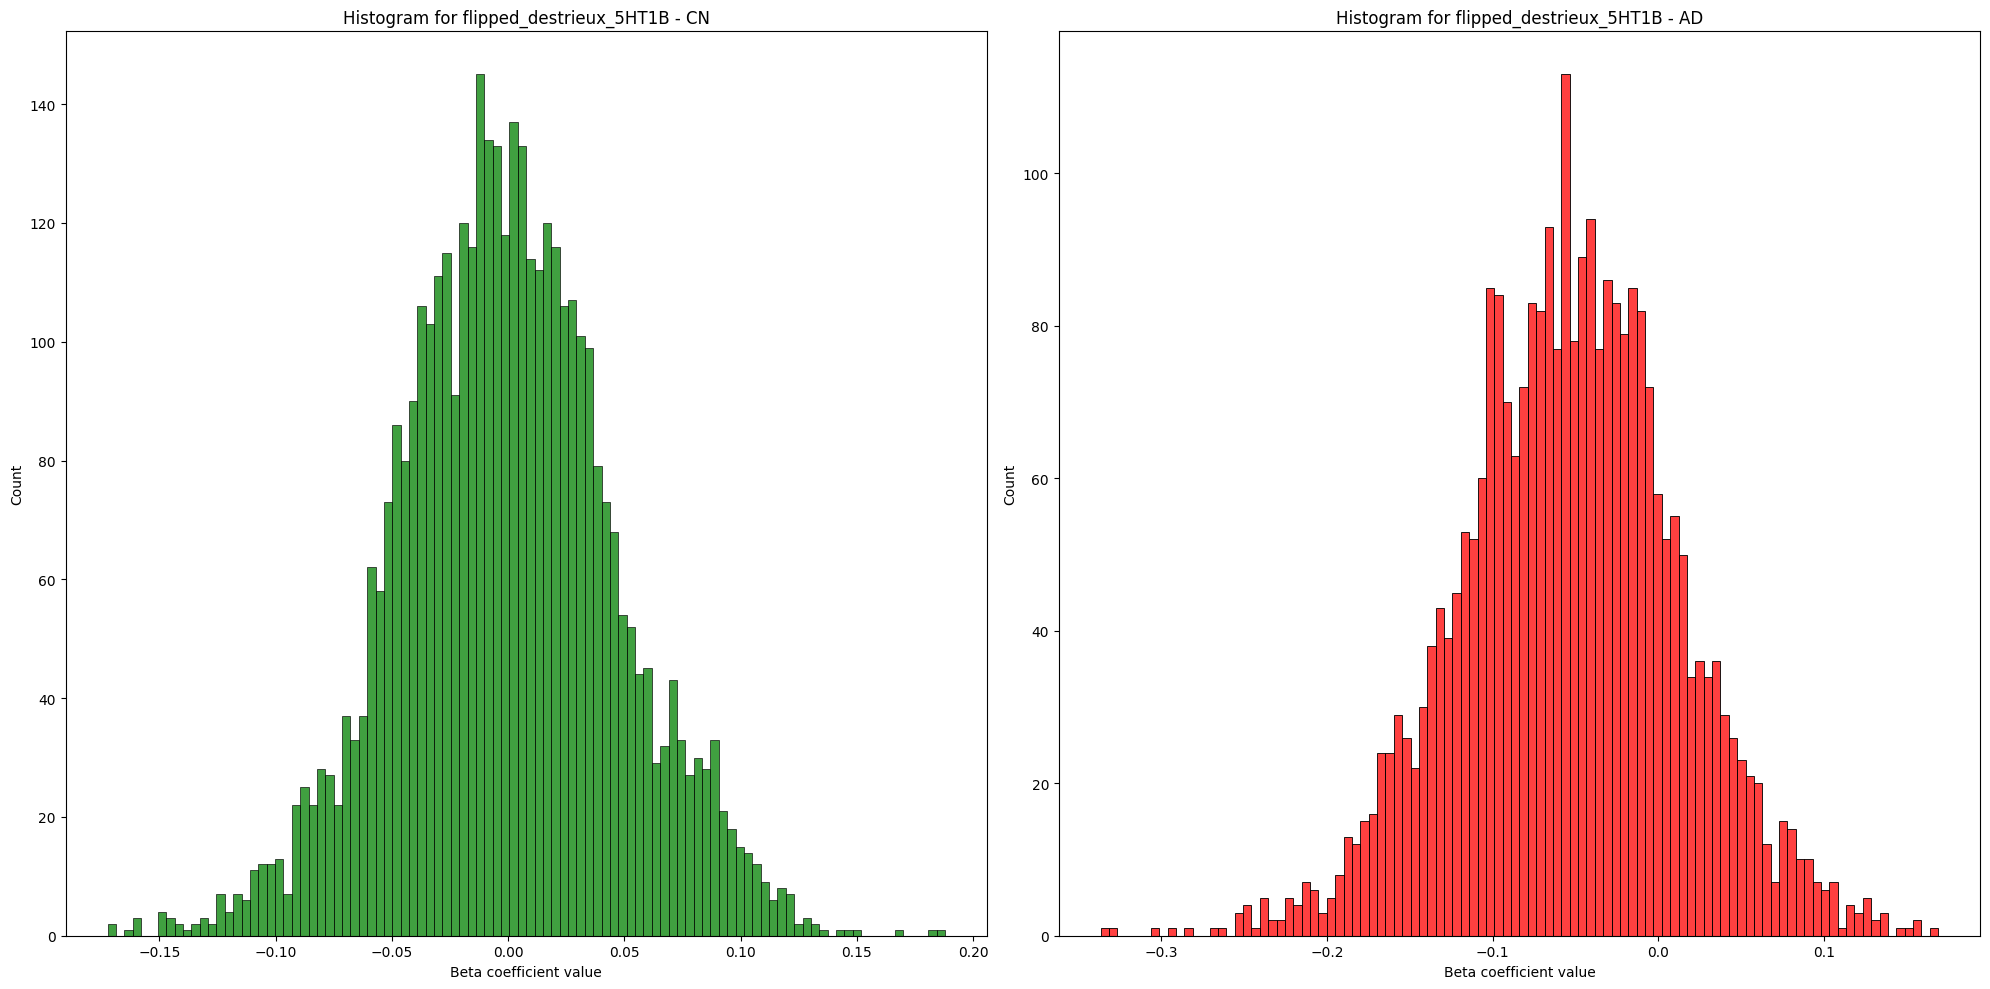

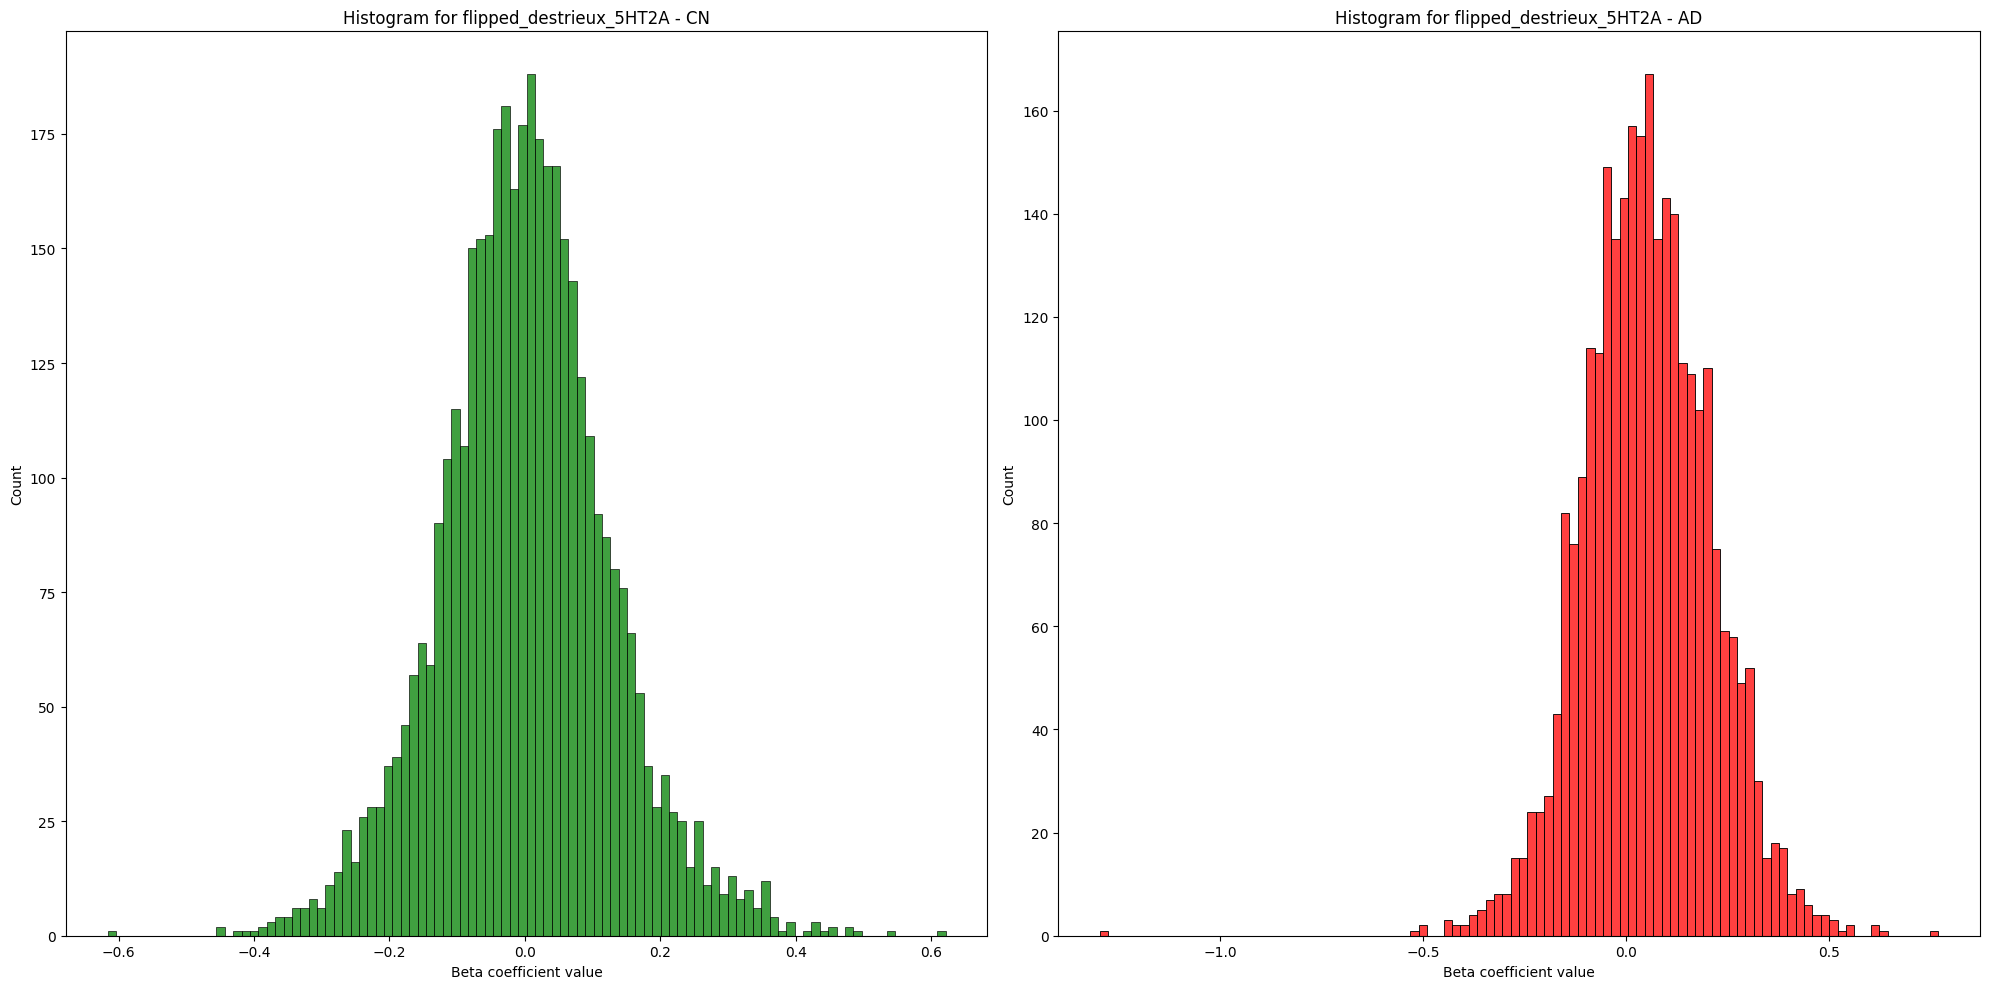

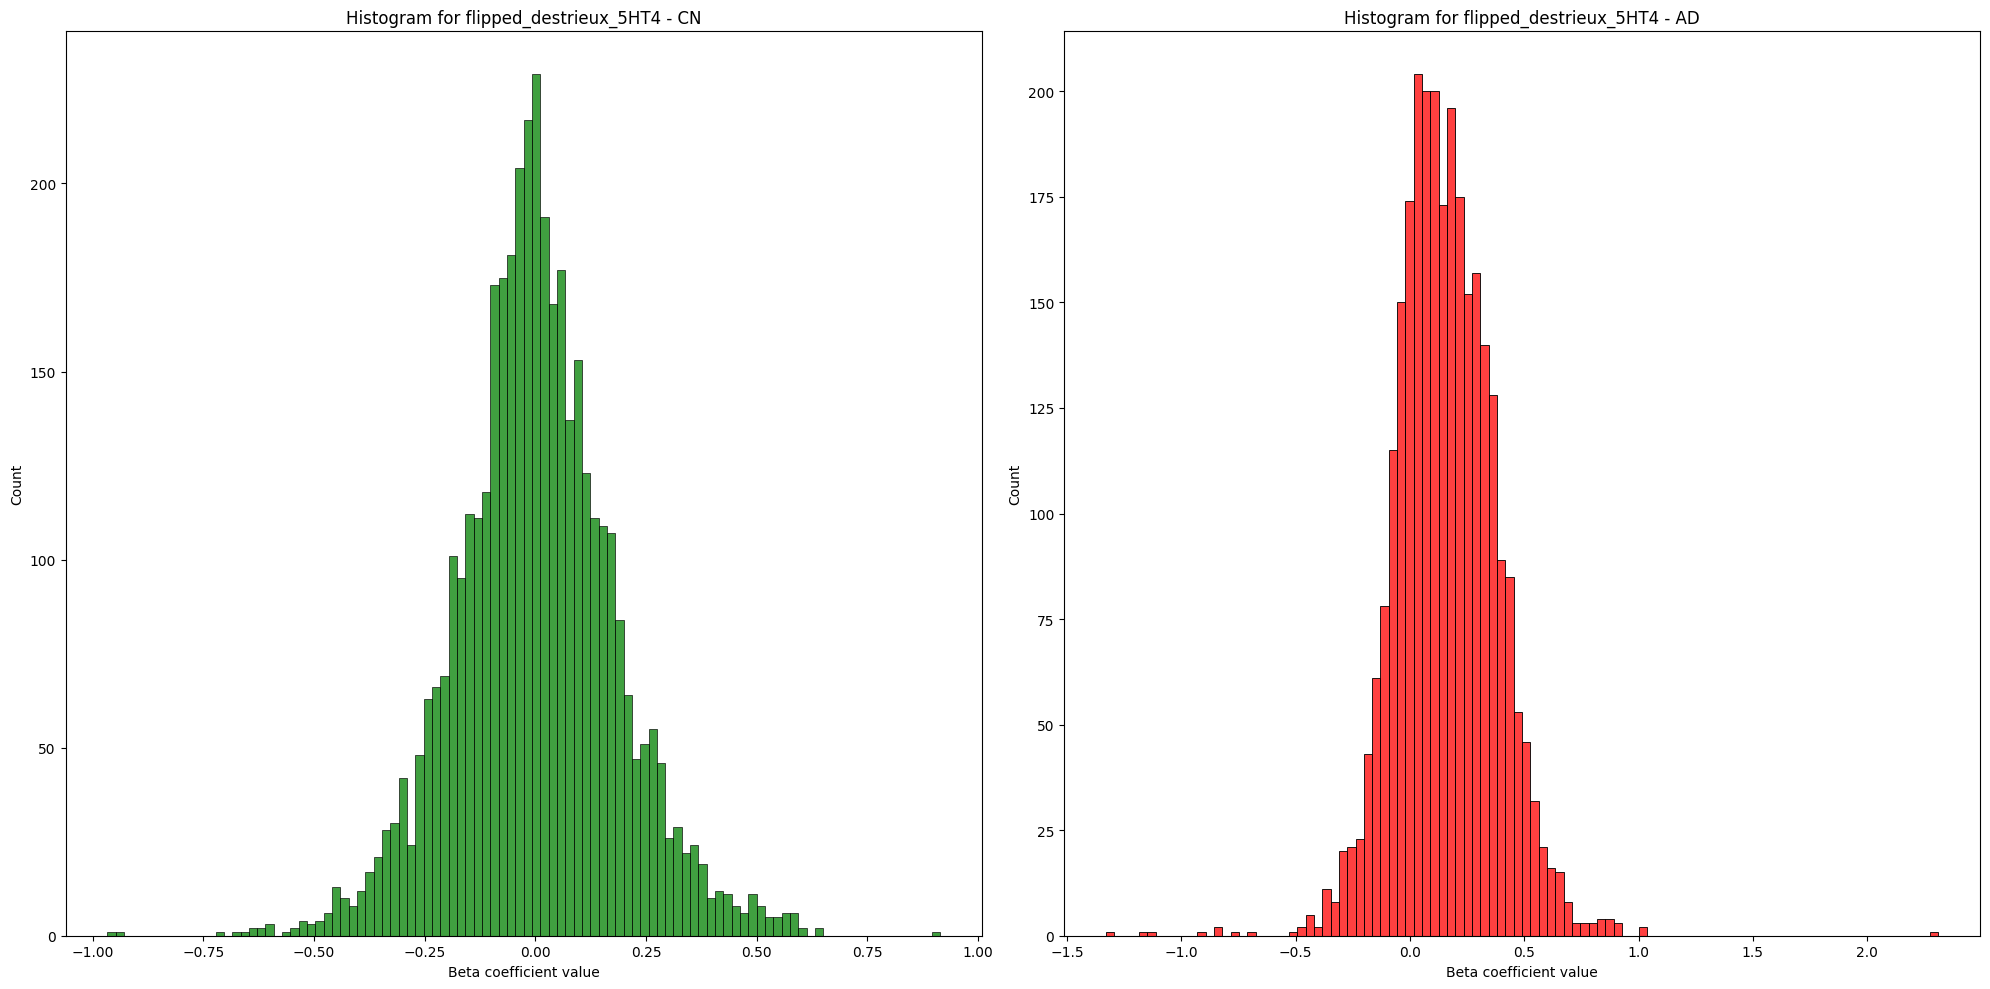

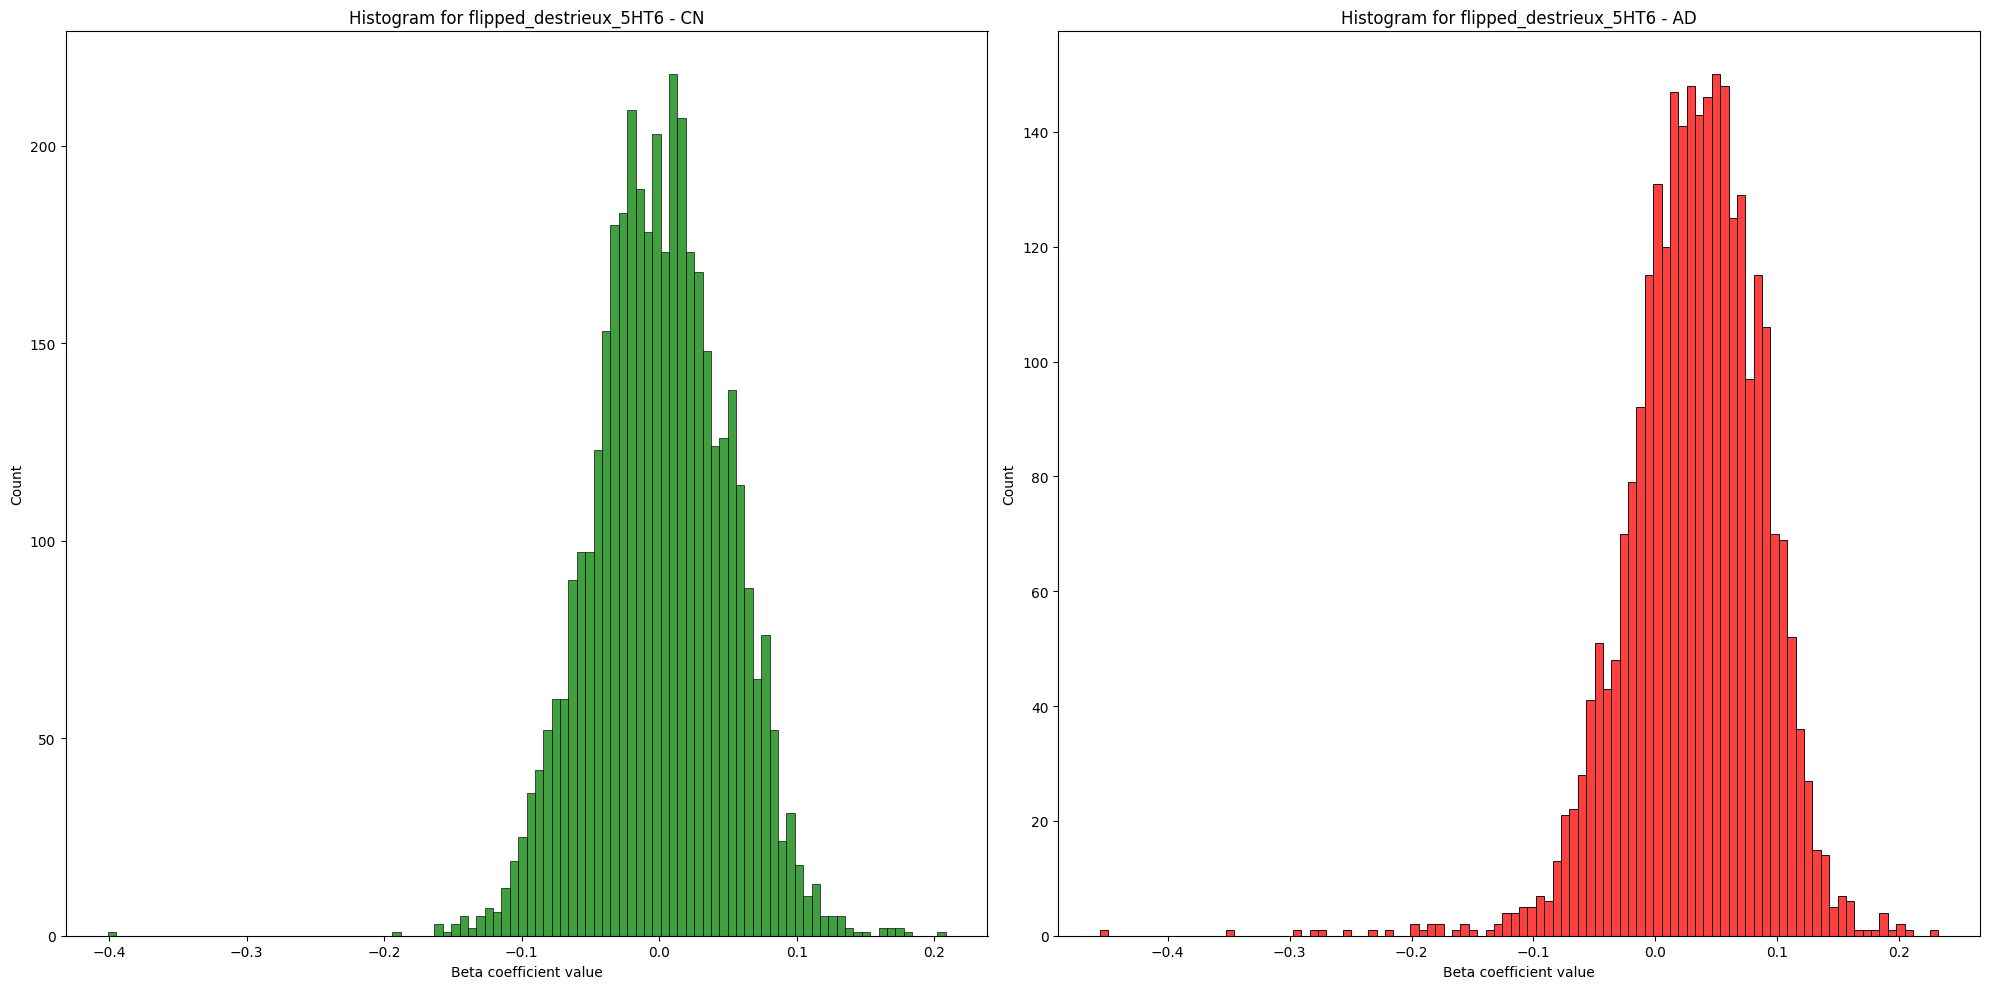

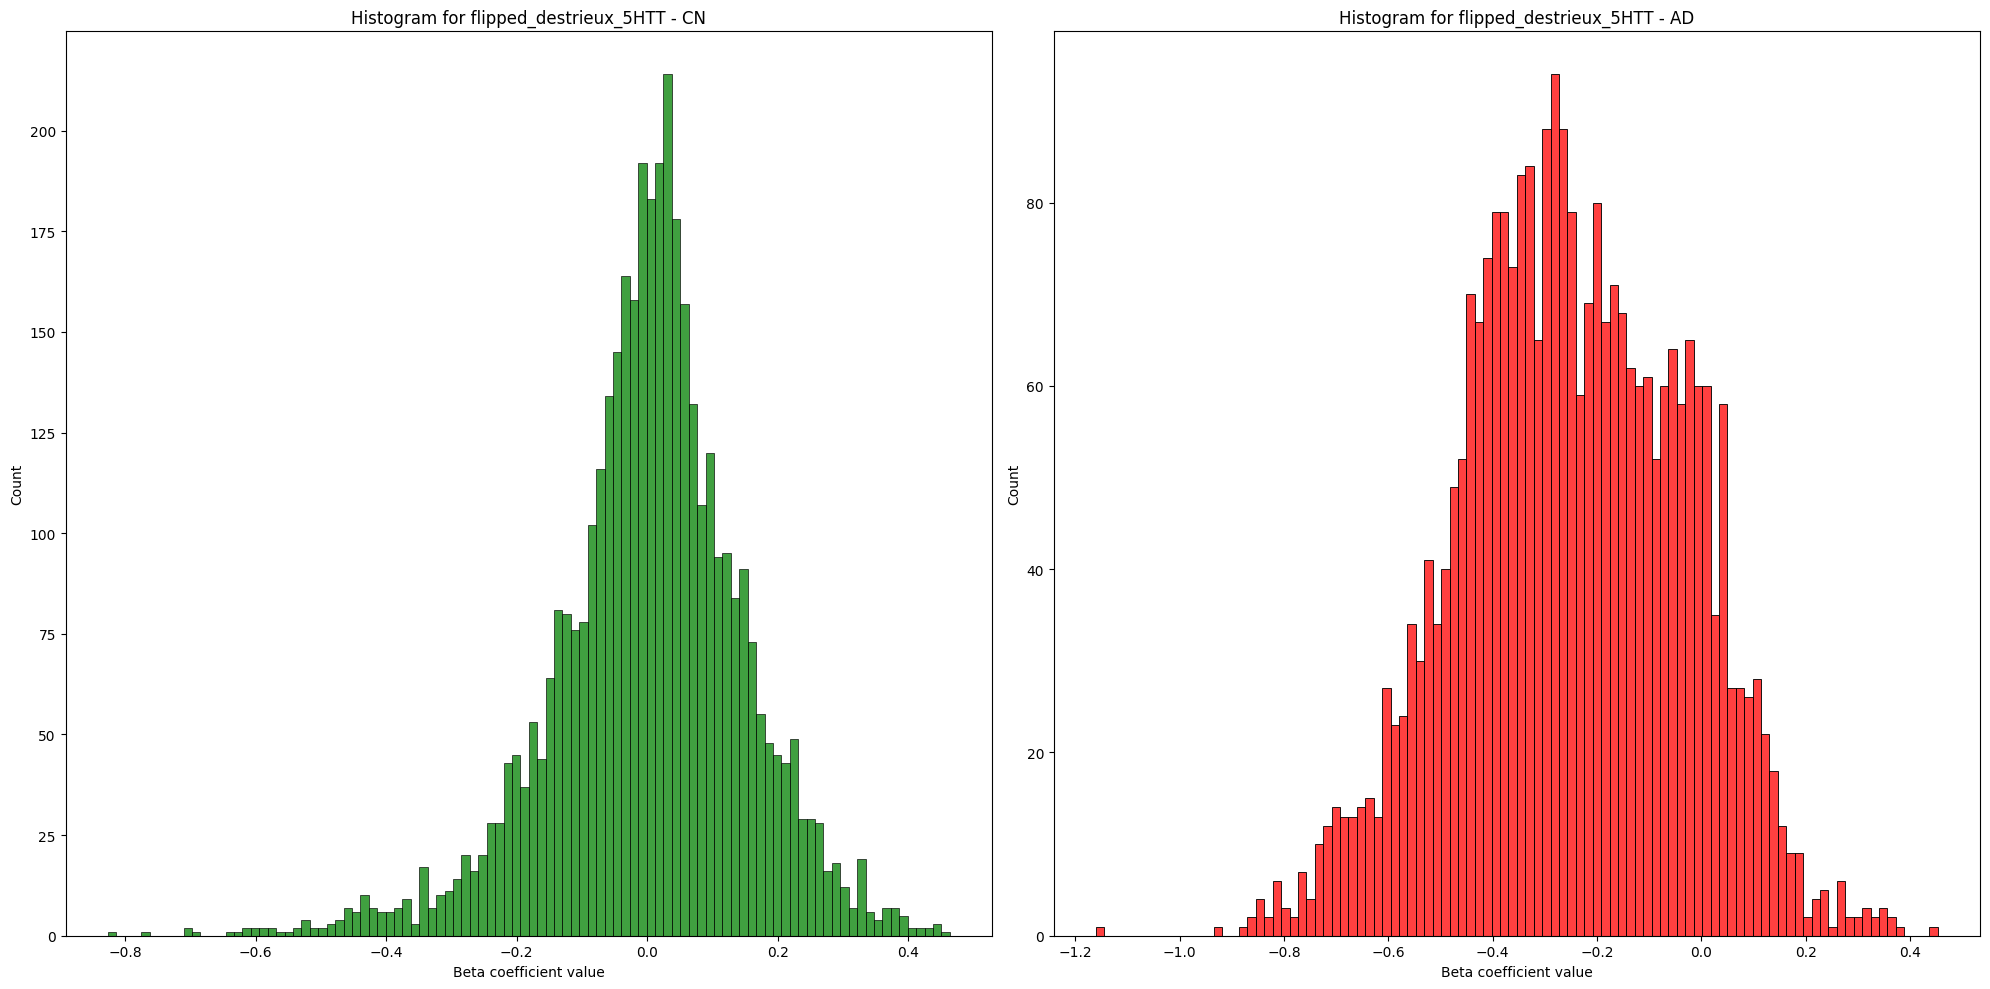

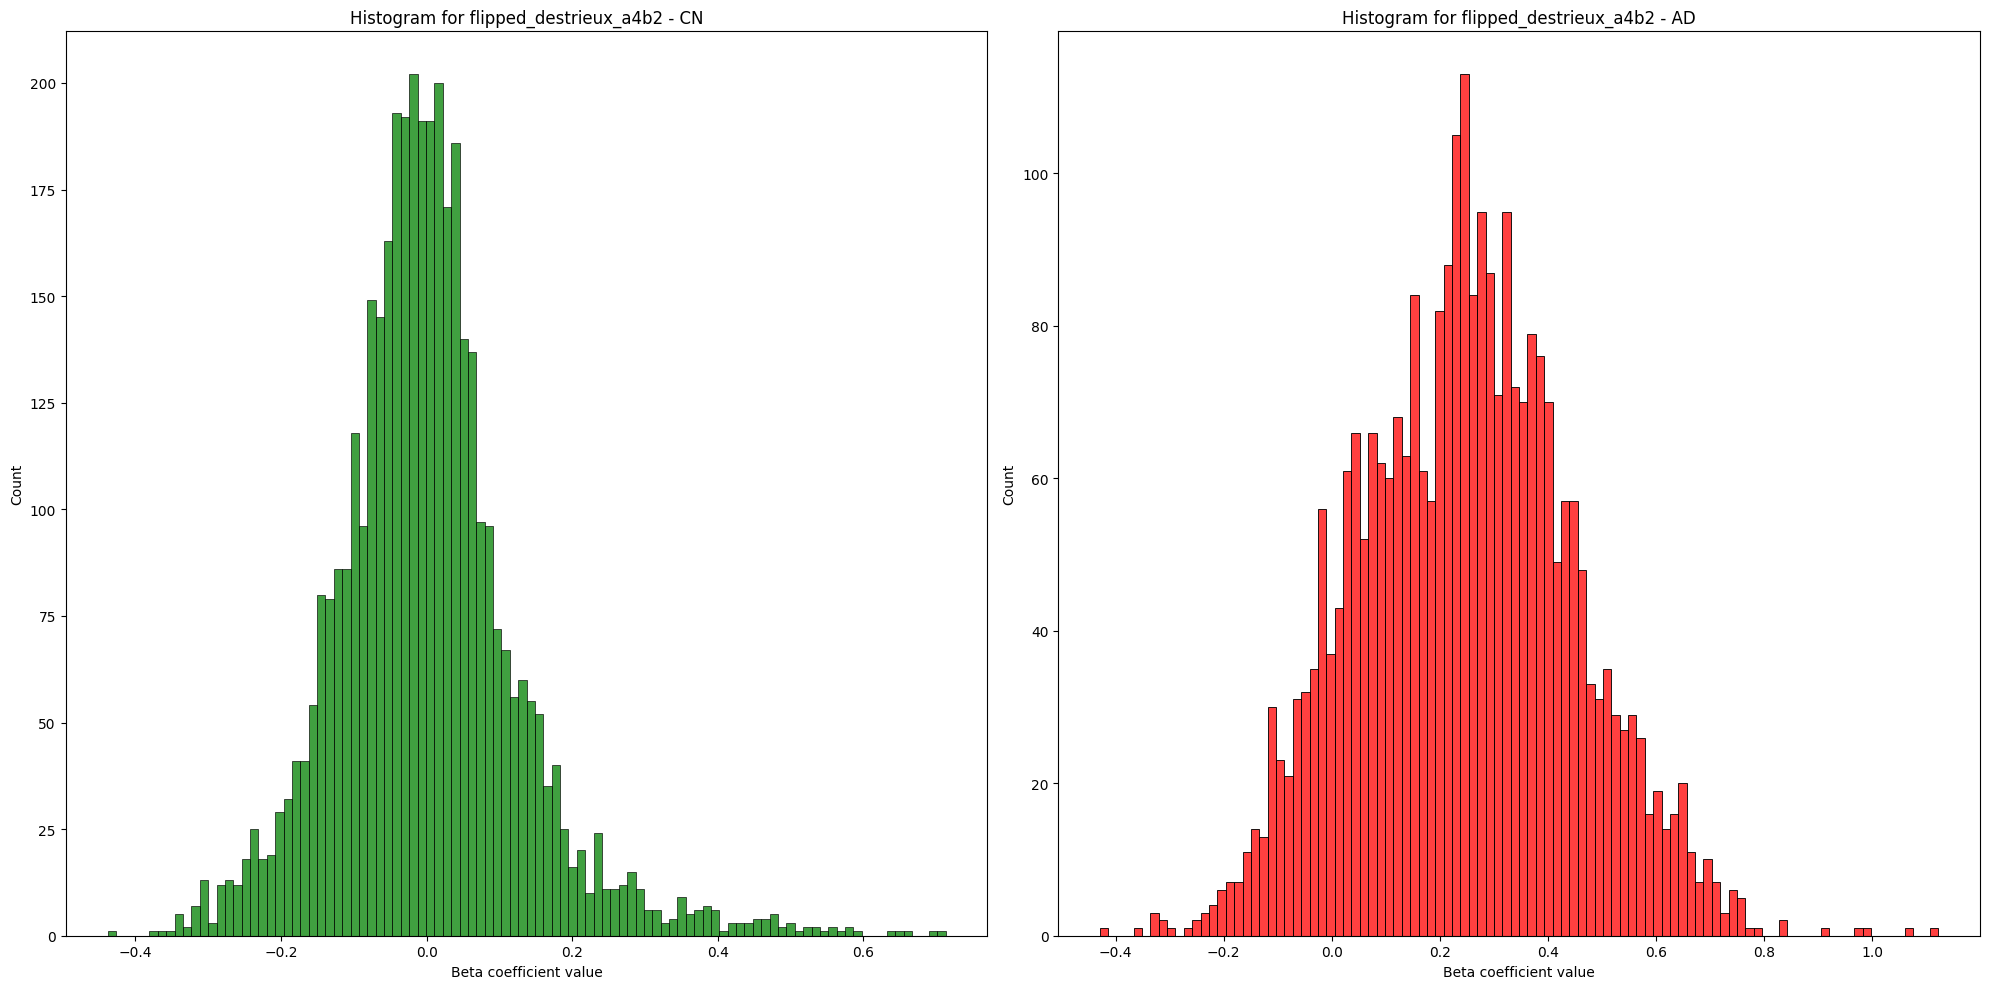

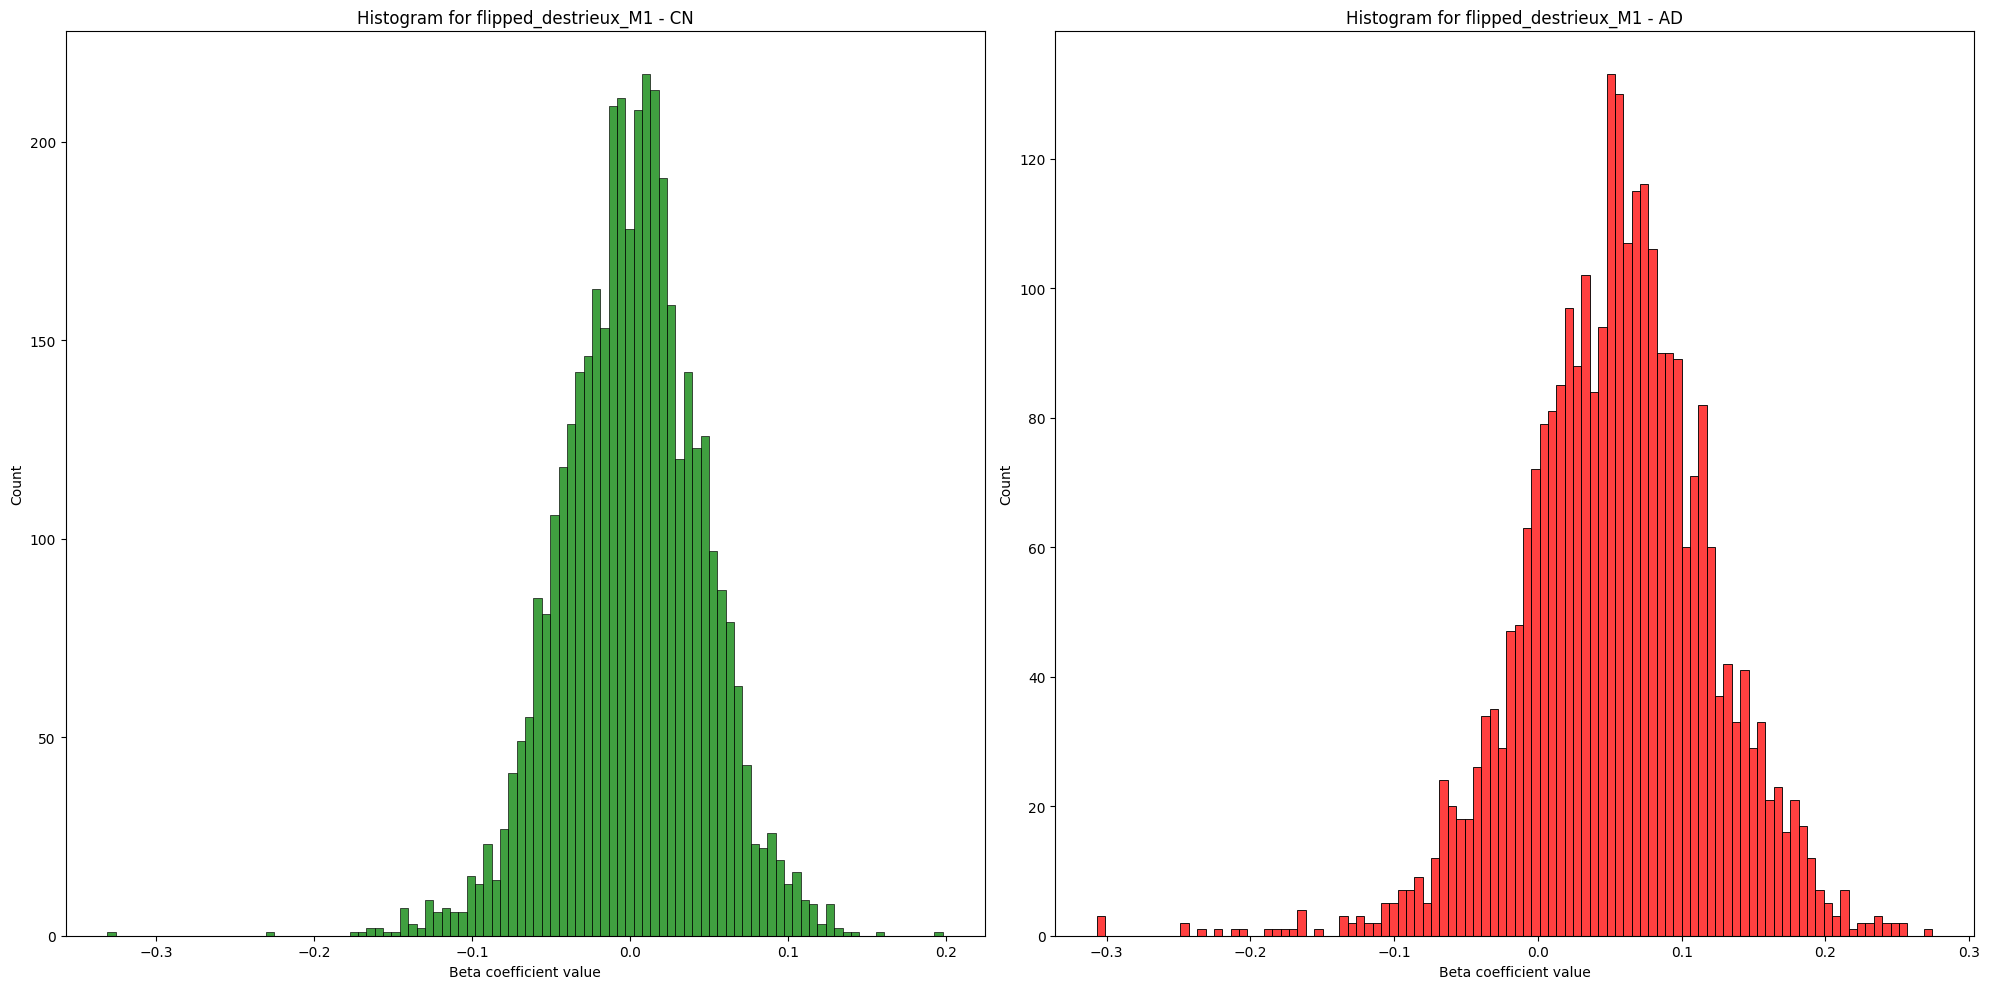

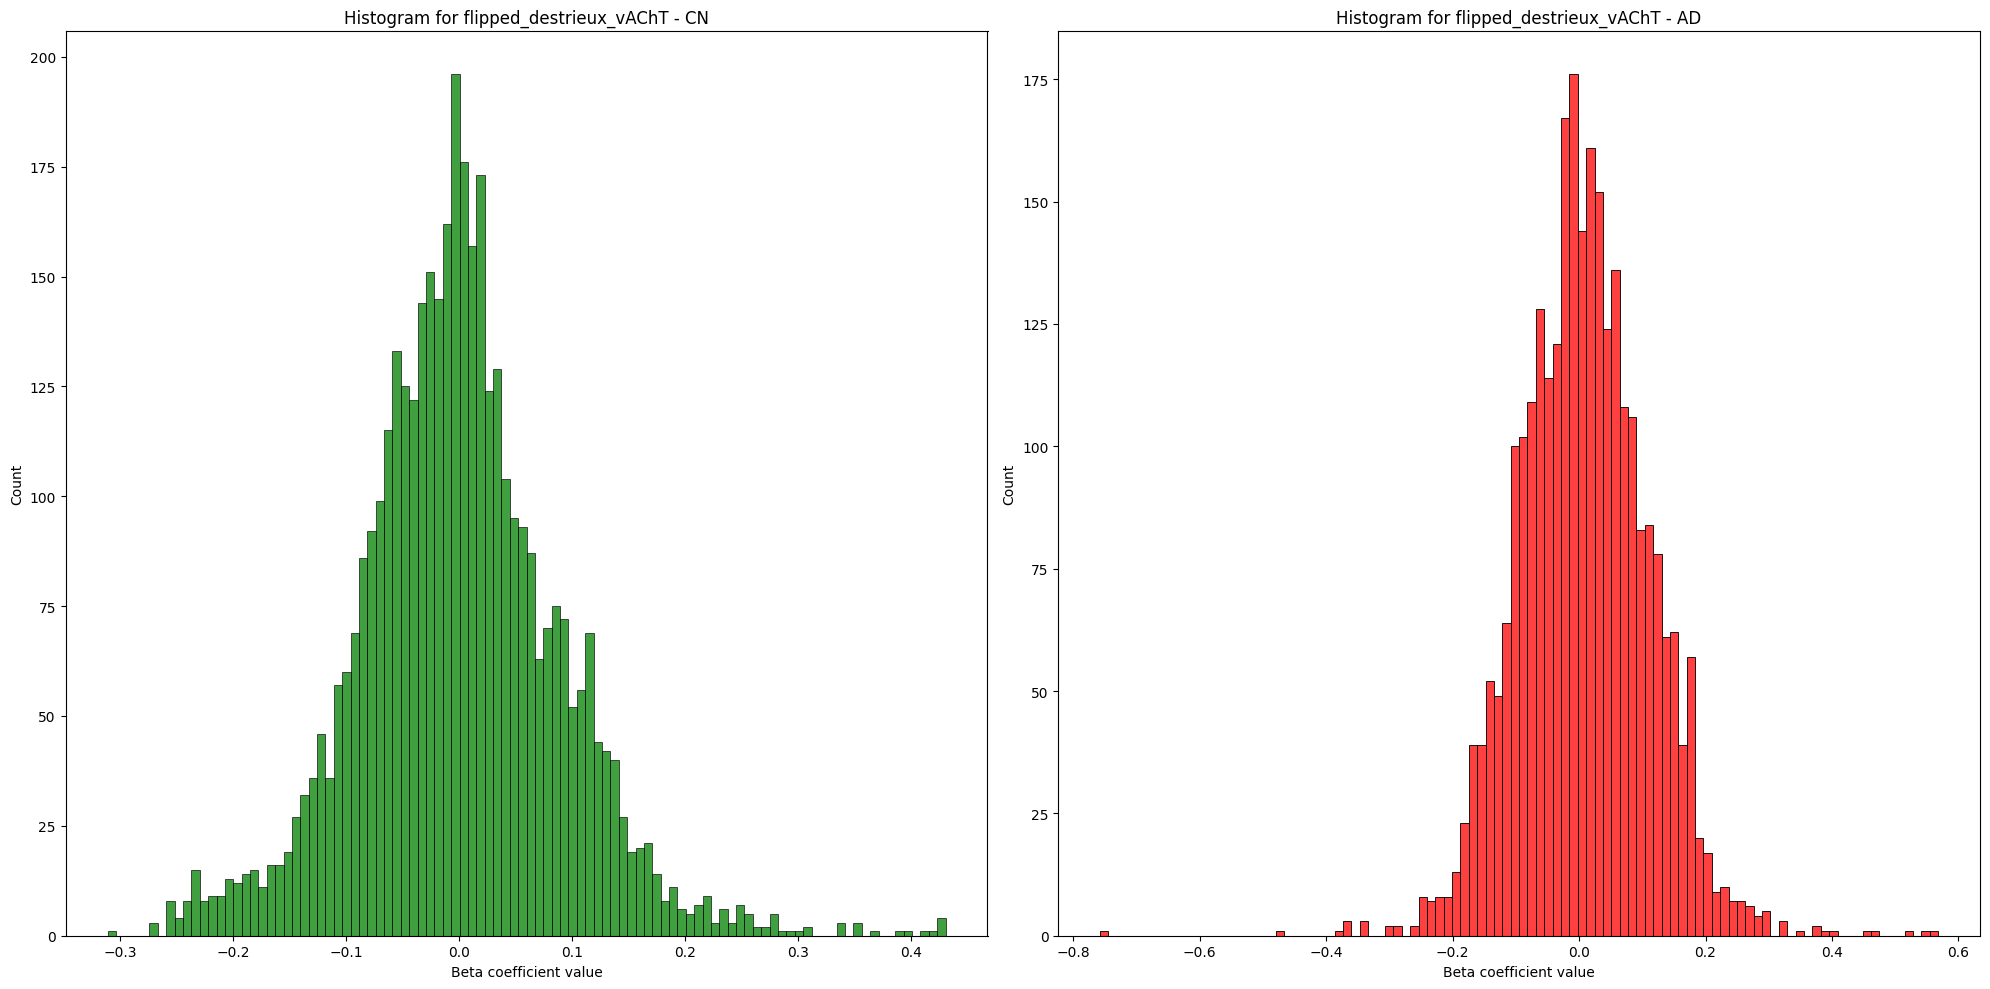

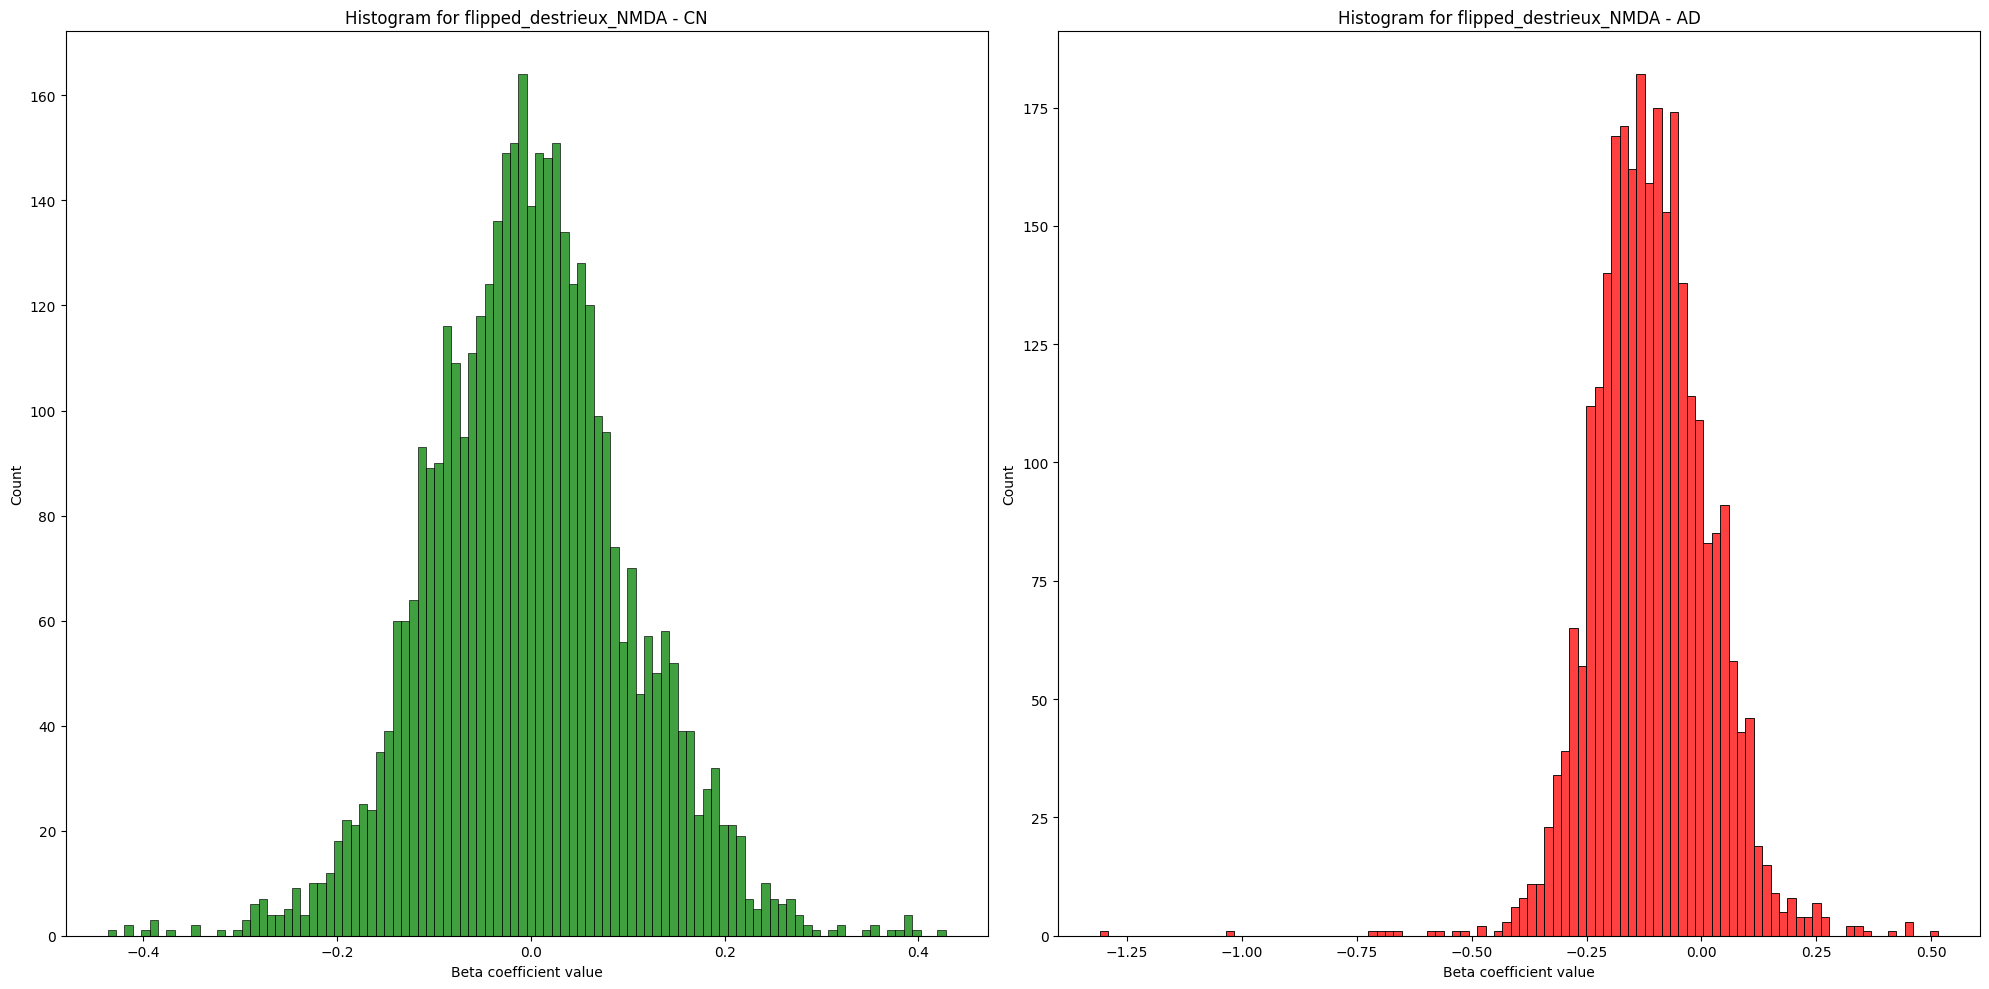

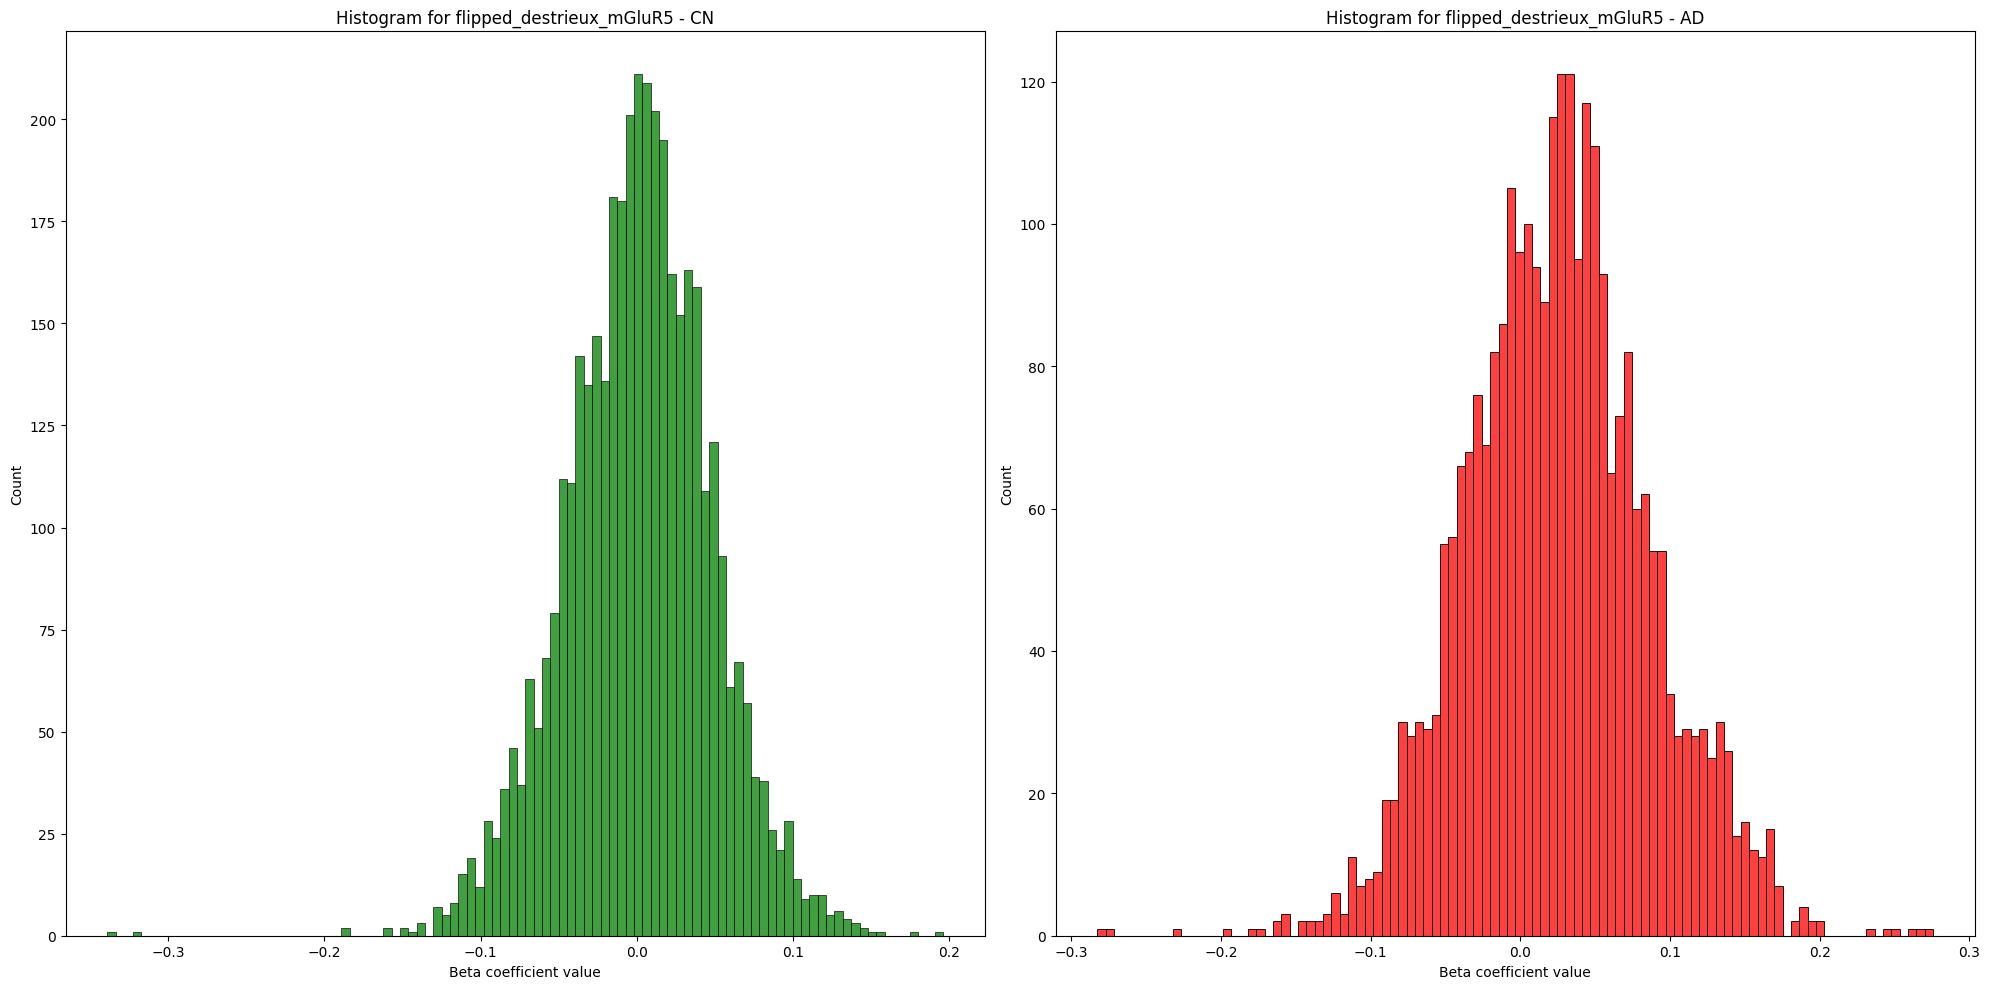

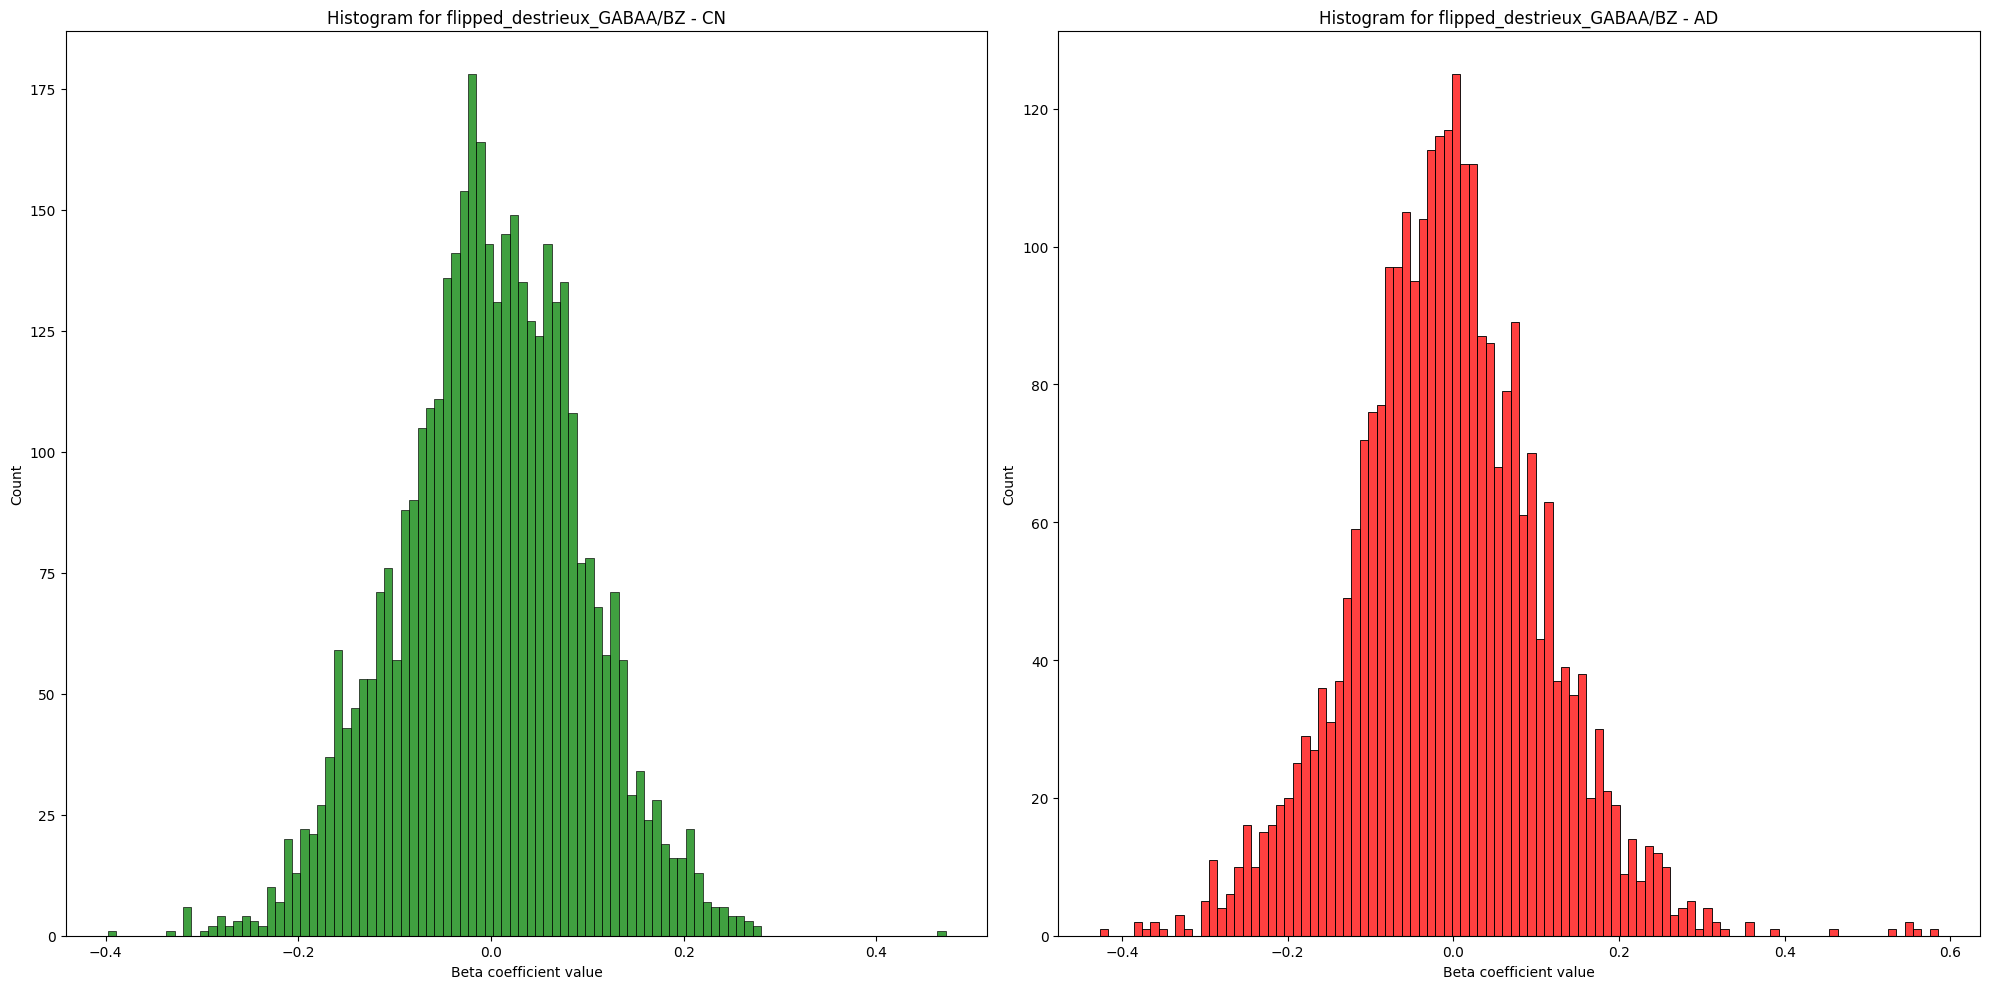

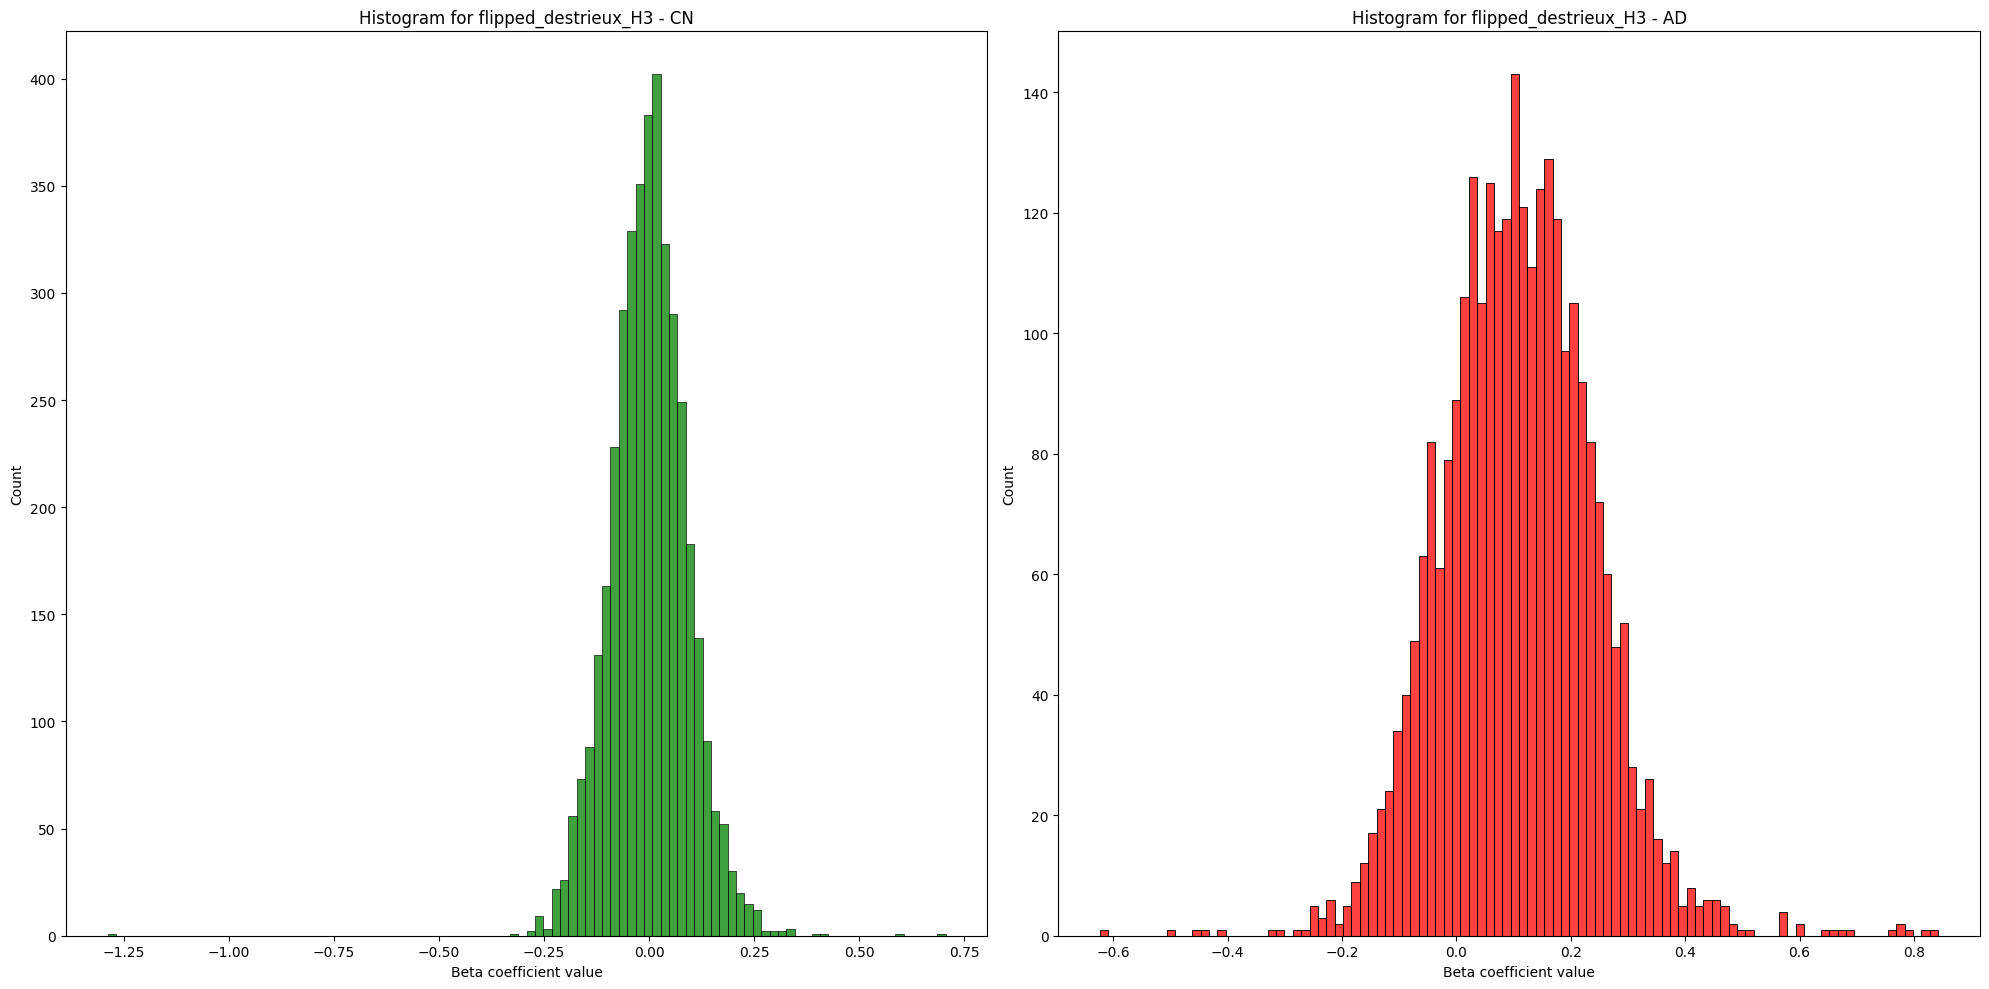

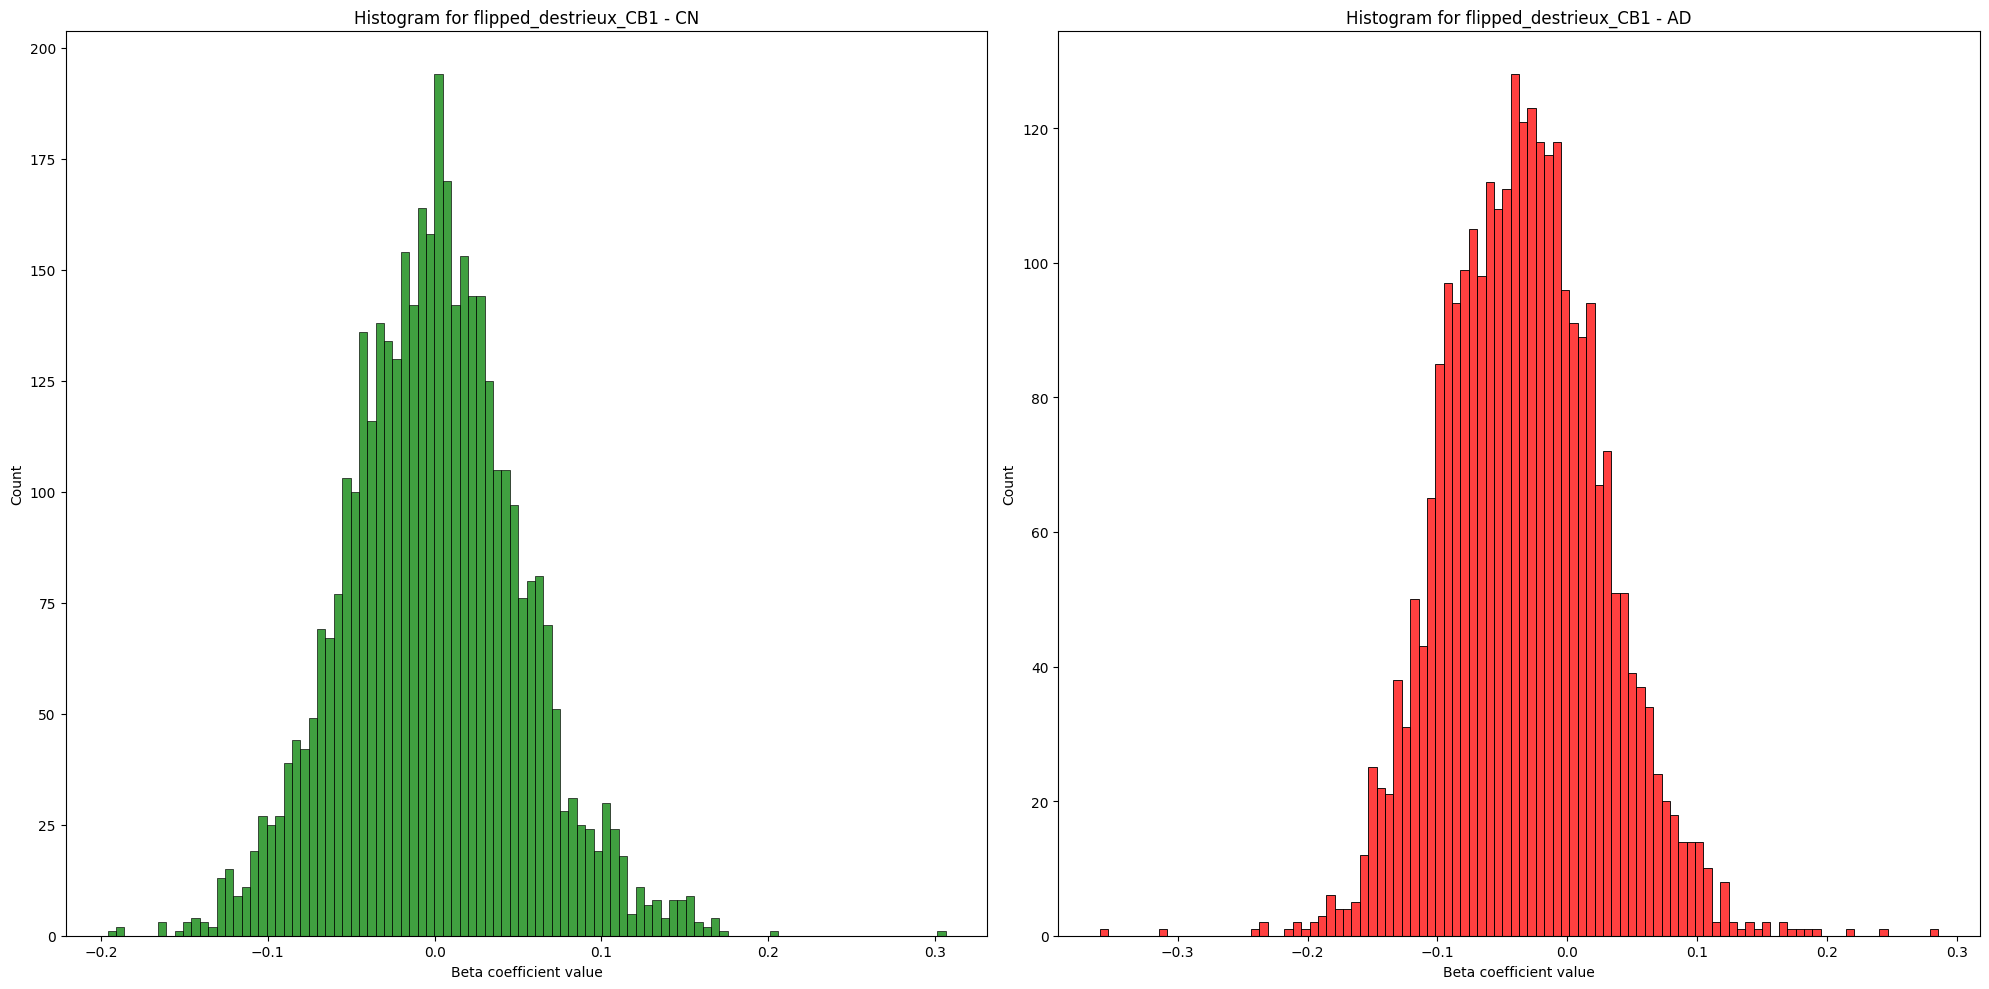

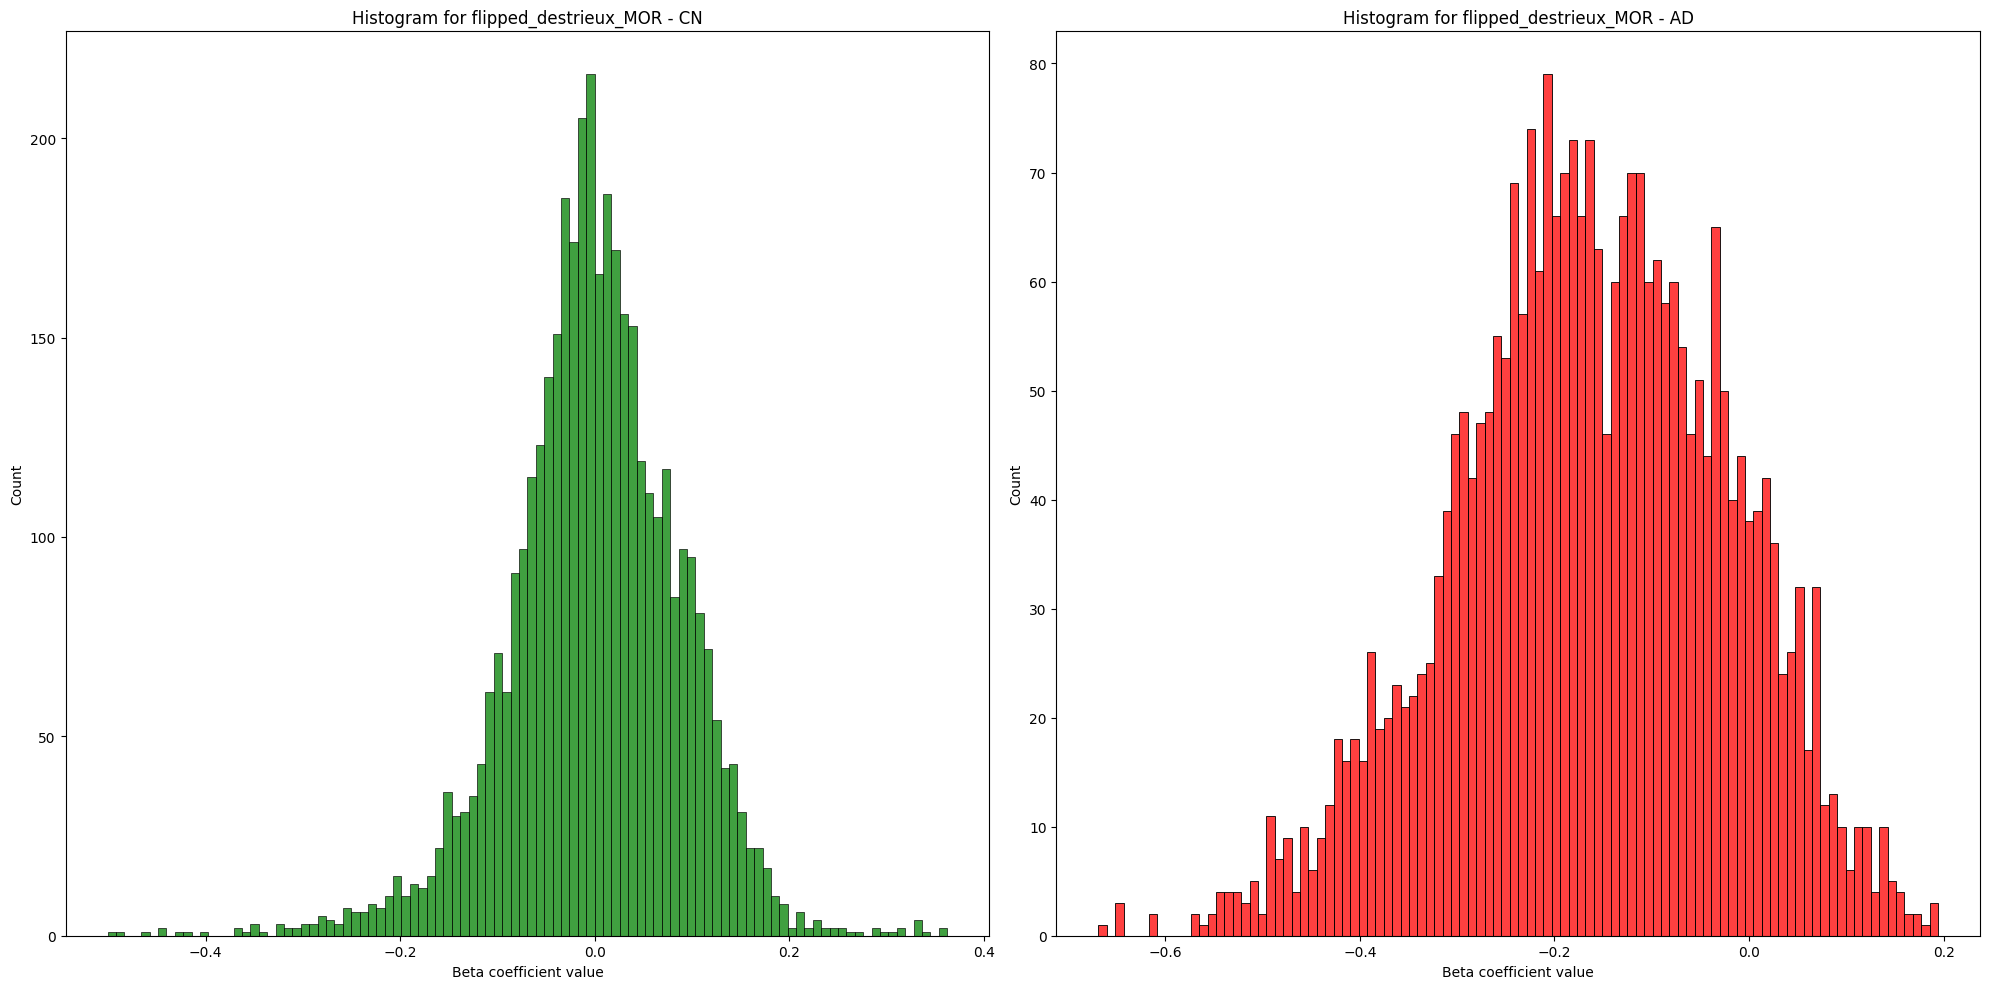

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy.stats import kstest, levene, mannwhitneyu, ttest_ind
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

for coeff_path in ['/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/desikan_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_desikan_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/destrieux_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_destrieux_coeffs.csv']:

    df = pd.read_csv(coeff_path, low_memory=False)
    diag_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                          low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

    merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
    cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns = 'DATA_KEY')

    excluded = ['DIAGNOSIS', 'DATA_KEY']
    for col in merged.columns.tolist():
        if col not in ['DIAGNOSIS', 'DATA_KEY']:

            cn_df = merged[merged['DIAGNOSIS'] == 1]
            ad_df = merged[merged['DIAGNOSIS'] == 3]

            cn_df_series = merged[merged['DIAGNOSIS'] == 1][col]
            ad_df_series = merged[merged['DIAGNOSIS'] == 3][col]

            # Histogram plotting #

            hist_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/histograms'

            plt.figure(figsize = (20,10))

            plt.subplot(1, 2, 1)
            sns.histplot(
                data = cn_df,
                x = col,
                bins = 100,
                stat ="count",
                color = 'green',
                common_norm = False
            )
                
            plt.title(f"Histogram for {col} - CN")
            plt.xlabel("Beta coefficient value")
            plt.ylabel("Count")
            plt.tight_layout()
        
            plt.subplot(1, 2, 2)
            sns.histplot(
                data = ad_df,
                x = col,
                bins = 100,
                stat = "count",
                color = 'red',
                common_norm = False
            )
            
            plt.title(f"Histogram for {col} - AD")
            plt.xlabel("Beta coefficient value")
            plt.ylabel("Count")
            plt.tight_layout()
        
            if re.match(r'.+GABAA\/BZ', col):
                savepath = os.path.join(hist_path,f'{os.path.basename(coeff_path).replace('_coeffs.csv', '')}_GABAA_BZ_histogram.png')
            else:
                savepath = os.path.join(hist_path,f'{col}_histogram.png')
            plt.savefig(savepath, dpi = 300)
            plt.show()

#### AD and CN normality, variance and pairwise testing
#### This is partially paired data - best to run tests on paired and unpaired data and then pool test statistics

In [3]:
import pandas as pd
import numpy as np
import os
import scipy

df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)

df = df[df['DIAGNOSIS'].isin([1,3])]

print(df.shape)

cn_df = df[df['DIAGNOSIS'] == 1]

ad_df = df[df['DIAGNOSIS'] == 3]

### Take stock of:

##Number of people with only 1 visit that are CN

counts = cn_df.groupby('PTID')['DATA_KEY'].count().values

counter = 0
for x in counts:
    if x == 1:
        counter +=1
print(f"Number of people with only 1 visit, and that 1 visit\'s CN: {counter}")

##Number of people with only 1 visit that are AD

counts = ad_df.groupby('PTID')['DATA_KEY'].count().values

counter = 0
for x in counts:
    if x == 1:
        counter +=1
print(f"Number of people with only 1 visit, and that 1 visit\'s AD: {counter}")

##Number of people with >1 visits all CN
counts = cn_df.groupby('PTID')['DATA_KEY'].count().values

counter = 0
for x in counts:
    if x != 1:
        counter +=1
print(f"Number of people with >1 visit, all CN: {counter}")

##Number of people with >1 visits all AD

counts = ad_df.groupby('PTID')['DATA_KEY'].count().values

counter = 0
for x in counts:
    if x != 1:
        counter +=1
print(f"Number of people with >1 visit, all AD: {counter}")

##Number of people who convert from CN to AD

counts = df.groupby('PTID')['DIAGNOSIS'].unique().values
counter = 0
for x in counts:
    if len(x) != 1:
        counter +=1
print(f"Number of converters from CN to AD: {counter}")

summary = (
    df.groupby('PTID')['DIAGNOSIS']
      .value_counts()
      .unstack(fill_value=0)
)
summary = summary.rename(columns={1: 'n_CN', 3: 'n_AD'})
converters = summary[(summary['n_CN'] > 0) & (summary['n_AD'] > 0)]

n_conv_1_ad = ((converters['n_AD'] == 1)).sum()
print(f"Converters with exactly 1 AD visit: {n_conv_1_ad}")

n_conv_1_cn = ((converters['n_CN'] == 1)).sum()
print(f"Converters with exactly 1 CN visit: {n_conv_1_cn}")

n_conv_multi_cn = (converters['n_CN'] > 1).sum()
print(f"Converters with >1 CN visits: {n_conv_multi_cn}")

n_conv_multi_ad = (converters['n_AD'] > 1).sum()
print(f"Converters with >1 AD visits: {n_conv_multi_ad}")

n_conv_multi_both = (
    (converters['n_CN'] > 1) & (converters['n_AD'] > 1)
).sum()

print(f"Converters with >1 CN and >1 AD visits: {n_conv_multi_both}")

n_conv_single_both = (
    (converters['n_CN'] == 1) & (converters['n_AD'] == 1)
).sum()

print(f"Converters with 1 CN and 1 AD visit: {n_conv_single_both}")

n_multi_either = (
    (summary['n_CN'] > 1) |
    (summary['n_AD'] > 1)
).sum()

print(f"Patients with >1 CN and/or >1 AD visit: {n_multi_either}")

(6875, 928)
Number of people with only 1 visit, and that 1 visit's CN: 290
Number of people with only 1 visit, and that 1 visit's AD: 166
Number of people with >1 visit, all CN: 693
Number of people with >1 visit, all AD: 576
Number of converters from CN to AD: 28
Converters with exactly 1 AD visit: 15
Converters with exactly 1 CN visit: 3
Converters with >1 CN visits: 25
Converters with >1 AD visits: 13
Converters with >1 CN and >1 AD visits: 12
Converters with 1 CN and 1 AD visit: 2
Patients with >1 CN and/or >1 AD visit: 1257


### To make the analysis cleaner, it is likely best to clean out the converters 
### And then for 'monodiagnostic' patients with >1 visit,to just average them!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy.stats import kstest, levene, mannwhitneyu, ttest_ind
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests

df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)

df = df[df['DIAGNOSIS'].isin([1,3])]

cn_df_ids = df[df['DIAGNOSIS'] == 1]['PTID'].unique()

ad_df_ids = df[df['DIAGNOSIS'] == 3]['PTID'].unique()

column_dicts = {
    'desikan_coeffs' : ['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA',	'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR'],
    'flipped_desikan_coeffs' : ['flipped_desikan_D1', 'flipped_desikan_D2', 'flipped_desikan_DAT', 'flipped_desikan_NET', 'flipped_desikan_5HT1A', 'flipped_desikan_5HT1B', 'flipped_desikan_5HT2A', 'flipped_desikan_5HT4', 'flipped_desikan_5HT6', 'flipped_desikan_5HTT', 'flipped_desikan_a4b2', 'flipped_desikan_M1', 'flipped_desikan_vAChT', 'flipped_desikan_NMDA',	'flipped_desikan_mGluR5', 'flipped_desikan_GABAA/BZ', 'flipped_desikan_H3', 'flipped_desikan_CB1', 'flipped_desikan_MOR'],
    'destrieux_coeffs' : ['destrieux_D1', 'destrieux_D2', 'destrieux_DAT', 'destrieux_NET', 'destrieux_5HT1A', 'destrieux_5HT1B', 'destrieux_5HT2A', 'destrieux_5HT4', 'destrieux_5HT6', 'destrieux_5HTT', 'destrieux_a4b2', 'destrieux_M1', 'destrieux_vAChT', 'destrieux_NMDA',	'destrieux_mGluR5', 'destrieux_GABAA/BZ', 'destrieux_H3', 'destrieux_CB1', 'destrieux_MOR'],
    'flipped_destrieux_coeffs' : ['flipped_destrieux_D1', 'flipped_destrieux_D2', 'flipped_destrieux_DAT', 'flipped_destrieux_NET', 'flipped_destrieux_5HT1A', 'flipped_destrieux_5HT1B', 'flipped_destrieux_5HT2A', 'flipped_destrieux_5HT4', 'flipped_destrieux_5HT6', 'flipped_destrieux_5HTT', 'flipped_destrieux_a4b2', 'flipped_destrieux_M1', 'flipped_destrieux_vAChT', 'flipped_destrieux_NMDA',	'flipped_destrieux_mGluR5', 'flipped_destrieux_GABAA/BZ', 'flipped_destrieux_H3', 'flipped_destrieux_CB1', 'flipped_destrieux_MOR']
}

converters = (
    df.groupby('PTID')['DIAGNOSIS']
      .nunique()
)
converters = converters[converters > 1].index

mask = ~df['PTID'].isin(converters)

cleaned_df = df[mask] # In cleaned_df, multiple visits from the same patient have the same diagnosis as each other so we can aggregate them as a mean

full_list = []
for i in column_dicts.values():
    for j in i:
        full_list.append(j)
        
cleaned_df_groups = cleaned_df[['PTID', 'DIAGNOSIS'] + full_list].groupby(by = ['PTID']).mean()

for flag in ['desikan', 'destrieux', 'flipped_desikan', 'flipped_destrieux']:
    stats_results = []
    
    coeffs = column_dicts[f'{flag}_coeffs']

    merged = cleaned_df_groups[['DIAGNOSIS'] + coeffs]

    cn_df = merged[merged['DIAGNOSIS'] == 1]
    ad_df = merged[merged['DIAGNOSIS'] == 3]
    
    for col in coeffs:
    
        cn_df_series = cn_df[col]
        ad_df_series = ad_df[col]

        print(len(cn_df_series), len(ad_df_series))


        # 1. Levene's Test for Homogeneity of Variance
        _, p_levene = levene(cn_df_series, ad_df_series)
        equal_var = p_levene > 0.05

        # 2. Kolmogorov-Smirnov Test for Normality (standardized)
        is_normal = True
        for g in [cn_df_series, ad_df_series]:
            standardised_group = (g - g.mean()) / g.std()
            _, p_ks = kstest(standardised_group, 'norm')
            if p_ks < 0.05:
                is_normal = False
                break

        # 3. Pairwise test
        if is_normal and equal_var:
            test_name = "Student's t-test"
            _, pval = ttest_ind(cn_df_series, ad_df_series, equal_var=True)
        elif is_normal and not equal_var:
            test_name = "Welch's t-test"
            _, pval = ttest_ind(cn_df_series, ad_df_series, equal_var=False)
        else:
            test_name = "Mann-Whitney U"
            _, pval = mannwhitneyu(cn_df_series, ad_df_series, alternative='two-sided')

        # Is mean higher or lower in AD than CN?

        if cn_df_series.mean() < ad_df_series.mean():
            higher_mean = 'AD has higher mean ↑'
        elif cn_df_series.mean() > ad_df_series.mean():
            higher_mean = 'CN has higher mean ↓'
        else:
            higher_mean = 'Means are equal -'

            
            

        stats_results.append({
            'Coefficient': col,
            'Raw_P': pval,
            'Test': test_name,
            'Higher Mean': higher_mean
        })

    stats_df = pd.DataFrame(stats_results)

    _, p_corr, _, _ = multipletests(stats_df['Raw_P'], alpha=0.05, method='bonf')
    stats_df['Corrected_P'] = p_corr
    stats_df['Significant'] = stats_df['Corrected_P'] < 0.05
    print(stats_df)

    stats_df_dir_path = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff'
    os.makedirs(stats_df_dir_path, exist_ok = True)
    stats_df_path = os.path.join(stats_df_dir_path, f"{flag}_coeffs_sig_diff.csv")
    stats_df.to_csv(stats_df_path, index = False)
    

955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
955 714
         Coefficient          Raw_P            Test           Higher Mean  \
0         desikan_D1   1.031535e-10  Welch's t-test  AD has higher mean ↑   
1         desikan_D2   1.511227e-94  Welch's t-test  AD has higher mean ↑   
2        desikan_DAT   1.035168e-70  Welch's t-test  CN has higher mean ↓   
3        desikan_NET   1.531244e-01  Welch's t-test  CN has higher mean ↓   
4      desikan_5HT1A  3.699238e-157  Welch's t-test  CN has higher mean ↓   
5      desikan_5HT1B   9.062427e-02  Welch's t-test  AD has higher mean ↑   
6      desikan_5HT2A   3.312954e-26  Welch's t-test  AD has higher mean ↑   
7       desikan_5HT4   7.148189e-03  Welch's t-test  CN has higher mean ↓   
8       desikan_5HT6   1.396586e-54  Welch's t-test  AD has higher mean ↑   
9       desikan_5HTT   8.996427e-25  Mann-Whitney U  CN has higher mean ↓   
1

In [5]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os
# import re
# from scipy.stats import kstest, levene, mannwhitneyu, ttest_ind
# from matplotlib.colors import ListedColormap
# from statsmodels.stats.multitest import multipletests


# for coeff_path in ['/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/desikan_coeffs.csv',
#                   '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_desikan_coeffs.csv',
#                   '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/destrieux_coeffs.csv',
#                   '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_destrieux_coeffs.csv']:

#     stats_results = []

#     df = pd.read_csv(coeff_path, low_memory=False)
#     diag_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
#                           low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

#     merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
#     cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns = 'DATA_KEY')

#     excluded = ['DIAGNOSIS', 'DATA_KEY']
#     for col in merged.columns.tolist():
#         if col not in ['DIAGNOSIS', 'DATA_KEY']:

#             cn_df = merged[merged['DIAGNOSIS'] == 1]
#             ad_df = merged[merged['DIAGNOSIS'] == 3]

#             cn_df_series = merged[merged['DIAGNOSIS'] == 1][col]
#             ad_df_series = merged[merged['DIAGNOSIS'] == 3][col]

#             # 1. Levene's Test for Homogeneity of Variance
#             _, p_levene = levene(cn_df_series, ad_df_series)
#             equal_var = p_levene > 0.05

#             # 2. Kolmogorov-Smirnov Test for Normality (standardized)
#             is_normal = True
#             for g in [cn_df_series, ad_df_series]:
#                 standardised_group = (g - g.mean()) / g.std()
#                 _, p_ks = kstest(standardised_group, 'norm')
#                 if p_ks < 0.05:
#                     is_normal = False
#                     break

#             # 3. Pairwise test
#             if is_normal and equal_var:
#                 test_name = "Student's t-test"
#                 _, pval = ttest_ind(cn_df_series, ad_df_series, equal_var=True)
#             elif is_normal and not equal_var:
#                 test_name = "Welch's t-test"
#                 _, pval = ttest_ind(cn_df_series, ad_df_series, equal_var=False)
#             else:
#                 test_name = "Mann-Whitney U"
#                 _, pval = mannwhitneyu(cn_df_series, ad_df_series, alternative='two-sided')

#             # Is mean higher or lower in AD than CN?

#             if cn_df_series.mean() < ad_df_series.mean():
#                 higher_mean = 'AD has higher mean ↑'
#             elif cn_df_series.mean() > ad_df_series.mean():
#                 higher_mean = 'CN has higher mean ↓'
#             else:
#                 higher_mean = 'Means are equal -'

                
            

#             stats_results.append({
#                 'Coefficient': col,
#                 'Raw_P': pval,
#                 'Test': test_name,
#                 'Higher Mean': higher_mean
#             })

#     stats_df = pd.DataFrame(stats_results)

#     _, p_corr, _, _ = multipletests(stats_df['Raw_P'], alpha=0.05, method='fdr_bh')
#     stats_df['Corrected_P'] = p_corr
#     stats_df['Significant'] = stats_df['Corrected_P'] < 0.05
#     print(stats_df)

#     stats_df_dir_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff'
#     os.makedirs(stats_df_dir_path, exist_ok = True)
#     stats_df_prefix = os.path.basename(coeff_path).replace('.csv', '')    
#     stats_df_path = os.path.join(stats_df_dir_path, f"{stats_df_prefix}_sig_diff.csv")
#     stats_df.to_csv(stats_df_path, index = False)
    

#### AD and CN swarmplot

In [6]:
%%bash

mkdir -p /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff
mkdir -p /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff

In [1]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/swarmplots.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy.stats import kstest, levene, mannwhitneyu, ttest_ind
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

swarmplot_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/swarmplots'
os.makedirs(swarmplot_path, exist_ok = True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif 0.001 < p_value < 0.01: return '**'
    elif 0.01 < p_value < 0.05: return '*'
    else: return 'ns'


for coeff_path in ['/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/desikan_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_desikan_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/destrieux_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_destrieux_coeffs.csv']:

    df = pd.read_csv(coeff_path, low_memory=False)
    diag_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                          low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

    merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
    cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns = 'DATA_KEY')

    melted_df = cn_ad_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

    print(melted_df)

    stats_df = pd.read_csv(
        f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/{os.path.basename(coeff_path).replace('s.csv', '')}_sig_diff.csv",
        low_memory = False)


    for width in range(50, 60):
        for dot_size in np.arange(0.1, 2.1, 0.1):
            height = (width / 4) 

            print(f"PRINTING SWARMPLOT - WIDTH = {width}, HEIGHT = {height}, DOT SIZE = {dot_size}")

            pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

            print(pval_dict)

            assert list(pval_dict.keys()) == cn_ad_df.drop(columns = 'DIAGNOSIS').columns.tolist()

            
            plt.figure(figsize=(width, height))
            
            ax = sns.swarmplot(
                data=melted_df, 
                x = 'NEUROTRANSMITTER', 
                y = 'VALUE', 
                hue ='DIAGNOSIS', 
                palette = {1: 'green', 3: 'red'},
                dodge = True, 
                size = dot_size, 
                alpha = 0.7
            )

            plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')

            # Order + y positions
            x_order = melted_df['NEUROTRANSMITTER'].unique()

            print(x_order)
            y_max = melted_df.groupby('NEUROTRANSMITTER')['VALUE'].max()
            print(y_max)

            y_range = melted_df['VALUE'].max() - melted_df['VALUE'].min()
            bracket_height = 0.01 * y_range  # How tall the "tips" of the bracket are
            bracket_offset = 0.02 * y_range  # Space between data and bracket
            text_offset = 0.005 * y_range 
            
            # Add stars
            for i, nt in enumerate(x_order):
                if nt in pval_dict:
                    stars = get_significance_stars(pval_dict[nt])
                    
                    if stars != 'ns':
                        y_base = y_max[nt] + bracket_offset
                        x1, x2 = i - 0.2, i + 0.2

                        ax.plot([x1, x1, x2, x2], 
                                [y_base - bracket_height, y_base, y_base, y_base - bracket_height], 
                                lw=1.5, color='black')

                        ax.text((x1 + x2) * .5, y_base + text_offset, stars, 
                                ha='center', va='bottom', fontsize=12, fontweight='bold')
                        
                        y = y_max[nt] + 0.02 * (y_max.max() - y_max.min())
                        ax.text(i, y, stars, ha='center', va='bottom', fontsize=10)

            plt.tight_layout()
            final_path = os.path.join(swarmplot_path, f"{os.path.basename(coeff_path).replace('_coeffs.csv', '')}_w{width}_h{height}_d{dot_size:.1f}.png")
            print(final_path)
            plt.savefig(final_path, dpi = 300)
            plt.close()

 

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/swarmplots.py


In [8]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submit_swarmplots.sh

#!/bin/bash
#PBS -lwalltime=72:00:00
#PBS -lselect=1:ncpus=1:mem=10gb
#PBS -o /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff
#PBS -e /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff
#PBS -N scott_10k_swarmplots

source ~/venv_1/bin/activate

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/*
python /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/swarmplots.py

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submit_swarmplots.sh


In [2]:
%%bash

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/*
qsub /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submit_swarmplots.sh

2583384.pbs-7


In [3]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_swarmplots.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

swarmplot_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/swarmplots'
os.makedirs(swarmplot_path, exist_ok=True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif p_value < 0.01: return '**'
    elif p_value < 0.05: return '*'
    else: return 'ns'

coeff_options = [
    'desikan_coeffs.csv', 'flipped_desikan_coeffs.csv',
    'destrieux_coeffs.csv', 'flipped_destrieux_coeffs.csv'
]
selected_filename = coeff_options[int(sys.argv[1])]
coeff_path = os.path.join('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/', selected_filename)

df = pd.read_csv(coeff_path, low_memory=False)
diag_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                      low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns='DATA_KEY')
melted_df = cn_ad_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

# 3. Outlier Filtering (Ensures the plot isn't squashed by extreme values)
group_stats = melted_df.groupby(['NEUROTRANSMITTER', 'DIAGNOSIS'])['VALUE']
means = group_stats.transform('mean')
stds = group_stats.transform('std')

# 4. Global Stats (Calculate ONCE before loops)
v_min = melted_df['VALUE'].min()
v_max = melted_df['VALUE'].max()
y_range = v_max - v_min
x_order = melted_df['NEUROTRANSMITTER'].unique()
y_max_per_nt = melted_df.groupby('NEUROTRANSMITTER')['VALUE'].max()

print(f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/{selected_filename.replace('.csv', '')}_sig_diff.csv")
stats_df = pd.read_csv(
    f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/{selected_filename.replace('.csv', '')}_sig_diff.csv",
    low_memory=False)
pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

# 5. Plotting Loops
for width in range(50, 56, 1):
    for dot_size in [1, 1.25, 1.5, 2, 2.5]:
        height = max(6, float(width / 4))
        print(f"Plotting {selected_filename}: W={width}, H={height:.1f}, Size={dot_size}")

        plt.figure(figsize=(width, height))
        
        ax = sns.swarmplot(
            data = melted_df, 
            x='NEUROTRANSMITTER', 
            y = 'VALUE',
            hue = 'DIAGNOSIS', 
            palette={1: 'green', 3: 'red'},
            dodge=True, 
            size=dot_size, 
            alpha=0.7,
            order=x_order
        )

        ax.set_yscale("linear")
        plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
        plt.xlabel('Neurotransmitter map')
        plt.ylabel('Beta coefficient value')
        # Add 5% padding at top for stars
        y_range = v_max - v_min
        padding = y_range * 0.05
        ax.set_ylim(v_min - padding, v_max + padding)

        # 6. Add Brackets and Stars
        
        y_total_range = v_max - v_min # Fix 1: Use existing global min/max
            
        for i, nt in enumerate(x_order):
            if nt in pval_dict:
                stars = get_significance_stars(pval_dict[nt])
                
                if stars != 'ns':
                    # Fix 2: Use y_max_per_nt variable defined in step 4
                    y_base = y_max_per_nt[nt] + 0.02 * y_total_range  
                    y_tips = y_base - 0.01 * y_total_range    
                    
                    x1, x2 = i - 0.2, i + 0.2
                    
                    ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
                    ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)

        plt.title(f"Group Comparison: {selected_filename.replace('_coeffs.csv', '')} (Linear Scale)")
        sns.despine()
        plt.legend(['CN', 'AD'], loc = 'upper right', title='Diagnosis')  
        plt.tight_layout()
        save_name = f"{selected_filename.replace('_coeffs.csv', '')}_linear_w{width}_h{height:.1f}_d{dot_size:.2f}.png"
        plt.savefig(os.path.join(swarmplot_path, save_name), dpi=300)
        plt.close()

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_swarmplots.py


In [11]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submit_para_swarmplots.sh

#!/bin/bash
#PBS -lwalltime=72:00:00
#PBS -lselect=1:ncpus=1:mem=5gb
#PBS -o /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff
#PBS -e /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff
#PBS -N para_swarmplots_scott_10k
#PBS -J 0-3

source ~/venv_1/bin/activate

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/*

python /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_swarmplots.py ${PBS_ARRAY_INDEX}

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submit_para_swarmplots.sh


In [4]:
%%bash

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/*
qsub /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submit_para_swarmplots.sh

2583385[].pbs-7


#### Swarmplots - but data is cleaned to be within 2 standard deviations for each neurotransmitter's distribution

In [13]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_c_swarmplots.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)


swarmplot_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/swarmplots'
os.makedirs(swarmplot_path, exist_ok=True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif p_value < 0.01: return '**'
    elif p_value < 0.05: return '*'
    else: return 'ns'

coeff_options = [
    'desikan_coeffs.csv', 'flipped_desikan_coeffs.csv',
    'destrieux_coeffs.csv', 'flipped_destrieux_coeffs.csv'
]
selected_filename = coeff_options[int(sys.argv[1])]
coeff_path = os.path.join('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/', selected_filename)

df = pd.read_csv(coeff_path, low_memory=False)
diag_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                      low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns='DATA_KEY')
melted_df = cn_ad_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

group_stats = melted_df.groupby(['NEUROTRANSMITTER', 'DIAGNOSIS'])['VALUE']
means = group_stats.transform('mean')
stds = group_stats.transform('std')
filtered_df = melted_df[(melted_df['VALUE'] >= means - 2*stds) & (melted_df['VALUE'] <= means + 2*stds)].copy()

v_min = filtered_df['VALUE'].min()
v_max = filtered_df['VALUE'].max()
y_range = v_max - v_min
x_order = filtered_df['NEUROTRANSMITTER'].unique()
y_max_per_nt = filtered_df.groupby('NEUROTRANSMITTER')['VALUE'].max()

print(f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/{selected_filename.replace('.csv', '')}_sig_diff.csv")
stats_df = pd.read_csv(
    f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/{selected_filename.replace('.csv', '')}_sig_diff.csv",
    low_memory=False)
pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

for width in range(50, 56, 1):
    for dot_size in [1, 1.25, 1.5, 2, 2.5]:
        height = max(6, float(width / 4))
        print(f"Plotting {selected_filename}: W={width}, H={height:.1f}, Size={dot_size}")

        plt.figure(figsize=(width, height))
        
        ax = sns.swarmplot(
            data=filtered_df, 
            x='NEUROTRANSMITTER', 
            y= 'VALUE',
            hue='DIAGNOSIS', 
            palette={1: 'green', 3: 'red'},
            dodge=True, 
            size=dot_size, 
            alpha=0.7,
            order=x_order
        )

        ax.set_yscale("linear")
        plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
        plt.xlabel('Neurotransmitter map')
        plt.ylabel('Beta coefficient value')
        # Add 5% padding at top for stars
        y_range = v_max - v_min
        padding = y_range * 0.05
        ax.set_ylim(v_min - padding, v_max + padding)

        # 6. Add Brackets and Stars
        
        y_total_range = v_max - v_min # Fix 1: Use existing global min/max
            
        for i, nt in enumerate(x_order):
            if nt in pval_dict:
                stars = get_significance_stars(pval_dict[nt])
                
                if stars != 'ns':
                    # Fix 2: Use y_max_per_nt variable defined in step 4
                    y_base = y_max_per_nt[nt] + 0.02 * y_total_range  
                    y_tips = y_base - 0.01 * y_total_range    
                    
                    x1, x2 = i - 0.2, i + 0.2
                    
                    ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
                    ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)

        plt.title(f"Group Comparison: {selected_filename.replace('_coeffs.csv', '')} (Linear Scale)")
        sns.despine()
        plt.legend(['CN', 'AD'], loc = 'upper right', title='Diagnosis')  
        plt.tight_layout()
        save_name = f"{selected_filename.replace('_coeffs.csv', '')}_linear_w{width}_h{height:.1f}_d{dot_size:.2f}.png"
        plt.savefig(os.path.join(swarmplot_path, save_name), dpi=300)
        plt.close()

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_c_swarmplots.py


In [14]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submit_para_c_swarmplots.sh

#!/bin/bash
#PBS -lwalltime=72:00:00
#PBS -lselect=1:ncpus=1:mem=20gb
#PBS -o /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff
#PBS -e /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff
#PBS -N para_c_swarmplots_scott_10k
#PBS -J 0-3

source ~/venv_1/bin/activate

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/*

python /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_c_swarmplots.py ${PBS_ARRAY_INDEX}

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submit_para_c_swarmplots.sh


In [5]:
%%bash

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submit_para_c_swarmplots*
qsub /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submit_para_c_swarmplots.sh

2583401[].pbs-7


#### Violinplots

In [16]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_violinplots.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, sys
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

# Updated path name for violin plots
violinplot_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/violinplots'
os.makedirs(violinplot_path, exist_ok = True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif 0.001 <= p_value < 0.01: return '**'
    elif 0.01 <= p_value < 0.05: return '*'
    else: return 'ns'

coeff_path = ['/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/desikan_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_desikan_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/destrieux_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_destrieux_coeffs.csv'][int(sys.argv[1])]

df = pd.read_csv(coeff_path, low_memory=False)
diag_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                      low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns = 'DATA_KEY')

melted_df = cn_ad_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')


v_min = melted_df['VALUE'].min()
v_max = melted_df['VALUE'].max()

stats_df = pd.read_csv(
    f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/{os.path.basename(coeff_path).replace('.csv', '')}_sig_diff.csv",
    low_memory = False)

print(os.path.basename(coeff_path).replace('.csv', ''), f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/{os.path.basename(coeff_path).replace('.csv', '')}_sig_diff.csv")

# Removed the dot_size loop as it doesn't apply to violin plots
for width in range(20, 110, 10):
    height = max(6, float(width / 4))
    print(f"PRINTING VIOLIN PLOT - WIDTH = {width}, HEIGHT = {height}")

    pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))
        
    plt.figure(figsize = (width, height))
    
    # CHANGED TO VIOLINPLOT
    ax = sns.violinplot(
        data = melted_df, 
        x = 'NEUROTRANSMITTER', 
        y = 'VALUE', 
        hue ='DIAGNOSIS', 
        palette = {1: 'green', 3: 'red'},
        split = False,      # Merges the two diagnosis halves into one violin
        cut = 0            # Limits the violin to the data range (prevents weird tails)
    )
        
    ax.set_yscale("linear")

    plt.xlabel('Neurotransmitter map')
    plt.ylabel('Beta coefficient value')
    
    # Calculate padding for stars
    y_range = v_max - v_min
    padding = y_range * 0.05
    ax.set_ylim(v_min - padding, v_max + padding)

    x_order = melted_df['NEUROTRANSMITTER'].unique()
    y_max_per_nt = melted_df.groupby('NEUROTRANSMITTER')['VALUE'].max()

    # 6. Add Brackets and Stars
    
        
    for i, nt in enumerate(x_order):
        if nt in pval_dict:
            stars = get_significance_stars(pval_dict[nt])
            
            if stars != 'ns':
                # Fix 2: Use y_max_per_nt variable defined in step 4
                y_base = y_max_per_nt[nt] + 0.02 * y_range  
                y_tips = y_base - 0.01 * y_range    
                
                x1, x2 = i - 0.2, i + 0.2
                
                ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
                ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)
    plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
    sns.despine()
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[0:2], ['MCI', 'AD'], loc='upper right', title='Diagnosis')
    plt.tight_layout()
    # Updated naming convention
    final_path = os.path.join(violinplot_path, f"{os.path.basename(coeff_path).replace('_coeffs.csv','')}_full_violin_w{width}_h{height}.png")
    plt.savefig(final_path, dpi = 300)
    plt.close()

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_violinplots.py


In [17]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submits_para_violinplots.sh

#!/bin/bash
#PBS -lwalltime=72:00:00
#PBS -lselect=1:ncpus=1:mem=20gb
#PBS -o /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff
#PBS -e /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff
#PBS -N violinplots_scott_10k
#PBS -J 0-3

source ~/venv_1/bin/activate

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/*

python /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_violinplots.py ${PBS_ARRAY_INDEX}

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submits_para_violinplots.sh


In [6]:
%%bash

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/*
qsub /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submits_para_violinplots.sh

2583458[].pbs-7


In [19]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_c_violinplots.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, sys
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

# Updated path name for violin plots
violinplot_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/violinplots'
os.makedirs(violinplot_path, exist_ok = True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif 0.001 <= p_value < 0.01: return '**'
    elif 0.01 <= p_value < 0.05: return '*'
    else: return 'ns'

coeff_path = ['/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/desikan_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_desikan_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/destrieux_coeffs.csv',
                  '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/flipped_destrieux_coeffs.csv'][int(sys.argv[1])]

df = pd.read_csv(coeff_path, low_memory=False)
diag_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                      low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns = 'DATA_KEY')

melted_df = cn_ad_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

# Outlier filtering logic
filtered_df = melted_df.copy()
group_stats = filtered_df.groupby(['NEUROTRANSMITTER', 'DIAGNOSIS'])['VALUE']
means = group_stats.transform('mean')
stds = group_stats.transform('std')

filtered_df = filtered_df[
    (filtered_df['VALUE'] >= means - 2*stds) &
    (filtered_df['VALUE'] <= means + 2*stds)
]

v_min = filtered_df['VALUE'].min()
v_max = filtered_df['VALUE'].max()

stats_df = pd.read_csv(
    f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/{os.path.basename(coeff_path).replace('.csv', '')}_sig_diff.csv",
    low_memory = False)

print(os.path.basename(coeff_path).replace('.csv', ''), f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/{os.path.basename(coeff_path).replace('.csv', '')}_sig_diff.csv")

# Removed the dot_size loop as it doesn't apply to violin plots
for width in range(20, 110, 10):
    height = max(6, float(width / 4))
    print(f"PRINTING VIOLIN PLOT - WIDTH = {width}, HEIGHT = {height}")

    pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))
        
    plt.figure(figsize = (width, height))
    
    # CHANGED TO VIOLINPLOT
    ax = sns.violinplot(
        data = filtered_df, 
        x = 'NEUROTRANSMITTER', 
        y = 'VALUE', 
        hue ='DIAGNOSIS', 
        palette = {1: 'green', 3: 'red'},
        split = False,      # Merges the two diagnosis halves into one violin
        cut = 0            # Limits the violin to the data range (prevents weird tails)
    )
        
    ax.set_yscale("linear")

    plt.xlabel('Neurotransmitter map')
    plt.ylabel('Beta coefficient value')
    
    # Calculate padding for stars
    y_range = v_max - v_min
    padding = y_range * 0.05
    ax.set_ylim(v_min - padding, v_max + padding)

    x_order = filtered_df['NEUROTRANSMITTER'].unique()
    y_max_per_nt = filtered_df.groupby('NEUROTRANSMITTER')['VALUE'].max()

    # 6. Add Brackets and Stars
    
        
    for i, nt in enumerate(x_order):
        if nt in pval_dict:
            stars = get_significance_stars(pval_dict[nt])
            
            if stars != 'ns':
                # Fix 2: Use y_max_per_nt variable defined in step 4
                y_base = y_max_per_nt[nt] + 0.02 * y_range  
                y_tips = y_base - 0.01 * y_range    
                
                x1, x2 = i - 0.2, i + 0.2
                
                ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
                ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)
    plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
    sns.despine()
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[0:2], ['MCI', 'AD'], loc='upper right', title='Diagnosis')
    plt.tight_layout()
    # Updated naming convention
    final_path = os.path.join(violinplot_path, f"{os.path.basename(coeff_path).replace('_coeffs.csv','')}_violin_w{width}_h{height}.png")
    plt.savefig(final_path, dpi = 300)
    plt.close()

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_c_violinplots.py


In [20]:
%%file /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submits_para_c_violinplots.sh

#!/bin/bash
#PBS -lwalltime=72:00:00
#PBS -lselect=1:ncpus=1:mem=20gb
#PBS -o /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff
#PBS -e /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_logs/sig_diff
#PBS -N para_c_violinplots_scott_10k
#PBS -J 0-3

source ~/venv_1/bin/activate

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/*

python /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/para_c_violinplots.py ${PBS_ARRAY_INDEX}

Overwriting /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submits_para_c_violinplots.sh


In [7]:
%%bash

chmod +x /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/*
qsub /rds/general/project/c3nl_scott_students/ephemeral/sankeith/scott_10k_scripts/sig_diff/submits_para_c_violinplots.sh

2583505[].pbs-7
